In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chrysoulatsitsifa/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz


In [2]:
%%writefile system_integrity.py
import numpy as np
import os
import sys
from IPython.display import display, HTML
from dataclasses import dataclass, field
from industrial_ui import print_industrial_msg, render_industrial_banner, draw_line


# ============================================================================================================================================================
# SYSTEM INTEGRITY ENGINE
# ============================================================================================================================================================


# ============================================================================================================================================================
# CONFIGURATION ARCHITECTURE (DATACLASSES)
# ============================================================================================================================================================

# INTEGRITY THRESHOLDS CONFIGURATION

# Dataclass definition for system audit parameters and visual offsets.
@dataclass

class IntegrityConfig:
    
    target_dirs: list = field(default_factory=lambda: ['good', 'defective'])
    warn_bg: str = "#fff9e6"
    crit_bg: str = "#ff415196"
    offset_warn: int = 184
    offset_crit: int = 186
    test_filename: str = 'io_permission_test.tmp'


# ============================================================================================================================================================
# INDUSTRIAL EXCEPTION ARCHITECTURE
# ============================================================================================================================================================

# PIPELINE TERMINATION

# Custom exception class for controlled system halts.
class IndustrialHalt(Exception):
    
    pass


# ============================================================================================================================================================
# SYSTEM INTEGRITY AUDIT
# ============================================================================================================================================================


# ------------------------------------------------------------------------------------------------------------------------------------------------------------
# CORE INFRASTRUCTURE GUARDS
# ------------------------------------------------------------------------------------------------------------------------------------------------------------

# PIPELINE INTEGRITY VALIDATION

# Master sequence for environment and telemetry verification.
def validate_pipeline_integrity(model, img_size, y_pred, y_true, generator, y_pred_probs, history=None, config: IntegrityConfig = None):
    
    config = config or IntegrityConfig()

    
    # CORE DEPENDENCIES
    
    # Physical presence check for model object and input dimensions.
    if model is None or img_size is None:
        
        _trigger_critical_halt(
            "CORE DEPENDENCIES MISSING",
            "The model object or IMG_SIZE parameter is not defined in memory.",
            "Execution halted because the system cannot find the trained model or the expected image dimensions. Please run the initialization blocks."
        )

    
    # DIMENSIONALITY VALIDATION
    
    # Tuple format requirement check for image resizing operations.
    if not isinstance(img_size, tuple) or len(img_size) != 2:
        
        _trigger_critical_halt(
            "DIMENSIONALITY FORMAT ERROR",
            f"IMG_SIZE must be a tuple ( e.g., (224, 224) ). Found: {type(img_size).__name__}",
            "Execution halted because IMG_SIZE is not a tuple. OpenCV requires a precise (width, height) format to resize evidence images."
        )

    
    # WRITE PERMISSION AUDIT
    
    # I/O access rights verification for forensic evidence directory creation.
    try:
        
        with open(config.test_filename, 'w') as f:
            f.write('test')
            
        os.remove(config.test_filename)

    except Exception:
        
        _trigger_critical_halt(
            "I/O PERMISSION DENIED",
            "The environment restricts write access. Cannot create forensic folders.",
            "Execution halted because the operating system denied write access. The pipeline cannot save the misclassified evidence to the disk."
        )
        

    # TELEMETRY BUFFER AUDIT
    
    # Global prediction array presence verification in memory.
    if y_pred is None or y_true is None:
        
        _trigger_critical_halt(
            "TELEMETRY BUFFER EMPTY",
            "Prediction arrays (y_pred, y_true) are not found in the global namespace.",
            "Execution halted because the prediction arrays are empty. The model has not generated inference data yet."
        )
        

    # PROBABILITY MATRIX VALIDATION
    
    # Probability array requirement check for forensic analysis.
    if y_pred_probs is None:
        
        _trigger_critical_halt(
            "PROBABILITY MATRIX MISSING",
            "Prediction probabilities (y_pred_probs) are required for forensic analysis.",
            "Execution halted because confidence scores are missing. The system needs y_pred_probs to calculate the Confidence Gap."
        )

    
    # DATA GENERATOR VALIDATION
    
    # Validation pipeline instantiation check.
    if generator is None:
        
        _trigger_critical_halt(
            "GENERATOR MISSING",
            "The validation data generator object is missing.",
            "Execution halted because the image generator is uninitialized. The system cannot load the validation data."
        )

    
    # CLASS DIRECTORY AUDIT
    
    # Class subdirectory inspection for reference images.
    v_dir = getattr(generator, 'directory', None)
    
    if v_dir and os.path.exists(v_dir):
        
        for sub_dir in config.target_dirs:
            path = os.path.join(v_dir, sub_dir)

            if not os.path.exists(path):
                
                _trigger_critical_halt(
                    "REFERENCE FOLDER MISSING",
                    f"Missing class folder '{sub_dir}' required for SSIM baseline.",
                    f"Execution halted because the '{sub_dir}' folder is missing. SSIM mathematical comparison requires baseline reference images."
                )
                
            if len(os.listdir(path)) == 0:
                
                _trigger_critical_halt(
                    "REFERENCE FOLDER EMPTY",
                    f"Class folder '{sub_dir}' contains no reference images.",
                    f"Execution halted because the '{sub_dir}' folder is empty. The algorithm cannot compute SSIM without visual references."
                )

    
    # FORENSIC ALIGNMENT
    
    # Dimensional parity check between inference logs and ground truth.
    y_check = np.argmax(y_pred, axis=-1) if np.array(y_pred).ndim > 1 else np.array(y_pred)
    total_samples = len(y_true)
    
    if len(y_check) != total_samples or len(generator.filenames) != total_samples:
        
        _trigger_critical_halt(
            "DATA ALIGNMENT CORRUPTION",
            f"Expected {total_samples} samples, but arrays have mismatched lengths.",
            "Execution halted because the number of predictions does not match the ground truth. This causes severe index misalignment for forensic zones."
        )

    
    # TRAINING HISTORY ABSENCE SCENARIO
    
    # Non-critical telemetry exhaustion handling with automatic fallback configuration.
    if history is None:
        
        print("\n")

        print_industrial_msg(
            prefix="SYSTEM INTEGRITY AUDIT:",
            message="TRAINING TELEMETRY MISSING",
            margin=0
        )
        
        print()

        warning_banner = render_industrial_banner(
            title="TELEMETRY WARNING",
            message="Training history object is not defined. Stability metrics will be reported as N/A.",
            icon="⚠️",
            bg_color=config.warn_bg,
            left=config.offset_warn
        )
        
        display(HTML(warning_banner))
        
        print("\n")
        
        print_industrial_msg(
            prefix="<span style='color: #e65100;'>⚠️ SYSTEM WARNING:</span>",
            message="Execution will proceed, but Generalization Stability (Validation Loss) cannot be evaluated.",
            margin=0
        )
        
        draw_line()

    
    return True


# ------------------------------------------------------------------------------------------------------------------------------------------------------------
# CRITICAL HALT TRIGGER ROUTINE
# ------------------------------------------------------------------------------------------------------------------------------------------------------------

# CRITICAL HALT EXECUTION

# System suspension protocol for unrecoverable pipeline states.
def _trigger_critical_halt(title, banner_msg, console_msg, config: IntegrityConfig = None):
    
    config = config or IntegrityConfig()

    
    # VISUAL SEPARATION
    
    # Upper layout clearance and interface dividing line for hazard visibility.
    print("\n")

    print_industrial_msg(
        prefix="SYSTEM INTEGRITY AUDIT:",
        message=title,
        margin=0
    )
    
    print()

    
    # BANNER PROJECTION
    
    # Precision geometric alignment for the dynamic title text.
    banner = render_industrial_banner(
        title=title,
        message=banner_msg,
        icon="🛑",
        bg_color=config.crit_bg,
        left=config.offset_crit
    )
    
    display(HTML(banner))

    
    # CONSOLE MESSAGE
    
    # Responsive flexbox protocol anchor to the left boundary.
    print("\n")
    
    print_industrial_msg(
        prefix="<span style='color: #d32f2f;'>⛔ CRITICAL ERROR:</span>",
        message=console_msg,
        margin=0
    )
    
    print("\n")

    
    # INTERRUPT TRIGGER
    
    # Severe industrial halt signal deployment for controlled notebook runtime suspension.
    raise IndustrialHalt(f"SYSTEM HALTED: {title} - {console_msg}")

Writing system_integrity.py


In [3]:
%%writefile industrial_ui.py
from typing import Dict, Tuple, Optional, Any
import os
import uuid
import html
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, HTML
from dataclasses import dataclass, field
import plotly.graph_objects as go


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# INDUSTRIAL UI ENGINE
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# GLOBAL DESIGN SYSTEM (PALETTES)
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# INDUSTRIAL COLOR PALETTE AND SEMANTIC ICONS

# Official color mapping for success, warning and critical states.
THEME = {
    'SUCCESS':  {'bg': '#c8e6c9', 'text': '#2e7d32', 'icon': '✅'},
    'WARNING':  {'bg': '#ffe0b2', 'text': '#e65100', 'icon': '⚠️'},
    'CRITICAL': {'bg': '#ef9a9a', 'text': '#d32f2f', 'icon': '❌'}
}


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# UI CONFIGURATION ARCHITECTURE (DATACLASSES)
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# GLOBAL CSS CONFIGURATION

# Dataclass definition for industrial evaluation table styling attributes.
@dataclass

class GlobalCSSConfig:
    
    width: str = '100%'
    font_family: str = 'monospace'
    border_collapse: str = 'separate'
    border_spacing: str = '0'
    header_bg: str = '#c8e6c9'
    header_color: str = 'black'
    header_align: str = 'right'
    header_padding: str = '8px 10px'
    header_border_bottom: str = '2px solid black'
    header_font_weight: str = 'bold'
    body_align: str = 'right'
    body_padding: str = '8px 10px'
    body_border: str = 'none'
    zebra_bg: str = '#f9f9f9'
    zebra_nth: str = 'even'
    

# TABLE THEME CONFIGURATION

# Dataclass definition for comprehensive styling logic of pandas dataframes.
@dataclass

class TableThemeConfig:
    
    use_nowrap: bool = False
    cell_align: str = 'right'
    cell_padding: str = '12px 15px'
    na_val: str = "N/A"
    default_color: str = 'black'
    na_color: str = '#d32f2f'
    normal_weight: str = 'normal'
    bold_weight: str = 'bold'
    heavy_weight: str = '900'
    col0_color: str = 'black'
    col0_weight: str = '900'
    param_col_name: str = 'PARAMETER'
    param_setting_col: str = 'SETTING'
    clr_base: str = 'CLR'
    clr_suffix: str = '_CLR'
    th_color: str = 'black'
    th_align: str = 'right'
    th_border_bottom: str = '2px solid black'
    th_padding_right: str = '15px'
    row_heading_bg: str = 'transparent'
    row_heading_border: str = 'none'
    row_heading_align: str = 'center'
    row_heading_weight: str = 'bold'
    zebra_nth: str = 'even'
    zebra_bg: str = '#f2f2f2'
    table_border: str = '2px solid black'
    table_border_collapse: str = 'collapse'
    margin_unit: str = 'px'
    header_selector: str = 'th:not(.row_heading)'
    row_heading_selector: str = 'th.row_heading'
    zebra_base_selector: str = 'tbody tr:nth-of-type'
    table_selector: str = ''
    apply_axis: int = 1
    hide_axis: int = 1
    
    color_map: dict = field(default_factory=lambda: {
        'DECISION INTEGRITY': 'INTEGRITY_CLR',
        'FOCUS SHIFT': 'FOCUS_CLR',
        'MODEL CONFIDENCE': 'CONF_CLR',
        'SSIM': 'SSIM_CLR'
    })
    
    param_targets: list = field(default_factory=lambda: ['Target Layer', 'Analysis Mode'])

    
# AUDIT HEADER CONFIGURATION

# Dataclass definition for evaluation keys and severity states.
@dataclass

class AuditConfig:
    clr_key: str = 'CLR'
    priority_states: tuple = ('CRITICAL', 'WARNING')
    default_state: str = 'SUCCESS'
    text_key: str = 'text'
    bg_key: str = 'bg'


# INFO BOX CONFIGURATION

# Dataclass definition for structural and styling properties of information boxes.
@dataclass

class InfoBoxConfig:
    
    margin_unit: str = 'px'
    margin_direction: str = 'margin-left'
    title_tag: str = 'h3'
    container_tag: str = 'div'
    inner_wrapper_tag: str = 'div'
    item_tag: str = 'div'
    instruction_label: str = "INSTRUCTION:"
    container_border: str = "2px solid black"
    container_bg: str = "#f9f9f9"
    container_padding: str = "15px"
    container_font: str = "monospace"
    container_color: str = "black"
    container_align: str = "left"
    title_margin_top: str = "0"
    title_weight: str = "bold"
    title_decoration: str = "underline"
    grid_display: str = "grid"
    grid_cols: str = "130px auto"
    grid_gap: str = "5px"
    inner_align: str = "left"
    label_weight: str = "bold"


# BANNER CONFIGURATION

# Dataclass definition for structural and typographic properties of alert banners.
@dataclass

class BannerConfig:
    
    border: str = "2px solid black"
    border_radius: str = "4px"
    font_family: str = "monospace"
    padding: str = "15px 30px 15px 20px"
    gap: str = "30px"
    icon_size: str = "30px"
    title_size: str = "1.2em"
    msg_size: str = "1.1em"
    msg_weight: str = "500"
    title_transform: str = "uppercase"
    title_color: str = "black"
    text_color: str = "black"


# BATCH STATUS CONFIGURATION

# Dataclass definition for dataset integrity grid metrics.
@dataclass

class BatchStatusConfig:
    
    border: str = "3px solid black"
    bg_color: str = "#f9f9f9"
    padding: str = "15px"
    font_family: str = "monospace"
    box_shadow: str = "4px 4px 8px rgba(0,0,0,0.15)"
    title_size: str = "20px"
    title_weight: str = "bold"
    title_decoration: str = "underline"
    title_transform: str = "uppercase"
    title_margin_bottom: str = "15px"
    grid_gap: str = "40px"
    font_size: str = "15px"
    item_gap: str = "8px"


# PROGRESS BAR CONFIGURATION

# Dataclass definition for animated status tracking visuals.
@dataclass

class ProgressBarConfig:
    
    width: str = "350px"
    bg_empty: str = "#eee"
    border: str = "1px solid #999"
    border_radius: str = "3px"
    height: str = "12px"
    font_family: str = "monospace"
    font_size: str = "12px"
    font_weight: str = "bold"
    margin_top: str = "5px"
    color_success: str = "#2e7d32"
    color_error: str = "#d32f2f"
    text_color_success: str = "#444"
    text_color_error: str = "#d32f2f"
    animation_gradient: str = "linear-gradient(135deg, rgba(255,255,255,.2) 25%, transparent 25%, transparent 50%, rgba(255,255,255,.2) 50%, rgba(255,255,255,.2) 75%, transparent 75%, transparent)"
    animation_size: str = "20px 20px"
    animation_speed: str = "0.8s"
    keyframes_to: str = "40px 0"


# TERMINAL LOG CONFIGURATION

# Dataclass definition for console-style output block dimensions.
@dataclass

class TerminalLogConfig:
    
    width: str = "860px"
    bg_container: str = "#121212"
    border: str = "1px solid #333"
    border_radius: str = "6px"
    box_shadow: str = "0 4px 6px rgba(0,0,0,0.3)"
    font_family: str = "'Consolas', 'Courier New', monospace"
    bg_header: str = "#2d2d2d"
    header_padding: str = "8px 15px"
    header_color: str = "#888"
    header_size: str = "13px"
    header_weight: str = "bold"
    header_spacing: str = "1px"
    body_padding: str = "18px 15px 18px 28px"
    body_size: str = "16px"
    body_line_height: str = "1.6"
    body_max_height: str = "400px"
    body_color: str = "#00ff00"


# UNIVERSAL CARD CONFIGURATION

# Dataclass definition for generalized key value layout matrices.
@dataclass

class UniversalCardConfig:
    
    bg_color: str = "#fffce0"
    border_color: str = "black"
    border_width: str = "2px"
    padding: str = "25px"
    border_radius: str = "5px"
    font_family: str = "monospace"
    text_color: str = "black"
    max_width: str = "950px"
    title_weight: str = "bold"
    title_decoration: str = "underline"
    hr_border: str = "1px solid rgba(0,0,0,0.2)"
    hr_margin: str = "20px 0"
    grid_cols: str = "140px auto"
    grid_gap: str = "25px"


# EXECUTIVE CARD CONFIGURATION
    
# Dataclass definition for final tier decision presentation attributes.
@dataclass

class ExecutiveCardConfig:
    
    padding: str = "25px"
    border: str = "2px solid black"
    bg_color: str = "#fffce0"
    border_radius: str = "5px"
    min_width: str = "600px"
    font_family: str = "monospace"
    text_color: str = "black"
    title_weight: str = "bold"
    title_transform: str = "uppercase"
    hr_border: str = "1px solid black"
    hr_opacity: str = "0.3"
    hr_margin: str = "15px 0"
    grid_cols: str = "200px 1fr"
    grid_row_gap: str = "15px"
    grid_col_gap: str = "15px"
    line_height: str = "1.6"


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# SCIENTIFIC VERDICT CONFIGURATION
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# SSIM EVALUATION DATACLASS

# Dataclass initialization for multi stage SSIM evaluation text constraints.
@dataclass

class VerdictSectionConfig:
    
    padding_bottom: str = "5px"
    margin_bottom_outer: str = "25px"
    margin_bottom_inner: str = "15px"
    gap: str = "20px"
    label_min_width: str = "100px"
    hr_margin: str = "35px 0"
    hr_border: str = "2px solid rgba(0,0,0,0.6)"


@dataclass

class ScientificVerdictConfig:
    margin_left: str = "101px"
    border: str = "2px solid black"
    bg_color: str = "#f9f9f9"
    padding: str = "35px"
    font_family: str = "monospace"
    text_color: str = "black"
    max_width: str = "950px"
    section: VerdictSectionConfig = field(default_factory=VerdictSectionConfig)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# MISCELLANEOUS UI CONFIGURATIONS
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# AUXILIARY COMPONENT DEFINITIONS

# Definitions for execution headers, lines, system messages, and pandas styling.
@dataclass

class ExecutionHeaderConfig:
    
    font_family: str = "monospace"
    title_size: str = "16px"
    title_weight: str = "bold"
    margin_bottom: str = "15px"
    action_color: str = "darkred"
    action_size: str = "15px"
    text_size: str = "14px"

    
@dataclass

class LineConfig:
    
    height: str = "35px"
    border_top: str = "2px dashed #000"
    opacity: str = "0.7"
    width: str = "100%"
    margin: str = "0"


@dataclass

class IndustrialMsgConfig:
    
    font_family: str = "monospace"
    font_size: str = "14px"
    color: str = "black"
    line_height: str = "1.6"
    max_width: str = "100%"
    prefix_weight: str = "900"
    prefix_margin: str = "8px"


@dataclass

class VerdictLayoutConfig:
    
    font_family: str = "monospace"
    prefix_weight: str = "900"
    line_height: str = "1.6"
    title_size: str = "15px"
    title_weight: str = "bold"
    item_size: str = "14px"
    default_color: str = "black"


@dataclass

class FinaleConfig:
    
    font_family: str = "'Consolas', 'Courier New', monospace"
    font_size: str = "17px"
    margin_bottom: str = "20px"
    line_height: str = "1.4"
    text_color: str = "black"
    text_weight: str = "bold"
    gif_size: str = "40"
    gif_shadow: str = "drop-shadow(0px 2px 4px rgba(0,0,0,0.2))"


@dataclass

class StylerConfig:
    
    col_black: str = 'black'
    col_sub: str = '#444'
    font_sub: str = '13px'
    max_w: str = '350px'
    max_w_audit: str = '300px'


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# CORE RENDERING FUNCTIONS
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# GLOBAL CSS DICTIONARY RESOLUTION

# Dynamic generation of styling rules for industrial evaluation tables.
def get_industrial_css(config: GlobalCSSConfig = None):
    
    config = config or GlobalCSSConfig()

    
    # CSS RULES ASSEMBLY
    
    # Collection of dictionary definitions for pandas styling.
    return [
        {'selector': 'table', 'props': [('border-collapse', config.border_collapse), ('border-spacing', config.border_spacing), ('width', config.width), ('font-family', config.font_family)]},
        {'selector': 'thead th', 'props': [('background-color', config.header_bg), ('color', config.header_color), ('text-align', config.header_align), ('padding', config.header_padding), ('border-bottom', config.header_border_bottom), ('font-weight', config.header_font_weight)]},
        {'selector': 'tbody td', 'props': [('text-align', config.body_align), ('padding', config.body_padding), ('border', config.body_border)]},
        {'selector': f'tbody tr:nth-of-type({config.zebra_nth})', 'props': [('background-color', config.zebra_bg)]}
    ]


# BACKWARDS COMPATIBILITY ALIAS
    
# Preservation of the static variable for existing block compatibility.
industrial_css = get_industrial_css()


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# RENDER INDUSTRIAL TABLE

# Dynamic generation of styled pandas dataframes for industrial UI.
def render_industrial_table(df, title_bg, is_param_table=False, margin=101, theme: TableThemeConfig = None):
    
    theme = theme or TableThemeConfig()

    
    # INDEX ALIGNMENT
    
    # Adjustment of dataframe indices for visual consistency.
    if not df.empty and df.index[0] == 0: df.index += 1
        
    cell_props = {'text-align': theme.cell_align, 'padding': theme.cell_padding}

    
    # TEXT WRAP CONSTRAINT
    
    # Application of whitespace rules for cell padding.
    if theme.use_nowrap: cell_props['white-space'] = 'nowrap'
            
    styler = df.style.set_properties(**cell_props)

    
    # ROW STYLER
    
    # Row css attributes configuration.
    def row_styler(row):

        
        # STYLE CONTAINER
        
        # List initialization for row css attributes.
        styles = []

        
        for col_name, val in row.items():
            
            color_key = theme.color_map.get(col_name, theme.clr_base)
            intended_color = row.get(color_key, theme.default_color)
            
            is_plain = (intended_color == theme.default_color)
            curr_w = theme.normal_weight if is_plain else theme.bold_weight
            curr_c = theme.default_color if is_plain else intended_color

            
            # INVALID VALUE FALLBACK
            
            # Style adjustment for invalid string matching.
            if str(val) == theme.na_val:
                curr_c, curr_w = theme.na_color, theme.heavy_weight
                
            styles.append(f'color: {curr_c}; font-weight: {curr_w}')

        
        # PRIMARY IDENTIFIER FORMATTING
        
        # Absolute styling assignment for leading column.
        styles[0] = f'color: {theme.col0_color}; font-weight: {theme.col0_weight}'

        
        # PARAMETER TARGET FORMATTING
        
        # Neutral style application for specific parameter rows.
        if is_param_table:
            
            if row.get(theme.param_col_name) in theme.param_targets:
                
                if theme.na_val not in str(row.get(theme.param_setting_col, '')):
                    styles[1] = f'color: {theme.default_color}; font-weight: {theme.normal_weight}'

        return styles

    
    # STYLING LOGIC APPLICATION
    
    # Execution of style mapping across dataframe rows.
    styler = styler.apply(row_styler, axis=theme.apply_axis) 

    
    # COLUMN VISIBILITY CONTROL
    
    # Dynamic removal of styling columns from visual output.
    cols_to_hide = [c for c in df.columns if c == theme.clr_base or c.endswith(theme.clr_suffix)]
    
    if cols_to_hide:
        styler = styler.hide(subset=cols_to_hide, axis=theme.hide_axis) 

    
    # GLOBAL TABLE RULES
    
    # Assignment of overarching css classes to dataframe structure.
    styler = styler.set_table_styles([
        {'selector': theme.header_selector, 'props': [('background-color', title_bg), ('color', theme.th_color), ('text-align', theme.th_align), ('border-bottom', theme.th_border_bottom), ('padding-right', theme.th_padding_right)]},
        {'selector': theme.row_heading_selector, 'props': [('background-color', theme.row_heading_bg), ('border', theme.row_heading_border), ('text-align', theme.row_heading_align), ('font-weight', theme.row_heading_weight)]},
        {'selector': f'{theme.zebra_base_selector}({theme.zebra_nth})', 'props': [('background-color', theme.zebra_bg)]},
        {'selector': theme.table_selector, 'props': [('border', theme.table_border), ('border-collapse', theme.table_border_collapse), ('margin-left', f'{margin}{theme.margin_unit}')]}
    ])
    
    return styler


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# RESOLVE AUDIT HEADER COLOR
    
# Dynamic resolution of master header color based on batch severity hierarchy.
def resolve_audit_header_color(rows, theme_palette, config: AuditConfig = None):
    
    config = config or AuditConfig()
    
    
    # FALLBACK ASSIGNMENT
    
    # Default state return for empty row configurations.
    if not rows: return theme_palette[config.default_state][config.bg_key]

    
    # SEVERITY ITERATION
    
    # Priority check for defined risk states.
    for state in config.priority_states:
        
        if any(r.get(config.clr_key) == theme_palette[state][config.text_key] for r in rows):
            return theme_palette[state][config.bg_key]

    
    # DEFAULT RETURN
    
    # Final fallback for optimal stability signals.
    return theme_palette[config.default_state][config.bg_key]


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# RENDER INFORMATION BOX

# Dynamic generation of industrial info box with configurable CSS and HTML tags.
def render_info_box(title, content, is_instruction=False, margin=101, theme: InfoBoxConfig = None):
    
    theme = theme or InfoBoxConfig()
    
    
    # GRID LAYOUT ASSEMBLY
    
    # HTML construction for instruction mode configurations.
    if is_instruction:
        
        inner_html = f"""
        <{theme.inner_wrapper_tag} style="display: {theme.grid_display}; grid-template-columns: {theme.grid_cols}; row-gap: {theme.grid_gap}; text-align: {theme.inner_align};">
            <{theme.item_tag} style="font-weight: {theme.label_weight};">{theme.instruction_label}</{theme.item_tag}>
            <{theme.item_tag} style="text-align: {theme.inner_align};">{content}</{theme.item_tag}>
        </{theme.inner_wrapper_tag}>
        """

    
    # STANDARD BLOCK ASSEMBLY
    
    # HTML construction for default information blocks.
    else:
        inner_html = f"<{theme.inner_wrapper_tag} style='text-align: {theme.inner_align};'>{content}</{theme.inner_wrapper_tag}>"

    
    # GLOBAL CONTAINER WRAPPER
    
    # Final composition with injected styling properties.
    return f"""
    <{theme.container_tag} style="{theme.margin_direction}: {margin}{theme.margin_unit}; border: {theme.container_border}; background-color: {theme.container_bg}; padding: {theme.container_padding}; font-family: {theme.container_font}; color: {theme.container_color}; text-align: {theme.container_align};">
        <{theme.title_tag} style="margin-top: {theme.title_margin_top}; font-weight: {theme.title_weight}; text-decoration: {theme.title_decoration};">{title}</{theme.title_tag}>
        {inner_html}
    </{theme.container_tag}>
    """


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# FORENSIC DIAGNOSTIC TABLES
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# HARDWARE BENCHMARK TABLE RENDERER

# Construction of latency and footprint benchmark dataframe.
def render_benchmark_audit_table(eval_dict, comp_err_msg, theme_palette, margin=94):

    
    # COMPILATION FAULT TABLE

    # Table generation for native compiler crashes.
    if comp_err_msg:
        
        err_lbl = format_text("Model Compilation", "black", bold=True)
        err_res = format_text("Translation Aborted", theme_palette["CRITICAL"]["text"], bold=True)
        err_stat = format_text('❌ FAILED', theme_palette["CRITICAL"]["text"], bold=True)
        
        e_df = pd.DataFrame([{'PROCESS STAGE': err_lbl, 'RESULT': err_res, 'STATUS': err_stat, 'CLR': theme_palette['CRITICAL']['text']}])
        
        return render_industrial_table(e_df, theme_palette['CRITICAL']['bg'], margin=margin)

        
    # BENCHMARK FAULT TABLE

    # Table generation for throughput execution errors and corrupted types.
    if eval_dict['status'] in ['EXCEPTION', 'CORRUPTED']:
        
        err_lbl = format_text("Data Integrity (Garbage Collector)" if eval_dict['status'] == 'CORRUPTED' else "Latency Benchmark", "black", bold=True)
        err_res = eval_dict['err'] if eval_dict['status'] == 'CORRUPTED' else format_text(str(eval_dict.get('err', 'Fault')), theme_palette["CRITICAL"]["text"], bold=True)
        err_stat = format_text('❌ FAILED', theme_palette["CRITICAL"]["text"], bold=True)
        
        e_df = pd.DataFrame([{'PROCESS STAGE': err_lbl, 'RESULT': err_res, 'STATUS': err_stat, 'CLR': theme_palette['CRITICAL']['text']}])
        
        return render_industrial_table(e_df, theme_palette['CRITICAL']['bg'], margin=margin)

        
    # HTML FORMAT VARIABLES

    # Visual encapsulation elements.
    p_l, p_r = format_text("(", "green", bold=True), format_text(")", "green", bold=True)
    arr = format_text("➔", "red", bold=True)
    mb_t = format_text("MB", "black", bold=True)
    m_txt, s_txt = format_text("m", "black", bold=True), format_text("s", "red", bold=True)
    div_txt, f_txt = format_text("/", "green", bold=True), format_text("frame", "green", bold=True)

    
    # COMPRESSION SCHEMA COMPILATION

    # Text formatting for size reduction ratios.
    ks_txt = format_text(f"{eval_dict['ks_val']:.2f}", "red", bold=True)
    red_clr = theme_palette['SUCCESS']['text'] if eval_dict['red_stat'] == 'OPTIMAL' else (theme_palette['WARNING']['text'] if eval_dict['red_stat'] == 'MARGINAL' else theme_palette['CRITICAL']['text'])
    ts_txt = format_text(f"{eval_dict['ts_val']:.2f}", red_clr, bold=True)

    size_str = f"{eval_dict['red_val']:.1f}% {p_l}{ks_txt}{mb_t} {arr} {ts_txt}{mb_t}{p_r}"
    size_stat_lbl = f"{'✅ OPTIMAL' if eval_dict['red_stat'] == 'OPTIMAL' else ('⚠️ MARGINAL' if eval_dict['red_stat'] == 'MARGINAL' else '❌ CRITICAL')}"

    
    # LATENCY SCHEMA COMPILATION

    # Text formatting for inference throughput.
    lat_str = f"{eval_dict['lat_val']:.1f} {m_txt}{s_txt} {div_txt} {f_txt}"
    lat_clr = theme_palette['SUCCESS']['text'] if eval_dict['lat_stat'] == 'OPTIMAL' else (theme_palette['WARNING']['text'] if eval_dict['lat_stat'] == 'MARGINAL' else theme_palette['CRITICAL']['text'])
    lat_stat_lbl = f"{'✅ OPTIMAL' if eval_dict['lat_stat'] == 'OPTIMAL' else ('⚠️ MARGINAL' if eval_dict['lat_stat'] == 'MARGINAL' else '❌ CRITICAL')}"

    
    # TELEMETRY PAYLOAD ASSEMBLY

    # Dictionary construction for pipeline logging.
    comp_lbl = format_text("Model Compression", "black", bold=True)
    lat_lbl = format_text("IoT Inference Latency", "black", bold=True)

    log_data = [
        {'PROCESS STAGE': comp_lbl, 'RESULT': size_str, 'STATUS': format_text(size_stat_lbl, red_clr, bold=True), 'CLR': red_clr},
        {'PROCESS STAGE': lat_lbl, 'RESULT': lat_str, 'STATUS': format_text(lat_stat_lbl, lat_clr, bold=True), 'CLR': lat_clr}
    ]

    df = pd.DataFrame(log_data)
    header_bg = resolve_audit_header_color(log_data, theme_palette)

    
    return render_industrial_table(df, header_bg, margin=margin)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# HARDWARE BENCHMARK TABLE RENDERER

# Construction of latency and footprint benchmark dataframe.
def render_benchmark_audit_table(eval_dict, comp_err_msg, theme_palette, margin=94):

    
    # COMPILATION FAULT TABLE

    # Table generation for native compiler crashes.
    if comp_err_msg:
        
        err_lbl = format_text("Model Compilation", "black", bold=True)
        err_res = format_text("Aborted", theme_palette["CRITICAL"]["text"], bold=True)
        err_stat = format_text('❌ FAILED', theme_palette["CRITICAL"]["text"], bold=True)
        e_df = pd.DataFrame([{'PROCESS STAGE': err_lbl, 'RESULT': err_res, 'STATUS': err_stat, 'CLR': theme_palette['CRITICAL']['text']}])
        
        return render_industrial_table(e_df, theme_palette['CRITICAL']['bg'], margin=margin)

        
    # BENCHMARK FAULT TABLE

    # Table generation for throughput execution errors.
    if eval_dict['status'] in ['EXCEPTION', 'CORRUPTED']:
        
        err_lbl = format_text("Latency Benchmark", "black", bold=True)
        err_res = format_text(str(eval_dict.get('err', 'Corrupted Metrics')), theme_palette["CRITICAL"]["text"], bold=True)
        err_stat = format_text('❌ FAILED', theme_palette["CRITICAL"]["text"], bold=True)
        e_df = pd.DataFrame([{'PROCESS STAGE': err_lbl, 'RESULT': err_res, 'STATUS': err_stat, 'CLR': theme_palette['CRITICAL']['text']}])
        
        return render_industrial_table(e_df, theme_palette['CRITICAL']['bg'], margin=margin)

        
    # HTML FORMAT VARIABLES

    # Visual encapsulation elements.
    p_l, p_r = format_text("(", "green", bold=True), format_text(")", "green", bold=True)
    arr = format_text("➔", "red", bold=True)
    mb_t = format_text("MB", "black", bold=True)
    m_txt, s_txt = format_text("m", "black", bold=True), format_text("s", "red", bold=True)
    div_txt, f_txt = format_text("/", "green", bold=True), format_text("frame", "green", bold=True)

    
    # COMPRESSION SCHEMA COMPILATION

    # Text formatting for size reduction ratios.
    ks_txt = format_text(f"{eval_dict['ks_val']:.2f}", "red", bold=True)
    red_clr = theme_palette['SUCCESS']['text'] if eval_dict['red_stat'] == 'OPTIMAL' else (theme_palette['WARNING']['text'] if eval_dict['red_stat'] == 'MARGINAL' else theme_palette['CRITICAL']['text'])
    ts_txt = format_text(f"{eval_dict['ts_val']:.2f}", red_clr, bold=True)

    size_str = f"{eval_dict['red_val']:.1f}% {p_l}{ks_txt}{mb_t} {arr} {ts_txt}{mb_t}{p_r}"
    size_stat_lbl = f"{'✅ OPTIMAL' if eval_dict['red_stat'] == 'OPTIMAL' else ('⚠️ MARGINAL' if eval_dict['red_stat'] == 'MARGINAL' else '❌ CRITICAL')}"

    
    # LATENCY SCHEMA COMPILATION

    # Text formatting for inference throughput.
    lat_str = f"{eval_dict['lat_val']:.1f} {m_txt}{s_txt} {div_txt} {f_txt}"
    lat_clr = theme_palette['SUCCESS']['text'] if eval_dict['lat_stat'] == 'OPTIMAL' else (theme_palette['WARNING']['text'] if eval_dict['lat_stat'] == 'MARGINAL' else theme_palette['CRITICAL']['text'])
    lat_stat_lbl = f"{'✅ OPTIMAL' if eval_dict['lat_stat'] == 'OPTIMAL' else ('⚠️ MARGINAL' if eval_dict['lat_stat'] == 'MARGINAL' else '❌ CRITICAL')}"

    
    # TELEMETRY PAYLOAD ASSEMBLY

    # Dictionary construction for pipeline logging.
    comp_lbl = format_text("Model Compression", "black", bold=True)
    lat_lbl = format_text("IoT Inference Latency", "black", bold=True)

    log_data = [
        {'PROCESS STAGE': comp_lbl,
         'RESULT': size_str, 
         'STATUS': format_text(size_stat_lbl, red_clr, bold=True), 'CLR': red_clr},
        
        {'PROCESS STAGE': lat_lbl, 
         'RESULT': lat_str, 
         'STATUS': format_text(lat_stat_lbl, lat_clr, bold=True), 'CLR': lat_clr}
    ]

    df = pd.DataFrame(log_data)
    header_bg = resolve_audit_header_color(log_data, theme_palette)

    
    return render_industrial_table(df, header_bg, margin=margin)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# PRECISION AUDIT TABLE
    
# Construction of precision metrics dataframe for rendering.
def display_precision_audit(status, color, header_bg, mask_acc, mask_samples, mask_errors, margin=101):
    
    clr_list = [color, color, color, color]
    df = pd.DataFrame({
        'SYSTEM CHECKPOINT': ['Final Model Accuracy', 'Correct Predictions', 'Identified Errors', 'Global Variable Status'],
        'VALUE': [mask_acc, mask_samples, mask_errors, status],
        'CLR': clr_list
    })

    return render_industrial_table(df, header_bg, margin=margin)
    
    
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# TENSOR AUDIT TABLE RENDERER

# Construction of hardware schema evaluation dataframe.
def render_tensor_audit_table(in_shape, dtype_in, stat_in, msg_in, out_shape, dtype_out, stat_out, msg_out, err_ui_msg, theme_palette, margin=71):
    
    
    # ERROR STATE RESOLUTION
    
    # Table generation for execution exception states.
    if err_ui_msg:
        
        err_lbl = format_text("Tensor Validation", "black", bold=True)
        err_res = format_text(err_ui_msg, theme_palette["CRITICAL"]["text"], bold=True)
        err_stat = format_text('❌ FAILED', theme_palette["CRITICAL"]["text"], bold=True)
        
        e_df = pd.DataFrame([{'PROCESS STAGE': err_lbl, 'RESULT': err_res, 'STATUS': err_stat, 'CLR': theme_palette['CRITICAL']['text']}])
        
        return render_industrial_table(e_df, theme_palette['CRITICAL']['bg'], margin=margin)

        
    # HTML FORMAT VARIABLES
    
    # Visual encapsulation for tuple structures.
    br_l, br_r = format_text("[", "green", bold=True), format_text("]", "green", bold=True)
    prn_l, prn_r = format_text("(", "green", bold=True), format_text(")", "green", bold=True)

    
    # INPUT SCHEMA COMPILATION
    
    # Text formatting for sensor feed dimensions.
    if stat_in in ['OPTIMAL', 'MARGINAL']:
        
        in_shape_elements = [format_text(val, "red" if i == 3 else "black", bold=True) for i, val in enumerate(in_shape)]
        res_in_str = f'{br_l} {"  ".join(in_shape_elements)} {br_r} {prn_l}{format_text(dtype_in, "black", bold=True)}{prn_r}'
        in_clr = theme_palette['SUCCESS']['text'] if stat_in == 'OPTIMAL' else theme_palette['WARNING']['text']
        in_status = format_text('✅ VERIFIED' if stat_in == 'OPTIMAL' else '⚠️ DYNAMIC', in_clr, bold=True)
  
    else:
        
        res_in_str = msg_in
        in_clr = theme_palette['CRITICAL']['text']
        in_status = format_text(f"❌ {stat_in}", in_clr, bold=True)

        
    # OUTPUT SCHEMA COMPILATION
    
    # Text formatting for classification tensor dimensions.
    if stat_out in ['OPTIMAL', 'MARGINAL']:
        
        out_arr_str = format_text("  ".join(map(str, out_shape)), "black", bold=True)
        res_out_str = f'{br_l} {out_arr_str} {br_r} {prn_l}{format_text(dtype_out, "black", bold=True)}{prn_r}'
        out_clr = theme_palette['SUCCESS']['text'] if stat_out == 'OPTIMAL' else theme_palette['WARNING']['text']
        out_status = format_text('✅ VERIFIED' if stat_out == 'OPTIMAL' else '⚠️ DYNAMIC', out_clr, bold=True)
  
    else:
        
        res_out_str = msg_out
        out_clr = theme_palette['CRITICAL']['text']
        out_status = format_text(f"❌ {stat_out}", out_clr, bold=True)

        
    # TELEMETRY PAYLOAD ASSEMBLY
    
    # Dictionary construction for pipeline logging.
    log_data = [
        {'PROCESS STAGE': format_text("Input Schema (Sensor Feed)", "black", bold=True),
         'RESULT': res_in_str,
         'STATUS': in_status, 'CLR': in_clr},
        {'PROCESS STAGE': format_text("Output Schema (Verdict)", "black", bold=True), 
         'RESULT': res_out_str, 
         'STATUS': out_status, 'CLR': out_clr}
    ]
    
    df = pd.DataFrame(log_data)
    header_bg = resolve_audit_header_color(log_data, theme_palette)

    
    return render_industrial_table(df, header_bg, margin=margin)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# FORENSIC INITIALIZATION TABLE

# Matrix assembly for directory status and diagnostic logging.
def display_forensic_init(current_val_dir, path_status, err_lbl, log_stat, evidence_dir, h_bg, c_path, c_err, c_log, margin=101):
    
    df = pd.DataFrame({
        'PARAMETER': ['Target Directory', 'Path Accessibility', 'Detected Misclassifications', 'Forensic Logging', 'Evidence Log Folder'],
        'STATUS / VALUE': [current_val_dir, path_status, err_lbl, log_stat, f"'{evidence_dir}'"],
        'CLR': ['black', c_path, c_err, c_log, 'black']
    })
    
    return render_industrial_table(df, h_bg, margin=margin)


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# DYNAMIC UI COMPONENTS
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# INDUSTRIAL BANNER

# HTML generation for alerts with dynamic layout properties.
def render_industrial_banner(message, title="", icon="⚠️", bg_color="#fff9e6", top=0, bottom=0, max_width="100%", left=78, theme: BannerConfig = None):
    
    theme = theme or BannerConfig()
    
    html_code = f"""
    <div style="
        margin-top: {top}px;
        margin-bottom: {bottom}px;
        margin-left: {left}px; 
        max-width: calc({max_width} - {left + 40}px);
        display: inline-flex;
        padding: {theme.padding};
        background-color: {bg_color};
        color: {theme.text_color};
        border: {theme.border};
        border-radius: {theme.border_radius};
        font-family: {theme.font_family};
        align-items: center;
        gap: {theme.gap};
        box-sizing: border-box;
    ">
        <span style="font-size: {theme.icon_size};">{icon}</span>
        <div style="text-align: left;">
            <b style="font-size: {theme.title_size}; text-transform: {theme.title_transform}; display: block; margin-bottom: 5px; color: {theme.title_color};">
                {title}
            </b>
            <span style="font-size: {theme.msg_size}; line-height: 1.4; font-weight: {theme.msg_weight}; white-space: wrap;">
                {message}
            </span>

        </div>
    </div>
    """
    
    return html_code


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# ARCHIVE STATUS EVALUATION

# Status mapping and rendering for archival health checks.
def display_archive_status(archive_tasks, margin=76):
    
    status_map = {
        0: (THEME['CRITICAL']['icon'], THEME['CRITICAL']['text'], "Critical"),
        1: ("⚠️", "#ef6c00", "Degraded"),
        2: (THEME['SUCCESS']['icon'], THEME['SUCCESS']['text'], "Stable")
    }
    
    
    rows = []
    
    for metric, state, note in archive_tasks:
        
        icon, clr, label = status_map.get(state, ("?", "black", "Unknown"))
        rows.append({
            "METRIC": metric, 
            "STATUS": f"{icon} {label}", 
            "MITIGATION / NOTES": note,
            "CLR": clr
        })
    
    df = pd.DataFrame(rows)

    
    any_critical = any(state == 0 for _, state, _ in archive_tasks)
    header_bg = THEME['CRITICAL']['bg'] if any_critical else THEME['SUCCESS']['bg']
    styler = render_industrial_table(df, header_bg, margin=margin)

    
    return styler.set_properties(**{'vertical-align': 'top'}).set_properties(subset=['METRIC', 'STATUS'], **{'white-space': 'nowrap', 'text-align': 'right', 'padding': '12px 15px'})


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# SCIENTIFIC VERDICT DISPLAY
    
# Structural rendering of SSIM range analysis and mitigation actions.
def render_scientific_verdict(theme: ScientificVerdictConfig = None):
    
    theme = theme or ScientificVerdictConfig()

    
    sections = [
        {
            "range": "HIGH (> 0.80) [Zone B & D]",
            "context": "The misclassified image is structurally identical to the wrong class folder, making it visually indistinguishable from a correct sample.",
            "verdict": "Data Ambiguity. The defect is likely invisible or structurally insignificant under current imaging resolution or lighting setup.",
            "action": "Perform a Hardware Audit. Increase camera resolution or adjust lighting angles to highlight subtle surface variations.",
            "rgb": "230, 81, 0"
        },
        {
            "range": "MID-RANGE (0.50 - 0.80) [Zone A & C]",
            "context": "The image contains detectable structural differences, but the model failed to capture primary discriminating geometric patterns.",
            "verdict": "Logical Failure. The internal feature extractor is missing specific texture or boundary signatures required for correct classification.",
            "action": "Deploy Fine-tuning with Hard-Negative Mining. Enrich the dataset with edge-case samples to refine the feature extraction layer.",
            "rgb": "211, 47, 47"
        },
        {
            "range": "LOW (< 0.50) [CRITICAL]",
            "context": "Complete structural dissociation. The model failed on an image that bears zero structural resemblance to the predicted class folder.",
            "verdict": "Critical Model Instability. High risk of 'Shortcut Learning' (Clever Hans). The model likely prioritized glare or artifacts over defects.",
            "action": "Audit Phase 1 training parameters. Implement stricter Data Augmentation and check for overfitting to environmental noise/artifacts.",
            "rgb": "183, 28, 28"
        }
    ]
    

    html_output = f'<div style="margin-left: {theme.margin_left}; border: {theme.border}; background-color: {theme.bg_color}; padding: {theme.padding}; font-family: {theme.font_family}; color: {theme.text_color}; max-width: {theme.max_width};">'

    
    for i, s in enumerate(sections):
        html_output += f'<div style="text-align: left; margin-bottom: {theme.section.margin_bottom_outer};"><h3 style="margin: 0; border-bottom: 2px solid rgba({s["rgb"]}, 0.6);font-weight: bold; color: rgb({s["rgb"]}); display: inline-block; padding-bottom: {theme.section.padding_bottom};">SSIM RANGE: {s["range"]}</h3></div>'

        
        for j, (label, content) in enumerate([("CONTEXT:", s['context']), ("VERDICT:", s['verdict']), ("ACTION:", s['action'])]):
            
            is_last_ever = (i == len(sections) - 1) and (j == 2)
            m_bottom = "0" if is_last_ever else theme.section.margin_bottom_inner
            html_output += f'<div style="display: flex; justify-content: flex-start; margin-bottom: {m_bottom}; gap: {theme.section.gap};"><div style="text-align: left; font-weight: bold; min-width: {theme.section.label_min_width};">{label}</div><div style="text-align: left; flex-grow: 1;">{content}</div></div>'

        
        if i < len(sections) - 1:
            
            html_output += f'<hr style="border: 0; border-top: {theme.section.hr_border}; margin: {theme.section.hr_margin};">'

    
    html_output += "</div>"

    
    return html_output


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# BATCH STATUS BANNER
    
# Visual grid assembly for dataset integrity metrics.
def render_batch_status_banner(stat_msg, stat_clr, v, c, u, m, margin=78, theme: BatchStatusConfig = None):
    
    theme = theme or BatchStatusConfig()

    
    status_banner_10 = f"""
    <div style="border: {theme.border}; background-color: {theme.bg_color}; padding: {theme.padding}; margin-left: {margin}px;
                display: inline-table; font-family: {theme.font_family}; box-shadow: {theme.box_shadow}; text-align: center;">
                
        <div style="color: {stat_clr}; font-size: {theme.title_size}; font-weight: {theme.title_weight}; text-decoration: {theme.title_decoration}; 
                    text-transform: {theme.title_transform}; margin-bottom: {theme.title_margin_bottom}; white-space: nowrap;">
            STATUS: {stat_msg}
        </div>
        
        <div style="display: flex; justify-content: center; gap: {theme.grid_gap}; font-size: {theme.font_size}; font-weight: bold; text-align: left;">
            <div style="display: flex; flex-direction: column; gap: {theme.item_gap}; white-space: nowrap;">
                <div><span style="color: red;">●  </span> <span style="color: black;">{v}</span> <span style="color: green;">Verified</span></div>
                <div><span style="color: red;">●  </span> <span style="color: black;">{c}</span> <span style="color: #e65100;">Caution</span></div>
            </div>
            
            <div style="display: flex; flex-direction: column; gap: {theme.item_gap}; white-space: nowrap;">
                <div><span style="color: red;">●  </span> <span style="color: black;">{u}</span> <span style="color: red;">Unstable</span></div>
                <div><span style="color: red;">●  </span> <span style="color: black;">{m}</span> <span style="color: blue;">Missing</span></div>
            </div>
        </div>
    </div>
    """
    
    return status_banner_10


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# HORIZONTAL SEPARATOR
    
# Visual demarcation line for UI segmentation.
def draw_line(theme: LineConfig = None):
    
    theme = theme or LineConfig()

    
    display(HTML(f'<div style="height: {theme.height};"></div><hr style="border: 0; border-top: {theme.border_top}; margin: {theme.margin}; width: {theme.width}; opacity: {theme.opacity};">'))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# INDUSTRIAL MESSAGE RENDERER

# Flexible text block generation for standard logs.
def print_industrial_msg(prefix, message, margin=0, theme: IndustrialMsgConfig = None):
    
    theme = theme or IndustrialMsgConfig()

    
    html_msg = f"""
    <div style="display: flex; margin-left: {margin}px; margin-bottom: 0px; font-family: {theme.font_family}; font-size: {theme.font_size}; color: {theme.color}; line-height: {theme.line_height}; max-width: {theme.max_width};">
        <div style="font-weight: {theme.prefix_weight}; white-space: nowrap; margin-right: {theme.prefix_margin};">{prefix}</div>
        <div style="flex: 1; text-align: justify;">{message}</div>
    </div>
    """
    
    display(HTML(html_msg))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# SPEED KPI TABLE RENDERER
    
# Hardware performance metrics formatting for latency and throughput.
def render_speed_kpi_table(val_lat, val_fps, val_jit, thresholds, theme_palette, margin=94):
    
    if isinstance(val_lat, str):
        
        c_lat = c_fps = c_jit = theme_palette['CRITICAL']['text']
        f_lat = f_fps = f_jit = val_lat
        bg_color = theme_palette['CRITICAL']['bg']
        
    else:
        
        c_lat = theme_palette['CRITICAL']['text'] if val_lat > thresholds['LATENCY_CRIT'] else (theme_palette['WARNING']['text'] if val_lat > thresholds['LATENCY_MAX'] else theme_palette['SUCCESS']['text'])
        c_fps = theme_palette['CRITICAL']['text'] if val_fps < thresholds['FPS_CRIT'] else (theme_palette['WARNING']['text'] if val_fps < thresholds['FPS_MIN'] else theme_palette['SUCCESS']['text'])
        c_jit = theme_palette['CRITICAL']['text'] if val_jit > thresholds['JITTER_CRIT'] else (theme_palette['WARNING']['text'] if val_jit > thresholds['JITTER_WARN'] else theme_palette['SUCCESS']['text'])

        f_lat = f"{val_lat:.2f} <span style='color: black;'>ms</span>"
        f_fps = f"{val_fps:.1f} <span style='color: black;'>FPS</span>"
        f_jit = f"±{val_jit:.2f} <span style='color: black;'>ms</span>"

        
        if c_lat == theme_palette['CRITICAL']['text'] or c_fps == theme_palette['CRITICAL']['text'] or c_jit == theme_palette['CRITICAL']['text']:
            bg_color = theme_palette['CRITICAL']['bg']

        elif c_lat == theme_palette['WARNING']['text'] or c_fps == theme_palette['WARNING']['text'] or c_jit == theme_palette['WARNING']['text']:
            bg_color = theme_palette['WARNING']['bg']

        else:
            bg_color = theme_palette['SUCCESS']['bg']

    
    goal_lat = f"<span style='color: green;'>Target</span> <span style='color: red;'>≤</span> <span style='color: blue;'>{thresholds['LATENCY_MAX']}</span> <span style='color: black;'>ms</span>"
    goal_fps = f"<span style='color: green;'>Target</span> <span style='color: red;'>≥</span> <span style='color: blue;'>{thresholds['FPS_MIN']}</span> <span style='color: black;'>FPS</span>"
    goal_jit = f"<span style='color: green;'>Ideal</span> <span style='color: red;'>&lt;</span> <span style='color: blue;'>{thresholds['JITTER_WARN']}</span> <span style='color: black;'>ms</span>"

    
    k_df = pd.DataFrame({
        'KPI PARAMETER': ['Inference Speed<br>(Latency)', 'System<br>Throughput', 'Stability<br>(Jitter)'],
        'MEASURED VALUE': [f_lat, f_fps, f_jit],
        'STANDARD / GOAL': [goal_lat, goal_fps, goal_jit],
        'CLR': [c_lat, c_fps, c_jit]
    })
    

    return render_industrial_table(k_df, bg_color, margin=margin).to_html(escape=False)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# PROGRESS BAR GENERATOR
    
# Dynamic status tracking with CSS animations for execution phases.
def render_progress_bar(current, total, status_msg="Extraction in progress...", is_error=False, margin=94, theme: ProgressBarConfig = None):

    theme = theme or ProgressBarConfig()

    
    percent = min((current / total) * 100, 100) if total > 0 else 0
    bar_color = theme.color_error if (is_error or (total == 0)) else theme.color_success
    text_color = theme.text_color_error if (is_error or (total == 0)) else theme.text_color_success

    
    animation_style = ""
    
    if not is_error and total > 0 and percent < 100:
        animation_style = f"background-image: {theme.animation_gradient}; background-size: {theme.animation_size}; animation: slow-stripes {theme.animation_speed} linear infinite;"

    
    html_pb = f"""
    <div style="width: {theme.width}; background-color: {theme.bg_empty}; border: {theme.border}; margin-left: {margin}px; border-radius: {theme.border_radius}; height: {theme.height}; overflow: hidden;">
        <div style="width: {percent}%; height: 100%; background-color: {bar_color}; transition: width 0.3s; {animation_style}">
        </div>
    </div>
    <p style="margin-left: {margin}px; margin-bottom: 0px; font-family: {theme.font_family}; font-size: {theme.font_size}; font-weight: {theme.font_weight}; color: {text_color}; margin-top: {theme.margin_top};">
        STATUS: {status_msg} {current}/{total} ({percent:.1f}%)
    </p>
    <style> @keyframes slow-stripes {{ from {{ background-position: 0 0; }} to {{ background-position: {theme.keyframes_to}; }} }} </style>
    """
    
    return html_pb


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# EXECUTION HEADER

# Title and action text assembly for primary operations.
def print_execution_header(title: str, action_text: str, theme: ExecutionHeaderConfig = None) -> None:
    
    theme = theme or ExecutionHeaderConfig()

    
    display(HTML(f"<div style='font-family: {theme.font_family}; font-size: {theme.title_size}; margin-bottom: {theme.margin_bottom}; font-weight: {theme.title_weight};'>{title}<br></div>"))

    print_industrial_msg(f"<span style='color:{theme.action_color}; font-size: {theme.action_size};'>ACTION:</span>", f"<span style='font-size: {theme.text_size};'>{action_text}</span>")

    draw_line()


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# MANIFOLD PLOT GENERATION
    
# Visualization of latent space embeddings using Plotly.
def render_manifold_plot(df_tsne, df_centroids, overlap_percent, best_sil, centroid_dist):
    
    fig = go.Figure()

    
    for cls, color in [('Good', 'limegreen'), ('Defective', 'crimson')]:
        
        mask = df_tsne['Class'] == cls
        
        fig.add_trace(go.Scatter(
            x=df_tsne[mask]['Dimension 1'], y=df_tsne[mask]['Dimension 2'], mode='markers', name=cls,
            marker=dict(size=13, color=color, line=dict(width=1.8, color='black')),
            customdata=np.stack([df_tsne[mask]['Sample_ID'], df_tsne[mask]['Class']], axis=-1),
            hoverlabel=dict(bgcolor=color, font=dict(color='white')),
            hovertemplate="<b><span style='color:yellow'>Dimension 1:</span></b> %{x:.2f}<br><b><span style='color:yellow'>Dimension 2:</span></b> %{y:.2f}<br><b><span style='color:yellow'>Sample ID:</span></b> %{customdata[0]}<br><b><span style='color:yellow'>Class:</span></b> %{customdata[1]}<extra></extra>"
        ))
        
    fig.add_trace(go.Scatter(
        x=df_centroids['Dimension 1'], y=df_centroids['Dimension 2'], mode='markers', name='Class Centroids',
        marker=dict(symbol='x', size=18, color='black', line=dict(width=1.0)),
        customdata=np.stack([df_centroids['N'], df_centroids['Stability']], axis=-1), hoverlabel=dict(bgcolor='black', font=dict(color='white')),
        hovertemplate="<b><span style='color:yellow'>Centroid X:</span></b> %{x:.2f}<br><b><span style='color:yellow'>Centroid Y:</span></b> %{y:.2f}<br><b><span style='color:yellow'>Sample Count (N):</span></b> %{customdata[0]}<br><b><span style='color:yellow'>Stability Score:</span></b> %{customdata[1]:.3f}<extra></extra>"
    ))
    
    fig.update_layout(
        title=dict(text=f'<b>MANIFOLD CLUSTERS (OVERLAP: {overlap_percent:.2f}% | SILHOUETTE: {best_sil:.3f} | CENTROID DIST: {centroid_dist:.2f})</b>', y=0.96, x=0.46, xanchor='center', yanchor='top', font=dict(size=18)),
        margin=dict(l=70, r=150, t=70, b=0), template='plotly_white',
        legend=dict(title=dict(text="<b>  CLASS</b><br> ", font=dict(size=14)), yanchor="top", y=1.0, xanchor="left", x=1.02, bgcolor="rgba(255, 255, 255, 0.9)", bordercolor="Black", borderwidth=2, font=dict(size=13), itemsizing='constant'),
        xaxis=dict(title=dict(text="<b>Dimension 1 (Latent Space)</b>", font=dict(size=16), standoff=35), showline=True, mirror=True, linecolor='black', tickfont=dict(size=14, weight='bold'), ticks='outside', ticklen=10),
        yaxis=dict(title=dict(text="<b>Dimension 2 (Latent Space)</b>", font=dict(size=16), standoff=35), showline=True, mirror=True, linecolor='black', tickfont=dict(size=14, weight='bold'), ticks='outside', ticklen=10), hoverlabel=dict(font_size=17, font_family="Arial")
    )
    
    display(HTML('<div style="margin-left: 70px; margin-right: 150px;">'))

    
    fig.show()

    
    display(HTML('</div>'))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# MANIFOLD TELEMETRY TABLE
    
# Metric dataframe construction for clustering evaluation.
def render_manifold_telemetry_table(algo_label: str,
                                    sample_count: int,
                                    best_sil: float,
                                    overlap_percent: Optional[float],
                                    centroid_dist: Optional[float],
                                    tsne_status: str,
                                    alg_color: str,
                                    c_samp: str,
                                    c_sil: str,
                                    c_ovr: str,
                                    c_cen: str,
                                    c_stat: str,
                                    h_bg: str) -> str:

    
    val_sil = "N/A" if (best_sil == -1 or np.isnan(best_sil)) else (f"{best_sil:.3f}" if best_sil >= 0 else f"<span style='color: green;'>-</span>{abs(best_sil):.3f}")
    val_ovr = "N/A" if (overlap_percent is None or np.isnan(overlap_percent)) else f"{overlap_percent:.2f}<span style='color: green;'>%</span>"
    val_cen = "N/A" if (centroid_dist is None or np.isnan(centroid_dist)) else f"{centroid_dist:.2f}"

    
    df_s3 = pd.DataFrame({
        'PROCESS STAGE': ['<span style="color: black; font-weight: bold;">Manifold Mapping</span>'], 
        'ALGORITHM': [f"<span style='color:{alg_color}; font-weight:bold;'>{algo_label}</span>"], 
        'SAMPLES': [f"<span style='color:{c_samp}; font-weight:bold;'>{sample_count}</span>"],
        'SILHOUETTE SCORE': [f"<span style='color:{c_sil}; font-weight:bold;'>{val_sil}</span>"],
        'CLASS OVERLAP': [f"<span style='color:{c_ovr}; font-weight:bold;'>{val_ovr}</span>"],
        'CENTROID DIST.': [f"<span style='color:{c_cen}; font-weight:bold;'>{val_cen}</span>"],
        'SEPARABILITY STATUS': [f"<span style='color:{c_stat}; font-weight:bold;'>{tsne_status}</span>"],
        'CLR': ['black'] 
    }) 
    
    
    return render_industrial_table(df_s3, h_bg, margin=94).to_html(escape=False)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# TEXT FORMATTER

# Inline CSS application for dynamic text elements.
def format_text(text, color="black", bold=False, font_size=None):
    
    weight = "bold !important" if bold else "normal !important"
    size_style = f" font-size: {font_size};" if font_size else ""
    
    return f"<span style='color: {color} !important; font-weight: {weight};{size_style}'>{text}</span>"


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# TERMINAL LOG DISPLAY

# Console-style visual output for raw text data sequences.
def render_terminal_logs(title, content, margin=71, theme: TerminalLogConfig = None):
    
    theme = theme or TerminalLogConfig()

    
    return f"""
    <div style="margin-left: {margin}px; margin-bottom: 0px; width: {theme.width}; background-color: {theme.bg_container}; border: {theme.border}; border-radius: {theme.border_radius}; box-shadow: {theme.box_shadow}; font-family: {theme.font_family};">
        <div style="background-color: {theme.bg_header}; padding: {theme.header_padding}; border-bottom: {theme.border}; border-radius: {theme.border_radius.split(' ')[0]} {theme.border_radius.split(' ')[0]} 0 0; color: {theme.header_color}; font-size: {theme.header_size}; font-weight: {theme.header_weight}; letter-spacing: {theme.header_spacing};">
            {title}
        </div>
        <div style="padding: {theme.body_padding}; font-size: {theme.body_size}; line-height: {theme.body_line_height}; max-height: {theme.body_max_height}; overflow-y: auto; color: {theme.body_color}; white-space: pre-wrap; word-wrap: break-word;">{html.escape(content)}</div>
    </div>
    """

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# PERFORMANCE AUDIT TABLE

# Construction of holistic model evaluation dataframe.
def render_performance_audit_table(arch_display, train_mode, real_loss, is_loss_nan, loss_clr, avg_time_ms, is_nan_speed,lat_clr,fps, fps_clr,jitter_ms,jit_clr, best_sil,is_nan_sep,sil_clr,overlap_percent, ovr_clr, centroid_dist, cen_clr, THRESHOLDS, theme_palette, h_bg_rep):
    
    c_suc = theme_palette['SUCCESS']['text']
    c_crt = theme_palette['CRITICAL']['text']
    c_wrn = theme_palette['WARNING']['text']

    p1 = "<span style='color:black; font-weight:bold;'>Model Architecture</span>"
    v1 = f"<span style='color:black;'>{arch_display}</span>" 
    g1 = f"<span style='color:black;'>{train_mode}</span>" 
    
    p2 = "<span style='color:black; font-weight:bold;'>Validation Reference (Loss)</span>"

    
    if is_loss_nan:
        
        v2 = f"<span style='color:{loss_clr}; font-weight:bold;'>N/A</span>"
        g2 = f"<span style='color:{loss_clr}; font-weight:bold;'>Reference Unavailable</span>"

    elif real_loss <= THRESHOLDS['LOSS_TARGET']:
        v2 = f"<span style='color:{loss_clr}; font-weight:bold;'>{real_loss:.4f}</span>"
        g2 = "<span style='color:black;'>Phase 2 Stability Verified</span>"

    elif real_loss <= THRESHOLDS['LOSS_CRIT']:

        v2 = f"<span style='color:{loss_clr}; font-weight:bold;'>{real_loss:.4f}</span>"
        g2 = f"<span style='color:{loss_clr}; font-weight:bold;'>Target Breached (Sub-optimal)</span>"

    else:
        
        v2 = f"<span style='color:{loss_clr}; font-weight:bold;'>{real_loss:.4f}</span>"
        g2 = f"<span style='color:{loss_clr}; font-weight:bold;'>Critical Threshold Exceeded<br>(Deployment Rejected)</span>"


    p3 = "<span style='color:black; font-weight:bold;'>Inference Speed (Latency)</span>"
    v3 = f"<span style='color:{c_crt}; font-weight:bold;'>N/A</span>" if is_nan_speed else f"<span style='color:{lat_clr}; font-weight:bold;'>{avg_time_ms:.2f}</span> <span style='color:black; font-weight:bold;'>ms</span>"
    g3 = f"<span style='color:green; font-weight:bold;'>Target</span> <span style='color:red; font-weight:bold;'>≤</span> <span style='color:blue; font-weight:bold;'>{THRESHOLDS['LATENCY_MAX']:.1f}</span> <span style='color:black; font-weight:bold;'>ms</span>"

    p4 = "<span style='color:black; font-weight:bold;'>System Throughput</span>"
    v4 = f"<span style='color:{c_crt}; font-weight:bold;'>N/A</span>" if is_nan_speed else f"<span style='color:{fps_clr}; font-weight:bold;'>{fps:.1f}</span> <span style='color:black; font-weight:bold;'>FPS</span>"
    g4 = f"<span style='color:green; font-weight:bold;'>Target</span> <span style='color:red; font-weight:bold;'>≥</span> <span style='color:blue; font-weight:bold;'>{THRESHOLDS['FPS_MIN']:.1f}</span> <span style='color:black; font-weight:bold;'>FPS</span>"

    p5 = "<span style='color:black; font-weight:bold;'>Stability (Jitter)</span>"
    v5 = f"<span style='color:{c_crt}; font-weight:bold;'>N/A</span>" if is_nan_speed else f"<span style='color:green; font-weight:bold;'>±</span><span style='color:{jit_clr}; font-weight:bold;'>{jitter_ms:.2f}</span> <span style='color:black; font-weight:bold;'>ms</span>"
    g5 = f"<span style='color:green; font-weight:bold;'>Ideal</span> <span style='color:red; font-weight:bold;'><</span> <span style='color:blue; font-weight:bold;'>{THRESHOLDS['JITTER_WARN']:.1f}</span> <span style='color:black; font-weight:bold;'>ms</span>"

    p6 = "<span style='color:black; font-weight:bold;'>Silhouette Score</span>"


    if is_nan_sep or best_sil is None:
        v6 = f"<span style='color:{c_crt}; font-weight:bold;'>N/A</span>"
        
    else:
        
        if f"{best_sil:.3f}" == "-0.000":
            v6 = f"<span style='color:{sil_clr}; font-weight:bold;'>0.000</span>"
            
        else:
            v6 = f"<span style='color:{sil_clr}; font-weight:bold;'>{best_sil:.3f}</span>" if best_sil >= 0 else f"<span style='color:green; font-weight:bold;'>-</span><span style='color:{sil_clr}; font-weight:bold;'>{abs(best_sil):.3f}</span>"


    g6 = "<span style='color:red; font-weight:bold;'>Range</span> <span style='color:green; font-weight:bold;'>[</span><span style='color:green; font-weight:bold;'>-</span><span style='color:green; font-weight:bold;'>1</span><span style='color:black; font-weight:bold;'>,</span> <span style='color:green; font-weight:bold;'>+</span><span style='color:green; font-weight:bold;'>1]</span><span style='color:black; font-weight:bold;'>,</span> <span style='color:green; font-weight:bold;'>Target </span><span style='color:green; font-weight:bold;'>+</span><span style='color:blue; font-weight:bold;'>1.0</span>"

    p7 = "<span style='color:black; font-weight:bold;'>Class Overlap</span>"
    v7 = f"<span style='color:{c_crt}; font-weight:bold;'>N/A</span>" if is_nan_sep else f"<span style='color:{ovr_clr}; font-weight:bold;'>{overlap_percent:.2f}</span><span style='color:green; font-weight:bold;'>%</span>"
    g7 = "<span style='color:green; font-weight:bold;'>Target</span> <span style='color:blue; font-weight:bold;'>0.0</span><span style='color:green; font-weight:bold;'>%</span>"

    p8 = "<span style='color:black; font-weight:bold;'>Centroid Distance (2D)</span>"
    v8 = f"<span style='color:{c_crt}; font-weight:bold;'>N/A</span>" if is_nan_sep else f"<span style='color:{cen_clr}; font-weight:bold;'>{centroid_dist:.2f}</span>"
    g8 = "<span style='color:black; font-weight:bold;'>Euclidean Dist. </span><span style='color:green; font-weight:bold;'>(</span><span style='color:black; font-weight:bold;'>Higher</span><span style='color:green; font-weight:bold;'> is better)</span>"

    p9 = "<span style='color:black; font-weight:bold;'>Separability Status</span>"


    if is_nan_sep:
        
        v9 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ NULL / NAN MANIFOLD</span>"
        g9 = f"<span style='color:{c_crt}; font-weight:bold;'>(</span><span style='color:black; font-weight:bold;'>Manifold</span><span style='color:{c_crt}; font-weight:bold;'> Check)</span>"

    elif best_sil >= THRESHOLDS['SILHOUETTE_WARN']:
        
        v9 = f"<span style='color:{c_suc}; font-weight:bold;'>✅ REASONABLE SEPARATION</span>" if best_sil <= 0.70 else f"<span style='color:{c_suc}; font-weight:bold;'>✅ EXCELLENT SEPARATION</span>"
        g9 = f"<span style='color:{c_suc}; font-weight:bold;'>(</span><span style='color:black; font-weight:bold;'>Manifold</span><span style='color:{c_suc}; font-weight:bold;'> Check)</span>"

    elif best_sil >= THRESHOLDS['SILHOUETTE_CRIT']:
        
        v9 = f"<span style='color:{c_wrn}; font-weight:bold;'>⚠️ MODERATE SEPARATION</span>"
        g9 = f"<span style='color:{c_wrn}; font-weight:bold;'>(</span><span style='color:black; font-weight:bold;'>Manifold</span><span style='color:{c_wrn}; font-weight:bold;'> Check)</span>"

    else:
        
        v9 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ POOR SEPARATION</span>"
        g9 = f"<span style='color:{c_crt}; font-weight:bold;'>(</span><span style='color:black; font-weight:bold;'>Manifold</span><span style='color:{c_crt}; font-weight:bold;'> Check)</span>"


    report_data = [
        {'KPI PARAMETER': p1, 'MEASURED VALUE': v1, 'STANDARD / GOAL': g1, 'CLR': 'black'},
        {'KPI PARAMETER': p2, 'MEASURED VALUE': v2, 'STANDARD / GOAL': g2, 'CLR': 'black'},
        {'KPI PARAMETER': p3, 'MEASURED VALUE': v3, 'STANDARD / GOAL': g3, 'CLR': 'black'},
        {'KPI PARAMETER': p4, 'MEASURED VALUE': v4, 'STANDARD / GOAL': g4, 'CLR': 'black'},
        {'KPI PARAMETER': p5, 'MEASURED VALUE': v5, 'STANDARD / GOAL': g5, 'CLR': 'black'},
        {'KPI PARAMETER': p6, 'MEASURED VALUE': v6, 'STANDARD / GOAL': g6, 'CLR': 'black'},
        {'KPI PARAMETER': p7, 'MEASURED VALUE': v7, 'STANDARD / GOAL': g7, 'CLR': 'black'},
        {'KPI PARAMETER': p8, 'MEASURED VALUE': v8, 'STANDARD / GOAL': g8, 'CLR': 'black'},
        {'KPI PARAMETER': p9, 'MEASURED VALUE': v9, 'STANDARD / GOAL': g9, 'CLR': 'black'}
    ]

    r_df = pd.DataFrame(report_data)


    return render_industrial_table(r_df, h_bg_rep, margin=94)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# EXPORT LOG TABLE

# Status verification and file persistence logging.
def render_export_log_table(export_file, is_name_reserved, export_mode, export_status, error_context, theme_palette):
    
    c_suc = theme_palette['SUCCESS']['text']
    c_wrn = theme_palette['WARNING']['text']
    c_crt = theme_palette['CRITICAL']['text']

    file_clean = str(export_file).strip() if export_file else ""

    
    if file_clean and not is_name_reserved:
        file_display = f"<span style='color:{c_suc}; font-weight:bold;'>{export_file}</span>"
        
    else:
        
        display_name = f"'{export_file}'" if export_file else "Empty"
        file_display = f"<span style='color:{c_crt}; font-weight:bold;'>❌ Invalid Target File ({display_name})</span>"

    
    if export_mode == "a":
        mode_display = f"<span style='color:{c_suc}; font-weight:bold;'>✅ Append (Preserve History)</span>"

    elif export_mode == "w":
        mode_display = f"<span style='color:{c_wrn}; font-weight:bold;'>⚠️ Overwrite (Fresh Summary)</span>"

    else:
        mode_display = f"<span style='color:{c_crt}; font-weight:bold;'>❌ Invalid Mode ({export_mode})</span>"

        
    e_val = f"<span style='color:{c_suc}; font-weight:bold;'>✅ UPDATED SUCCESSFULLY</span>" if export_status else f"<span style='color:{c_crt}; font-weight:bold;'>❌ EXPORT FAILED{error_context}</span>"
    e_bg = theme_palette['SUCCESS']['bg'] if export_status else theme_palette['CRITICAL']['bg']

    
    e_data = [
        {'SYSTEM LOG ACTION': "<span style='color:black; font-weight:bold;'>Target File</span>", 'DETAILS': file_display, 'CLR': 'black'},
        {'SYSTEM LOG ACTION': "<span style='color:black; font-weight:bold;'>Write Mode</span>", 'DETAILS': mode_display, 'CLR': 'black'},
        {'SYSTEM LOG ACTION': "<span style='color:black; font-weight:bold;'>Operation Status</span>", 'DETAILS': e_val, 'CLR': 'black'}
    ]

    e_df = pd.DataFrame(e_data)

    
    return render_industrial_table(e_df, e_bg, margin=94)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# EXECUTIVE SUMMARY TABLE

# High level assessment aggregation for final deployment decisions.
def render_executive_summary_table(speed_state, sep_state, is_loss_nan, real_loss, THRESHOLDS, theme_palette, s_bg):
    
    c_suc = theme_palette['SUCCESS']['text']
    c_wrn = theme_palette['WARNING']['text']
    c_crt = theme_palette['CRITICAL']['text']

    
    if speed_state == "NAN":
        v1 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ NAN / NULL</span>"

    elif speed_state == "SUCCESS":
        v1 = f"<span style='color:{c_suc}; font-weight:bold;'>✅ OPTIMAL</span>"

    elif speed_state == "WARNING":
        v1 = f"<span style='color:{c_wrn}; font-weight:bold;'>⚠️ SUB-OPTIMAL</span>"

    else:
        v1 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ UNACCEPTABLE</span>"

    
    if sep_state == "NAN":
        v2 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ NAN / NULL</span>"

    elif sep_state == "SUCCESS":
        v2 = f"<span style='color:{c_suc}; font-weight:bold;'>✅ ROBUST SEPARATION</span>"

    elif sep_state == "WARNING":
        v2 = f"<span style='color:{c_wrn}; font-weight:bold;'>⚠️ MARGINAL SEPARATION</span>"

    else:
        v2 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ ENTANGLED</span>"

        
    if is_loss_nan or real_loss is None:
        v3 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ NAN / NULL</span>"

    elif real_loss <= THRESHOLDS['LOSS_TARGET']:
        v3 = f"<span style='color:{c_suc}; font-weight:bold;'>✅ STABILIZED ({real_loss:.4f})</span>"

    elif real_loss <= THRESHOLDS['LOSS_CRIT']:
        v3 = f"<span style='color:{c_wrn}; font-weight:bold;'>⚠️ SUB-OPTIMAL ({real_loss:.4f})</span>"

    else:
        v3 = f"<span style='color:{c_crt}; font-weight:bold;'>❌ OVERFITTING ({real_loss:.4f})</span>"

    
    summary_data = [
        {'ASSESSMENT VECTOR': "<span style='color:black; font-weight:bold;'>Inference Latency & Throughput</span>", 'EVALUATION CRITERIA': "<span style='color:black;'>Real-time industrial application suitability</span>", 'INDUSTRIAL VERDICT': v1, 'CLR': 'black'},
        {'ASSESSMENT VECTOR': "<span style='color:black; font-weight:bold;'>Manifold Cluster Separability</span>", 'EVALUATION CRITERIA': "<span style='color:black;'>Mathematical boundary reliability</span>", 'INDUSTRIAL VERDICT': v2, 'CLR': 'black'},
        {'ASSESSMENT VECTOR': "<span style='color:black; font-weight:bold;'>Generalization Stability (Val Loss)</span>", 'EVALUATION CRITERIA': "<span style='color:black;'>Phase 2 overfitting elimination</span>", 'INDUSTRIAL VERDICT': v3, 'CLR': 'black'}
    ]

    s_df = pd.DataFrame(summary_data)

    
    return render_industrial_table(s_df, s_bg, margin=71)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# UNIVERSAL DATA CARD
    
# Grid based HTML card for generalized key-value pairs.
def render_universal_card(title, title_color, data_dict, margin=78, theme: UniversalCardConfig = None):
    
    theme = theme or UniversalCardConfig()

    
    grid_rows = ""
    
    for key, text in data_dict.items():
        val_color = theme.text_color
        
        if isinstance(text, tuple):
            text, val_color = text[0], text[1]

        
        grid_rows += f"""
        <div style="font-weight: bold; color: {theme.text_color};">{key}</div>
        <div style="text-align: justify; color: {val_color};">{text}</div>
        """

    
    html = f"""
    <div style="margin-left: {margin}px; border: {theme.border_width} solid {theme.border_color}; padding: {theme.padding}; background-color: {theme.bg_color}; border-radius: {theme.border_radius}; font-family: {theme.font_family}; color: {theme.text_color}; max-width: {theme.max_width};">
        <h3 style="margin-top: 0; font-weight: {theme.title_weight}; color: {title_color}; text-decoration: {theme.title_decoration};">{title}</h3>
        <hr style="border: 0; border-top: {theme.hr_border}; margin: {theme.hr_margin};">
        <div style="display: grid; grid-template-columns: {theme.grid_cols}; row-gap: {theme.grid_gap};">
            {grid_rows}
        </div>
    </div>
    """

    return html


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# INDUSTRIAL VERDICT REPORT
    
# Sequential rendering of multi-section analysis conclusions.
def render_industrial_verdict(stage_prefix, stage_msg, sections, conclusion_msg="", margin=None, theme: VerdictLayoutConfig = None):

    theme = theme or VerdictLayoutConfig()

    
    # MARGIN ALIGNMENT
    
    # Dynamic indentation based on execution stage prefix.
    if margin is None:
        margin = 174 if "COMPLETED" in stage_prefix else 150

    
    # HEADER ASSEMBLY
    
    # Base container generation for stage title and message.
    html = f"""
    <div style="display: flex; margin-bottom: 0px; font-family: {theme.font_family}; font-size: {theme.item_size}; color: {theme.default_color}; line-height: {theme.line_height}; max-width: 100%;">
        <div style="font-weight: {theme.prefix_weight}; white-space: nowrap; margin-right: 8px;">{stage_prefix}</div>
        <div style="flex: 1; text-align: justify;">{stage_msg}</div>
    </div>
    """
    
    
    # SECTION ITERATION
    
    # Sequential processing of analytical bullet components.
    for i, sec in enumerate(sections):
        
        title_html = sec.get("title", "")
        color = sec.get("color", "#d32f2f")
        items = sec.get("items", [])
        
        
        if not items and not title_html: continue

        
        top_m = "35px" if i > 0 else "30px"
        
        
        if title_html:
            html += f"<div style='margin-top: {top_m}; margin-bottom: 12px; margin-left: {margin}px; font-family: {theme.font_family}; font-size: {theme.title_size}; font-weight: {theme.title_weight};'>{title_html}</div>"

            
        # BULLET FORMATTING
        
        # Inline css application for individual list items.
        for j, (bullet_title, bullet_desc) in enumerate(items):
            
            if bullet_title == "GAP":
                html += "<div style='height: 14px;'></div>"
                continue
                
            
            if bullet_title:
                b_content = f"<span style='font-weight: {theme.title_weight}; color: {theme.default_color};'>{bullet_title}</span>: <span style='color: {theme.default_color};'>{bullet_desc}</span>"

            else:
                b_content = f"<span style='color: {theme.default_color};'>{bullet_desc}</span>"

            
            is_last_item = (i == len(sections) - 1) and (j == len(items) - 1)
            m_bot = "0px" if (is_last_item and not conclusion_msg) else "8px"

            
            html += f"""
            <div style="display: flex; margin-bottom: {m_bot}; margin-left: {margin}px; font-family: {theme.font_family}; font-size: {theme.item_size};">
                <span style="margin-right: 8px; color: {color};">●</span>
                <span style="flex: 1; text-align: justify;">{b_content}</span>
            </div>
            """

    
    if conclusion_msg:
        html += f"<div style='margin-top: 20px; margin-bottom: 0px; margin-left: {margin}px; font-family: {theme.font_family}; font-size: {theme.item_size}; color: {theme.default_color}; text-align: justify;'>{conclusion_msg}</div>"

    
    display(HTML(html))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# GRAND FINALE DISPLAY
    
# End-of-pipeline visual banner with animated status icons.
def render_grand_finale(v_stat, fin_msg, theme: FinaleConfig = None):
    
    theme = theme or FinaleConfig()
    fin_msg = fin_msg.replace("MB", "<b>MB</b>").replace("ms", "<b>ms</b>")

    
    # EMOJI RESOLUTION
    
    # Conditional mapping for animated status indicators.
    if v_stat == '🚀 DEPLOY':
        gif_id = "1f604"

    elif v_stat == '⚠️ MARGINAL DEPLOY':
        gif_id = "1f610"

    else:
        gif_id = "1f62d"

    
    colorful_finale = (
        '<span style="color: #FF0000; font-weight: bold;">G</span>'
        '<span style="color: #FF7F00; font-weight: bold;">R</span>'
        '<span style="color: #D4AF37; font-weight: bold;">A</span>'
        '<span style="color: #008000; font-weight: bold;">N</span>'
        '<span style="color: #0000FF; font-weight: bold;">D</span>'
        '&nbsp;'
        '<span style="color: #4B0082; font-weight: bold;">F</span>'
        '<span style="color: #8B00FF; font-weight: bold;">I</span>'
        '<span style="color: #FF1493; font-weight: bold;">N</span>'
        '<span style="color: #00CED1; font-weight: bold;">A</span>'
        '<span style="color: #FF4500; font-weight: bold;">L</span>'
        '<span style="color: #2E8B57; font-weight: bold;">E</span>:'
    )

    gif_url = f"https://fonts.gstatic.com/s/e/notoemoji/latest/{gif_id}/512.gif"

    
    return f"""
    <div style="display: flex; align-items: baseline; font-family: {theme.font_family}; font-size: {theme.font_size}; margin-bottom: {theme.margin_bottom};">
        <span style="margin-right: 12px; white-space: nowrap; flex-shrink: 0; line-height: {theme.line_height};">{colorful_finale}</span> 
        <span style="color: {theme.text_color}; font-weight: {theme.text_weight}; text-align: left; line-height: {theme.line_height};">
            {fin_msg}
            <img src="{gif_url}" width="{theme.gif_size}" height="{theme.gif_size}" style="vertical-align: middle; margin-left: 8px; filter: {theme.gif_shadow};">
        </span>
    </div>
    """
    

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# FIVE COLUMN STYLING

# CSS property mapping for specialized dataframe rows.
def apply_5col_styling(row, config: StylerConfig = None):
    
    config = config or StylerConfig()
    color = row.get('COLOR_VAL', config.col_black)

    
    return ['font-weight: bold; color: black; text-align: right; vertical-align: middle;', 
            f'color: {color}; font-weight: bold; text-align: right; white-space: nowrap;', 
            f'color: {color}; font-weight: bold; text-align: right;', 
            f'color: {config.col_sub}; font-weight: normal; text-align: right; font-size: {config.font_sub}; max-width: {config.max_w};', '']


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# REPORT STYLING

# CSS property mapping for comprehensive evaluation rows.
def apply_report_styling(row, config: StylerConfig = None):
    
    config = config or StylerConfig()
    color = row.get('COLOR_VAL', config.col_black)

    
    return ['font-weight: bold; color: black; text-align: right;', 
            f'font-weight: bold; color: {color}; text-align: right;', 
            f'font-weight: bold; color: {color}; text-align: right;', 
            f'font-weight: bold; color: {color}; text-align: right;', 
            'font-weight: bold; color: black; text-align: right;', 
            f'color: {color}; font-weight: bold; text-align: right;', '']


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# ARCHIVE STYLING

# CSS property mapping for database integrity verification.
def apply_archive_styling(row, config: StylerConfig = None):
    
    config = config or StylerConfig()
    color = row.get('COLOR_VAL', config.col_black)

    
    return ['font-weight: bold; color: black; text-align: right; vertical-align: middle;', 
            f'color: {color}; font-weight: bold; text-align: right; white-space: nowrap;', 
            ''] 


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# AUDIT STYLING

# CSS property mapping for forensic pipeline tracking.
def apply_audit_styling(row, config: StylerConfig = None):
    
    config = config or StylerConfig()
    color = row.get('COLOR_VAL', config.col_black)

    
    return ['font-weight: bold; color: black; text-align: right; vertical-align: middle;', 
            f'color: {color}; font-weight: bold; text-align: right;', 
            f'color: {color}; font-weight: bold; text-align: right;', 
            f'color: {config.col_sub}; font-weight: normal; text-align: right; font-size: {config.font_sub}; max-width: {config.max_w_audit};', '']


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# SETUP STYLING

# CSS property mapping for initialization diagnostic logs.
def apply_setup_styling(row, config: StylerConfig = None):
    
    config = config or StylerConfig()
    color = row.get('COLOR_VAL', config.col_black)

    
    return ['font-weight: bold; color: black; text-align: right; vertical-align: middle;', 
            f'color: {color}; font-weight: bold; text-align: right; white-space: nowrap;', 
            f'color: {color}; font-weight: bold; text-align: right;', 
            f'color: {config.col_sub}; text-align: right;', '']


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# EXECUTIVE SUMMARY CARD

# Final tier decision presentation block.
def render_executive_card(v_icon, v_status, v_color, v_analysis, v_verdict, v_action, margin=70, theme: ExecutiveCardConfig = None):

    theme = theme or ExecutiveCardConfig()

    
    return f"""
    <div style="margin-left: {margin}px; padding: {theme.padding}; border: {theme.border}; background-color: {theme.bg_color}; border-radius: {theme.border_radius}; display: inline-block; min-width: {theme.min_width}; font-family: {theme.font_family}; color: {theme.text_color}; text-align: left;">
        <h3 style="margin-top: 0; color: {v_color}; font-weight: {theme.title_weight}; text-transform: {theme.title_transform}; text-align: left;">{v_icon} {v_status}</h3>
        <hr style="border: {theme.hr_border}; opacity: {theme.hr_opacity}; margin: {theme.hr_margin};">
        
        <div style="display: grid; grid-template-columns: {theme.grid_cols}; row-gap: {theme.grid_row_gap}; column-gap: {theme.grid_col_gap}; line-height: {theme.line_height}; text-align: left;">
            <div style="font-weight: {theme.title_weight}; text-align: left;">ANALYSIS:</div>
            <div style="font-weight: normal; text-align: left;">{v_analysis}</div>
            
            <div style="font-weight: {theme.title_weight}; text-align: left;">INDUSTRIAL VERDICT:</div>
            <div style="font-weight: normal; text-align: left;">{v_verdict}</div>
            
            <div style="font-weight: {theme.title_weight}; text-align: left;">ACTION REQUIRED:</div>
            <div style="font-weight: normal; text-align: left;">{v_action}</div>
        </div>
    </div>
    """

Writing industrial_ui.py


In [4]:
%%writefile forensic_engine.py

from typing import Dict, Tuple, Optional, Any
import os
import uuid
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, HTML
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# MONO-DIRECTIONAL IMPORT (Brain calls UI, UI never calls Brain)
import industrial_ui


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# FORENSIC LOGIC ENGINE
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# FORENSIC THEME REGISTRY (PALETTES)
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# SEMANTIC COLOR MAPPING

# Official color mapping for system states and spatial zones.
THEME = {
    'SUCCESS':  {'bg': '#c8e6c9', 'text': '#2e7d32', 'icon': '✅'},
    'WARNING':  {'bg': '#ffe0b2', 'text': '#e65100', 'icon': '⚠️'},
    'CRITICAL': {'bg': '#ef9a9a', 'text': '#d32f2f', 'icon': '❌'}
}

ZONE_THEME = {
    'Zone A': '#8b0000',  
    'Zone B': '#9C27B0',  
    'Zone C': '#d32f2f',  
    'Zone D': '#e65100',  
    'DEFAULT': 'black'
}


# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# FORENSIC CONFIGURATION ARCHITECTURE (DATACLASSES)
# ===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# DIAGNOSTIC THRESHOLDS CONFIGURATION

# Dataclass definition for industrial metric limits and evaluation criteria.
@dataclass

class StatusConfig:
    
    cfg: dict = field(default_factory=lambda: {
        'Focus Stability':    {'g': 30.0,  'o': 60.0,  'm': 'min', 'l': ('STABLE', 'MARGINAL', 'UNSTABLE')},
        'Diagnostic Latency': {'g': 1.500, 'o': 3.000, 'm': 'min', 'l': ('OPTIMAL', 'SUB-OPTIMAL', 'DEGRADED')},
        'Final Val Loss':     {'g': 0.350, 'o': 0.450, 'm': 'min', 'l': ('OPTIMAL', 'HIGH LOSS', 'CRITICAL')},
        'Grid Resolution':    {'g': 49,    'o': 16,    'm': 'max', 'l': ('OPTIMAL', 'SUB-OPTIMAL', 'DEGRADED')},
        'Analysis Mode':      {'l': ('COMPLETE', 'PARTIAL', 'MINIMAL')},
        'DECISION INTEGRITY': {'g': 35.0,  'o': 70.0,  'm': 'min', 'l': ('✅ HIGH', '⚠️ MID', '❌ LOW')}
    })
    
    audit_mapping: dict = field(default_factory=lambda: {
        'AUTO':     (THEME['SUCCESS'],  '✅ DIRECTORY AUTO-DETECTED'),
        'FALLBACK': (THEME['SUCCESS'],  '✅ DIRECTORY FOUND (FALLBACK)'),
        'EMPTY':    (THEME['WARNING'],  '⚠️ DIRECTORY EMPTY'),
        'DENIED':   (THEME['CRITICAL'], '🚫 ACCESS DENIED'),
        'MISSING':  (THEME['CRITICAL'], '❌ GENERATOR NOT FOUND')
    })


# SCENARIO NARRATIVE CONFIGURATION

# Dataclass initialization for causal diagnostic texts.
@dataclass

class ScenarioConfig:
    
    data: dict = field(default_factory=lambda: {
        'A': ("SCENARIO A: SUCCESS (Robust Detection)", 
              "The high-activation region precisely delineates the morphology of the physical crack or defect.",
              "The model successfully extracted valid structural features. CLAHE enhancement effectively mitigated lighting bias.",
              "Trustworthy AI performance. Confirms robustness against environmental noise."),
        'B': ("SCENARIO B: SHORTCUT LEARNING (Clever Hans Effect)", 
              "Activation focuses on high-frequency spectral reflections (glare) or background artifacts instead of the defect.",
              "Spurious Correlation. The model classified correctly but due to confounding variables (Data Bias).",
              "Overfitting to lighting conditions. Requires aggressive data augmentation or polarimetric imaging."),
        'C': ("SCENARIO C: MARGINAL STABILITY (Grey Zone)", 
              "Activation focuses correctly on the ROI but exhibits significantly low pixel intensity and confidence.",
              "Marginal detection. The model identifies the defect but operates near its sensitivity threshold.",
              "Decision Support mode. Detection requires human verification to avoid Type II errors (Misses)."),
        'D': ("SCENARIO D: FAILURE (Generalization Error)", 
              "Activation map is spatially incoherent (scattered) and fails to converge on a Region of Interest (ROI).",
              "Spatial Decorrelation. The defect size is likely below the receptive field resolution of the deep convolutional layers.",
              "Structural limitation of the architecture. The model is guessing based on distributional artifacts."),
        'E': ("SCENARIO E: PREPROCESSING DEPENDENCY (Spatial Decorrelation)", 
              "Neural centroids exhibit a marginal spatial shift (3.0 - 5.0 px) relative to the ground truth ROI.",
              "Decision causality is partially coupled with pre-processing artifacts (CLAHE) rather than raw structural morphology.",
              "Operational Sensitivity. System performance is contingent on pre-processing consistency; high risk of instability under varying lighting."),
        'F': ("SCENARIO F: DATA FAILURE (NaN Values Detected)",
              "Telemetry variables are void (NaN). No spatial shift or confidence data could be computationally extracted.",
              "Analytical pipeline collapse. Forensic assets are missing, corrupted, or structurally inaccessible to the XAI engine.",
              "System Halt. Restore data integrity and verify hardware sensor links before proceeding with the audit.")
    })


# EXECUTIVE FAULT CONFIGURATION

# Dataclass mapping for hardware and network infrastructure errors.
@dataclass

class FaultConfig:
    
    fault_list: list = field(default_factory=lambda: [
        'SYSTEM_CRASH',
        'DATA_FAULT',
        'SYNC_ERROR',
        'OFFLINE',
        'ACCESS_DENIED',
        'SIGNAL_MISSING',
        'AUTH_FAILURE',
        'INTEGRITY_FAULT',
        'LATENCY_FAULT'
    ])
    
    env_map: dict = field(default_factory=lambda: {
        'AUTO': '#2e7d32',
        'FALLBACK': '#e65100',
        'SYSTEM_CRASH': '#d32f2f', 
        'DATA_FAULT': '#d32f2f',
        'SYNC_ERROR': '#d32f2f',
        'AUTH_FAILURE': '#d32f2f',
        'OFFLINE': '#d32f2f',
        'ACCESS_DENIED': '#d32f2f',
        'SIGNAL_MISSING': '#d32f2f',
        'LINK_IDLE': '#757575',
        'INTEGRITY_FAULT': '#d32f2f',
        'LATENCY_FAULT': '#d32f2f'
    })


# SIGNAL RESOLUTION CONFIGURATION

# Dataclass mapping for html string colorization.
@dataclass

class SignalConfig:
    
    c: dict = field(default_factory=lambda: {'blue': '#1a237e', 'red': '#d32f2f', 'dark_red': '#8b0000', 'green': '#2e7d32'})
    
    mapping: dict = field(default_factory=lambda: {
        'PERFECT': ('#2e7d32', '', 'OPTIMAL STATE'),
        'SUCCESS': ('#1a237e', '🎯 SAMPLING ACTIVE', '<span style="color:#2e7d32;">FORENSIC DATA READY</span>'),
        'DISK_ERROR': ('#1a237e', '❌ DISK ERROR', '<span style="color:#d32f2f;">FILES MISSING FROM STORAGE</span>'),
        'IDLE': ('#1a237e', '⚠️ DIAGNOSTIC IDLE', '<span style="color:#d32f2f;"> ZERO TARGET CANDIDATES </span>'),
        'DATABASE_MISSING': ('#1a237e', '❌ TELEMETRY MISSING', '<span style="color:#d32f2f;">DATABASE UNAVAILABLE</span>')
    })


# CHART STYLING CONFIGURATION

# Dataclass layout logic for matplotlib comparison graphics.
@dataclass

class ChartThemeConfig:
    
    figsize: tuple = (12, 7)
    colors: list = field(default_factory=lambda: ['gray', '#ff7f0e', 'steelblue', 'skyblue', 'limegreen'])
    edgecolor: str = 'black'
    zorder_bars: int = 3
    zorder_line: int = 4
    line_color: str = 'red'
    line_style: str = '--'
    line_width: float = 1.5


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# CORE FORENSIC ENGINE FUNCTIONS
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# ZONE STYLE RESOLUTION

# Mapping retrieval for spatial bounding box coloration.
def get_zone_style(zone_name):
    
    return ZONE_THEME.get(zone_name, ZONE_THEME['DEFAULT'])


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# ARCHITECTURE VERIFICATION

# Layer evaluation for feature extraction compatibility.
def verify_architecture(model, target_name):
    
    base_model = model.layers[0] if hasattr(model.layers[0], 'layers') else model
    layers = base_model.layers
    all_names = [l.name for l in layers]
            
    
    # EXACT MATCH VALIDATION
    
    # Success status return for exact target alignment.
    if target_name in all_names: 
        return target_name, 'SUCCESS'
    
    
    # FALLBACK LAYER SEARCH
    
    # Convolutional layer search for fallback assignment.
    for layer in reversed(layers):
        
        if 'conv' in layer.name.lower() or (hasattr(layer, 'output_shape') and len(layer.output_shape) == 4):
            return layer.name, 'WARNING'
            
    return None, 'CRITICAL'


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# INDUSTRIAL STATUS & PRECISION EVALUATION
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# INDUSTRIAL STATUS EVALUATION

# Logic resolution for metric severity levels.
def get_industrial_status(key, val, found_status=None, config: StatusConfig = None):
    
    config = config or StatusConfig()

    
    # AUDIT MAPPING RESOLUTION
    
    # Severity evaluation for directory states.
    if key == 'System Audit':
        return config.audit_mapping.get(found_status, (THEME['CRITICAL'], 'UNKNOWN STATE'))
        
    
    # TARGET COUNT RESOLUTION
    
    # Sample limit evaluation for dataset extraction limits.
    if key == 'Target Count':
        
        if found_status == 'DATABASE_MISSING': return THEME['CRITICAL'], "DATA VOID"
        if found_status == 'DISK_ERROR': return THEME['CRITICAL'], "ASSET GAP"

        img_suffix = "IMAGE" if val == 1 else "IMAGES"
        
        if val == 0: return THEME['SUCCESS'], f"0 {img_suffix}"
        elif val <= 2: return THEME['WARNING'], f"{val} {img_suffix}"
        else: return THEME['CRITICAL'], f"{val} {img_suffix}"
            
    
    # TARGET LAYER RESOLUTION
    
    # Activation state formatting for model layer logic.
    if key == 'Target Layer':
        
        st = THEME.get(found_status, THEME['CRITICAL'])
        lbl = 'ACTIVE' if found_status == 'SUCCESS' else ('FALLBACK' if found_status == 'WARNING' else 'NOT FOUND')
        return st, lbl


    # FORENSIC STATUS RESOLUTION
    
    # Pipeline completion check for forensic logging.
    if key == 'Forensic Status':
        
        st_map = {'SUCCESS': THEME['SUCCESS'], 'IDLE': THEME['CRITICAL']}
        
        return st_map.get(found_status, THEME['CRITICAL']), "PROCESSED"
        
    
    # ANALYSIS MODE RESOLUTION
    
    # Completion proportion logic for analytical depth.
    if key == 'Analysis Mode':
        
        if found_status == 1.0: return THEME['SUCCESS'], config.cfg['Analysis Mode']['l'][0]
        if found_status == 0.5: return THEME['WARNING'], config.cfg['Analysis Mode']['l'][1]
            
        return THEME['CRITICAL'], config.cfg['Analysis Mode']['l'][2]
        
    
    # NULL VALUE FALLBACK
    
    # Immediate fault return for empty evaluation targets.
    if val is None or val == "N/A":
        return THEME['CRITICAL'], "N/A"
        
    
    # GENERIC THRESHOLD EVALUATION
    
    # Dynamic comparison logic against min max thresholds.
    c = config.cfg.get(key, {'g': 0, 'o': 0, 'm': 'min', 'l': ('OK', 'WARN', 'ERR')})
    v = (val[0] * val[1]) if isinstance(val, tuple) else float(val)

    if c['m'] == 'max':
        
        if v >= c['g']: return THEME['SUCCESS'], c['l'][0]
        if v >= c['o']: return THEME['WARNING'], c['l'][1]
        
    else:
        
        if v <= c['g']: return THEME['SUCCESS'], c['l'][0]
        if v <= c['o']: return THEME['WARNING'], c['l'][1]
            
        
    return THEME['CRITICAL'], c['l'][2]


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# PRECISION METRICS RESOLUTION

# Color logic calculation for model accuracy parameters.
def render_precision_audit_table(acc, total_errors, total_samples, margin=101):
    
    crit, warn, succ = THEME['CRITICAL'], THEME['WARNING'], THEME['SUCCESS']
    is_invalid = np.isnan(acc)
    is_empty = total_samples == 0


    # ACCURACY COLOR ASSIGNMENT
    
    # Threshold logic for overall model precision.
    if is_invalid or is_empty: acc_color = crit['text']
    elif acc < 0.80: acc_color = crit['text']
    elif acc <= 0.90: acc_color = warn['text']
    else: acc_color = succ['text']

    
    # CORRECT RATE COLOR ASSIGNMENT
    
    # Ratio evaluation for successful inference density.
    if is_empty: correct_color = crit['text']
        
    else:
        
        ratio = (total_samples - total_errors) / total_samples
        
        if ratio < 0.80: correct_color = crit['text']
        elif ratio <= 0.90: correct_color = warn['text']
        else: correct_color = succ['text']

    
    # ERROR COUNT COLOR ASSIGNMENT
    
    # Magnitude logic for total failure occurrences.
    if is_empty: err_color = crit['text']
    elif total_errors > 5: err_color = crit['text']
    elif total_errors > 0: err_color = warn['text']
    else: err_color = succ['text']

    
    # OVERALL STATUS RESOLUTION
    
    # Master evaluation aggregation for global parameter limits.
    if is_invalid or is_empty:
        
        status = "❌ UNSTABLE (Null Data)"
        status_color = crit['text']
        header_bg = crit['bg']
        
    else:
        
        severities = [
            2 if acc < 0.80 else (1 if acc <= 0.90 else 0),
            2 if total_errors > 5 else (1 if total_errors > 0 else 0)
        ]
        
        max_sev = max(severities)
        

        if max_sev == 2:
            
            status = "❌ UNSTABLE (Critical Review)"
            status_color = crit['text']
            header_bg = crit['bg']
            
        elif max_sev == 1:
            
            status = "⚠ LOCKED (Sub-optimal State)"
            status_color = warn['text']
            header_bg = warn['bg']
            
        else:
            
            status = "✅ LOCKED (Optimal State)"
            status_color = succ['text']
            header_bg = succ['bg']

    
    # OUTPUT MASK COMPILATION
    
    # String formatting collection for rendered table insertion.
    mask = {
        'acc': "N/A" if (is_invalid or is_empty) else f"{acc:.2%}",
        'samples': "N/A" if is_empty else f"{total_samples - total_errors}/{total_samples}",
        'errors': "N/A" if is_empty else f"{total_errors}"
    }

    
    # RENDER DISPATCH TO INDUSTRIAL UI
    
    return industrial_ui.display_precision_audit(status, acc_color, header_bg, mask['acc'], mask['samples'], mask['errors'], margin=margin)


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# FORENSIC INIT RESOLUTION

# Initialization logic calculation for path and logging states.
def render_forensic_init_table(path_status, total_errors, evidence_dir, current_val_dir, acc, margin=101):
    
    try: 
        acc = float(acc)
        
    except (ValueError, TypeError):
        acc = np.nan
        

    crit, warn, succ = THEME['CRITICAL'], THEME['WARNING'], THEME['SUCCESS']
    is_fail, is_empty_path = path_status in ["MISSING", "DENIED"], path_status == "EMPTY"
    
    
    # SEVERITY METRIC ASSIGNMENT
    
    # Quantitative scaling for pathway and model performance.
    path_sev = 2 if is_fail else (1 if is_empty_path else 0)
    model_sev = 2 if (acc < 0.80 or total_errors > 5 or np.isnan(acc)) else (1 if (acc <= 0.90 or total_errors > 0) else 0)

    
    # LOGGING STATUS CONFIGURATION
    
    # Telemetry enablement logic based on path accessibility.
    if is_fail: log_stat, log_sev = "ABORTED (System Failure)", 2
    elif is_empty_path: log_stat, log_sev = "IDLE (Empty Directory)", 1
    elif total_errors == 0: log_stat, log_sev = "ENABLED (Forensic Ready)", 0
    else: log_stat, log_sev = "ENABLED (CSV + Zones)", 0

    
    # GLOBAL BACKGROUND RESOLUTION
    
    # Background logic aggregation for global parameter limits.
    max_sev = max(path_sev, model_sev)
    h_bg = crit['bg'] if max_sev == 2 else (warn['bg'] if max_sev == 1 else succ['bg'])
    
    c_path = crit['text'] if is_fail else (warn['text'] if is_empty_path else succ['text'])
    c_err = crit['text'] if (total_errors > 5 or is_fail) else (warn['text'] if (total_errors > 0 or model_sev == 1) else succ['text'])
    c_log = crit['text'] if log_sev == 2 else (warn['text'] if log_sev == 1 else succ['text'])
    err_lbl = "N/A" if is_fail else str(total_errors)


    # RENDER DISPATCH TO INDUSTRIAL UI
    
    return industrial_ui.display_forensic_init(current_val_dir, path_status, err_lbl, log_stat, evidence_dir, h_bg, c_path, c_err, c_log, margin=margin)


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# SSIM AUDIT & DIAGNOSTIC REPORTING
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# SSIM ZONE AUDIT EXECUTION

# Structural similarity evaluation and zone assignment logic.
def run_ssim_zone_audit(img_gray, industrial_reference_assets, pred_lab_txt, IMG_SIZE, conf):
    
    os.makedirs("industrial_reference_assets/good", exist_ok=True)
    os.makedirs("industrial_reference_assets/defective", exist_ok=True)

    
    # REFERENCE PATH RESOLUTION
    
    # Directory string assembly for target class images.
    predicted_class_folder = 'good' if pred_lab_txt == "Good" else 'defective'
    ref_dir = os.path.join("industrial_reference_assets", predicted_class_folder)

    if not os.path.exists(ref_dir) or len(os.listdir(ref_dir)) == 0:
        raise FileNotFoundError(f"Missing reference data in {ref_dir}")

    
    # REFERENCE IMAGE EXTRACTION
    
    # File retrieval and read operation for reference comparison.
    sorted_files = sorted(os.listdir(ref_dir))
    ref_file = sorted_files[0]
    ref_img = cv2.imread(os.path.join(ref_dir, ref_file))
    
    if ref_img is None:
        raise ValueError("Reference image corruption detected")

    
    # SSIM SCORE COMPUTATION
    
    # Matrix comparison and score extraction against reference.
    ref_img = cv2.resize(ref_img, IMG_SIZE)
    ref_gray = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY)
    ssim_score, _ = ssim(img_gray, ref_gray, full=True, data_range=255)
        
    label_suffix, ssim_suffix, zone = "", "", ""
    
    
    # ZONE ALLOCATION LOGIC
    
    # Categorization logic for decision interpretation zones.
    if conf > 0.80 and ssim_score <= 0.80:
        text_color, label_suffix, zone = 'darkred', " !! (STUBBORN)", "Zone A"
        
    elif conf > 0.80 and ssim_score > 0.80:
        text_color, label_suffix, ssim_suffix, zone = 'darkviolet', " !! (STUBBORN)", " (AMBIGUOUS)", "Zone B"
        
    elif conf <= 0.80 and ssim_score <= 0.80:
        text_color, zone = 'crimson', "Zone C"
        
    else:
        text_color, ssim_suffix, zone = 'chocolate', " (AMBIGUOUS)", "Zone D"
        
    return ssim_score, text_color, label_suffix, ssim_suffix, zone


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# DIAGNOSTIC REPORT GENERATION

# HTML component construction for analytical scenario states.
def render_diagnostic_report(avg_conf, avg_shift, env_sig='AUTO', forensic_sig='SUCCESS', margin=101, config: ScenarioConfig = None):
    
    config = config or ScenarioConfig()

    
    # SCENARIO CONDITION MATCHING
    
    # Metric comparison logic for operational scenario classification.
    if np.isnan(avg_conf) or np.isnan(avg_shift):
        
        sig, s_id, bg, title_c = '#d32f2f', 'F', '#f3e5f5', '#d32f2f'
        status = "❌ SCENARIO F DETECTED: Analytical Collapse (Data Void)"
        
    elif avg_conf < 50.0:
        
        sig, s_id, bg, title_c = '#d32f2f', 'D', '#ffebee', '#d32f2f'
        status = "❌ SCENARIO D DETECTED: Critical Generalization Failure"
        
    elif avg_shift > 5.0:
        
        sig, s_id, bg, title_c = '#e65100', 'B', '#fff3e0', '#e65100'
        status = "⚠️ SCENARIO B SUSPECTED: Shortcut Learning Detected"
        
    elif avg_shift > 3.0:
        
        sig, s_id, bg, title_c = '#0277bd', 'E', '#e1f5fe', '#0277bd'
        status = "⚠️ SCENARIO E DETECTED: Pre-processing Dependency"
        
    elif avg_conf < 85.0:
        
        sig, s_id, bg, title_c = '#757575', 'C', '#eeeeee', '#757575'
        status = "🔍 SCENARIO C DETECTED: Marginal Stability (Grey Zone)"
        
    else:
        
        sig, s_id, bg, title_c = '#2e7d32', 'A', '#e8f5e9', '#2e7d32'
        status = "✅ SCENARIO A CONFIRMED: Robust Detection"
        
    
    # HTML BLOCK COMPILATION
    
    # String formatting and inline css application for header block.
    html = f"""<div style="margin-left: {margin}px; border: 2px solid black; background-color: #f9f9f9; padding: 20px; font-family: monospace; color: black; text-align: left;">
               <h3 style="margin-top: 0; font-weight: bold; text-decoration: underline; margin-bottom: 20px;">DIAGNOSIS SCENARIOS & STATUS</h3>
               <div style="display: flex; align-items: flex-start; margin-bottom: 30px; border-bottom: 1px solid black; padding-bottom: 10px;">
                   <div style="font-weight: bold; white-space: nowrap; margin-right: 10px;">SYSTEM STATUS:</div>
                   <div style="font-weight: bold; color: {sig};">{status}</div>
               </div>"""
    
    
    # DYNAMIC SCENARIO POPULATION
    
    # Iterative html string accumulation for all configuration targets.
    for key in ['A', 'B', 'C', 'D', 'E', 'F']:
        
        title, obs, conc, impl = config.data[key]
        is_act = (key == s_id)
        t_c, l_c, txt_c = (title_c if is_act else "#aaa"), ("black" if is_act else "#999"), ("black" if is_act else "#aaa")
        box_style = f"border: 2px solid black; padding: 15px; margin-bottom: 25px; background-color: {bg if is_act else 'transparent'};" if is_act else "color: #999; margin-left: 10px; margin-bottom: 25px; padding: 15px; border: 1px solid transparent;"
        
        html += f"""<div style="{box_style}">
                    <div style="font-weight: bold; font-size: 1.1em; margin-bottom: 15px; color: {t_c}; text-align: left; margin-left: 10px;">{title}</div>
                    <div style="display: grid; grid-template-columns: 130px auto; row-gap: 15px; margin-left: 10px; text-align: left;">
                        <div style="color: {l_c}; font-weight: bold;">OBSERVATION:</div><div style="color: {txt_c};">{obs}</div>
                        <div style="color: {l_c}; font-weight: bold;">CONCLUSION:</div><div style="color: {txt_c};">{conc}</div>
                        <div style="color: {l_c}; font-weight: bold;">IMPLICATION:</div><div style="color: {txt_c};">{impl}</div>
                    </div></div>"""
                    
    return html + "</div>", s_id


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# DIAGNOSTIC EXECUTIVE VERDICT

# Comprehensive layout compilation for final phase audit results.
def render_executive_verdict(avg_conf, avg_shift, val_loss, env_sig, s_sig, is_halted=False, halt_reason="", margin=78, config: FaultConfig = None):
    
    config = config or FaultConfig()
    
    audit_id = f"AU-{str(uuid.uuid4())[:8].upper()}"
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    audit_mode = "FORENSIC AUDIT"
    infra_status = env_sig 

    
    # FAULT STATUS OVERRIDES
    
    # Hardcoded condition checking for hardware level interrupts.
    if env_sig == 'CRASH': audit_mode, infra_status = "SYSTEM DIAGNOSTIC", "SYSTEM_CRASH"
    elif env_sig == 'OFFLINE': audit_mode, infra_status = "OFFLINE VALIDATION", "OFFLINE"
    elif env_sig == 'IDLE' or "standby" in halt_reason.lower(): audit_mode, infra_status = "STANDBY / CALIBRATION", "LINK_IDLE"
    elif "denied" in halt_reason.lower() or "DENIED" in env_sig: audit_mode, infra_status = "SECURITY HALT", "ACCESS_DENIED"
    elif "missing" in halt_reason.lower() or "MISSING" in env_sig: audit_mode, infra_status = "INFRASTRUCTURE HALT", "SIGNAL_MISSING"
    elif s_sig not in ['SUCCESS', 'ACTIVE']: audit_mode, infra_status = "SECURITY HALT", "AUTH_FAILURE"

    elif is_halted:
        
        if "NaN" in halt_reason: audit_mode, infra_status = "SYSTEM DIAGNOSTIC", "DATA_FAULT"
        elif "Metric divergence" in halt_reason: audit_mode, infra_status = "SYSTEM DIAGNOSTIC", "SYNC_ERROR"
        elif "Latency" in halt_reason: audit_mode, infra_status = "SYSTEM DIAGNOSTIC", "LATENCY_FAULT"
        else: audit_mode, infra_status = "SYSTEM DIAGNOSTIC", "INTEGRITY_FAULT"


    # CSS COLOR MAPPING
    
    # Background color retrieval from global infrastructure logic.
    env_val_c = config.env_map.get(infra_status, '#d32f2f')
    mode_val_c = "#d32f2f" if infra_status in config.fault_list else ("#757575" if infra_status == 'LINK_IDLE' else "#2e7d32")


    # TELEMETRY EVALUATION LOGIC
    
    # Logic cascades for structural pipeline collapses and metrics.
    if avg_conf is None or avg_shift is None:
        
        v_sub, c_sub, v_c = "NULL TELEMETRY DETECTED", "UNDEFINED OBJECT STATE", "#d32f2f"
        v_msg = "Absolute null reference detected in the analytic stream. Causal grounding cannot be initialized."
        c_msg = "Upstream buffer failure. Critical logic gates are blocked by undefined memory states."
        st_label, st_color, audit_mode, infra_status, env_val_c, mode_val_c = "N/A (NULL)", "#d32f2f", "SYSTEM HALT", "NULL_DATA", "#d32f2f", "#d32f2f"
        telemetry_html = '<div style="flex: 1; text-align: center; color: #d32f2f; font-weight: bold; border: 2px solid #d32f2f; padding: 8px; background: #ffebee; border-radius: 4px; font-size: 1.1em;">🚫 NULL DATA REFERENCE</div>'
        
    elif not (isinstance(avg_conf, (int, float, np.number)) and isinstance(avg_shift, (int, float, np.number))):
        
        v_sub, c_sub, v_c = "AUDIT ABORTED", "DATA INTEGRITY VOID", "#d32f2f"
        v_msg = "Protocol mismatch. Telemetry contains non-numeric values (Strings)."
        c_msg = "Incompatible packet formats. Forensic engine rejected string-based data."
        st_label, st_color, audit_mode, infra_status, env_val_c, mode_val_c = "N/A (TYPE ERROR)", "#d32f2f", "SYSTEM HALT", "PROTOCOL_BREACH", "#d32f2f", "#d32f2f"
        telemetry_html = '<div style="flex: 1; text-align: center; color: #d32f2f; font-weight: bold; border: 2px solid #d32f2f; padding: 8px; background: #ffebee; border-radius: 4px; font-size: 1.1em;">❌ INCOMPATIBLE DATA PACKET</div>'
        
    elif np.isnan(avg_conf) or np.isnan(avg_shift):
        
        v_sub, c_sub, v_c = "DATA INTEGRITY VOID", "TELEMETRY COLLAPSE", "#d32f2f"
        v_msg = "Mathematical inconsistencies detected (NaN) in the forensic calculation stream due to missing data."
        c_msg = "Causality collapse. Deceptive inference prevented due to invalid analytical values. Audit aborted."
        st_label, st_color, audit_mode, infra_status, env_val_c, mode_val_c = "LOW (SENSITIVE)", "#d32f2f", "SYSTEM HALT", "DATA_FAULT", "#d32f2f", "#d32f2f"
        telemetry_html = '<div style="flex: 1; text-align: center; color: #d32f2f; font-weight: bold; border: 2px solid #d32f2f; padding: 8px; background: #ffebee; border-radius: 4px; font-size: 1.1em;">⚠️ NAN VALUES DETECTED</div>'
        
    elif infra_status in config.fault_list:
        
        v_c, st_label, st_color = "#d32f2f", "N/A (FAULT)", "#d32f2f"

        
        if infra_status == 'SYSTEM_CRASH':
            
            v_sub, c_sub = "AUDIT ABORTED", "SYSTEM INTEGRITY BREACH"
            v_msg, c_msg = "Critical architectural process collapse detected via hardware level interrupt signal.", "Fatal error. Emergency safety kill switch triggered to prevent data corruption."
 
        elif infra_status == 'OFFLINE':
            
            v_sub, c_sub = "AUDIT ABORTED", "INFRASTRUCTURE OFFLINE"
            v_msg, c_msg = "Global network infrastructure unreachable. Remote validation mode is suspended.", "Connectivity gap. System heartbeat lost. Check network status and gateway."
     
        elif infra_status == 'ACCESS_DENIED':
            
            v_sub, c_sub = "AUDIT ABORTED", "ENVIRONMENT LOCKOUT"
            v_msg, c_msg = "Forensic engine denied access to required telemetry resources or directories.", "Permission failure. Ensure the system has administrative rights to the data stream."
      
        elif infra_status == 'SIGNAL_MISSING':
            
            v_sub, c_sub = "AUDIT ABORTED", "SENSOR LINK LOST"
            v_msg, c_msg = "Hardware level signal interruption. Telemetry source is no longer transmitting.", "Physical layer failure. Check sensor connections and interface hardware."

        elif infra_status == 'AUTH_FAILURE':
            
            v_sub, c_sub = "AUDIT ABORTED", "AUTHENTICATION FAILED"
            v_msg, c_msg = "Cryptographic signature mismatch detected in the telemetry stream metadata.", "Security protocols triggered. Data source cannot be verified as trusted."
    
        elif infra_status == 'DATA_FAULT':
            
            v_sub, c_sub = "AUDIT ABORTED", "NUMERICAL INSTABILITY"
            v_msg, c_msg = "Mathematical inconsistencies detected (NaN) in the forensic calculation stream.", "Causality collapse. Deceptive inference prevented due to invalid analytical values."
   
        elif infra_status == 'SYNC_ERROR':
            
            v_sub, c_sub = "AUDIT ABORTED", "BUFFER SYNC FAILURE"
            v_msg, c_msg = "Metric divergence detected. Telemetry buffers are out of temporal alignment.", "Synchronization mismatch. The system cannot correlate images with analytical metrics."
   
        elif infra_status == 'LATENCY_FAULT':
            
            v_sub, c_sub = "AUDIT ABORTED", "REAL-TIME BREACH"
            v_msg, c_msg = "Causality analysis aborted as inference time exceeds industrial safety thresholds.", "System performance is sub-optimal, preventing synchronization with the production line."
      
        else:
            
            v_sub, c_sub = "AUDIT ABORTED", "DATA INTEGRITY VOID"
            v_msg, c_msg = "Protocol mismatch, unrecognized signal or internal metric depletion detected.", "Forensic buffers are either empty or contain incompatible packet formats."

        
        telemetry_html = f'<div style="flex: 1; text-align: center; color: #d32f2f; font-weight: bold; border: 2px solid #d32f2f; padding: 8px; background: #ffebee; border-radius: 4px; font-size: 1.1em;">⚠️ {infra_status.replace("_", " ")} DETECTED</div>'

    
    elif infra_status == "LINK_IDLE":
        
        v_c, v_sub, c_sub = "#757575", "SYSTEM IDLE", "AWAITING DATA"
        v_msg, c_msg = "Forensic engine is on standby. No active telemetry detected in the buffer.", "Infrastructure is healthy but currently in idle state."
        st_label, st_color = "N/A (FAULT)", "#d32f2f"
        telemetry_html = '<div style="flex: 1; text-align: center; color: #757575; font-weight: bold; border: 2px solid #757575; padding: 8px; background: #f5f5f5; border-radius: 4px; font-size: 1.1em;">⌛ AWAITING TELEMETRY (LINK IDLE)</div>'
        
    else:
        
        if avg_conf < 50.0 or avg_shift > 5.0: st_label, st_color = "LOW (SENSITIVE)", "#d32f2f"
        elif (85.0 > avg_conf >= 50.0) or (5.0 >= avg_shift > 3.0): st_label, st_color = "MEDIUM (MARGINAL)", "#e65100"
        else: st_label, st_color = "HIGH (STABLE)", "#2e7d32"

        
        if avg_conf < 50.0:
            
            v_sub, c_sub, v_c = "CRITICAL GENERALIZATION FAILURE", "SYSTEMIC INSTABILITY", "#d32f2f"
            v_msg = "Critical spatial decorrelation observed. The defect scale likely falls below the receptive field resolution of the convolutional architecture, resulting in scattered activation and a total failure in causal grounding. System is non-viable."
            c_msg = f"The high Validation Loss ({val_loss:.4f}) confirms that the model has failed to learn the underlying defect distribution and requires immediate re-training."
            
        elif avg_shift > 5.0:
            
            v_sub, c_sub, v_c = "SHORTCUT LEARNING DETECTED (CLEVER HANS EFFECT)", "DECEPTIVE CONSISTENCY", "#e65100"
            v_msg = "The high spatial shift indicates that neural activation is triggered by confounding variables such as spectral reflections or background artifacts instead of the actual defect. The model is 'correct for the wrong reasons', posing a critical reliability risk in production environments."
            c_msg = f"Although Validation Loss ({val_loss:.4f}) might appear low, the spatial decorrelation suggests the model is overfitting to environmental noise rather than structural features."
            
        elif avg_shift > 3.0:
            
            v_sub, c_sub, v_c = "PREPROCESSING DEPENDENCY", "OPERATIONAL SENSITIVITY", "#0277bd"
            v_msg = "Decision causality is heavily coupled with CLAHE enhancement artifacts. The marginal spatial shift confirms that the system's reliability is contingent on preprocessing consistency rather than raw structural morphology."
            c_msg = f"Current Loss ({val_loss:.4f}) is stable only under the strict condition of consistent and calibrated preprocessing filter chains."
            
        elif avg_conf < 85.0:
            
            v_sub, c_sub, v_c = "MARGINAL DECISION STABILITY", "INCOMPLETE CONVERGENCE", "#757575"
            v_msg = "While the POI is locally grounded, the confidence levels operate near stochastic noise thresholds. This indicates a weak feature representation, where the model cannot clearly distinguish between a structural anomaly and background textures, requiring human verification."
            c_msg = f"The Loss level ({val_loss:.4f}) reflects the model's struggle to achieve high certainty classification for these specific feature scales and complexities."
            
        else:
            
            v_sub, c_sub, v_c = "ROBUST NEURAL CAUSALITY", "OPTIMAL STABILITY", "#2e7d32"
            v_msg = "The Peak Activation Point (POI) aligns precisely with the physical defect morphology. This spatial convergence confirms that the model has successfully extracted invariant structural features, effectively bypassing Shortcut Learning and environmental bias. The system is deemed industrially viable."
            c_msg = f"The current Validation Loss ({val_loss:.4f}) correlates with high spatial precision, indicating a stable and generalized global state of the neural weights."
            
        
        # SUB COMPONENT GENERATOR
        
        # Dynamic badge string rendering for variable threshold domains.
        def get_badge_stack(val, m_type):
            
            if m_type == "shift":
                
                c, bg = ("#2e7d32", "#c8e6c9") if val <= 3.0 else (("#e65100", "#ffe0b2") if val <= 5.0 else ("#d32f2f", "#ffebee"))
                name, txt, u = "MEAN SPATIAL SHIFT", f"{val:.2f}", " px"
        
            elif m_type == "conf":
                
                c, bg = ("#2e7d32", "#c8e6c9") if val >= 85.0 else (("#e65100", "#ffe0b2") if val >= 50.0 else ("#d32f2f", "#ffebee"))
                name, txt, u = "MEAN CONFIDENCE", f"{val:.2f}", " %"
  
            else:
                
                c, bg = ("#2e7d32", "#c8e6c9") if val <= 0.15 else (("#e65100", "#ffe0b2") if val <= 0.25 else ("#d32f2f", "#ffebee"))
                name, txt, u = "VALIDATION LOSS", f"{val:.4f}", ""

            
            return f'<div style="display: flex; flex-direction: column; align-items: center; gap: 5px; flex: 1;"><span style="font-size: 0.9em; font-weight: bold; color: black; text-align: center;">{name}</span><div style="font-weight: bold; color: {c}; background-color: {bg}; padding: 6px 10px; border-radius: 4px; border: 2px solid {c}; text-align: center; width: 120px; font-size: 1.1em;">{txt}{u}</div></div>'

        
        telemetry_html = f"{get_badge_stack(avg_shift, 'shift')}{get_badge_stack(avg_conf, 'conf')}{get_badge_stack(val_loss, 'loss')}"


    # HTML BLOCK COMPILATION
    
    # String formatting and inline css application for full layout.
    html_output = f"""
    <div style="margin-left: {margin}px; border: 3px solid black; background-color: #fffce0; padding: 25px; border-radius: 8px; font-family: monospace; color: black; text-align: left; max-width: 800px; box-sizing: border-box; overflow: hidden;">
        <h3 style="margin-top: 0; font-weight: bold; color: #1a237e; text-decoration: underline; font-size: 1.3em;">EXECUTIVE XAI AUDIT: PEAK ACTIVATION POINT (POI)</h3>
        <div style="display: grid; grid-template-columns: 180px auto; row-gap: 15px; margin-top: 20px; font-size: 1.0em;">
            <div style="font-weight: bold; color: black; font-size: 1.1em;">DEFINITION:</div>
            <div style="word-wrap: break-word;">The POI represents the coordinate of maximum gradient intensity, serving as the primary anchor for neural decision causality.</div>
            <div style="font-weight: bold; color: black; font-size: 1.1em; ">STRATEGY:</div>
            <div style="word-wrap: break-word;">Cross referencing neural centroids with physical ROI coordinates to validate localized grounding and architectural reliability.</div>
        </div>
        <hr style="border: 1px solid black; opacity: 0.2; margin: 25px 0;">
        <h3 style="margin-top: 0; font-weight: bold; color: {v_c}; text-decoration: underline; font-size: 1.3em;">INDUSTRIAL VIABILITY CONCLUSION</h3>
        <div style="display: grid; grid-template-columns: 180px auto; row-gap: 35px; margin-top: 20px; align-items: start;">
            <div style="font-weight: bold; color: black; font-size: 1.1em;">TELEMETRY:</div>
            <div style="display: flex; gap: 15px; justify-content: space-between; width: 100%;">{telemetry_html}</div>
            <div style="font-weight: bold; color: black; font-size: 1.1em; padding-top: 2px;">VERDICT:</div>
            <div style="line-height: 1.6;">
                <b style="font-size: 1.2em; color: {v_c}; text-transform: uppercase; display: block; margin-bottom: 5px;">{v_sub}</b>
                <div style="font-size: 1.05em; word-wrap: break-word; text-align: justify; padding-right: 5px;">{v_msg}</div>
            </div>
            <div style="font-weight: bold; color: black; font-size: 1.1em; padding-top: 2px;">CONSISTENCY:</div>
            <div style="line-height: 1.6;">
                <b style="font-size: 1.2em; color: {v_c}; text-transform: uppercase; display: block; margin-bottom: 5px;">{c_sub}</b>
                <div style="font-size: 1.05em; word-wrap: break-word; text-align: justify; padding-right: 5px;">{c_msg}</div>
            </div>
            <div style="font-weight: bold; color: black; font-size: 1.1em; padding-top: 2px;">STABILITY:</div>
            <div style="font-size: 1.05em; font-weight: bold; color: {st_color};">{st_label}</div>
            <div style="font-weight: bold; font-size: 1.1em; padding-top: 2px;">INFRASTRUCTURE:</div>
            <div style="font-size: 1.05em; font-weight: bold; line-height: 1.8;">
                <div style="display: inline-grid; grid-template-columns: auto auto; column-gap: 20px; align-items: center;">
                    <span style="color: #1a237e;">Environment Signal:</span>
                    <span style="color: {env_val_c}; text-transform: uppercase;">{infra_status}</span>
                    <span style="color: #1a237e;">Mode:</span>
                    <span style="color: {mode_val_c}; text-transform: uppercase;">{audit_mode}</span>
                </div>
            </div>
        </div>
        <div style="margin-top: 35px; font-size: 0.95em; color: black; border-top: 1px dashed black; padding-top: 15px; text-align: right; font-weight: bold;">
            AUDIT_ID: {audit_id} | TIMESTAMP: {timestamp}
        </div>
    </div>"""
    
    return html_output, v_sub, v_msg, c_msg, audit_id, timestamp


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# MANIFOLD CLUSTER METRICS & NARRATIVES
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# MANIFOLD STATUS RESOLUTION

# Severity assessment for algorithmic reduction performance.
def resolve_manifold_status(state_key, sample_count, best_sil, overlap, centroid, is_fallback, theme, thresholds):
    
    c_samp = theme['SUCCESS']['text'] if sample_count >= 50 else (theme['WARNING']['text'] if sample_count >= 10 else theme['CRITICAL']['text'])
    alg_color = theme['WARNING']['text'] if is_fallback else theme['SUCCESS']['text']
    c_sil = theme['SUCCESS']['text'] if best_sil > thresholds['SILHOUETTE_WARN'] else (theme['WARNING']['text'] if best_sil > thresholds['SILHOUETTE_CRIT'] else theme['CRITICAL']['text'])
    
    
    # CRITICAL FAILURE BYPASS
    
    # Hard stop mechanism for undefined data coordinates.
    if state_key in ['NAN_INF', 'SINGLE_CLASS', 'ZERO_VAR', 'IMBALANCE', 'NO_DATA']:
        return "❌ FAILED", theme['CRITICAL']['text'], c_sil, theme['CRITICAL']['bg'], "❌ STAGE 3 FAILED:", False, c_samp, alg_color
    
    
    # GEOMETRIC INSTABILITY CHECK
    
    # Verification of fundamental spatial distance logic.
    if overlap > thresholds['OVERLAP_CRIT'] or centroid < thresholds['CENTROID_CRIT']:
        
        stat_lbl = "❌ UNSTABLE (FALLBACK)" if is_fallback else "❌ UNSTABLE"
        return stat_lbl, theme['CRITICAL']['text'], c_sil, theme['CRITICAL']['bg'], "❌ STAGE 3 FAILED:", True, c_samp, alg_color
    
    
    # MARGINAL COHESION CHECK
    
    # Risk assessment for elevated cluster collision metrics.
    if overlap > thresholds['OVERLAP_WARN'] or centroid < thresholds['CENTROID_WARN']:
        
        stat_lbl = "⚠️ MARGINAL (FALLBACK)" if is_fallback else "⚠️ MARGINAL"
        return stat_lbl, theme['WARNING']['text'], c_sil, theme['WARNING']['bg'], "⚠️ STAGE 3 COMPLETED:", True, c_samp, alg_color
    
    
    # OPTIMAL SILHOUETTE VERIFICATION
    
    # High confidence boundary mapping confirmation.
    if best_sil > thresholds['SILHOUETTE_WARN']:
        
        stat_lbl = "⚠️ RESOLVED (FALLBACK)" if is_fallback else "✅ RESOLVED"
        stat_clr = theme['WARNING']['text'] if is_fallback else theme['SUCCESS']['text']
        stat_bg = theme['WARNING']['bg'] if is_fallback else theme['SUCCESS']['bg']
        pfx = "⚠️ STAGE 3 COMPLETED:" if is_fallback else "✅ STAGE 3 COMPLETED:"
        return stat_lbl, stat_clr, c_sil, stat_bg, pfx, True, c_samp, alg_color
    
    
    # WARNING SILHOUETTE FALLBACK
    
    # Sub-optimal boundary cohesion state tracking.
    if best_sil > thresholds['SILHOUETTE_CRIT']:
        
        stat_lbl = "⚠️ MARGINAL (FALLBACK)" if is_fallback else "⚠️ MARGINAL"
        return stat_lbl, theme['WARNING']['text'], c_sil, theme['WARNING']['bg'], "⚠️ STAGE 3 COMPLETED:", True, c_samp, alg_color
    
    
    # ABSOLUTE FAILURE RETURN
    
    # Final catch for completely entangled latent configurations.
    stat_lbl = "❌ UNSTABLE (FALLBACK)" if is_fallback else "❌ UNSTABLE"
    return stat_lbl, theme['CRITICAL']['text'], c_sil, theme['CRITICAL']['bg'], "❌ STAGE 3 FAILED:", True, c_samp, alg_color


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# MANIFOLD REPORT RENDERING

# Assembly logic for simplified cluster metric dataframe.
def render_manifold_report(algo_label, sample_count, comp_state, comp_clr, theme, margin=94, alg_color=None, c_samp=None):
    
    if alg_color is None: alg_color = comp_clr
    if c_samp is None:    c_samp    = comp_clr
    
    algo_val  = f"<span style='color:{alg_color}; font-weight:bold;'>{algo_label}</span>"
    samp_val  = f"<span style='color:{c_samp};    font-weight:bold;'>{sample_count}</span>"
    state_val = f"<span style='color:{comp_clr};  font-weight:bold;'>{comp_state}</span>"

    df = pd.DataFrame({
        'PROCESS STAGE':    ['Manifold Mapping'],
        'ALGORITHM':        [algo_val],
        'SAMPLES':          [samp_val],
        'COMPUTATION STATE':[state_val],
        'CLR':              ['black']
    })

    h_bg = (theme['SUCCESS']['bg']  if comp_clr == theme['SUCCESS']['text']  else
            theme['WARNING']['bg']  if comp_clr == theme['WARNING']['text']  else
            theme['CRITICAL']['bg'])
    
    
    # RENDER DISPATCH TO INDUSTRIAL UI
    
    return industrial_ui.render_industrial_table(df, h_bg, margin=margin)


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# MANIFOLD NARRATIVE GENERATION

# Causal report compilation for cluster and algorithmic failures.
def generate_manifold_narrative(state_key, metrics, theme, thresholds=None):
    
    c_crt, c_wrn, c_suc, c_blu = theme['CRITICAL']['text'], theme['WARNING']['text'], theme['SUCCESS']['text'], "#1a237e"
    
    s = metrics.get('samples', 0)
    c_samp = c_suc if s >= 50 else (c_wrn if s >= 10 else c_crt)
    v_samp = "sample" if s == 1 else "samples"

    
    # NAN AND INF VALUE STATE
    
    # Structural integrity disruption handling.
    if state_key == 'NAN_INF':
        
        n_c, i_c, t_e, c_r = metrics['nan'], metrics['inf'], metrics['total'], metrics['rate']
        clr_r, clr_n, clr_i = (c_wrn if c_r < 1.0 else c_crt), (c_suc if n_c == 0 else c_crt), (c_suc if i_c == 0 else c_crt)
        
        nan_text = "value" if n_c == 1 else "values"
        inf_text = "value" if i_c == 1 else "values"
        
        stage_msg = "Manifold mapping aborted due to numerical corruption in the feature matrix."
        title = f"DETECTED (CORRUPTION RATE: <span style='color: {clr_r};'>{c_r:.2f}%</span> ACROSS <span style='color: {c_blu};'>{t_e}</span> TOTAL ELEMENTS):"
        
        b_nan = f"<span style='font-weight: bold; color: {clr_n};'>{n_c}</span> <span style='font-weight: bold; color: #d32f2f;'>NaN</span> {nan_text}"
        b_inf = f"<span style='font-weight: bold; color: {clr_i};'>{i_c}</span> <span style='font-weight: bold; color: black;'>Inf</span> {inf_text}"
        
        sections = [{"title": title, "color": "#d32f2f", "items": [("", b_nan), ("", b_inf)]}]
        conclusion = "Non-finite values prevent Euclidean distance calculations, centroid estimation, and Silhouette scoring, rendering any geometric projection mathematically undefined.<div style='margin-top: 20px;'>Root cause is likely a failed forward pass or a corrupted batch in the feature extraction pipeline. Verify the feature extractor output and re-run Stage 2 before reattempting manifold analysis.</div>"
        
        return stage_msg, sections, conclusion
                
    
    # SINGLE CLASS EXCLUSION STATE
    
    # Dataset balance disruption handling.
    elif state_key == 'SINGLE_CLASS':
        
        v_ctx = "high" if s >= 50 else "low"
        
        stage_msg = f"Manifold mapping aborted due to single class feature space. Despite a {v_ctx} sample volume <span style='font-weight: 900;'>(<span style='color: {c_samp};'>{s}</span> <span style='color: {c_blu};'>samples</span>)</span>, all extracted features belong exclusively to <span style='font-weight: bold;'>class</span> <span style='font-weight: bold; color: {c_blu};'>{metrics['dom_class']}</span>:"
        sections = [{"title": "", "color": "#d32f2f", "items": [("", "Silhouette scoring"), ("", "Centroid distance calculation"), ("", "Class overlap quantification")]}]
        conclusion = f"These geometric metrics require a minimum of <span style='font-weight: bold;'><span style='color: {c_suc};'>2</span> distinct class categories</span> to be mathematically defined.<div style='margin-top: 20px;'>This condition indicates a critical upstream failure. Either the validation generator is class-imbalanced to the point of exclusion, or the label extraction logic in Stage 2 collapsed silently.</div><div style='margin-top: 20px;'>Verify the class distribution of the validation dataset and the label normalization logic before reattempting.</div>"
        
        return stage_msg, sections, conclusion
                
    
    # ZERO VARIANCE DEGENERATION STATE
    
    # Feature extractor collapse handling.
    elif state_key == 'ZERO_VAR':
        
        stage_msg = f"Manifold mapping aborted due to zero variance in the feature matrix.<div style='margin-top: 20px;'>All <span style='font-weight: 900; color: {c_samp};'>{s}</span> extracted feature vectors are numerically identical <span style='font-weight: 900;'>(<span style='color: {c_blu};'>variance:</span> <span style='color: {c_crt};'>0.0</span>)</span>, meaning the feature extractor produced a constant output regardless of input image content.</div><div style='margin-top: 20px;'>Under this condition, Euclidean distances between all points collapse to zero, making the following mathematically impossible:</div>"
        sections = [{"title": "", "color": "#d32f2f", "items": [("", "Cluster identification"), ("", "Centroid estimation"), ("", "Silhouette scoring")]}]
        conclusion = "This is a critical architectural signal. The GlobalAveragePooling layer may be outputting a dead activation map, or the model weights have degenerated.<div style='margin-top: 20px;'>Inspect the feature extractor output distribution before reattempting.</div>"
        
        return stage_msg, sections, conclusion
                
    
    # EXTREME IMBALANCE STATE
    
    # Validation dataset proportion error handling.
    elif state_key == 'IMBALANCE':
        
        maj_sz, min_sz = metrics['maj'], metrics['min']
        c_maj = c_suc if maj_sz >= 50 else (c_wrn if maj_sz >= 10 else c_crt)

        stage_msg = f"Manifold mapping aborted due to extreme class imbalance.<div style='margin-top: 20px;'><span style='font-weight: bold;'>Class</span> <span style='font-weight: bold; color: {c_blu};'>{metrics['min_class']}</span> contains only <span style='font-weight: 900; color: {c_crt};'>{min_sz}</span> {'sample' if min_sz == 1 else 'samples'} against <span style='font-weight: 900; color: {c_maj};'>{maj_sz}</span> samples in the majority class <span style='font-weight: 900;'>(<span style='color: {c_blu};'>imbalance ratio:</span> <span style='color: {c_crt};'>{metrics['ratio']:.1f}:1</span>)</span>.</div><div style='margin-top: 20px;'>A minimum of <span style='font-weight: 900;'><span style='color: {c_suc};'>3</span> samples per class</span> is required for the following to be statistically meaningful:</div>"
        sections = [{"title": "", "color": "#d32f2f", "items": [("", "Centroid estimation"), ("", "Silhouette scoring")]}]
        conclusion = "Below this threshold, geometric boundary calculations become unreliable and produce misleading separability metrics.<div style='margin-top: 20px;'>Rebalance the validation dataset or increase the sample extraction limit in Stage 2 to ensure sufficient minority class representation.</div>"
        
        return stage_msg, sections, conclusion
                
    
    # CRITICAL SAMPLE DEPLETION STATE
    
    # Insufficient dataset volume handling.
    elif state_key == 'NO_DATA':
        
        stage_msg = f"Manifold mapping aborted due to critically insufficient sample volume.<div style='margin-top: 20px;'>Only <span style='font-weight: 900; color: {c_crt};'>{s}</span> <span style='color: {c_blu};'>{v_samp}</span> were available <span style='font-weight: 900;'>(<span style='color: {c_blu};'>safety threshold:</span> <span style='color: {c_suc};'>10</span>)</span>.</div><div style='margin-top: 20px;'>Dimensionality reduction algorithms (t-SNE, PCA) require adequate population density to capture the structural variance of the feature space.</div><div style='margin-top: 20px;'>Ultra low sample sets produce geometrically unstable projections with no statistical significance, meaning the following would yield arbitrary results:</div>"
        sections = [{"title": "", "color": "#d32f2f", "items": [("", "Silhouette scoring"), ("", "Centroid distance calculation"), ("", "Class overlap quantification")]}]
        conclusion = "Verify that the validation generator directory is populated and that Stage 2 extraction completed successfully before reattempting."
        
        return stage_msg, sections, conclusion

    
    # OPTIMAL EVALUATION STATE
    
    # Full metric rendering for successfully computed projections.
    elif state_key == 'EVALUATION':
        
        sil, ovr, cen = metrics['sil'], metrics['ovr'], metrics['cen']
        is_fb, err = metrics.get('fallback', False), metrics.get('err', '')
        
        sil_f = "0.000" if f"{sil:.3f}" == "-0.000" else f"{sil:.3f}"
        ovr_f = f"{ovr:.2f}<span style='color: {c_suc};'>%</span>" if ovr is not None else "N/A"
        cen_f = f"{cen:.2f}" if cen is not None else "N/A"
        
        algo_str = "t-SNE manifold engine" if not is_fb else f"PCA fallback <span style='font-weight: 900;'>(<span style='color: {c_blu};'>triggered by t-SNE runtime exception:</span> <span style='color: {c_crt};'>{err}</span>)</span>"
        algo_str_cap = algo_str[0].upper() + algo_str[1:]
        
        iss, cau, con = [], [], []

        
        if sil > thresholds['SILHOUETTE_WARN']: con.append(f"Silhouette score <span style='font-weight: 900;'>(<span style='color: {c_suc};'>{sil_f}</span>)</span> confirms strong intraclass cohesion and interclass separation <span style='font-weight: 900;'>(<span style='color: {c_blu};'>target:</span> <span style='color: {c_suc};'>&gt; </span><span style='color: {c_suc};'>{thresholds['SILHOUETTE_WARN']}</span>)</span>")
 
        elif sil > thresholds['SILHOUETTE_CRIT']: 
            
            range_fmt = f"<span style='color: {c_suc};'>[</span><span style='color: {c_wrn};'>{thresholds['SILHOUETTE_CRIT']}</span><span style='color: {c_suc};'>,</span> <span style='color: {c_wrn};'>{thresholds['SILHOUETTE_WARN']}</span><span style='color: {c_suc};'>]</span>"
            cau.append(f"Silhouette score <span style='font-weight: 900;'>(<span style='color: {c_wrn};'>{sil_f}</span>)</span> falls in the marginal range <span style='font-weight: 900;'>(<span style='color: {c_blu};'>range:</span> {range_fmt})</span>, indicating partial cluster overlap with ambiguous decision boundary zones")
     
        else:
            iss.append(f"Silhouette score <span style='font-weight: 900;'>(<span style='color: {c_crt};'>{sil_f}</span>)</span> is critically low <span style='font-weight: 900;'>(<span style='color: {c_blu};'>threshold:</span> <span style='color: {c_suc};'>≤ </span><span style='color: {c_crt};'>{thresholds['SILHOUETTE_CRIT']}</span>)</span>, confirming severe cluster entanglement and insufficient discriminative power in the extracted feature representations")

        
        if ovr is not None:
            
            if ovr <= thresholds['OVERLAP_WARN']: 
                con.append(f"Class overlap <span style='font-weight: 900;'>(<span style='color: {c_suc};'>{ovr_f}</span>)</span> is within acceptable industrial limits <span style='font-weight: 900;'>(<span style='color: {c_blu};'>target:</span> <span style='color: {c_suc};'>≤ </span><span style='color: {c_suc};'>{thresholds['OVERLAP_WARN']}</span><span style='color: {c_suc};'>%</span>)</span>")
        
            elif ovr <= thresholds['OVERLAP_CRIT']: 
                cau.append(f"Class overlap <span style='font-weight: 900;'>(<span style='color: {c_wrn};'>{ovr_f}</span>)</span> exceeds the warning threshold <span style='font-weight: 900;'>(<span style='color: {c_blu};'>threshold:</span> <span style='color: {c_suc};'>&gt; </span><span style='color: {c_suc};'>{thresholds['OVERLAP_WARN']}</span><span style='color: {c_suc};'>%</span>)</span>, meaning a measurable proportion of samples are geometrically ambiguous and misclassification risk is elevated")
        
            else: 
                iss.append(f"Class overlap <span style='font-weight: 900;'>(<span style='color: {c_crt};'>{ovr_f}</span>)</span> exceeds the critical threshold <span style='font-weight: 900;'>(<span style='color: {c_suc};'>&gt; </span><span style='color: {c_crt};'>{thresholds['OVERLAP_CRIT']}</span><span style='color: {c_suc};'>%</span>)</span>, indicating that a significant fraction of samples are closer to the wrong class centroid, creating a high false positive risk in unsupervised production")

            
        if cen is not None:
            
            if cen >= thresholds['CENTROID_WARN']:
                con.append(f"Centroid distance <span style='font-weight: 900;'>(<span style='color: {c_suc};'>{cen_f}</span>)</span> confirms well separated class centroids in the latent space <span style='font-weight: 900;'>(<span style='color: {c_blu};'>target:</span> <span style='color: {c_suc};'>≥ </span><span style='color: {c_suc};'>{thresholds['CENTROID_WARN']}</span>)</span>")
    
            elif cen >= thresholds['CENTROID_CRIT']:
                cau.append(f"Centroid distance <span style='font-weight: 900;'>(<span style='color: {c_wrn};'>{cen_f}</span>)</span> is sub-optimal <span style='font-weight: 900;'>(<span style='color: {c_blu};'>target:</span> <span style='color: {c_suc};'>≥ </span><span style='color: {c_suc};'>{thresholds['CENTROID_WARN']}</span>)</span>, indicating insufficient geometric margin between class centroids, meaning boundary stability cannot be guaranteed")
        
            else: 
                iss.append(f"Centroid distance <span style='font-weight: 900;'>(<span style='color: {c_crt};'>{cen_f}</span>)</span> is critically low <span style='font-weight: 900;'>(<span style='color: {c_blu};'>threshold:</span> <span style='color: {c_suc};'>&lt; </span><span style='color: {c_crt};'>{thresholds['CENTROID_CRIT']}</span>)</span>, indicating near colocation of class centroids in the latent space, making reliable boundary estimation geometrically infeasible")

        
        sections = []
        
        if iss and cau:
            
            stage_msg = f"{algo_str_cap} completed with critical and sub-optimal separability violations."
            sections.append({"title": "CRITICAL FAILURES DETECTED:", "color": "#d32f2f", "items": [("", i) for i in iss]})
            sections.append({"title": "SUB-OPTIMAL CONDITIONS IDENTIFIED:", "color": "#e65100", "items": [("", c) for c in cau]})
            conclusion = "Deployment under these conditions poses an unacceptable operational risk."
            
        elif iss:
            
            conf_prefix = f"<div style='margin-top: 20px; text-align: justify;'>Despite {', and '.join(con)}, the following critical violations were detected:</div>" if con else ""
            stage_msg = f"{algo_str_cap} revealed critical separability deficiencies.{conf_prefix}"
            sections.append({"title": "CRITICAL FAILURES DETECTED:", "color": "#d32f2f", "items": [("", i) for i in iss]})
            conclusion = "The latent space does not provide reliable decision boundaries for autonomous industrial classification."
            
        elif cau:
            
            conf_prefix = f"<div style='margin-top: 20px; text-align: justify;'>While {', and '.join(con)}, the following sub-optimal conditions were identified:</div>" if con else ""
            stage_msg = f"{algo_str_cap} completed with marginal separability results.{conf_prefix}"
            sections.append({"title": "SUB-OPTIMAL CONDITIONS IDENTIFIED:", "color": "#e65100", "items": [("", c) for c in cau]})
            conclusion = "Human verification is recommended before unsupervised production deployment."
            
        else:
            
            stage_msg = f"{algo_str_cap} completed with optimal separability results across all geometric indicators."
            sections.append({"title": "CONFIRMED INDICATORS:", "color": "green", "items": [("", c) for c in con]})
            conclusion = "The latent space exhibits well defined, geometrically stable class boundaries, confirming reliable feature extraction for autonomous industrial defect classification."

            
        if s < 50:
            
            if not iss and not cau: 
                conclusion += f"<div style='margin-top: 20px;'>However, statistical certification is withheld due to low sample volume <span style='font-weight: 900;'>(<span style='color: {c_wrn};'>{s}</span> <span style='color: {c_blu};'>samples</span>, <span style='color: {c_blu};'>target:</span> <span style='color: {c_suc};'>≥ </span><span style='color: {c_suc};'>50</span>)</span>. Results should be validated on a larger dataset.</div>"

            else: 
                conclusion += f"<div style='margin-top: 20px;'>Furthermore, the low sample volume <span style='font-weight: 900;'>(<span style='color: {c_wrn};'>{s}</span> <span style='color: {c_blu};'>samples</span>, <span style='color: {c_blu};'>target:</span> <span style='color: {c_suc};'>≥ </span><span style='color: {c_suc};'>50</span>)</span> reduces the statistical significance of these findings and amplifies the risk of the identified deficiencies.</div>"

        
        return stage_msg, sections, conclusion


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DEPLOYMENT VIABILITY & TELEMETRY EVALUATIONS
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# MANIFOLD TELEMETRY EVALUATION

# Assembly logic for cluster metric validation and dimensionality reduction telemetry.
def evaluate_stage3_telemetry(
    state_key: str, 
    algo_label: str, 
    sample_count: int,
    best_sil: float, 
    overlap_percent: Optional[float], 
    centroid_dist: Optional[float], 
    is_fallback: bool, 
    THRESHOLDS: Dict[str, float], 
    THEME: Dict[str, Dict[str, str]]
) -> Tuple[bool, str, str, str]:
    
    
    tsne_status, c_stat, c_sil, h_bg_tsne, pfx_s3, tsne_resolved, c_samp, alg_color = resolve_manifold_status(state_key, sample_count, best_sil, overlap_percent, centroid_dist, is_fallback, THEME, THRESHOLDS)
    
    
    # FAIL STATE OVERRIDE
    
    # Formatting for missing or aborted manifold stages.
    if not tsne_resolved:
        
        fault_tag = " (NaN)" if state_key == 'NAN_INF' else " (1 Class)" if state_key == 'SINGLE_CLASS' else " (No Var)" if state_key == 'ZERO_VAR' else " (Imbalance)" if state_key == 'IMBALANCE' else " (Data Void)"
        tsne_status, c_stat = f"❌ FAILED{fault_tag}", THEME['CRITICAL']['text']

    
    # OVERLAP THRESHOLD EVALUATION
    
    # Boundary intersection validation and coloring.
    if overlap_percent is None or np.isnan(overlap_percent):
        c_ovr = THEME['CRITICAL']['text']
        
    else:
        c_ovr = THEME['SUCCESS']['text'] if overlap_percent <= THRESHOLDS['OVERLAP_WARN'] else (THEME['WARNING']['text'] if overlap_percent <= THRESHOLDS['OVERLAP_CRIT'] else THEME['CRITICAL']['text'])
        
    
    # CENTROID THRESHOLD EVALUATION
    
    # Distance validation between class cluster cores.
    if centroid_dist is None or np.isnan(centroid_dist):
        c_cen = THEME['CRITICAL']['text']

    else:
        c_cen = THEME['SUCCESS']['text'] if centroid_dist >= THRESHOLDS['CENTROID_WARN'] else (THEME['WARNING']['text'] if centroid_dist >= THRESHOLDS['CENTROID_CRIT'] else THEME['CRITICAL']['text'])


    # GLOBAL BACKGROUND RESOLUTION
    
    # Highest severity extraction for table styling.
    all_table_colors = [alg_color, c_samp, c_stat, c_sil, c_ovr, c_cen]
    
    if THEME['CRITICAL']['text'] in all_table_colors:
        h_bg = THEME['CRITICAL']['bg']
        
    elif THEME['WARNING']['text'] in all_table_colors: 
        h_bg = THEME['WARNING']['bg']
        
    else: 
        h_bg = THEME['SUCCESS']['bg']


    # RENDER DISPATCH TO INDUSTRIAL UI
    
    html_table = industrial_ui.render_manifold_telemetry_table(algo_label, sample_count, best_sil, overlap_percent, centroid_dist, tsne_status, alg_color, c_samp, c_sil, c_ovr, c_cen, c_stat, h_bg)

    
    return tsne_resolved, c_stat, html_table, pfx_s3


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# PERFORMANCE VIABILITY EVALUATION

# Master aggregation logic for hardware throughput and deployment viability indicators.
def evaluate_stage4_viability(
    arch_display: str,
    train_mode: str,
    real_loss_val: float,
    is_loss_nan: bool, 
    avg_time_ms: Optional[float],
    is_nan_speed: bool,
    fps: Optional[float], 
    jitter_ms: Optional[float],
    best_sil: float,
    is_nan_sep: bool, 
    overlap_percent: Optional[float],
    centroid_dist: Optional[float], 
    c_stat: str, 
    THRESHOLDS: Dict[str, float],
    THEME: Dict[str, Dict[str, str]]
) -> Tuple[Any, str, str, str, str, str]:

    
    loss_clr = THEME['SUCCESS']['text'] if not is_loss_nan and real_loss_val <= THRESHOLDS['LOSS_TARGET'] else THEME['WARNING']['text'] if not is_loss_nan and real_loss_val <= THRESHOLDS['LOSS_CRIT'] else THEME['CRITICAL']['text']
    lat_clr = THEME['SUCCESS']['text'] if avg_time_ms is not None and avg_time_ms <= THRESHOLDS['LATENCY_MAX'] else THEME['WARNING']['text'] if avg_time_ms is not None and avg_time_ms <= THRESHOLDS['LATENCY_CRIT'] else THEME['CRITICAL']['text']
    fps_clr = THEME['SUCCESS']['text'] if fps is not None and fps >= THRESHOLDS['FPS_MIN'] else THEME['WARNING']['text'] if fps is not None and fps >= THRESHOLDS['FPS_CRIT'] else THEME['CRITICAL']['text']
    jit_clr = THEME['SUCCESS']['text'] if jitter_ms is not None and jitter_ms <= THRESHOLDS['JITTER_WARN'] else THEME['WARNING']['text'] if jitter_ms is not None and jitter_ms <= THRESHOLDS['JITTER_CRIT'] else THEME['CRITICAL']['text']
    sil_clr = THEME['SUCCESS']['text'] if best_sil is not None and best_sil >= THRESHOLDS['SILHOUETTE_WARN'] else THEME['WARNING']['text'] if best_sil is not None and best_sil >= THRESHOLDS['SILHOUETTE_CRIT'] else THEME['CRITICAL']['text']
    ovr_clr = THEME['SUCCESS']['text'] if overlap_percent is not None and overlap_percent <= THRESHOLDS['OVERLAP_WARN'] else THEME['WARNING']['text'] if overlap_percent is not None and overlap_percent <= THRESHOLDS['OVERLAP_CRIT'] else THEME['CRITICAL']['text']
    cen_clr = THEME['SUCCESS']['text'] if centroid_dist is not None and centroid_dist >= THRESHOLDS['CENTROID_WARN'] else THEME['WARNING']['text'] if centroid_dist is not None and centroid_dist >= THRESHOLDS['CENTROID_CRIT'] else THEME['CRITICAL']['text']

    
    # SEPARATION METRIC COMPILATION
    
    # Dimensional state tracking for manifold indicators.
    if is_nan_sep: 
        sep_state = "NAN"
        
    elif c_stat == THEME['CRITICAL']['text']:
        sep_state = "CRITICAL"
        
    elif c_stat == THEME['WARNING']['text']: 
        sep_state = "WARNING"
        
    else: 
        sep_state = "SUCCESS"

    
    # INFERENCE SPEED COMPILATION
    
    # Temporal state tracking for hardware throughput indicators.
    speed_colors = [lat_clr, fps_clr, jit_clr]
    
    if is_nan_speed: 
        speed_state = "NAN"

    elif THEME['CRITICAL']['text'] in speed_colors: 
        speed_state = "CRITICAL"
 
    elif THEME['WARNING']['text'] in speed_colors: 
        speed_state = "WARNING"

    else: 
        speed_state = "SUCCESS"

    
    # GLOBAL AUDIT BACKGROUND
    
    # Unified severity level evaluation for comprehensive rendering.
    all_metric_colors = [loss_clr, lat_clr, fps_clr, jit_clr, sil_clr, ovr_clr, cen_clr]

    if is_nan_speed or is_nan_sep or is_loss_nan or (THEME['CRITICAL']['text'] in all_metric_colors):
        h_bg_rep = THEME['CRITICAL']['bg']
        
    elif speed_state == "WARNING" or (THEME['WARNING']['text'] in all_metric_colors):
        h_bg_rep = THEME['WARNING']['bg']
        
    else:
        h_bg_rep = THEME['SUCCESS']['bg']


    # RENDER DISPATCH TO INDUSTRIAL UI
    
    audit_html = industrial_ui.render_performance_audit_table(arch_display, train_mode, real_loss_val, is_loss_nan, loss_clr, avg_time_ms, is_nan_speed, lat_clr, fps, fps_clr, jitter_ms, jit_clr, best_sil, is_nan_sep, sil_clr, overlap_percent, ovr_clr, centroid_dist, cen_clr, THRESHOLDS, THEME, h_bg_rep)

    
    # VITAL METRIC NOTIFICATION RESOLUTION
    
    # Industrial notification synthesis for completion logs.
    if speed_state == "NAN" or sep_state == "NAN" or is_loss_nan: 
        pfx_s4, msg_s4 = "❌ STAGE 4 FAILED:", "Systemic telemetry failure. NaN or null values detected in the pipeline. Deployment aborted."
        
    elif speed_state == "CRITICAL" or sep_state == "CRITICAL" or THEME['CRITICAL']['text'] in all_metric_colors: 
        pfx_s4, msg_s4 = "❌ STAGE 4 FAILED:", "Deployment rejected. Critical thresholds breached across one or more operational metrics."
        
    elif speed_state == "WARNING" or sep_state == "WARNING" or THEME['WARNING']['text'] in all_metric_colors: 
        pfx_s4, msg_s4 = "⚠️ STAGE 4 COMPLETED:", "Deployment conditionally approved. Sub-optimal performance detected across one or more operational metrics. Proceed with caution."
        
    else: 
        pfx_s4, msg_s4 = "✅ STAGE 4 COMPLETED:", "Industrial deployment fully approved. Model demonstrates optimal performance across all operational metrics."

    
    return audit_html, speed_state, sep_state, loss_clr, pfx_s4, msg_s4


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# INDUSTRIAL DEPLOYMENT VERDICT

# Card data mapping and synthesis for the overarching industrial deployment verdict.
def evaluate_stage5_verdict(
    speed_state: str,
    sep_state: str,
    is_loss_nan: bool,
    loss_clr: str, 
    overlap_percent: Optional[float],
    THRESHOLDS: Dict[str, float],
    THEME: Dict[str, Dict[str, str]]
) -> Tuple[str, str, str, str, str]:
    
    
    # MASTER CARD LOGIC
    
    # Failure condition checking for overarching verdict headers.
    if speed_state == "NAN" or sep_state == "NAN" or is_loss_nan:
        
        s_bg, pfx_s5, msg_s5 = THEME['CRITICAL']['bg'], "❌ STAGE 5 FAILED:", "Systemic telemetry failure. Mathematical collapse (NaN) detected. Industrial viability unverified."
        b11_pfx, b11_msg = "❌ BLOCK 11 FAILED:", "Critical pipeline interruption. Analytical collapse detected."
        
    elif speed_state == "CRITICAL" or sep_state == "CRITICAL" or loss_clr == THEME['CRITICAL']['text']:
        
        s_bg, pfx_s5, msg_s5 = THEME['CRITICAL']['bg'], "❌ STAGE 5 FAILED:", "Industrial deployment rejected. Critical vulnerabilities detected in core engineering vectors."
        b11_pfx, b11_msg = "❌ BLOCK 11 FAILED:", "Critical pipeline interruption. Industrial viability evaluation aborted."
        
    elif speed_state == "WARNING" or sep_state == "WARNING" or loss_clr == THEME['WARNING']['text']:
        
        s_bg, pfx_s5, msg_s5 = THEME['WARNING']['bg'], "⚠️ STAGE 5 COMPLETED:", "Deployment conditionally approved. System artifacts persisted with marginal performance."
        b11_pfx, b11_msg = "⚠️ BLOCK 11 COMPLETED:", "Pipeline finalized. Sub-optimal performance warnings logged."
        
    else:
        
        s_bg, pfx_s5, msg_s5 = THEME['SUCCESS']['bg'], "✅ STAGE 5 COMPLETED:", "System artifacts persisted. Industrial viability evaluation passed."
        b11_pfx, b11_msg = "✅ BLOCK 11 COMPLETED:", "Absolute system perfection validated. Industrial deployment authorized."

    
    # SPEED NARRATIVE RESOLUTION
    
    # Temporal text block selection based on hardware metrics.
    if speed_state == "NAN": 
        perf_text = "Hardware telemetry unavailable due to upstream calculation failure. Speed verification aborted."
  
    elif speed_state == "CRITICAL":
        perf_text = "Hardware execution speed or stability breached critical thresholds. Real-time requirements remain unmet for industrial pacing."
 
    elif speed_state == "WARNING": 
        perf_text = "Inference speed is functional but borderline. Edge device optimization is recommended prior to unsupervised production."
   
    else:
        perf_text = "Hardware metrics comply with high speed industrial standards, validating the model for real-time inference."

    
    # SEPARABILITY NARRATIVE RESOLUTION
    
    # Dimensional text block selection based on geometric margin.
    if sep_state == "NAN": 
        sep_text = "Geometric separation analysis aborted due to invalid manifold coordinates or missing structural data."

    elif sep_state == "CRITICAL":
        
        if overlap_percent is not None and not np.isnan(overlap_percent):
            
            o_clr = THEME['SUCCESS']['text'] if overlap_percent <= THRESHOLDS['OVERLAP_WARN'] else (THEME['WARNING']['text'] if overlap_percent <= THRESHOLDS['OVERLAP_CRIT'] else THEME['CRITICAL']['text'])
            o_str = f" <span style='font-weight: 900;'>(<span style='color: {o_clr};'>{overlap_percent:.2f}</span><span style='color: {THEME['SUCCESS']['text']};'>%</span> overlap)</span>"

        else: o_str = ""
            
        sep_text = f"Geometric class separation failure{o_str}. High risk of false positives detected. Spatial decorrelation protocols must be engaged."

    elif sep_state == "WARNING": 
        sep_text = "Entangled decision boundaries observed. Partial cluster overlap indicates uncertainty in autonomous defect detection."
 
    else: 
        sep_text = "Distinct feature clusters mapped. Manifold validation confirms accurate and reliable defect discrimination."

    
    # GENERALIZATION NARRATIVE RESOLUTION
    
    # Stability text block selection based on phase 2 loss evaluation.
    if is_loss_nan: 
        gen_text = "Validation loss reference is missing or corrupted (NaN). Generalization capacity unverified."
 
    elif loss_clr == THEME['CRITICAL']['text']: 
        gen_text = "Validation loss breached critical limits, indicating severe overfitting or architectural instability."
   
    elif loss_clr == THEME['WARNING']['text']:
        gen_text = "Elevated validation loss detected. Minor operational variations are expected during prolonged production runs."
  
    else:
        gen_text = "Validation loss indicates a well fitted, robust architecture capable of reliable operational generalization."

    
    card_payload = {"PERFORMANCE:": perf_text, "SEPARABILITY:": sep_text, "GENERALIZATION:": gen_text}
    
    
    # TITLE COLOR RESOLUTION
    
    # Card component string integration for final UI payload.
    if s_bg == THEME['CRITICAL']['bg']:
        card_title, title_color = "❌ INDUSTRIAL DEPLOYMENT REJECTED", THEME['CRITICAL']['text']
 
    elif s_bg == THEME['WARNING']['bg']: 
        card_title, title_color = "⚠️ CONDITIONAL DEPLOYMENT APPROVED", THEME['WARNING']['text']
 
    else:
        card_title, title_color = "✅ INDUSTRIAL DEPLOYMENT AUTHORIZED", "#1b5e20"
        

    # RENDER DISPATCH TO INDUSTRIAL UI

    card_html = industrial_ui.render_universal_card(card_title, title_color, card_payload, margin=71)

    
    return card_html, pfx_s5, msg_s5, b11_pfx, b11_msg


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# AUXILIARY TELEMETRY & VISUALIZATION UTILITIES
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# FORENSIC LOG HTML RESOLUTION

# Inline generation for diagnostic status indicators.
def get_forensic_html(signal, config: SignalConfig = None):
    
    config = config or SignalConfig()
    v_color, v_label, v_msg = config.mapping.get(signal, (config.c['blue'], 'SYSTEM ERROR', f'<span style="color:{config.c["red"]};">UNKNOWN</span>'))

    
    # PREFIX CONDITION CHECK
    
    # Render bypass for unlabelled messages.
    if v_label == '':
        return f'<b style="font-weight: 900; color:{v_color};">{v_msg}</b>'

    return f'<b style="font-weight: 900;"><span style="color:{v_color};">{v_label} : &nbsp;&nbsp;</span>{v_msg}</b>'


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# TARGET COUNT COLORATION

# Simple magnitude thresholding for target sample visualization.
def resolve_count_color(count):
    
    if count == 0:
        return THEME['CRITICAL']['text']
        
    elif count <= 2:
        return THEME['WARNING']['text']
        
    else:
        return THEME['SUCCESS']['text']


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# COMPARISON CHART GENERATION

# Matplotlib object construction for model baseline comparisons.
def render_comparison_chart(methods, accuracies, target_line, filename, theme: ChartThemeConfig = None):
    
    theme = theme or ChartThemeConfig()

    
    # MATPLOTLIB INSTANTIATION
    
    # Figure and axis setup for bar chart components.
    plt.close()
    fig, ax = plt.subplots(figsize=theme.figsize)
    
    bars = ax.bar(methods, accuracies, color=theme.colors, edgecolor=theme.edgecolor, zorder=theme.zorder_bars)
    
    
    # DATA LABEL INSERTION
    
    # Vertical alignment calculation for bar percent values.
    for bar in bars: 
        
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.1%}", ha='center', fontweight='bold', fontsize=16)
    
    
    # TARGET LINE OVERLAY
    
    # Horizontal boundary marking for industrial benchmark limit.
    ax.axhline(y=target_line, color=theme.line_color, linestyle=theme.line_style, linewidth=theme.line_width, zorder=theme.zorder_line, label=f'Production Target ({target_line:.0%})')
    ax.legend(loc='upper left', fontsize=12)
    
    
    # AXIS FORMATTING
    
    # Scale formatting and visual label positioning adjustments.
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    ax.set_title('FINAL ACCURACY COMPARISON: PROPOSED METHOD VS BASELINES', fontsize=20, fontweight='bold', pad=15)
    ax.set_ylabel('Accuracy Score', fontsize=18, labelpad=25)
    ax.set_xlabel('Approaches', fontsize=18, labelpad=25)
    
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.ylim(0, 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    
    
    # FILE PERSISTENCE
    
    # Disk write operation for high resolution png asset.
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# EXTRACTION METRICS RESOLUTION

# Limit checking and fault isolation for dataset sampling loops.
def resolve_extraction_metrics(ready, features, log, max_s, gen_n, theme):
    
    count = len(features) if isinstance(features, np.ndarray) else 0
    
    
    # PIPELINE INTEGRITY CHECK
    
    # Evaluation of critical linkage breaks and system access.
    if not ready:
        
        if log and 'Breach' in log[0]['RESULT']:
            return "❌ ARCHITECTURE BREACH", theme['CRITICAL']['text'], theme['CRITICAL']['bg']
            
        return "❌ LINKAGE FAULT", theme['CRITICAL']['text'], theme['CRITICAL']['bg']

    if features is None:
        return "❌ EXTRACTION CRITICAL ERROR", theme['CRITICAL']['text'], theme['CRITICAL']['bg']
    
    if count == 0:
        return "❌ NO DATA FOUND", theme['CRITICAL']['text'], theme['CRITICAL']['bg']

    
    # SAMPLE VOLUME CHECK
    
    # Target fulfillment evaluation against hardcoded sample limits.
    if count < max_s and count < gen_n:
        return "⚠️ PREMATURELY ENDED", theme['CRITICAL']['text'], theme['CRITICAL']['bg']
    
    if count < max_s:
        return "⚠️ DATASET LIMIT REACHED", theme['WARNING']['text'], theme['WARNING']['bg']
    
    return "✅ SUFFICIENT DATA", theme['SUCCESS']['text'], theme['SUCCESS']['bg']

Writing forensic_engine.py


In [5]:
%%writefile system_utils.py

import gc
import psutil
import os
import inspect
from typing import Dict, Tuple, Optional, Any
import uuid
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, HTML
from industrial_ui import THEME, render_industrial_banner
import matplotlib.pyplot as plt


# ==========================================================================================================================================================================================================
# SYSTEM UTILITIES (RESOURCE MANAGEMENT & I/O OPERATIONS)
# ==========================================================================================================================================================================================================

# TELEMETRY REGISTRY

# Silent storage container for pipeline resource metrics.
_RESOURCE_LOG_CONTAINER = []


# EXPLICIT GETTER & SETTER

# Accessor functions for safe module-level state encapsulation.
def get_resource_log():
    return _RESOURCE_LOG_CONTAINER

def append_resource_log(entry):
    _RESOURCE_LOG_CONTAINER.append(entry)


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# MEMORY & RESOURCE MANAGEMENT
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# SYSTEM RESOURCE MANAGEMENT

# Silent memory reclamation and telemetry logging for production pipeline stability.
def finalize_stage(stage_name, clear_vars=None):
    
    # NAMESPACE CLEANUP
    
    # Targeted variable deletion from the caller global scope.
    caller_globals = inspect.stack()[1][0].f_globals
    
    if clear_vars:
        
        for var in clear_vars:
            
            if var in caller_globals:
                
                del caller_globals[var]

    
    # GARBAGE COLLECTION
    
    # Forced memory release.
    gc.collect()

    
    # RESOURCE TRACKING
    
    # Memory footprint extraction and silent logging via safe encapsulation.
    process = psutil.Process(os.getpid())
    mem_mb = process.memory_info().rss / (1024 * 1024)
    
    append_resource_log({
        'Block': stage_name,
        'RAM Usage (MB)': round(mem_mb, 2)
    })


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# ENVIRONMENT & FILESYSTEM VERIFICATION
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# GENERATOR ENVIRONMENT AUDIT

# Path access and directory structure validation for target datasets.
def verify_environment(generator=None, fallback='/kaggle/working/dataset_supervised/validation'):
    
    path = None
    
    
    # PRIMARY GENERATOR RESOLUTION
    
    # Path extraction attempt from active dataset objects.
    if generator is not None:
        
        try:
            path = generator.directory
            
        except AttributeError:
            path = None
            

    # TARGET PATH VALIDATION
    
    # Verification of read permissions and structural population.
    if path and os.path.exists(path):
        
        if not os.access(path, os.R_OK): return path, 'DENIED'
        if len(os.listdir(path)) == 0: return path, 'EMPTY'
        
        return path, 'AUTO'


    # FALLBACK PATH VALIDATION
    
    # Hardcoded route evaluation for missing primary objects.
    if os.path.exists(fallback):
        
        if not os.access(fallback, os.R_OK): return fallback, 'DENIED'
        if len(os.listdir(fallback)) == 0: return fallback, 'EMPTY'
            
        return fallback, 'FALLBACK'
        
    
    # ABSOLUTE FAILURE RETURN
    
    # Final catch for completely inaccessible environment states.
    return 'N/A', 'MISSING'


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# STATISTICAL SAMPLING AUDIT

# Validation of extracted inference logs against physical storage.
def verify_sampling(stats, path):
    
    
    # INITIALIZATION VERIFICATION
    
    # Early abort for empty tracking objects or missing directories.
    if not stats or len(stats) == 0: 
        return [], 'IDLE'
    
    if not os.path.exists(path): 
        return [], 'DISK_ERROR'

    
    valid_files = []
    
    
    # LOG INTEGRITY ITERATION
    
    # Type validation and disk verification for individual telemetry items.
    for item in stats:
        
        if not isinstance(item, (dict, str)):
            continue
        
        fname = item['filename'] if isinstance(item, dict) else item
        
        if not isinstance(fname, str): 
            continue

        
        full_path = os.path.join(path, fname)
        
        if os.path.exists(full_path):
            valid_files.append(fname)

    
    # BATCH STATE RESOLUTION
    
    # Final state evaluation based on successful file correlations.
    if not valid_files:        
        return [], 'DISK_ERROR'

    
    return valid_files, 'SUCCESS'


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATA EXTRACTION & ARCHIVAL
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# FORENSIC PROBABILITY EXTRACTION

# Dimensionality normalization for binary classification confidence arrays.
def extract_forensic_probabilities(y_pred_probs):
    
    try:
        
        # ARRAY NORMALIZATION
        
        # Shape alignment for singular or multidimensional probability matrices.
        if y_pred_probs.ndim == 1 or y_pred_probs.shape[-1] == 1:
            return y_pred_probs.ravel()
            
        return y_pred_probs[:, 1]

    
    except Exception as e:
        
        # EXCEPTION DISPATCH TO UI
        
        # Visual banner generation for critical tensor structure failures.
        banner_html = render_industrial_banner(
            title="PROBABILITY EXTRACTION FAILURE",
            message=str(e),
            icon="❌",
            bg_color="#ffebee",
            width=380,
            left=78,
            top=0,
            bottom=0
        )

        display(HTML(f'<div style="display: table;">{banner_html}</div>'))

        
        print("\n\n" + "-" * 103)

        
        # PIPELINE HALT
        
        # Exception propagation for suspension of subsequent execution blocks.
        raise RuntimeError(f"❌ BLOCK 10 ERROR: Visual inspection failed. Metadata corruption prevents further processing.")


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# ARCHIVAL SIGNAL RESOLUTION

# Signal interpretation and color mapping for disk write operations.
def resolve_archival_signals(plot_exists, file_existed_before, dpi_val, log_size, is_locked, theme):
    
    
    # PLOT EXISTENCE LOGIC
    
    # Overwrite status and physical file verification.
    if plot_exists:
        
        c_p = theme['WARNING']['text'] if file_existed_before else theme['SUCCESS']['text']
        lbl_p = "⚠️ OVERWRITTEN" if file_existed_before else "✅ SAVED"
        
    else:
        c_p, lbl_p = theme['CRITICAL']['text'], "❌ WRITE FAILURE"
        
    stat_plot = f"<span style='color:{c_p}; font-weight: bold !important;'>{lbl_p}</span>"

    
    # RESOLUTION QUALITY LOGIC
    
    # Print density evaluation for industrial chart exports.
    if plot_exists:
        
        c_r = theme['SUCCESS']['text'] if dpi_val >= 300 else theme['WARNING']['text']
        lbl_r = "✅ OPTIMIZED" if dpi_val >= 300 else "⚠️ LOW RESOLUTION"
        
    else:
        c_r, lbl_r = theme['CRITICAL']['text'], "❌ QUALITY FAILURE"
        
    stat_res = f"<span style='color:{c_r}; font-weight: bold !important;'>{lbl_r}</span>"

    
    # STORAGE INTEGRITY LOGIC
    
    # Hardware access validation and file dimension monitoring.
    if is_locked: 
        c_l, lbl_l = theme['CRITICAL']['text'], "❌ FILE LOCKED"
        
    elif log_size > 5 * 1024 * 1024:
        c_l, lbl_l = theme['WARNING']['text'], "⚠️ LOG SIZE WARNING"
        
    else:
        c_l, lbl_l = theme['SUCCESS']['text'], "✅ UPDATED SUCCESSFULLY"

    
    stat_rep = f"<span style='color:{c_l}; font-weight: bold !important;'>{lbl_l}</span>"

    
    return stat_plot, stat_res, stat_rep


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# MATPLOTLIB CANVAS CONFIGURATION
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# BATCH GRID INITIALIZATION

# Dynamic axis allocation for sub-grid image mapping.
def setup_batch_grid(num_in_batch, fig, gs):
    
    axes_list = []
    
    
    # AXIS POSITION MAPPING
    
    # Hardcoded spatial distribution based on active sample volume.
    if num_in_batch == 1: 
        axes_list.append(fig.add_subplot(gs[0, 2:4])) 
        
    elif num_in_batch == 2: 
        axes_list.extend([fig.add_subplot(gs[0, 1:3]), fig.add_subplot(gs[0, 3:5])]) 
        
    elif num_in_batch == 3: 
        axes_list.extend([fig.add_subplot(gs[0, 0:2]), fig.add_subplot(gs[0, 2:4]), fig.add_subplot(gs[0, 4:6])]) 
        
    elif num_in_batch == 4: 
        axes_list.extend([fig.add_subplot(gs[0, 1:3]), fig.add_subplot(gs[0, 3:5]), fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]) 
        
    elif num_in_batch == 5: 
        axes_list.extend([fig.add_subplot(gs[0, 0:2]), fig.add_subplot(gs[0, 2:4]), fig.add_subplot(gs[0, 4:6]), fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]) 
        
    elif num_in_batch == 6: 
        axes_list.extend([fig.add_subplot(gs[0, 0:2]), fig.add_subplot(gs[0, 2:4]), fig.add_subplot(gs[0, 4:6]), fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4]), fig.add_subplot(gs[1, 4:6])]) 

    return axes_list


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# STATIC MANIFOLD PLOT GENERATION

# File persistence execution for the pre-calculated manifold latent space.
def save_static_manifold_plot(emb, labels, c_good, c_defect, filename):
    
    
    # CANVAS INITIALIZATION
    
    # Matplotlib scatter projection for binary latent classes.
    plt.figure(figsize=(10, 7))
    plt.scatter(emb[labels==1, 0], emb[labels==1, 1], c='limegreen', label='Good', alpha=0.6, edgecolors='k', s=130)
    plt.scatter(emb[labels==0, 0], emb[labels==0, 1], c='crimson', label='Defective', alpha=0.6, edgecolors='k', s=130)
    plt.scatter([c_good[0], c_defect[0]], [c_good[1], c_defect[1]], c='black', marker='X', s=200, label='Centroids')
    
    plt.title("T-SNE FEATURE CLUSTERS (CLASS SEPARABILITY)", fontsize=18, fontweight='bold')
    
    
    # FILE PERSISTENCE
    
    # Disk write operation for high resolution png asset.
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

Writing system_utils.py


In [6]:
%%writefile diagnostic_engine.py

import numpy as np
import pandas as pd
from industrial_ui import THEME, format_text


# ===================================================================================================================================================================================================
# DIAGNOSTIC ENGINE (ANOMALY DETECTION & ERROR HANDLING)
# ===================================================================================================================================================================================================

import numpy as np

# ============================================================================================================================================================
# ARTIFACT INTEGRITY VALIDATION
# ============================================================================================================================================================

# VIABILITY ARTIFACTS VERIFICATION

# Target object integrity routing framework for diagnostic metrics.
def validate_viability_artifacts(cm, y_pred_probs, roc_auc, best_thresh):
    
    # Confusion matrix artifact presence check.
    if cm is None: 
        return "Confusion Matrix artifact missing."
        
    # Prediction probabilities presence check.
    if y_pred_probs is None: 
        return "Prediction probabilities missing."
        
    # ROC AUC score mathematical validity check.
    if roc_auc is None or np.isnan(roc_auc): 
        return "ROC AUC score invalid."
        
    # Optimal threshold mathematical validity check.
    if best_thresh is None or np.isnan(best_thresh): 
        return "Optimal threshold undefined."
        
    return None
    

# ===================================================================================================================================================================================================
# GLOBAL ANOMALY DETECTION
# ===================================================================================================================================================================================================


# UNIVERSAL TYPE IDENTIFICATION

# Anomaly detection for various data structures and corrupted values.
def get_type_anomaly(var_val):
    
    
    # BOOLEAN INTERCEPTION

    # Boolean detection before numeric validation due to python boolean and integer inheritance.
    if isinstance(var_val, bool): 
        return "BOOLEAN"

    
    # NEGATIVE VALUE INTERCEPTION

    # Negative value restriction for probabilities and industrial metrics.
    if isinstance(var_val, (int, float, np.integer, np.floating)) and var_val < 0:
        return "NEGATIVE"

    
    # VALID NUMERIC TYPES

    # Exception for valid floats and integers for false anomaly detection prevention.
    if isinstance(var_val, (float, int, np.integer, np.floating)) and not (np.isnan(var_val) or np.isinf(var_val)):
        return None

    
    # MISSING VALUE INTERCEPTION

    # Explicit detection of missing keywords from sensors or databases.
    if isinstance(var_val, str) and var_val.strip().upper() == 'MISSING': return "MISSING"

    
    # TYPE ANOMALY DETECTION

    # Validation for non-numeric or corrupted data structures.
    if var_val is None: return "NONE"
    elif isinstance(var_val, str): return "STRING"
    elif isinstance(var_val, float) and np.isnan(var_val): return "NAN"
    elif isinstance(var_val, float) and np.isinf(var_val): return "INF"
    elif isinstance(var_val, (list, tuple, set)) and len(var_val) == 0: return "EMPTY"
    elif isinstance(var_val, np.ndarray) and var_val.size == 0: return "EMPTY"
    elif isinstance(var_val, list): return "LIST"
    elif isinstance(var_val, tuple): return "TUPLE"
    elif isinstance(var_val, set): return "SET"
    elif isinstance(var_val, np.ndarray): return "ARRAY"
    elif isinstance(var_val, dict): return "DICTIONARY"
    else: return "CORRUPTED"


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# STANDARDIZED GARBAGE HANDLER

# Centralized format for missing, corrupted, or invalid types.
def handle_invalid_type(raw_val):
    
    is_error = True
    stat, clr = 'INVALID DATA', THEME['CRITICAL']['text']
    
    
    # MISSING ATTRIBUTE

    # Attribute absence condition for strings and blanks.
    if isinstance(raw_val, str) and (raw_val.strip().upper() == 'MISSING' or raw_val.strip() == ''):
        err_text = "❌ MISSING METRIC"
        
    else:
        

        # AUTOMATIC ANOMALY MAPPING

        # Exact corruption label extraction from the anomaly detector.
        reason = get_type_anomaly(raw_val)


        # CONTEXTUAL NUMERIC MISMATCH

        # Fallback for valid numbers inside non-numeric fields.
        if reason is None:
            
            if isinstance(raw_val, float): reason = "FLOAT"
            elif isinstance(raw_val, (int, np.integer)): reason = "INTEGER"
            else: reason = "NUMERIC"


        # CORRUPTED DATA FORMATTING

        # Standalone error display for unidentifiable types.
        if reason == "CORRUPTED":
            err_text = "❌ CORRUPTED METRIC"
        else:
            err_text = f"❌ INVALID TYPE ({reason})"


    # DYNAMIC STRING GENERATION

    # Final payload assembly via industrial text formatter.
    err_display = format_text(err_text, clr, bold=True)

    
    return is_error, stat, clr, err_display


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# INDUSTRIAL METRIC EVALUATOR

# Centralized triple logic application for global numerical metrics.
def evaluate_numeric_metric(value, metric_type, c_style):

    
    # TYPE ANOMALY DETECTION

    # Garbage collector execution for corrupted data structures.
    anomaly = get_type_anomaly(value)
    
    if anomaly:
        return True, "FAILED", THEME['CRITICAL']['text'], f'<div style="{c_style}">{format_text(anomaly, THEME["CRITICAL"]["text"], bold=True)}</div>'


    # AUC METRIC EVALUATION

    # Triple logic application for global predictive capacity.
    if metric_type == 'auc':
        
        if value >= 0.80:
            return False, 'ROBUST', THEME['SUCCESS']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'
        
        elif value >= 0.60:
            return False, 'MODERATE', THEME['WARNING']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'
        
        else:
            return True, 'WEAK', THEME['CRITICAL']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'


    # THRESHOLD METRIC EVALUATION

    # Boundary shift validation for bias compensation.
    elif metric_type == 'threshold':
        
        if 0.45 <= value <= 0.55:
            return False, 'CENTERED', THEME['SUCCESS']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'
    
        elif 0.30 <= value < 0.45 or 0.55 < value <= 0.70:
            return False, 'OPTIMIZED', THEME['SUCCESS']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'
        
        else:
            return False, 'EXTREME', THEME['WARNING']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'


    # YOUDEN METRIC EVALUATION

    # Diagnostic margin validation for optimal threshold.
    elif metric_type == 'youden':
        
        if value >= 0.80:
            return False, 'ROBUST', THEME['SUCCESS']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'
    
        elif value >= 0.50:
            return False, 'MODERATE', THEME['WARNING']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'
        
        else:
            return True, 'WEAK', THEME['CRITICAL']['text'], f'<div style="{c_style}">{format_text(f"{value:.4f}", THEME["SUCCESS"]["text"], bold=True)}</div>'


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# I/O CRASH HANDLER

# Exception translation to short industrial error strings for UI.
def get_io_error_message(e):
    
    
    # EXCEPTION MAPPING

    # Type evaluation for standard operative system faults.
    if isinstance(e, PermissionError): return "ACCESS DENIED (FILE LOCKED)"
    elif isinstance(e, FileNotFoundError): return "DIRECTORY NOT FOUND"
    elif isinstance(e, ValueError): return "MISSING METRICS (DATA CORRUPTION)"
    elif isinstance(e, OSError): return "OS KERNEL I/O ERROR"
    else: return "UNEXPECTED SYSTEM FAILURE"


# ===================================================================================================================================================================================================
# GLOBAL PIPELINE GUARDS
# ===================================================================================================================================================================================================


# PIPELINE EXTERNAL DIAGNOSTICS

# Health checks for model architecture and external telemetry presence.
def check_external_faults(nb_globals):

    
    # CORE DEPENDENCY

    # Neural network architecture physical presence check.
    if 'model' not in nb_globals or nb_globals['model'] is None:
        return "Neural Network Architecture Missing (Model object not found in memory)"
        
    
    # TELEMETRY PRESENCE

    # Preceding block execution log verification.
    if 'stats_log' not in nb_globals:
        return "Preceding Block Execution Missing (Required telemetry not found)"
    
    
    # HALT STATE

    # Global pipeline suspension indicator.
    if nb_globals.get('is_halted', False):
        return f"Preceding Pipeline Interruption ({nb_globals.get('halt_reason', 'Unknown')})"

    
    # DATASET VOID

    # Upstream data ingestion verification.
    if nb_globals.get('total_samples', 0) == 0:
        return "Upstream Data Ingestion Void (Zero Samples)"

    
    return None
    

# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# EXECUTIVE VERDICT PAYLOAD GENERATOR

# Payload assembly for executive decision reporting cards.
def get_viability_verdict_payload(leaked_defective, false_alarm, uncertain_pct, roc_auc, best_thresh):
    
    if leaked_defective > 0:
        
        return "INDUSTRIAL DEPLOYMENT REJECTED", THEME['CRITICAL']['text'], {
            "Safety Lockout": ("Critical defect leakage detected", THEME['CRITICAL']['text']),
            "Leaked Count": (str(leaked_defective), THEME['CRITICAL']['text']),
            "AUC Score": (f"{roc_auc:.4f}", "black"),
            "Action Required": ("Immediate spatial decorrelation protocol", "black")
        }
        
    elif false_alarm > 15 or uncertain_pct > 0.30:
        
        return "CONDITIONAL DEPLOYMENT", THEME['WARNING']['text'], {
            "Operational Warning": ("High false positive rate or uncertainty", THEME['WARNING']['text']),
            "False Alarms": (str(false_alarm), THEME['WARNING']['text']),
            "Uncertainty Ratio": (f"{uncertain_pct:.1%}", THEME['WARNING']['text']),
            "Action Required": ("Edge device fine-tuning recommended", "black")
        }
        
    else:
        
        return "DEPLOYMENT AUTHORIZED", THEME['SUCCESS']['text'], {
            "System Status": ("Optimal performance parameters verified", THEME['SUCCESS']['text']),
            "Optimal Threshold": (f"{best_thresh:.4f}", THEME['SUCCESS']['text']),
            "AUC Score": (f"{roc_auc:.4f}", THEME['SUCCESS']['text']),
            "Action Required": ("Proceed to unsupervised production", "black")
        }


# ===================================================================================================================================================================================================
# UTILITY VALIDATION HELPERS
# ===================================================================================================================================================================================================


# RANGE VALIDATION HELPER

# Boundary compliance check for normalized probability metrics.
def validate_metric_range(val, theme_critical):
    
    anomaly = get_type_anomaly(val)
    
    if anomaly:
        
        _, stat, clr, display_val = handle_invalid_type(val)
        return False, display_val

    
    v = float(val)
    
    if v < 0.0 or v > 1.0:
        return False, format_text("❌ INVALID RANGE", theme_critical, bold=True)
        
    return True, v


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# HARDWARE METRIC VALIDATOR

# Non-negative constraint evaluation for hardware latency values.
def validate_hardware_metric(val, theme_critical):
    
    anomaly = get_type_anomaly(val)
    
    if anomaly:
        
        _, stat, clr, display_val = handle_invalid_type(val)
        return False, display_val, stat

    
    v = float(val)
    
    if v < 0.0:
        return False, format_text("❌ INVALID RANGE", theme_critical, bold=True), "INVALID DATA"
        
    return True, v, "OPTIMAL"


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# COMPARISON METRIC PROCESSOR

# Policy alignment and formatting for benchmark comparisons.
def process_comparison_metric(name, role, val, role_color, deployment_policy, theme):
    
    anomaly = get_type_anomaly(val)
    
    if anomaly:
        
        _, stat, clr, display_val = handle_invalid_type(val)
        err_clr = theme['CRITICAL']['text']
        m_lbl = format_text(name, "black", bold=True)
        sys_role_err = format_text(f"❌ {stat}", err_clr, bold=True)
        
        return {'METHOD': m_lbl, 'SYSTEM ROLE': sys_role_err, 'ACCURACY': display_val, 'CLR': err_clr}, False

    
    v = float(val)
    
    if v < 0.0 or v > 1.0:
        
        err_clr = theme['CRITICAL']['text']
        m_lbl = format_text(name, "black", bold=True)
        sys_role_err = format_text("❌ INVALID DATA", err_clr, bold=True)
        acc_err = format_text("❌ INVALID RANGE", err_clr, bold=True)
        
        return {'METHOD': m_lbl, 'SYSTEM ROLE': sys_role_err, 'ACCURACY': acc_err, 'CLR': err_clr}, False

    
    acc_clr = theme['SUCCESS']['text'] if v >= deployment_policy['accuracy']['warn'] else (theme['WARNING']['text'] if v >= deployment_policy['accuracy']['crit'] else theme['CRITICAL']['text'])
    sys_role_ok = format_text(role, role_color, bold=True)
    acc_ok = format_text(f"{v:.1%}", acc_clr, bold=True)
    m_lbl = format_text(name, "black", bold=True)
    
    return {'METHOD': m_lbl, 'SYSTEM ROLE': sys_role_ok, 'ACCURACY': acc_ok, 'CLR': theme['SUCCESS']['text']}, True


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# PATHWAY STRING VALIDATOR

# Data type verification for file directory targets.
def validate_filepath_string(val):
    
    anomaly = get_type_anomaly(val)
    
    if anomaly != "STRING":
        
        _, stat, clr, display_val = handle_invalid_type(val)
        return False, display_val, stat
        
    return True, val, "OPTIMAL"


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# DEPLOYMENT TYPE VALIDATOR

# Strict type checking for boolean or float architectural flags.
def validate_deployment_type(val, expected_type, theme):
    
    anomaly = get_type_anomaly(val)

    
    if expected_type == float:
        
        if anomaly:
            
            _, stat, clr, display_val = handle_invalid_type(val)
            return False, display_val
        return True, float(val)
        
    elif expected_type == bool:
        
        if anomaly != "BOOLEAN":
            
            _, stat, clr, display_val = handle_invalid_type(val)
            return False, display_val
            
        return True, val
        
        
    return False, format_text("❌ UNKNOWN TYPE", theme['CRITICAL']['text'], bold=True)


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# TENSOR SCHEMA VALIDATOR

# Structural validation for tensor architectures.
def validate_tensor_schema(shape_val, target_dim):
    
    anomaly = get_type_anomaly(shape_val)
    
    
    # TYPE CORRUPTION CHECK
    
    # Exception handling for invalid data structures.
    if anomaly not in ["LIST", "TUPLE", "ARRAY"]:
        return "CRITICAL", f"Invalid data type detected ({anomaly})"

        
    # DIMENSION VALIDATION
    
    # Hardware architecture constraint evaluation.
    if len(shape_val) != target_dim:
        return "CRITICAL", "DIMENSION MISMATCH"
        
    elif -1 in shape_val:
        return "MARGINAL", "Dynamic batch allocation detected (-1)"
        
    else:
        return "OPTIMAL", "Strict architecture match"


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# TFLITE EXCEPTION PARSER

# extraction and classification of raw tensorflow runtime errors.
def parse_tflite_exception(raw_exception, file_input):
    
    
    # RAW EXCEPTION CONVERSION

    # string casting of the native exception object.
    raw_err = str(raw_exception)
    
    
    # INCOMPATIBLE LAYER INTERCEPTION

    # detection of unsupported operational layers.
    if "OpCode" in raw_err or "operator" in raw_err or "builtin" in raw_err or "converter" in raw_err:
        
        ui_err_msg = "INCOMPATIBLE LAYER"
        final_err_msg = "TensorFlow Lite conversion failed due to unsupported model layers."
        
        
    # BROKEN GRAPH INTERCEPTION

    # detection of disconnected computational graphs.
    elif "graph" in raw_err or "tensor" in raw_err or "disconnected" in raw_err:
        
        ui_err_msg = "BROKEN GRAPH"
        final_err_msg = "Model graph translation aborted due to structural disconnection."
        
        
    # SCHEMA REJECTION INTERCEPTION

    # detection of flatbuffer architectural rejection.
    elif "FlatBuffer" in raw_err or "schema" in raw_err or "identifier" in raw_err:
        
        ui_err_msg = "SCHEMA REJECTION"
        final_err_msg = "Model architecture rejected by the TFLite schema compiler."
        
        
    # FALLBACK EXCEPTION ROUTING

    # generic industrial error assignment for unhandled exceptions.
    else:
        
        ui_err_msg = "COMPILER CRASH"
        final_err_msg = f"Native TFLite compiler aborted: {raw_err[:50]}..."
        
        
    return ui_err_msg, final_err_msg


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# BENCHMARK THRESHOLD EVALUATOR

# Raw logical evaluation for hardware latency and compression footprint.
def evaluate_benchmark_footprint(raw_lat, raw_red, raw_ks, raw_ts, bench_err, policy, theme_crit):

    
    # EXCEPTION INTERCEPTION

    # Immediate return for native compilation or execution faults.
    if bench_err:
        return {'status': 'EXCEPTION', 'err': bench_err}


    # GARBAGE COLLECTOR EXECUTION

    # Deep inspection of data structures to prevent silent telemetry failures.
    lat_ok, lat_val, lat_stat = validate_hardware_metric(raw_lat, theme_crit)
    red_ok, red_val, red_stat = validate_hardware_metric(raw_red, theme_crit)
    ks_ok, ks_val, ks_stat = validate_hardware_metric(raw_ks, theme_crit)
    ts_ok, ts_val, ts_stat = validate_hardware_metric(raw_ts, theme_crit)

    
    # CORRUPTION ROUTING

    # Redirection to hardware diagnostic table for corrupted types.
    if not (lat_ok and red_ok and ks_ok and ts_ok):
        
        err_msg = lat_val if not lat_ok else (red_val if not red_ok else (ks_val if not ks_ok else ts_val))
        return {'status': 'CORRUPTED', 'err': err_msg}

    
    # ZERO BYTE EDGE CASE

    # Interception of empty architectures.
    if ks_val == 0 or ts_val == 0:
        return {'status': 'CORRUPTED', 'err': format_text("❌ ZERO BYTE ANOMALY", theme_crit, bold=True)}

    
    # TRIPLE LOGIC EVALUATION

    # Edge deployment threshold evaluation.
    lat_crit, lat_warn = policy['latency_ms']['crit'], policy['latency_ms']['warn']
    red_crit, red_warn = policy['compression_pct']['crit'], policy['compression_pct']['warn']

    lat_eval = 'CRITICAL' if lat_val > lat_crit else ('MARGINAL' if lat_val > lat_warn else 'OPTIMAL')
    red_eval = 'CRITICAL' if red_val < red_crit else ('MARGINAL' if red_val < red_warn else 'OPTIMAL')

    
    if lat_eval == 'CRITICAL' or red_eval == 'CRITICAL':
        status = 'CRITICAL'
  
    elif lat_eval == 'MARGINAL' or red_eval == 'MARGINAL':
        status = 'MARGINAL'
 
    else:
        status = 'OPTIMAL'

    
    return {
        'status': status,
        'lat_val': lat_val, 'lat_stat': lat_eval,
        'red_val': red_val, 'red_stat': red_eval,
        'ks_val': ks_val, 'ts_val': ts_val
    }


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# FINAL DEPLOYMENT EVALUATOR

# Master threshold logic for industrial authorization metrics.
def evaluate_final_deployment(acc_val, int_val, lat_val, policy, theme):
    
    c_suc, c_wrn, c_crt = theme['SUCCESS']['text'], theme['WARNING']['text'], theme['CRITICAL']['text']

    
    # ACCURACY EVALUATION
    
    # Triple logic assessment for overall model precision.
    if acc_val >= policy['accuracy']['target']: 
        acc_clr, acc_stat = c_suc, '✅ PASSED'
        
    elif acc_val >= policy['accuracy']['crit']: 
        acc_clr, acc_stat = c_wrn, '⚠️ MARGINAL'
        
    else: 
        acc_clr, acc_stat = c_crt, '❌ CRITICAL FAIL'

    
    # INTEGRITY EVALUATION
    
    # Boolean state evaluation for structural confirmation.
    if int_val == True: 
        int_clr, int_stat = c_suc, '✅ PASSED'
        
    else: 
        int_clr, int_stat = c_crt, '❌ CORRUPT'

    
    # LATENCY EVALUATION
    
    # Triple logic assessment for hardware inference speed.
    if lat_val <= policy['latency_ms']['warn']: 
        lat_clr, lat_stat = c_suc, '✅ PASSED'
        
    elif lat_val <= policy['latency_ms']['crit']:
        lat_clr, lat_stat = c_wrn, '⚠️ WARNING'
        
    else: 
        lat_clr, lat_stat = c_crt, '❌ CRITICAL FAIL'

    
    # GLOBAL VERDICT EVALUATION
    
    # Matrix condition checking for final authorization status.
    if c_crt in [acc_clr, int_clr, lat_clr]:
        v_clr, v_stat, v_res, h_bg = c_crt, '❌ ABORTED', 'Safety Lockout', theme['CRITICAL']['bg']
        
    elif c_wrn in [acc_clr, lat_clr]:
        v_clr, v_stat, v_res, h_bg = c_wrn, '⚠️ MARGINAL DEPLOY', 'Conditional Approval', theme['WARNING']['bg']
        
    else:
        v_clr, v_stat, v_res, h_bg = c_suc, '🚀 DEPLOY', 'Production Cleared', theme['SUCCESS']['bg']

    
    return {
        'acc': (acc_clr, acc_stat), 'int': (int_clr, int_stat), 
        'lat': (lat_clr, lat_stat), 'verdict': (v_clr, v_stat, v_res, h_bg)
    }

Writing diagnostic_engine.py


In [7]:
# PIPELINE MODULE INITIALIZATION

# Python library for script refresh.
import importlib

# Custom script components.
import system_integrity
import industrial_ui 
import forensic_engine
import system_utils
import diagnostic_engine

# Architectural updates via memory refresh.
importlib.reload(system_integrity)
importlib.reload(industrial_ui)
importlib.reload(forensic_engine)
importlib.reload(system_utils)
importlib.reload(diagnostic_engine)

print('Custom modules ready.')

Custom modules ready.


In [8]:
# ===========================================================================================================================================================================================================================================================
# BLOCK 1: IMPORT LIBRARIES AND SETUP ENVIRONMENT
# ===========================================================================================================================================================================================================================================================


# CORE RENDERING ENGINE

# Base initialization for UI components and display elements.
import pandas as pd
from IPython.display import display, HTML
import industrial_ui


# EXECUTION HEADER PROJECTION

# Console initialization for environment setup and library verification.
industrial_ui.print_execution_header(
    title="EXECUTING ENVIRONMENT INITIALIZATION & DEPENDENCY RESOLUTION...",
    action_text="Loading Deep Learning Stack, Resolving Paths, Validating Directory Structure, and Verifying VRAM/System Resources."
)


# STAGE DECLARATION

# Console output for stage initiation.
print("\n")
industrial_ui.print_industrial_msg("STAGE 1:", "ENVIRONMENT INITIALIZATION & DEPENDENCY RESOLUTION")
print()


# GLOBAL STATE INITIALIZATION

# Default status flags and environmental synchronization variables.
env_ready = False
gpu_active = False
init_signal = 'PENDING'
resource_log = []
config_log = []
hardware_log = []


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. SYSTEM RESOURCE & PATH AUDIT
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n        1. SYSTEM RESOURCE & PATH AUDIT\n")

try:
    import os
    import psutil
    
    
    # SYSTEM RAM TELEMETRY & TRIPLE LOGIC EVALUATION

    # Available system memory baseline with strict conditional logic.
    memory_info = psutil.virtual_memory()
    total_ram_gb = round(memory_info.total / (1024**3), 2)
    available_ram_gb = round(memory_info.available / (1024**3), 2)

    if available_ram_gb < 2.0:
        ram_status_clr = industrial_ui.THEME['CRITICAL']['text']
    elif available_ram_gb < 4.0:
        ram_status_clr = industrial_ui.THEME['WARNING']['text']
    else:
        ram_status_clr = industrial_ui.THEME['SUCCESS']['text']

    dark_blue_hex = '#1a237e'
    green_hex = '#2e7d32'
    
    avail_txt = industrial_ui.format_text(f"{available_ram_gb:.2f}", ram_status_clr, bold=True)
    gb_txt1 = industrial_ui.format_text("GB", "black", bold=True)
    total_num = industrial_ui.format_text(f"/ {total_ram_gb}", green_hex, bold=True)
    gb_txt2 = industrial_ui.format_text("GB", "black", bold=True)
    total_word = industrial_ui.format_text("total", green_hex, bold=True)

    ram_str = f"{avail_txt} {gb_txt1} {total_num} {gb_txt2} {total_word}"


    # WORKING DIRECTORY DETECTION

    # Automatic environment discovery prioritizing the active workspace.
    BASE_DIR = os.getcwd()
    target_dataset_path = os.path.join(BASE_DIR, 'dataset_supervised')
    dirs_exist = False

    if os.path.exists(target_dataset_path):
        val_dir_path = os.path.join(target_dataset_path, 'validation')
        good_dir_path = os.path.join(val_dir_path, 'good')
        def_dir_path = os.path.join(val_dir_path, 'defective')
        if os.path.exists(good_dir_path) and os.path.exists(def_dir_path):
            dirs_exist = True


    # DEEP SCAN FALLBACK
    
    # Secondary path resolution targeting mounted external volumes.
    if not dirs_exist and os.path.exists('/kaggle/input'):
        for root, dirs, files in os.walk('/kaggle/input'):
            if 'validation' in dirs:
                val_dir_path = os.path.join(root, 'validation')
                good_dir_path = os.path.join(val_dir_path, 'good')
                def_dir_path = os.path.join(val_dir_path, 'defective')
                
                if os.path.exists(good_dir_path) and os.path.exists(def_dir_path):
                    target_dataset_path = root
                    BASE_DIR = '/kaggle/input'
                    dirs_exist = True
                    break

    dir_str = industrial_ui.format_text(target_dataset_path, dark_blue_hex, bold=True)


    # DIRECTORY STRUCTURE VALIDATION

    # Deep scan of essential dataset subfolders before pipeline execution.
    if dirs_exist:
        def_fmt = industrial_ui.format_text('defective', 'black', bold=True)
        dataset_status = f"✅ Structure Verified (Good/{def_fmt})"
        dataset_clr = industrial_ui.THEME['SUCCESS']['text']
    elif os.path.exists(target_dataset_path):
        dataset_status = "⚠️ Partial Structure (Missing Subfolders)"
        dataset_clr = industrial_ui.THEME['WARNING']['text']
    else:
        dataset_status = "❌ Missing Dataset Root"
        dataset_clr = industrial_ui.THEME['CRITICAL']['text']

    resource_log = [
        {'PARAMETER': 'System RAM Baseline', 'VALUE': ram_str, 'CLR': ram_status_clr},
        {'PARAMETER': 'Resolved Working Directory', 'VALUE': dir_str, 'CLR': dark_blue_hex},
        {'PARAMETER': 'Directory Structure Validation', 'VALUE': dataset_status, 'CLR': dataset_clr}
    ]

except Exception as path_err:
    resource_log = [
        {'PARAMETER': 'Path & Resource Audit', 'VALUE': str(path_err), 'CLR': industrial_ui.THEME['CRITICAL']['text']}
    ]


# RESOURCE TABLE RENDERING

# Tabular display of the system resources.
res_df = pd.DataFrame(resource_log)
header_bg_res = industrial_ui.resolve_audit_header_color(resource_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(res_df, header_bg_res, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. DEPENDENCY ACQUISITION & MODULE LOADING
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n        2. DEPENDENCY ACQUISITION & MODULE LOADING\n")


setup_log = []

try:
    
    import math
    import tarfile
    import shutil
    import stat
    import time
    import random
    import warnings
    import hashlib
    import gc
    import textwrap
    import csv
    import io
    import html
    import logging
    from datetime import datetime
    from contextlib import redirect_stdout, redirect_stderr
    from IPython.utils import io as ipy_io
    from IPython.display import display, HTML, display_html

    import numpy as np
    import pandas as pd
    import plotly.express as px
    import plotly.graph_objects as go
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import matplotlib.patheffects as path_effects
    from matplotlib.lines import Line2D
    import seaborn as sns

    import cv2

    import system_integrity
    import industrial_ui
    import forensic_engine
    import system_utils
    import diagnostic_engine

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        roc_curve,
        auc,
        matthews_corrcoef,
        brier_score_loss,
        silhouette_score,
        silhouette_samples
    )
    from sklearn.utils import class_weight 
    from skimage.metrics import structural_similarity as ssim
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE

    import tensorflow as tf
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


    # LIBRARY IMPORT STATUS

    # Clean text implementation for the successful library import log.
    normal_import_text = industrial_ui.format_text("All dependencies loaded successfully", "black", bold=False)
    setup_log.append({'PROCESS STAGE': 'Library Import', 'RESULT': normal_import_text, 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
    env_ready = True


except Exception as e:

    # ERROR MESSAGE SANITIZATION

    # Removal of exception prefixes prior to UI text formatting.
    raw_error = str(e).split(':')[-1].strip() if ':' in str(e) else str(e)
    err_import_text = industrial_ui.format_text(raw_error, "black", bold=False)
    setup_log.append({'PROCESS STAGE': 'Library Import', 'RESULT': err_import_text, 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})
    env_ready = False
    init_signal = 'IMPORT_FAULT'


# ACQUISITION LOG RENDERING

# Tabular layout for the module import results.
log_df = pd.DataFrame(setup_log)
header_bg_log = industrial_ui.resolve_audit_header_color(setup_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(log_df, header_bg_log, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. REPRODUCIBILITY & GLOBAL PARAMETER CONFIGURATION
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n        3. REPRODUCIBILITY & GLOBAL PARAMETER CONFIGURATION\n")

if env_ready:
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
    warnings.filterwarnings('ignore')


    # SEED ENFORCEMENT

    # Deterministic behavior activation across the pipeline.
    RANDOM_SEED = 42

    def seed_everything(seed):
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        os.environ['TF_DETERMINISTIC_OPS'] = '1'

    seed_everything(RANDOM_SEED)


    # PIPELINE CONSTANTS

    # Global parameter mapping.
    IMG_SIZE = (224, 224)
    IMG_SHAPE = IMG_SIZE + (3,)
    BATCH_SIZE = 32
    EPOCHS = 30
    TARGET_CLASS = 'bottle'


    # TRIPLE LOGIC EVALUATION FOR CONFIGURATION SETTINGS

    # Color threshold assignments for global variables.
    dark_blue_hex = '#1a237e'
    seed_clr = industrial_ui.THEME['SUCCESS']['text'] if RANDOM_SEED == 42 else industrial_ui.THEME['WARNING']['text']
    img_size_clr = industrial_ui.THEME['SUCCESS']['text'] if IMG_SIZE == (224, 224) else industrial_ui.THEME['WARNING']['text']
    batch_clr = industrial_ui.THEME['SUCCESS']['text'] if BATCH_SIZE >= 32 else industrial_ui.THEME['WARNING']['text']
    
    if EPOCHS > 1:
        epochs_clr = industrial_ui.THEME['SUCCESS']['text']
        epochs_status = '✅ SECURED'
    elif EPOCHS == 1:
        epochs_clr = industrial_ui.THEME['WARNING']['text']
        epochs_status = '⚠️ WARNING'
    else:
        epochs_clr = industrial_ui.THEME['CRITICAL']['text']
        epochs_status = '❌ CRITICAL'

    class_clr = dark_blue_hex
    class_status_clr = industrial_ui.THEME['SUCCESS']['text']

    seed_status = '✅ SECURED' if RANDOM_SEED == 42 else '⚠️ WARNING'
    img_status = '✅ SECURED' if IMG_SIZE == (224, 224) else '⚠️ WARNING'
    batch_status = '✅ SECURED' if BATCH_SIZE >= 32 else '⚠️ WARNING'
    class_status = '🔒 LOCKED'

    seed_val_fmt = industrial_ui.format_text(str(RANDOM_SEED), seed_clr, bold=True)
    img_val_fmt = industrial_ui.format_text(str(IMG_SIZE), img_size_clr, bold=True)
    batch_val_fmt = industrial_ui.format_text(str(BATCH_SIZE), batch_clr, bold=True)
    epochs_val_fmt = industrial_ui.format_text(str(EPOCHS), epochs_clr, bold=True)
    class_val_fmt = industrial_ui.format_text(TARGET_CLASS, class_clr, bold=True)

    config_log = [
        {'PARAMETER': 'Deterministic Seed', 'SETTING': seed_val_fmt, 'STATUS': seed_status, 'CLR': seed_clr},
        {'PARAMETER': 'Target Image Resolution', 'SETTING': img_val_fmt, 'STATUS': img_status, 'CLR': img_size_clr},
        {'PARAMETER': 'Batch Size Allocation', 'SETTING': batch_val_fmt, 'STATUS': batch_status, 'CLR': batch_clr},
        {'PARAMETER': 'Base Training Epochs', 'SETTING': epochs_val_fmt, 'STATUS': epochs_status, 'CLR': epochs_clr},
        {'PARAMETER': 'Target Class Category', 'SETTING': class_val_fmt, 'STATUS': class_status, 'CLR': class_status_clr}
    ]
else:
    cfg_abort_txt = industrial_ui.format_text("Configuration aborted due to dependency fault", "black", bold=False)
    config_log = [
        {'PARAMETER': 'Configuration Status', 'SETTING': cfg_abort_txt, 'STATUS': '⚠️ ABORTED', 'CLR': industrial_ui.THEME['WARNING']['text']}
    ]


# CONFIGURATION TABLE RENDERING

# Matrix generation with balanced three-column structure for the pipeline variables.
cfg_df = pd.DataFrame(config_log)
header_bg_cfg = industrial_ui.resolve_audit_header_color(config_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(cfg_df, header_bg_cfg, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 4. HARDWARE TELEMETRY & ACCELERATION VERIFICATION
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n        4. HARDWARE TELEMETRY & ACCELERATION VERIFICATION\n")

if env_ready:
    try:


        # HARDWARE ACCELERATION DETECTION

        # Custom text layout allocation for specific hardware architectures.
        dark_blue_hex = '#1a237e'
        fmt_none = industrial_ui.format_text("None", "black", bold=True)
        fmt_p100 = f"{industrial_ui.format_text('GPU P', industrial_ui.THEME['SUCCESS']['text'], bold=True)}{industrial_ui.format_text('100', 'black', bold=True)}"
        fmt_t4x2 = f"{industrial_ui.format_text('GPU T', industrial_ui.THEME['SUCCESS']['text'], bold=True)}{industrial_ui.format_text('4', industrial_ui.THEME['CRITICAL']['text'], bold=True)}{industrial_ui.format_text('x', 'black', bold=True)}{industrial_ui.format_text('2', dark_blue_hex, bold=True)}"
        fmt_tpu = f"{industrial_ui.format_text('T', 'black', bold=True)}{industrial_ui.format_text('PU', industrial_ui.THEME['SUCCESS']['text'], bold=True)}"

        try:
            tpu = tf.distribute.cluster_resolver.TPUClusterResolver() 
            tf.config.experimental_connect_to_cluster(tpu)
            tf.tpu.experimental.initialize_tpu_system(tpu)
            gpu_status = f"✅ Active ({fmt_tpu} Found)"
            gpu_desc = fmt_tpu
            gpu_clr = industrial_ui.THEME['SUCCESS']['text']
            gpu_active = True
            init_signal = 'SUCCESS'
        except ValueError:
            gpu_devices = tf.config.list_physical_devices('GPU')
            if gpu_devices:
                names = []
                for gpu in gpu_devices:
                    details = tf.config.experimental.get_device_details(gpu)
                    names.append(details.get('device_name', '') if details else '')
                
                t4_count = sum("T4" in n for n in names)
                p100_count = sum("P100" in n for n in names)
                
                if t4_count == 2:
                    base_desc = fmt_t4x2
                elif p100_count == 1:
                    base_desc = fmt_p100
                else:
                    base_desc = " | ".join(names)
                    
                gpu_status = f"✅ Active ({len(gpu_devices)} GPU Found)"
                gpu_desc = base_desc
                gpu_clr = industrial_ui.THEME['SUCCESS']['text']
                gpu_active = True
                init_signal = 'SUCCESS'
            else:
                gpu_status = "⚠️ CPU Fallback"
                gpu_desc = fmt_none
                gpu_clr = industrial_ui.THEME['WARNING']['text']
                gpu_active = False
                init_signal = 'CPU_FALLBACK'
                
        v_prefix = industrial_ui.format_text("v", "black", bold=True)
        tf_version_val = industrial_ui.format_text(tf.__version__, industrial_ui.THEME['SUCCESS']['text'], bold=True)
        tf_result_str = f"{v_prefix}{tf_version_val}"

        hardware_log = [
            {'PROCESS STAGE': 'TensorFlow Engine', 'RESULT': tf_result_str, 'STATUS': '✅ STABLE', 'CLR': industrial_ui.THEME['SUCCESS']['text']},
            {'PROCESS STAGE': 'Hardware Acceleration & VRAM', 'RESULT': gpu_desc, 'STATUS': gpu_status, 'CLR': gpu_clr}
        ]
  
    except Exception as gpu_err:
        
        raw_gpu_err = str(gpu_err).split(':')[-1].strip() if ':' in str(gpu_err) else str(gpu_err)
        err_gpu_text = industrial_ui.format_text(raw_gpu_err, "black", bold=False)
 
        hardware_log = [
            {'PROCESS STAGE': 'Hardware Telemetry', 
             'RESULT': err_gpu_text, 
             'STATUS': '❌ FAILED', 
             'CLR': industrial_ui.THEME['CRITICAL']['text']}
        ]
        
        init_signal = 'HARDWARE_FAULT'


else:
    
    hw_abort_txt = industrial_ui.format_text("Telemetry unavailable due to dependency fault", "black", bold=False)
    
    hardware_log = [
        {'PROCESS STAGE': 'Hardware Telemetry',
         'RESULT': hw_abort_txt,
         'STATUS': '⚠️ ABORTED', 
         'CLR': industrial_ui.THEME['WARNING']['text']
        }]


# HARDWARE TABLE RENDERING

# Matrix generation for the hardware telemetry check.
hw_df = pd.DataFrame(hardware_log)
header_bg_hw = industrial_ui.resolve_audit_header_color(hardware_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(hw_df, header_bg_hw, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 5. FINAL ENVIRONMENT VERDICT
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")

if init_signal == 'SUCCESS':
    pfx_s1, msg_s1 = "✅ STAGE 1 COMPLETED:", "Libraries loaded, environment secured, system resources/RAM checked, directory structures validated, and GPU/VRAM acceleration verified."

elif init_signal == 'CPU_FALLBACK':
    pfx_s1, msg_s1 = "⚠️ STAGE 1 COMPLETED:", "Environment ready under CPU constraints. GPU acceleration unavailable."

elif init_signal == 'IMPORT_FAULT':
    pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "Critical import failure. Dependency resolution breached."

else:
    pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "Systemic initialization fault. Environment setup aborted."


industrial_ui.print_industrial_msg(pfx_s1, msg_s1)

industrial_ui.draw_line()


print("\n")

if init_signal in ['SUCCESS', 'CPU_FALLBACK']:
    industrial_ui.print_industrial_msg("✅ BLOCK 1 COMPLETED:", "Environment setup and validation sequence successfully finalized.")
else:
    industrial_ui.print_industrial_msg("❌ BLOCK 1 FAILED:", "Environment initialization aborted due to critical faults.")


# STAGE FINALIZATION

# Resource reclamation for pipeline stability.
if 'system_utils' in globals():
    system_utils.finalize_stage("BLOCK 1", clear_vars=['resource_log', 'setup_log', 'config_log', 'hardware_log', 'res_df', 'log_df', 'cfg_df', 'hw_df', 'target_dataset_path', 'val_dir_path', 'good_dir_path', 'def_dir_path', 'memory_info'])



        1. SYSTEM RESOURCE & PATH AUDIT



,PARAMETER,VALUE
1,System RAM Baseline,29.92 GB / 31.35 GB total
2,Resolved Working Directory,/kaggle/working/dataset_supervised
3,Directory Structure Validation,❌ Missing Dataset Root




        2. DEPENDENCY ACQUISITION & MODULE LOADING



,PROCESS STAGE,RESULT,STATUS
1,Library Import,All dependencies loaded successfully,✅ SUCCESS




        3. REPRODUCIBILITY & GLOBAL PARAMETER CONFIGURATION



,PARAMETER,SETTING,STATUS
1,Deterministic Seed,42,✅ SECURED
2,Target Image Resolution,"(224, 224)",✅ SECURED
3,Batch Size Allocation,32,✅ SECURED
4,Base Training Epochs,30,✅ SECURED
5,Target Class Category,bottle,🔒 LOCKED




        4. HARDWARE TELEMETRY & ACCELERATION VERIFICATION



,PROCESS STAGE,RESULT,STATUS
1,TensorFlow Engine,v2.20.0,✅ STABLE
2,Hardware Acceleration & VRAM,GPU T4x2,✅ Active (2 GPU Found)


In [9]:
# ===========================================================================================================================================================================================================================================================
# BLOCK 2: DATA EXTRACTION & INTEGRITY CHECK
# ===========================================================================================================================================================================================================================================================


# CORE RENDERING ENGINE

# Base initialization for UI components and display elements.
import os
import tarfile
import pandas as pd
from IPython.display import display, HTML
import industrial_ui


# EXECUTION HEADER PROJECTION

# Console initialization for extraction protocol.
industrial_ui.print_execution_header(
    title="EXECUTING DATA EXTRACTION & INTEGRITY CHECK...",
    action_text="Verifying Data Existence & Extracting Files."
)


# STAGE DECLARATION

# Console output for stage initiation.
print("\n")
industrial_ui.print_industrial_msg("STAGE 2:", "DATA EXTRACTION & INTEGRITY CHECK")
print()


# GLOBAL STATE INITIALIZATION

# Default status flags and environmental synchronization variables.
extraction_status = 'PENDING'
WORKING_DIR = '/kaggle/working/'


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. ARCHIVE DISCOVERY & EXTRACTION LOGIC
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n        1. ARCHIVE DISCOVERY & EXTRACTION LOGIC\n")


# TARGET PATH CONFIGURATION

# Dynamic path resolution for the compressed dataset file.
DATASET_PATH = None
if os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if file.endswith('.tar.xz') or file.endswith('.tar'):
                DATASET_PATH = os.path.join(root, file)
                break
        if DATASET_PATH:
            break

target_class_path = os.path.join(WORKING_DIR, TARGET_CLASS)
dark_blue_hex = '#1a237e'

if not os.path.exists(target_class_path) and not os.path.exists(os.path.join(WORKING_DIR, 'mvtec_anomaly_detection', TARGET_CLASS)):
    
    if DATASET_PATH and os.path.exists(DATASET_PATH):
        try:

            # EXTRACTION EXECUTION

            # Archive extraction to the writable working directory.
            with tarfile.open(DATASET_PATH, 'r:*') as tar:
                tar.extractall(WORKING_DIR)
            
            source_fmt = industrial_ui.format_text(DATASET_PATH, dark_blue_hex, bold=True)
            industrial_ui.print_industrial_msg("✅ ARCHIVE EXTRACTION:", f"Extracted from {source_fmt}", margin=94)
            extraction_status = 'SUCCESS'

        except Exception as e:

            # ERROR FORMATTING

            # Exception string isolation for UI presentation.
            raw_error = str(e).split(':')[-1].strip() if ':' in str(e) else str(e)
            industrial_ui.print_industrial_msg("❌ ARCHIVE EXTRACTION:", raw_error, margin=94)
            extraction_status = 'FAILED'
    else:
        industrial_ui.print_industrial_msg("❌ ARCHIVE DISCOVERY:", "No .tar or .tar.xz archive found in /kaggle/input/", margin=94)
        extraction_status = 'FAILED'
else:
    industrial_ui.print_industrial_msg("✅ DATA VERIFICATION:", f"Class '{TARGET_CLASS}' already present", margin=94)
    extraction_status = 'SUCCESS'


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. VISUAL & LOGIC CHECK
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n        2. VISUAL & LOGIC CHECK\n")

path_found = False

try:

    # DIRECTORY LISTING

    # Visible filesystem entities within the working directory.
    current_files = os.listdir(WORKING_DIR)
    visible_files = [f for f in current_files if not f.startswith('.')]
    files_str = "\n".join(visible_files)
    
    display(HTML(industrial_ui.render_terminal_logs("WORKING DIRECTORY CONTENTS", files_str, margin=94)))


    # PATH ROBUSTNESS

    # Validation of target class existence within potential structures.
    potential_path_1 = os.path.join(WORKING_DIR, TARGET_CLASS)
    potential_path_2 = os.path.join(WORKING_DIR, 'mvtec_anomaly_detection', TARGET_CLASS)
    
    print("\n")
    
    if os.path.exists(potential_path_1) or os.path.exists(potential_path_2):
        path_found = True
        industrial_ui.print_industrial_msg("✅ TARGET VALIDATION:", f"Path found for '{TARGET_CLASS}'", margin=94)
    else:
        industrial_ui.print_industrial_msg("❌ TARGET VALIDATION:", f"Path not found for '{TARGET_CLASS}'", margin=94)
        extraction_status = 'FAILED'
        
except Exception as e:

    # ERROR FORMATTING

    # Exception string isolation for UI presentation.
    raw_error = str(e).split(':')[-1].strip() if ':' in str(e) else str(e)
    industrial_ui.print_industrial_msg("❌ SYSTEM FAULT:", raw_error, margin=94)
    extraction_status = 'FAILED'


# ===========================================================================================================================================================================================================================================================
# FINAL EXTRACTION VERDICT
# ===========================================================================================================================================================================================================================================================

print("\n")

if extraction_status == 'SUCCESS' and path_found:
    pfx_s2, msg_s2 = "✅ STAGE 2 COMPLETED:", f"Success! Class '{TARGET_CLASS}' is ready for processing."
else:
    pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", f"Class '{TARGET_CLASS}' failed to extract or locate. Check dataset paths."

industrial_ui.print_industrial_msg(pfx_s2, msg_s2)

industrial_ui.draw_line()

print("\n")

if extraction_status == 'SUCCESS' and path_found:
    industrial_ui.print_industrial_msg("✅ BLOCK 2 COMPLETED:", "Data extraction and integrity check successfully finalized.")
else:
    industrial_ui.print_industrial_msg("❌ BLOCK 2 FAILED:", "Data extraction aborted due to missing archives or validation errors.")


# STAGE FINALIZATION

# Resource reclamation for pipeline stability.
if 'system_utils' in globals():
    system_utils.finalize_stage("BLOCK 2", clear_vars=['current_files', 'visible_files', 'files_str'])



        1. ARCHIVE DISCOVERY & EXTRACTION LOGIC





        2. VISUAL & LOGIC CHECK



In [10]:
# ===========================================================================================================================================================================================================================================================
# BLOCK 3: DATASET RESTRUCTURING (SUPERVISED SETUP)
# ===========================================================================================================================================================================================================================================================


# CORE RENDERING ENGINE

# Base initialization for UI components and dataset manipulation libraries.
import os
import stat
import shutil
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML
import industrial_ui
import system_utils


# EXECUTION HEADER PROJECTION

# Console initialization for structural transformation protocol.
industrial_ui.print_execution_header(
    title="EXECUTING DATASET RESTRUCTURING (SUPERVISED SETUP)...",
    action_text="Merging Raw Partitions & Enforcing Stratified 80/20 Distribution."
)


# STAGE DECLARATION

# Console output for stage initiation.
print("\n")
industrial_ui.print_industrial_msg("STAGE 3:", "DATASET RESTRUCTURING & STRATIFICATION")
print()


# GLOBAL STATE INITIALIZATION

# Default configuration paths and operational flags.
BASE_DIR = '/kaggle/working/dataset_supervised'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')
WORKING_DIR = '/kaggle/working/'
restructure_status = 'PENDING'
error_reason = ""


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. STRUCTURAL AUDIT & RAW DATA DISCOVERY
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n        1. STRUCTURAL AUDIT & RAW DATA DISCOVERY\n")

audit_log = []

# DESTINATION POPULATION CHECK

# Verification of pre-existing supervised structure.
is_populated = False
target_good_train = os.path.join(TRAIN_DIR, 'good')

if os.path.exists(target_good_train) and len(os.listdir(target_good_train)) > 0:
    is_populated = True


# SOURCE DIRECTORY RESOLUTION

# Identification of raw extracted data folder within the active workspace.
SOURCE_DIR = None
if not is_populated:
    for root, dirs, files in os.walk(WORKING_DIR):
        if os.path.basename(root) == TARGET_CLASS and 'dataset_supervised' not in root:
            if 'train' in dirs or 'test' in dirs:
                SOURCE_DIR = root
                break

if is_populated:
    audit_log.append({'PROCESS STAGE': 'Structural Audit', 'RESULT': 'Supervised structure already populated', 'STATUS': '✅ VERIFIED', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
elif SOURCE_DIR:
    source_fmt = industrial_ui.format_text(SOURCE_DIR, "#1a237e", bold=True)
    audit_log.append({'PROCESS STAGE': 'Raw Data Discovery', 'RESULT': f'Raw class data located at {source_fmt}', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
else:
    audit_log.append({'PROCESS STAGE': 'Raw Data Discovery', 'RESULT': 'Raw data missing. Target folders are empty and source archive was not found.', 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})
    restructure_status = 'FAILED'
    error_reason = "Missing source data."


# AUDIT TABLE RENDERING

# Tabular display of the structural audit process.
audit_df = pd.DataFrame(audit_log)
header_bg_audit = industrial_ui.resolve_audit_header_color(audit_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(audit_df, header_bg_audit, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. DATA STRATIFICATION & MIGRATION
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n        2. DATA STRATIFICATION & MIGRATION\n")

mig_log = []

if is_populated:
    mig_log.append({'PROCESS STAGE': 'Data Migration', 'RESULT': 'Folders are already populated.', 'STATUS': '⏭️ SKIPPED', 'CLR': industrial_ui.THEME['WARNING']['text']})
    restructure_status = 'SUCCESS'

elif SOURCE_DIR and restructure_status != 'FAILED':
    try:

        # DIRECTORY GENERATION
        
        # Instantiation of train and validation subfolders.
        for folder in [TRAIN_DIR, VAL_DIR]:
            os.makedirs(os.path.join(folder, 'good'), exist_ok=True)
            os.makedirs(os.path.join(folder, 'defective'), exist_ok=True)


        # RAW DATA ACCUMULATION
        
        # Separation of absolute file paths into binary categories.
        all_good = []
        all_defective = []

        for root, dirs, files in os.walk(SOURCE_DIR):
            for file in files:

                # DATA INTEGRITY FILTER
                
                # Isolation of raw imagery from ground truth annotations.
                if file.endswith('.png') and '_mask' not in file:
                    full_path = os.path.join(root, file)

                    if 'good' in root:
                        all_good.append(full_path)
                    else:
                        all_defective.append(full_path)

        mig_log.append({'PROCESS STAGE': 'Data Aggregation', 'RESULT': f'Found {len(all_good)} Good and {len(all_defective)} Defective images.', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})


        # STRATIFIED SPLIT
        
        # Division of datasets into 80/20 proportion utilizing deterministic seed.
        train_good, val_good = train_test_split(all_good, test_size=0.2, random_state=RANDOM_SEED)
        train_def, val_def = train_test_split(all_defective, test_size=0.2, random_state=RANDOM_SEED)


        # FILE MIGRATION PROTOCOL
        
        # Duplication of raw files to their respective supervised directories.
        def copy_files(file_list, destination):
            for f in file_list:
                shutil.copy(f, destination)

        copy_files(train_good, os.path.join(TRAIN_DIR, 'good'))
        copy_files(train_def,  os.path.join(TRAIN_DIR, 'defective'))
        copy_files(val_good,   os.path.join(VAL_DIR, 'good'))
        copy_files(val_def,    os.path.join(VAL_DIR, 'defective'))

        mig_log.append({'PROCESS STAGE': 'Stratification & Copy', 'RESULT': '80/20 split executed and files migrated.', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})


        # GARBAGE COLLECTION
        
        # Removal of source artifacts for active workspace storage optimization.
        def force_remove_readonly(func, path, excinfo):
            os.chmod(path, stat.S_IWRITE)
            func(path)

        shutil.rmtree(SOURCE_DIR, onerror=force_remove_readonly)
        
        parent_dir = os.path.dirname(SOURCE_DIR)
        if 'mvtec_anomaly_detection' in parent_dir:
            shutil.rmtree(parent_dir, ignore_errors=True)

        mig_log.append({'PROCESS STAGE': 'Disk Optimization', 'RESULT': 'Raw source directories purged.', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
        restructure_status = 'SUCCESS'

    except Exception as e:

        # EXCEPTION FORMATTING
        
        # Capture and display of critical errors during file operations.
        raw_error = str(e).split(':')[-1].strip() if ':' in str(e) else str(e)
        mig_log.append({'PROCESS STAGE': 'Data Migration', 'RESULT': raw_error, 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})
        restructure_status = 'FAILED'
        error_reason = raw_error
else:
    mig_log.append({'PROCESS STAGE': 'Data Migration', 'RESULT': 'Protocol suspended due to prior audit failure.', 'STATUS': '🚫 ABORTED', 'CLR': industrial_ui.THEME['WARNING']['text']})


# MIGRATION TABLE RENDERING

# Tabular display of the migration process.
mig_df = pd.DataFrame(mig_log)
header_bg_mig = industrial_ui.resolve_audit_header_color(mig_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(mig_df, header_bg_mig, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. DISTRIBUTION AUDIT & IMBALANCE METRICS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n        3. DISTRIBUTION AUDIT & IMBALANCE METRICS\n")

metrics_log = []

if restructure_status == 'SUCCESS':

    # METRIC EXTRACTION
    
    # Calculation of folder lengths and class imbalance ratio.
    n_train_good = len(os.listdir(os.path.join(TRAIN_DIR, 'good'))) if os.path.exists(os.path.join(TRAIN_DIR, 'good')) else 0
    n_train_bad  = len(os.listdir(os.path.join(TRAIN_DIR, 'defective'))) if os.path.exists(os.path.join(TRAIN_DIR, 'defective')) else 0
    n_val_good   = len(os.listdir(os.path.join(VAL_DIR, 'good'))) if os.path.exists(os.path.join(VAL_DIR, 'good')) else 0
    n_val_bad    = len(os.listdir(os.path.join(VAL_DIR, 'defective'))) if os.path.exists(os.path.join(VAL_DIR, 'defective')) else 0

    imbalance_ratio = n_train_good / n_train_bad if n_train_bad > 0 else 0
    ratio_txt = f"1 Defective : {imbalance_ratio:.1f} Good"
    ratio_clr = industrial_ui.THEME['CRITICAL']['text'] if imbalance_ratio > 3 else industrial_ui.THEME['SUCCESS']['text']
    ratio_status = '⚠️ IMBALANCED' if imbalance_ratio > 3 else '✅ BALANCED'


    # TABLE DATA ASSEMBLY
    
    # Dictionary construction for metric presentation.
    train_good_fmt = industrial_ui.format_text(str(n_train_good), "black", bold=True)
    train_bad_fmt = industrial_ui.format_text(str(n_train_bad), "black", bold=True)
    val_good_fmt = industrial_ui.format_text(str(n_val_good), "black", bold=True)
    val_bad_fmt = industrial_ui.format_text(str(n_val_bad), "black", bold=True)
    ratio_txt_fmt = industrial_ui.format_text(ratio_txt, ratio_clr, bold=True)

    metrics_log = [
        {'PARAMETER': 'Training Volume (Good)', 'VALUE': train_good_fmt, 'STATUS': '✅ VERIFIED', 'CLR': industrial_ui.THEME['SUCCESS']['text']},
        {'PARAMETER': 'Training Volume (Defective)', 'VALUE': train_bad_fmt, 'STATUS': '✅ VERIFIED', 'CLR': industrial_ui.THEME['SUCCESS']['text']},
        {'PARAMETER': 'Validation Volume (Good)', 'VALUE': val_good_fmt, 'STATUS': '✅ VERIFIED', 'CLR': industrial_ui.THEME['SUCCESS']['text']},
        {'PARAMETER': 'Validation Volume (Defective)', 'VALUE': val_bad_fmt, 'STATUS': '✅ VERIFIED', 'CLR': industrial_ui.THEME['SUCCESS']['text']},
        {'PARAMETER': 'Class Imbalance Ratio', 'VALUE': ratio_txt_fmt, 'STATUS': ratio_status, 'CLR': ratio_clr}
    ]

    if n_train_good == 0 or n_train_bad == 0:
        restructure_status = 'FAILED'
        error_reason = "Empty target folders detected after migration."

else:
    metrics_log.append({'PARAMETER': 'Metrics Audit', 'VALUE': 'Protocol suspended due to preceding failure.', 'STATUS': '🚫 ABORTED', 'CLR': industrial_ui.THEME['WARNING']['text']})


# METRICS TABLE RENDERING

# Tabular display of the dataset metrics.
metrics_df = pd.DataFrame(metrics_log)
header_bg_metrics = industrial_ui.resolve_audit_header_color(metrics_log, industrial_ui.THEME)
display(HTML(industrial_ui.render_industrial_table(metrics_df, header_bg_metrics, margin=94).to_html(escape=False)))


# ===========================================================================================================================================================================================================================================================
# FINAL RESTRUCTURING VERDICT
# ===========================================================================================================================================================================================================================================================

print("\n")

if restructure_status == 'SUCCESS':
    pfx_s3, msg_s3 = "✅ STAGE 3 COMPLETED:", "Dataset successfully merged and stratified. Directories populated."
else:
    pfx_s3, msg_s3 = "❌ STAGE 3 FAILED:", f"Restructuring aborted. {error_reason}"

industrial_ui.print_industrial_msg(pfx_s3, msg_s3)

industrial_ui.draw_line()

print("\n")

if restructure_status == 'SUCCESS':
    industrial_ui.print_industrial_msg("✅ BLOCK 3 COMPLETED:", "Supervised configuration enforced. Dataset ready for generator ingestion.")
else:
    industrial_ui.print_industrial_msg("❌ BLOCK 3 FAILED:", "Pipeline halted. Verify Kaggle 'Working' directory integrity.")


# STAGE FINALIZATION

# Resource reclamation for pipeline stability.
if 'system_utils' in globals():
    system_utils.finalize_stage("BLOCK 3", clear_vars=['all_good', 'all_defective', 'train_good', 'val_good', 'train_def', 'val_def', 'audit_log', 'mig_log', 'metrics_log'])



        1. STRUCTURAL AUDIT & RAW DATA DISCOVERY



,PROCESS STAGE,RESULT,STATUS
1,Raw Data Discovery,Raw class data located at /kaggle/working/bottle,✅ SUCCESS




        2. DATA STRATIFICATION & MIGRATION



,PROCESS STAGE,RESULT,STATUS
1,Data Aggregation,Found 229 Good and 63 Defective images.,✅ SUCCESS
2,Stratification & Copy,80/20 split executed and files migrated.,✅ SUCCESS
3,Disk Optimization,Raw source directories purged.,✅ SUCCESS




        3. DISTRIBUTION AUDIT & IMBALANCE METRICS



,PARAMETER,VALUE,STATUS
1,Training Volume (Good),170,✅ VERIFIED
2,Training Volume (Defective),22,✅ VERIFIED
3,Validation Volume (Good),46,✅ VERIFIED
4,Validation Volume (Defective),12,✅ VERIFIED
5,Class Imbalance Ratio,1 Defective : 7.7 Good,⚠️ IMBALANCED


ESTABLISHING DATA AUGMENTATION PIPELINE...

ACTION: Configuring Generators (Sigma=5.0), Geometric Transforms & Class Weight Balancing.


INITIALIZING DATA GENERATORS...

Creating Data Flows from Directories:

Found 192 images belonging to 2 classes.
Found 58 images belonging to 2 classes.


DATASET DETAILED REPORT

CONFIGURATION

BATCH SIZE:       32
IMAGE SIZE:       (224, 224)
------------------------------------------
TRAINING SET

TOTAL SAMPLES:    192
TOTAL BATCHES:    6
------------------------------------------
VALIDATION SET

TOTAL SAMPLES:    58
TOTAL BATCHES:    2
------------------------------------------
CLASS MAPPING

LABEL 0:          DEFECTIVE (Weight: 4.36)
LABEL 1:          GOOD      (Weight: 0.56)


GENERATING AUGMENTATION PREVIEW (CHECK OUTPUT IMAGE BELOW)...


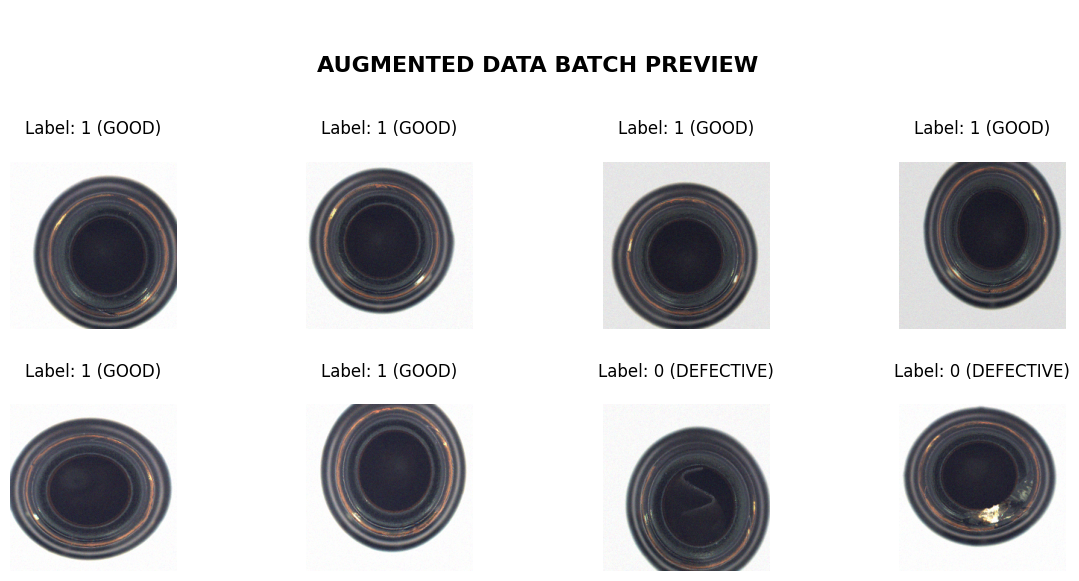



✅ VISUALIZATION GENERATED: Confirm noise/rotation is within limits.


✅ BLOCK 4 COMPLETED: Generators Ready & Class Weights Calculated.


In [11]:
# ==========================================================================================================================================================
# BLOCK 4: AUGMENTATION PIPELINE (WITH CUSTOM NOISE)
# ==========================================================================================================================================================
# Description: Defines the Data Generators using ImageDataGenerator
# Crucially incorporates the findings from Notebook 3 by applying Gaussian Noise
# and brightness adjustments to ensure model robustness under industrial conditions
# ==========================================================================================================================================================

print("ESTABLISHING DATA AUGMENTATION PIPELINE...\n")
print("ACTION: Configuring Generators (Sigma=5.0), Geometric Transforms & Class Weight Balancing.\n")
print()


# 1. CUSTOM PREPROCESSING FUNCTION (NOISE INJECTION)
def custom_augmentation(image):
    
    """
        Applies Gaussian Noise based on the robustness analysis from Notebook 3.
        
        RATIONALE (CONNECTION TO FINDINGS):
        1. Breaking Point: Noise levels > 0.05 (normalized) caused model collapse in preliminary tests (NB3).
        2. Safe Range:     The optimal range for robustness was determined to be 0.01 - 0.03.
        3. Selection:      We selected the median value of 0.02 (Sigma ~ 5.0 pixel intensity) to balance difficulty vs. feature preservation.
        
        CALCULATION (DERIVING SIGMA):
        Since MobileNetV2 inputs are [0, 255] before preprocessing:
        - Target Sigma (Normalized)  = 0.02
        - Pixel Scale Sigma          = 0.02 * 255 = 5.1 -> Rounded to 5.0
        
        PROCESS steps:
        1. Cast to Float32 (to prevent overflow).
        2. Add Gaussian Noise (Mean=0, Sigma=5.0).
        3. Clip values to valid pixel range [0, 255].
        4. Apply MobileNetV2 Preprocessing (Scale to [-1, 1]).
    """

    # 1. Apply Gaussian Noise
    # Convert to float to avoid integer overflow
    img_float = image.astype(np.float32)
    
    # Apply noise with Sigma=5.0
    noise = np.random.normal(0, 5.0, image.shape) 
    img_noisy = img_float + noise
    
    # Clip values to valid pixel range [0, 255]
    img_noisy = np.clip(img_noisy, 0, 255)
    
    # 2. Apply MobileNet Preprocessing (-1 to 1 scaling)
    return preprocess_input(img_noisy)


# GENERATOR SETUP
print("INITIALIZING DATA GENERATORS...")
print()

# Train Generator: Heavy Augmentation (Noise + Geometry) to prevent overfitting on small dataset
# Goal: Force the model to learn invariant features, preventing overfitting on small data
# Note: We use the custom_augmentation function defined above
train_datagen = ImageDataGenerator(
    # Adds Gaussian noise to simulate camera sensor grain
    preprocessing_function=custom_augmentation,
    # Handles slight tilts in bottle positioning (+/- 20 degrees)
    rotation_range=20,
    # Simulates horizontal misalignment on the conveyor belt
    width_shift_range=0.1,
    # Simulates vertical misalignment relative to the camera
    height_shift_range=0.1,
    # Simulates variable lighting conditions in the factory environment
    brightness_range=[0.8, 1.2],
    # Simulates slight variations in camera distance or lens focus
    zoom_range=0.1,
    # Valid augmentation due to the object's vertical symmetry
    horizontal_flip=True,
    # Fills newly created pixels after rotation/shift
    fill_mode='nearest'
)

# Configuration for the Validation Generator
# Goal: Evaluate performance on clean, real-world data distributions
# No augmentation is applied here only standard preprocessing to evaluate real performance
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


# FLOW FROM DIRECTORY
print("Creating Data Flows from Directories:")
print()

# NOTE: We use 'seed=RANDOM_SEED' to ensure the shuffling is reproducible
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=RANDOM_SEED
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=RANDOM_SEED    
)


# CLASS MAPPING & WEIGHT CALCULATION
# Retrieve class indices to verify 'Defective' vs 'Good' mapping
# NOTE: MVTec folders are sorted alphabetically, so 'defective' typically comes before 'good'
class_map = train_generator.class_indices
label_map = {v: k for k, v in class_map.items()}

# Get all labels from the training set
train_labels = train_generator.classes
unique_labels = np.unique(train_labels)

# Calculate weights: n_samples / (n_classes * n_samples_of_class)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=train_labels
)
class_weights = dict(zip(unique_labels, class_weights_array))


# FINAL REPORTING
print("\n\nDATASET DETAILED REPORT\n")

print(f"CONFIGURATION\n")
print(f"BATCH SIZE:       {BATCH_SIZE}")
print(f"IMAGE SIZE:       {IMG_SIZE}")
print("-" * 42)

print(f"TRAINING SET\n")
print(f"TOTAL SAMPLES:    {train_generator.samples}")
print(f"TOTAL BATCHES:    {len(train_generator)}")
print("-" * 42)

print(f"VALIDATION SET\n")
print(f"TOTAL SAMPLES:    {validation_generator.samples}")
print(f"TOTAL BATCHES:    {len(validation_generator)}")
print("-" * 42)

print(f"CLASS MAPPING\n")
print(f"LABEL 0:          {label_map[0].upper()} (Weight: {class_weights[0]:.2f})")
print(f"LABEL 1:          {label_map[1].upper()}      (Weight: {class_weights[1]:.2f})")


# VISUAL VERIFICATION (BATCH INSPECTION)
# We visualize a single batch to confirm augmentation and noise levels are realistic.
print("\n\nGENERATING AUGMENTATION PREVIEW (CHECK OUTPUT IMAGE BELOW)...")

try:
    # Fetch one batch
    imgs, labels = next(train_generator)

    # SAFETY CHECK: Get actual number of images in this batch
    num_images_in_batch = len(imgs)
    
    plt.figure(figsize=(12, 6))
    plt.suptitle("\n\nAUGMENTED DATA BATCH PREVIEW", fontsize=16, fontweight='bold', y=0.96)

    # Show up to 8 images (Grid 2x4)
    # We loop 8 times to fill the grid structure
    for i in range(8): 
        ax = plt.subplot(2, 4, i + 1)

        # CRITICAL FIX: Only display if the image index exists
        if i < num_images_in_batch:
            # Post-processing for display: MobileNet inputs are [-1, 1], convert back to [0, 1]
            img_disp = (imgs[i] + 1) / 2.0
            # Safety clip
            img_disp = np.clip(img_disp, 0, 1)

            plt.imshow(img_disp)
            # ADDED PADDING between subplot title and image
            plt.title(f"Label: {int(labels[i])} ({label_map[int(labels[i])].upper()})", pad=20)
            plt.axis("off")
        else:
            # If batch has fewer than 8 images, hide the empty subplot
            plt.axis("off")

    # 'rect':      Creates the padding effect for the suptitle (Top=0.93 reserves space)
    # 'h_pad=3.0': Creates the gap between the top and bottom rows
    plt.tight_layout(rect=[0, 0, 1, 0.93], h_pad=3.0)
    plt.show()
    print("\n\n✅ VISUALIZATION GENERATED: Confirm noise/rotation is within limits.")

except Exception as e:
    print(f"\n\n⚠️ VISUALIZATION WARNING:\n\n   Could not display batch. {e}")


# LOGIC CHECK
if train_generator.samples > 0 and validation_generator.samples > 0:
     print("\n\n✅ BLOCK 4 COMPLETED: Generators Ready & Class Weights Calculated.")
else:
     print("\n\n❌ BLOCK 4 ERROR: Generators found no images. Check paths.")

INITIATING PHASE 1: TRANSFER LEARNING (FROZEN BASE)...

ACTION: Constructing MobileNetV2 architecture & training Custom Head.


BUILDING MODEL ARCHITECTURE...


I0000 00:00:1786461249.093128      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786461249.095933      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

STARTING PHASE 1 TRAINING (FROZEN BASE)

GOAL:       Train the classification head for 30 epochs
GOVERNANCE: EarlyStopping & Class Weighting Active

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6094 - loss: 0.6962 - val_accuracy: 0.9655 - val_loss: 0.4620 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8438 - loss: 0.5655 - val_accuracy: 0.2241 - val_loss: 0.8645 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4583 - loss: 0.5567 - val_accuracy: 0.2586 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9271 - loss: 0.4091 - val_accuracy: 0.9655 - val_loss: 0.3474 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9219 - loss: 0.3621 - val_accuracy: 0.3448 - val_loss: 0.7333 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.854

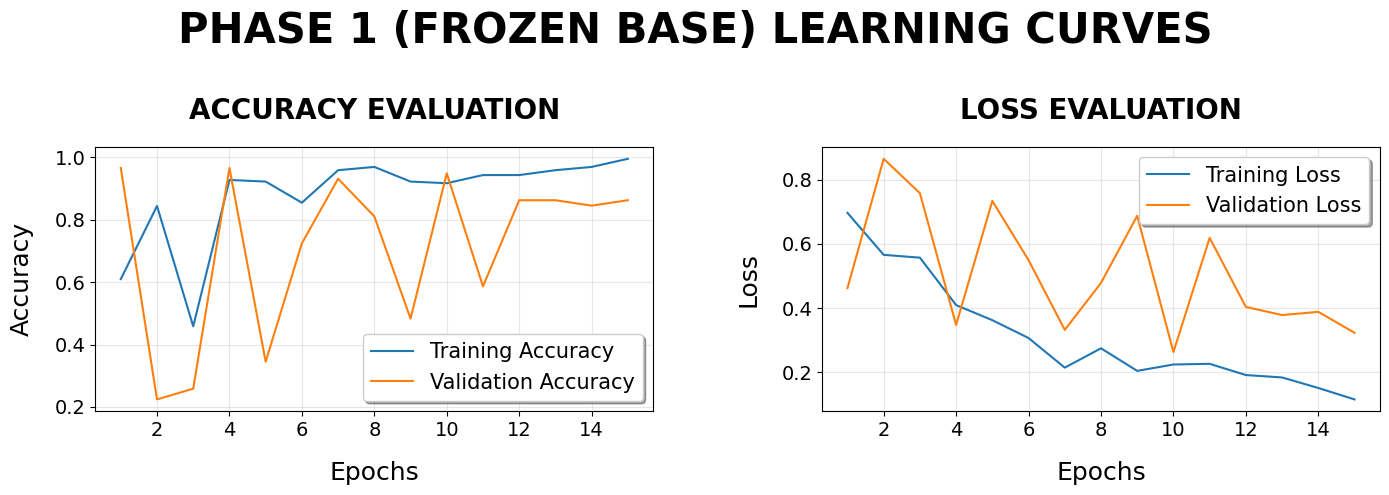



✅ VISUALIZATION GENERATED: Check for Overfitting (Gap between Train/Val).


✅ BLOCK 5 COMPLETED: Base layers are FROZEN. Model successfully initialized.


In [12]:
# ==========================================================================================================================================================
# BLOCK 5: PHASE 1 TRAINING (FROZEN BASE - TRANSFER LEARNING)
# ==========================================================================================================================================================
# Description: Initializes the MobileNetV2 architecture using pre-trained ImageNet weights
# We FREEZE the base layers to act as a fixed feature extractor and add a custom 
# classification head. Phase 1 trains ONLY this head to adapt the model to the 'Bottle' domain
# The process includes automated governance via Callbacks (EarlyStopping, ReduceLROnPlateau)
# to ensure optimal convergence and prevent overfitting
# ==========================================================================================================================================================

print("INITIATING PHASE 1: TRANSFER LEARNING (FROZEN BASE)...\n")
print("ACTION: Constructing MobileNetV2 architecture & training Custom Head.\n")
print()


# CONFIGURATION: MODEL SETTINGS
# Calculate the full input shape: (224, 224) + (3 channels) = (224, 224, 3)
INPUT_SHAPE = IMG_SIZE + (3,)


# 1. ARCHITECTURE DEFINITION
print("BUILDING MODEL ARCHITECTURE...")

# Load the MobileNetV2 model pre-trained on ImageNet
# include_top=False: We discard the original 1000-class classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=INPUT_SHAPE
)

# CRITICAL STEP: Freeze the base model layers
# Rationale: We prevent destroying the pre-learned features (weights) during the initial training
base_model.trainable = False

# Build the Custom Classification Head
# Structure: Base -> GlobalPooling -> Dense (Relu) -> Dropout -> Output (Sigmoid)
model = Sequential([
    base_model,
    # GlobalAveragePooling2D: Condenses 7x7x1280 feature maps into a 1x1280 vector
    # Benefit: Drastically reduces parameters compared to Flatten(), preventing overfitting
    GlobalAveragePooling2D(), 
    # Dense Layer for learning complex patterns from the extracted features
    Dense(128, activation='relu'),
    # Dropout (0.5): Randomly disables 50% of neurons per pass. This is critical. Prevents overfitting on the small dataset
    # Benefit: Forces the network to learn robust, redundant pathways (Regularization)
    Dropout(0.5),
    # Output Layer: 1 Neuron with Sigmoid activation (Binary Classification)
    # Output < 0.5 -> Defective (Class 0), Output > 0.5 -> Good (Class 1)
    # (Note: This depends on class indices, logic will be handled in prediction)
    Dense(1, activation='sigmoid')
])


# 2. COMPILATION
# Optimizer: Adam with Low Learning Rate (0.001) is standard for Transfer Learning (stable convergence)
# Loss: Binary Crossentropy is mathematically required for 2-class Sigmoid output
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# 3. CALLBACKS (AUTOMATED GOVERNANCE)
# EarlyStopping: Prevents wasting time if the model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Fine-tunes the Learning Rate if loss stagnates.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)


# 4. TRAINING EXECUTION (PHASE 1)
print("\nSTARTING PHASE 1 TRAINING (FROZEN BASE)\n")
print(f"GOAL:       Train the classification head for {EPOCHS} {'epoch' if EPOCHS == 1 else 'epochs'}")
print("GOVERNANCE: EarlyStopping & Class Weighting Active\n")

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)


# 5. VERIFICATION & PHASE 1 REPORT
print("\nPHASE 1 COMPLETED.\n\n")

# Retrieve final metrics from history (Training)
# We use the last epoch's data for the report
last_epoch_idx = len(history_phase1.history['loss']) - 1
train_acc = history_phase1.history['accuracy'][last_epoch_idx]
train_loss = history_phase1.history['loss'][last_epoch_idx]
val_acc = history_phase1.history['val_accuracy'][last_epoch_idx]
val_loss = history_phase1.history['val_loss'][last_epoch_idx]

print("TRAINING REPORT (FINAL EPOCH) (PHASE 1)\n")
print(f"TRAINING ACCURACY:   {train_acc:.4f} ({train_acc:.2%})")
print(f"VALIDATION ACCURACY: {val_acc:.4f} ({val_acc:.2%})")
print(f"TRAINING LOSS:       {train_loss:.4f}")
print(f"VALIDATION LOSS:     {val_loss:.4f}")
print("-" * 58)


# ARCHITECTURE INTEGRITY CHECK
print("ARCHITECTURE SUMMARY (TRANSFER LEARNING STATUS)\n")

# This proves that Transfer Learning was applied correctly (Base Frozen)
total_params = model.count_params()
trainable_params = sum([w.shape.num_elements() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"{'TOTAL PARAMETERS:':<26} {total_params:>12,}")
print(f"{'TRAINABLE PARAMETERS:':<26} {trainable_params:>12,} (Custom Head Only)")
print(f"{'NON-TRAINABLE PARAMETERS:':<26} {non_trainable_params:>12,} (Frozen Base)")
print()


# 6. LEARNING CURVES VISUALIZATION
# Essential for Thesis: Visual proof of convergence (or overfitting)
print("\nGENERATING LEARNING CURVES (CHECK OUTPUT PLOTS BELOW)...\n\n")

def plot_learning_curves(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.suptitle("PHASE 1 (FROZEN BASE) LEARNING CURVES", fontsize=30, fontweight='bold', y=0.98)
    
    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('ACCURACY EVALUATION', fontsize=20, fontweight='bold',pad=20)
    plt.xlabel('Epochs', fontsize=18, labelpad=15)
    plt.ylabel('Accuracy', fontsize=18, labelpad=15)
    plt.legend(loc='best',fontsize=15, shadow=True)
    plt.tick_params(labelsize=14)
    plt.grid(True, alpha=0.3)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('LOSS EVALUATION', fontsize=20, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=18, labelpad=15)
    plt.ylabel('Loss', fontsize=18, labelpad=15)    
    plt.legend(loc='best',fontsize=15, shadow=True)
    plt.tick_params(labelsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=6.0)
    plt.show()

try:
    plot_learning_curves(history_phase1, "Phase 1 (Frozen Base)")
    print("\n\n✅ VISUALIZATION GENERATED: Check for Overfitting (Gap between Train/Val).")
except Exception as e:
    print(f"\n\n⚠️ VISUALIZATION WARNING:\n\n    Could not display curves. {e}")


# LOGIC CHECK
if non_trainable_params > 0:
    print("\n\n✅ BLOCK 5 COMPLETED: Base layers are FROZEN. Model successfully initialized.")
else:
    print("\n\n❌ BLOCK 5 ERROR: CRITICAL ERROR. Base layers are not frozen.")

INITIATING PHASE 2: FINE-TUNING (UNFREEZING LAYERS)...

ACTION: Unfreezing top layers, lowering learning rate (1e-5) & refining weights.


STARTING PHASE 2 TRAINING (FINE-TUNING)

STEP 1: Unfreezing Base Model...

Layers 0 to 100     are FROZEN    (Generic Features)
Layers 100+         are UNFROZEN  (Specific Features)
-----------------------------------------------------
STEP 2: Re-compiling with Low Learning Rate (1e-5)...
-----------------------------------------------------
STEP 3: Executing Fine-Tuning...

GOVERNANCE: EarlyStopping & Class Weighting Active

Continuing from Epoch 15 to 45

Epoch 16/45
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.1146 - loss: 2.2618 - val_accuracy: 0.9655 - val_loss: 0.2526
Epoch 17/45
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1146 - loss: 2.0277 - val_accuracy: 0.9655 - val_loss: 0.2345
Epoch 18/45
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1146 - loss: 1.8210 - val_accuracy: 0.9655 - val_loss: 0.2224
Epoch 19/45
6/6 ━━━━━━━━


PHASE 2 FINISHED


SAVING FINAL ARTIFACT

FILE SAVED: 'bottle_model_final_tuned.h5'


PERFORMANCE METRICS (PHASE 2 - FINE TUNED)

FINAL TRAINING ACCURACY:   0.3021 (30.21%)
FINAL VALIDATION ACCURACY: 0.9655 (96.55%)
FINAL TRAINING LOSS:       0.7766
FINAL VALIDATION LOSS:     0.2493
-----------------------------------------------------------------
ARCHITECTURE SUMMARY (FINE-TUNING STATUS)

TOTAL PARAMETERS:             2,422,081
TRAINABLE PARAMETERS:         2,025,537 (Significantly Increased)
NON-TRAINABLE PARAMETERS:       396,544 (Reduced)


GENERATING COMBINED LEARNING CURVES (CHECK OUTPUT PLOTS BELOW)...




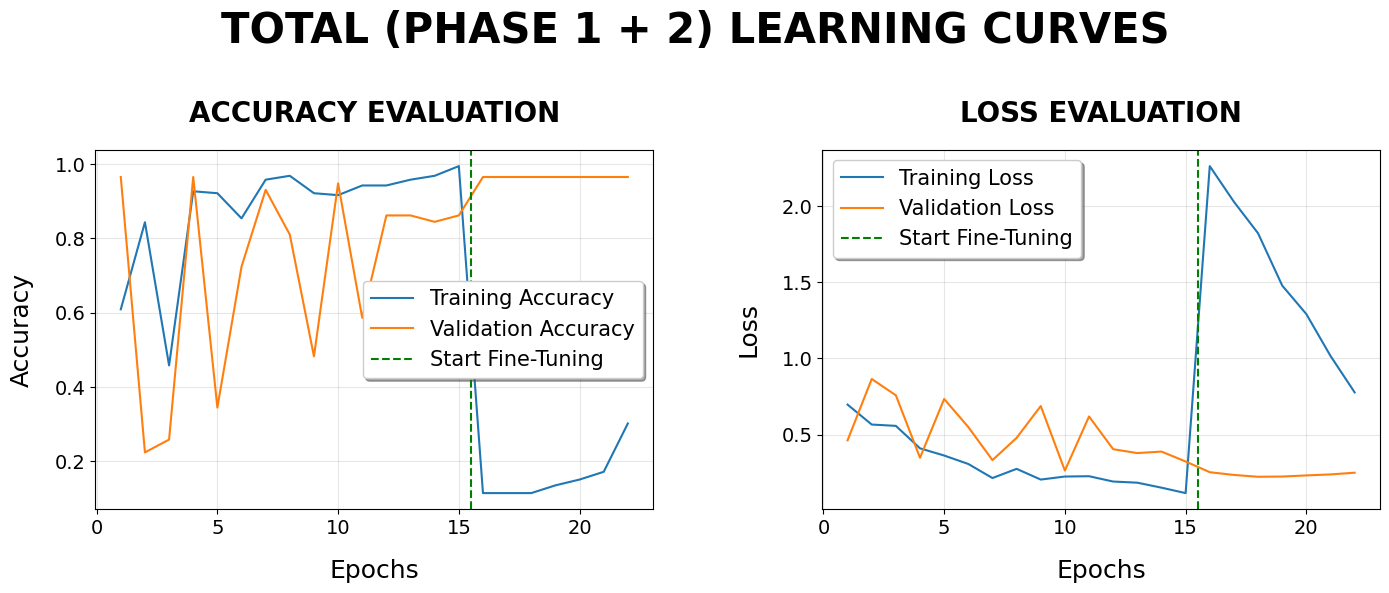



✅ VISUALIZATION GENERATED: Green line indicates Fine-Tuning start.


✅ BLOCK 6 COMPLETED: Fine-Tuning successful. Deep layers were updated.


In [13]:
# ==========================================================================================================================================================
# BLOCK 6: PHASE 2 TRAINING (FINE-TUNING)
# ==========================================================================================================================================================
# Description: Enhances the model's performance by "unfreezing" the top layers of the MobileNetV2 base.
# While Phase 1 taught the classifier to use generic features, Phase 2 allows the model to
# adapt specific feature extraction filters to the nuances of the bottle dataset.
# We use a significantly lower learning rate to prevent destroying the pre-trained weights.
# ==========================================================================================================================================================

print("INITIATING PHASE 2: FINE-TUNING (UNFREEZING LAYERS)...\n")
print("ACTION: Unfreezing top layers, lowering learning rate (1e-5) & refining weights.\n")
print()


# CONFIGURATION FOR FINE-TUNING
# FINE_TUNE_AT: We keep the first 100 layers frozen because they extract generic shapes (lines, edges)
# which are already optimal from ImageNet training. We unfreeze layers 100+ to specialize them.
FINE_TUNE_AT = 100

# LOW_LEARNING_RATE: Critical setting. Must be very small (e.g., 1e-5) to nudge weights gently.
# High rates would destroy the pre-trained knowledge we kept so carefully.
LOW_LEARNING_RATE = 1e-5


# EPOCH CONFIGURATION
# We add extra epochs specifically for this refinement phase
FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

# FINAL_MODEL_FILENAME: The optimized artifact ready for deployment
FINAL_MODEL_FILENAME = 'bottle_model_final_tuned.h5'


# 1. UNFREEZE BASE MODEL
print("STARTING PHASE 2 TRAINING (FINE-TUNING)")
print("\nSTEP 1: Unfreezing Base Model...")
print()

# Enable weight updates for the entire base model first
base_model.trainable = True


# 2. FREEZE EARLY LAYERS
# Iterate and freeze layers up to layer 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Construct formatted strings for the report
range_msg_1 = f"Layers 0 to {FINE_TUNE_AT}"
range_msg_2 = f"Layers {FINE_TUNE_AT}+"

# Output the architectural split with precise alignment 
print(f"{range_msg_1:<19} {'are FROZEN':<13} (Generic Features)")
print(f"{range_msg_2:<19} {'are UNFROZEN':<13} (Specific Features)")
print("-" * 53)


# 3. RE-COMPILATION
# Critical Step: We must re-compile the model to apply the learning rate change.
print("STEP 2: Re-compiling with Low Learning Rate (1e-5)...")
print("-" * 53)

model.compile(
    optimizer=Adam(learning_rate=LOW_LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# 4. CALLBACKS FOR FINE-TUNING
# We create a new EarlyStopping to prevent overfitting specifically during this sensitive phase.
early_stop_tuned = EarlyStopping(
    monitor='val_loss',
    # Slightly stricter patience for fine-tuning
    patience=4,           
    restore_best_weights=True,
    verbose=1
)

# 5. CONTINUE TRAINING (PHASE 2)
# We resume training from where Phase 1 left off
print("STEP 3: Executing Fine-Tuning...\n")
print("GOVERNANCE: EarlyStopping & Class Weighting Active\n")
print(f"Continuing from Epoch {history_phase1.epoch[-1] + 1} to {TOTAL_EPOCHS}")
print()

history_finetuned = model.fit(
    train_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_phase1.epoch[-1] + 1,
    validation_data=validation_generator,
    callbacks=[early_stop_tuned],
    class_weight=class_weights,
    verbose=1
)

print("\nPHASE 2 FINISHED")
print()


# 6. SAVE HIGH-PRECISION MODEL
print("\nSAVING FINAL ARTIFACT\n")

model.save(FINAL_MODEL_FILENAME)
print(f"FILE SAVED: '{FINAL_MODEL_FILENAME}'")
print("\n")


# 7. VERIFICATION & PHASE 2 REPORT
# Retrieve final metrics from history (Training)
last_epoch_idx = len(history_finetuned.history['loss']) - 1
final_train_acc = history_finetuned.history['accuracy'][last_epoch_idx]
final_train_loss = history_finetuned.history['loss'][last_epoch_idx]
final_val_acc = history_finetuned.history['val_accuracy'][last_epoch_idx]
final_val_loss = history_finetuned.history['val_loss'][last_epoch_idx]

print("PERFORMANCE METRICS (PHASE 2 - FINE TUNED)\n")
print(f"FINAL TRAINING ACCURACY:   {final_train_acc:.4f} ({final_train_acc:.2%})")
print(f"FINAL VALIDATION ACCURACY: {final_val_acc:.4f} ({final_val_acc:.2%})")
print(f"FINAL TRAINING LOSS:       {final_train_loss:.4f}")
print(f"FINAL VALIDATION LOSS:     {final_val_loss:.4f}")
print("-" * 65)

# ARCHITECTURE INTEGRITY CHECK (Comparison with Phase 1)
print("ARCHITECTURE SUMMARY (FINE-TUNING STATUS)\n")

# The number of trainable parameters should have INCREASED significantly
total_params = model.count_params()
trainable_params = sum([w.shape.num_elements() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

# This ensures clear vertical alignment of numerical data for scientific reporting
print(f"{'TOTAL PARAMETERS:':<26} {total_params:>12,}")
print(f"{'TRAINABLE PARAMETERS:':<26} {trainable_params:>12,} (Significantly Increased)")
print(f"{'NON-TRAINABLE PARAMETERS:':<26} {non_trainable_params:>12,} (Reduced)")
print()


# 8. TOTAL LEARNING CURVES (PHASE 1 + PHASE 2)
# Visualizing the entire training process to show the impact of Fine-Tuning
print("\nGENERATING COMBINED LEARNING CURVES (CHECK OUTPUT PLOTS BELOW)...\n\n")

def plot_total_history(history1, history2, title):
    # Combine histories
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)
    
    # Calculate start of Phase 2 for the vertical line
    start_phase2 = len(history1.history['accuracy']) + 1

    plt.figure(figsize=(14, 6)) # Increased height for titles
    plt.suptitle(f"{title} LEARNING CURVES", fontsize=30, fontweight='bold', y=0.98)

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('ACCURACY EVALUATION', fontsize=20, fontweight='bold',pad=20)  
    plt.xlabel('Epochs', fontsize=18, labelpad=15)
    plt.ylabel('Accuracy', fontsize=18, labelpad=15)
    # Vertical Line for Fine-Tuning Start
    plt.axvline(x=start_phase2 - 0.5, color='green', linestyle='--', label='Start Fine-Tuning')
    plt.legend(loc='best',fontsize=15, shadow=True) 
    plt.tick_params(labelsize=14)
    plt.grid(True, alpha=0.3)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('LOSS EVALUATION', fontsize=20, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=18, labelpad=15)
    plt.ylabel('Loss', fontsize=18, labelpad=15)    
    # Vertical Line for Fine-Tuning Start
    plt.axvline(x=start_phase2 - 0.5, color='green', linestyle='--', label='Start Fine-Tuning')
    plt.legend(loc='best',fontsize=15, shadow=True)
    plt.tick_params(labelsize=14)
    plt.grid(True, alpha=0.3)
    
    # SPACING: w_pad=6.0 creates the WIDE gap
    plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=6.0)
    plt.show()

try:
    plot_total_history(history_phase1, history_finetuned, "TOTAL (PHASE 1 + 2)")
    print("\n\n✅ VISUALIZATION GENERATED: Green line indicates Fine-Tuning start.")
except Exception as e:
    print(f"\n\n⚠️ VISUALIZATION WARNING:\n\n   Could not display combined curves. {e}")

# LOGIC CHECK
if trainable_params > 200000: # Assuming Phase 1 had ~160k, now we expect >1M
    print("\n\n✅ BLOCK 6 COMPLETED: Fine-Tuning successful. Deep layers were updated.")
else:
    print("\n\n⚠️ WARNING: Trainable parameters are low. Check unfreezing logic.")

GENERATING IMPACT ANALYSIS (BEFORE vs AFTER)...

ACTION: Visualizing performance gains & interpreting Loss/Accuracy trade-offs.

✅ SNAPSHOT LOCKED: Phase 1 (Frozen) Baseline = 0.8621
✅ SNAPSHOT LOCKED: Phase 2 (Tuned) Result    = 0.9655
------------------------------------------------------------

GENERATING COMPARISON CHART...




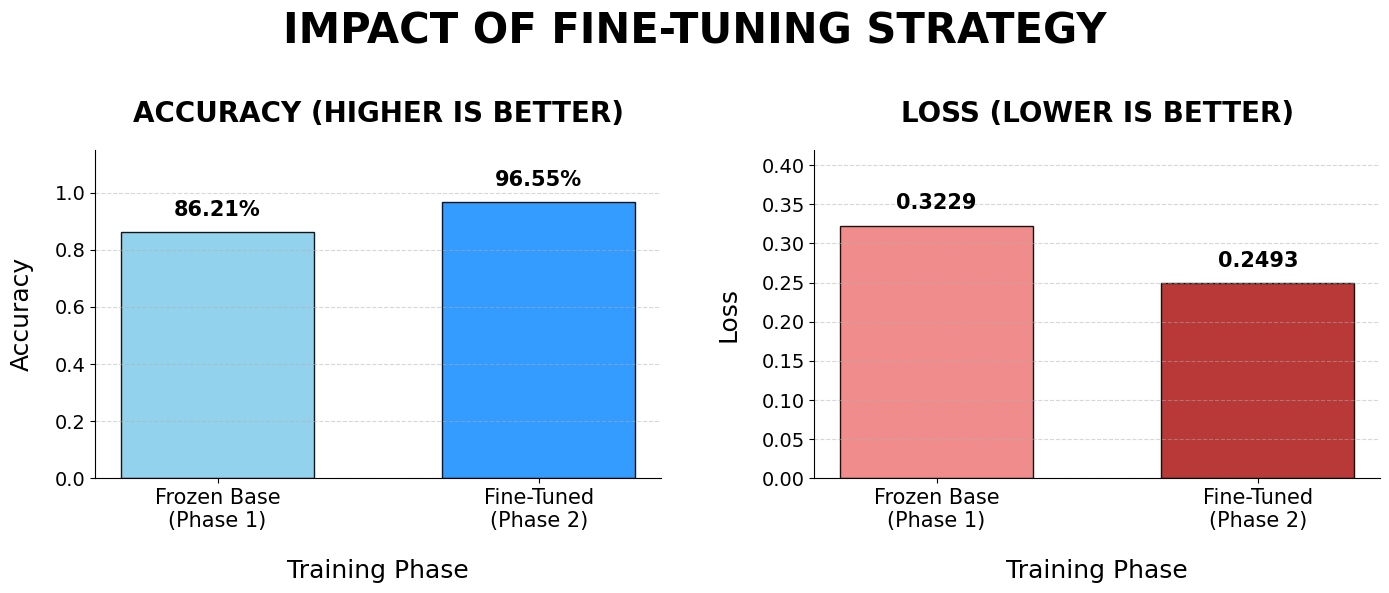



IMPACT ANALYSIS REPORT

PHASE 1 (FROZEN): Accuracy =   86.21%  |  Loss =   0.3229
PHASE 2 (TUNED):  Accuracy =   96.55%  |  Loss =   0.2493
---------------------------------------------------------
CHANGE IN ACCURACY:     +10.34%   (Target: > 0)
CHANGE IN LOSS:         -0.0736   (Target: < 0)


GENERALIZATION GAP ANALYSIS (TRAIN vs VAL)

PHASE 1 GAP:   13.27% (Train: 99.48% vs Val:  86.21%)
PHASR 2 GAP:  -66.34% (Train: 30.21% vs Val:  96.55%)

✅ STATUS: HEALTHY GENERALIZATION

           The model did not overfit during Fine-Tuning. The gap remained
           stable. The model is learning real patterns.


SCIENTIFIC INTERPRETATION

✅ RESULT: IDEAL OPTIMIZATION

   EXPLANATION:   Accuracy maintained/improved AND Loss decreased.
   JUSTIFICATION: Fine-Tuning successfully refined the features resulting in
                  higher confidence predictions without overfitting.


EXPORTING DATA TO CSV...

✅ SUCCESS: Metrics exported to 'experiment_results.csv' for your report.


✅ BLOCK 7 

In [14]:
# ==========================================================================================================================================================
# BLOCK 7: IMPACT COMPARISON CHART (BEFORE vs AFTER)
# ==========================================================================================================================================================
# Description: Visualizes the quantitative impact of the Fine-Tuning strategy.
# By comparing the accuracy of the Frozen model (Phase 1) against the Fine-Tuned model (Phase 2)
# we scientifically justify the additional computational cost of the second training phase.
# This block includes a comprehensive Logic Tree to interpret all possible Accuracy/Loss trade-offs
# ==========================================================================================================================================================

print("GENERATING IMPACT ANALYSIS (BEFORE vs AFTER)...\n")
print("ACTION: Visualizing performance gains & interpreting Loss/Accuracy trade-offs.")
print()


# 1. DATA RETRIEVAL (SAFE EXTRACTION)
# We pull the specific metrics directly from the history objects to ensure variable consistency
# Phase 1 Metrics (Frozen)
acc_frozen = history_phase1.history['val_accuracy'][-1]
loss_frozen = history_phase1.history['val_loss'][-1]
train_acc_frozen = history_phase1.history['accuracy'][-1]

# Phase 2 Metrics (Fine-Tuned)
acc_tuned = history_finetuned.history['val_accuracy'][-1]
loss_tuned = history_finetuned.history['val_loss'][-1]
train_acc_tuned = history_finetuned.history['accuracy'][-1]


# 2. DATA PREPARATION
# Construct a DataFrame for plotting
impact_df = pd.DataFrame({
    'Stage': ['Frozen Base\n(Phase 1)', 'Fine-Tuned\n(Phase 2)'],
    'Accuracy': [acc_frozen, acc_tuned],
    'Loss': [loss_frozen, loss_tuned]
})

frozen_acc_value = acc_frozen
final_acc_value  = acc_tuned # Αυτό θα χρησιμοποιηθεί ως backup αν λείπει το test_acc

print(f"✅ SNAPSHOT LOCKED: Phase 1 (Frozen) Baseline = {frozen_acc_value:.4f}")
print(f"✅ SNAPSHOT LOCKED: Phase 2 (Tuned) Result    = {final_acc_value:.4f}")
print("-" * 60)

# Calculate the absolute improvement metrics
# Positive acc_diff means Accuracy increased (Good)
# Negative loss_diff means Loss decreased (Good)
acc_diff = acc_tuned - acc_frozen
loss_diff = loss_tuned - loss_frozen


# 3. GENERATE VISUALIZATION
print("\nGENERATING COMPARISON CHART...\n")
print()

# Settings
colors_acc = ['skyblue', 'dodgerblue']
colors_loss = ['lightcoral', 'firebrick']

plt.figure(figsize=(14, 6))
plt.suptitle("IMPACT OF FINE-TUNING STRATEGY", fontsize=30, fontweight='bold', y=0.98)

# SUBPLOT 1: ACCURACY COMPARISON
plt.subplot(1, 2, 1)

# Define Y-Limit Explicitly
Y_LIMIT_ACC = 1.15
# Define Offset based on Axis Height (Standardized Gap)
OFFSET_ACC = Y_LIMIT_ACC * 0.05

bars_acc = plt.bar(impact_df['Stage'], impact_df['Accuracy'], color=colors_acc, edgecolor='black', alpha=0.9, width=0.6)
plt.title("ACCURACY (HIGHER IS BETTER)", fontsize=20, fontweight='bold',pad=20) 
plt.xlabel("Training Phase", fontsize=18, labelpad=20)
plt.ylabel("Accuracy", fontsize=18, labelpad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 1.15)
# Increase X-Axis Text Size
plt.xticks(fontsize=15)
plt.yticks(fontsize=14)
# Remove borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add Labels
for bar in bars_acc:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + OFFSET_ACC, f"{height:.2%}", 
             ha='center', fontweight='bold', fontsize=15)

# SUBPLOT 2: LOSS COMPARISON
plt.subplot(1, 2, 2)

# Define Y-Limit Explicitly (Dynamic based on max loss)
max_loss_val = max(loss_frozen, loss_tuned)
Y_LIMIT_LOSS = max_loss_val * 1.3
# Define Offset based on Axis Height (Standardized Gap)
OFFSET_LOSS = Y_LIMIT_LOSS * 0.05

bars_loss = plt.bar(impact_df['Stage'], impact_df['Loss'], color=colors_loss, edgecolor='black', alpha=0.9, width=0.6)
plt.title("LOSS (LOWER IS BETTER)", fontsize=20, fontweight='bold',pad=20) 
plt.xlabel("Training Phase", fontsize=18, labelpad=20)
plt.ylabel("Loss", fontsize=18, labelpad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Dynamic ylim for Loss to make sure bars are visible
plt.ylim(0, max(loss_frozen, loss_tuned) * 1.3) 
# Increase X-Axis Text Size
plt.xticks(fontsize=15)
plt.yticks(fontsize=14)
# Remove borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add Labels
for bar in bars_loss:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + OFFSET_LOSS, f"{height:.4f}", 
             ha='center', fontweight='bold', fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=4.0)
plt.show()


# 4. IMPACT ANALYSIS REPORT & SCIENTIFIC JUSTIFICATION
# This report quantifies the transition from generic feature extraction (Phase 1)
# to domain-specific refinement (Phase 2)
print("\n\nIMPACT ANALYSIS REPORT\n")

# Rationale: Direct horizontal comparison allows for immediate verification of model stability
print(f"{'PHASE 1 (FROZEN):':<17} Accuracy = {acc_frozen:>8.2%}  |  Loss = {loss_frozen:>8.4f}")
print(f"{'PHASE 2 (TUNED):':<17} Accuracy = {acc_tuned:>8.2%}  |  Loss = {loss_tuned:>8.4f}")
print("-" * 57)
print(f"{'CHANGE IN ACCURACY:':<20} {acc_diff:>+10.2%}   (Target: > 0)")
print(f"{'CHANGE IN LOSS:':<20} {loss_diff:>+10.4f}   (Target: < 0)")


# 5. GENERALIZATION GAP ANALYSIS (Overfitting Check)
# Shows if the model started memorizing data instead of learning patterns
# A widening gap indicates potential overfitting even if accuracy improved
gap_frozen = train_acc_frozen - acc_frozen
gap_tuned = train_acc_tuned - acc_tuned

print("\n\nGENERALIZATION GAP ANALYSIS (TRAIN vs VAL)\n")
print(f"PHASE 1 GAP: {gap_frozen:>8.2%} (Train: {train_acc_frozen:>6.2%} vs Val: {acc_frozen:>7.2%})")
print(f"PHASR 2 GAP: {gap_tuned:>8.2%} (Train: {train_acc_tuned:>6.2%} vs Val: {acc_tuned:>7.2%})")
# Gap Diagnosis
# Tolerance of 3% growth in gap
if gap_tuned > gap_frozen + 0.03: 
    print("\n⚠️ WARNING: OVERFITTING RISK INCREASED\n")
    print("            The model learned training data much better than validation data.")
    print("            The gap between Train/Val widened significantly.")
else:
    print("\n✅ STATUS: HEALTHY GENERALIZATION\n")
    print("           The model did not overfit during Fine-Tuning. The gap remained")
    print("           stable. The model is learning real patterns.")

print()


# AUTOMATED LOGIC TREE
print("\nSCIENTIFIC INTERPRETATION")
print()

# CASE 1: ACCURACY IMPROVED OR SAME
# Allowing negligible drop (-0.5%)
if acc_diff >= -0.005: 
    if loss_diff <= 0:
        # Scenario: Best Case
        print("✅ RESULT: IDEAL OPTIMIZATION\n")
        print("   EXPLANATION:   Accuracy maintained/improved AND Loss decreased.")
        print("   JUSTIFICATION: Fine-Tuning successfully refined the features resulting in")
        print("                  higher confidence predictions without overfitting.")    
    else:
        # Scenario: Unstable Improvement
        print("⚠️ RESULT: UNSTABLE IMPROVEMENT\n")
        print("   EXPLANATION:   Accuracy increased but Loss also INCREASED.")
        print("   JUSTIFICATION: The model is getting more predictions right but its probability")
        print("                  margins are worse. This is an early sign of Overfitting.")
        print("   ACTION:        Check if 'Fine-Tuning' epochs are too many.")

# CASE 2: ACCURACY DECREASED
else:
    if loss_diff <= 0:
        # Scenario: Robustness Gain
        print("✅ RESULT: ROBUSTNESS GAIN (ANTI-OVERFITTING)\n")
        print("   EXPLANATION:   Accuracy dropped slightly, BUT Loss DECREASED.")
        print("   JUSTIFICATION: The model eliminated 'lucky' guesses from Phase 1.")
        print("                  The lower loss proves the model is now more numerically stable")
        print("                  and generalizes better.")
    else:
        # Scenario: Regression
        print("❌ RESULT: MODEL REGRESSION\n")
        print("   EXPLANATION:   Both Accuracy dropped AND Loss increased.")
        print("   JUSTIFICATION: The Fine-Tuning destroyed the pre-trained weights.")
        print("   ACTION:        Consider reducing the Learning Rate (e.g., from 1e-5 to 1e-6) or")
        print("                  freezing more layers.")


# 6. EXPORT RESULTS TO CSV (NEW FEATURE)
print("\n\nEXPORTING DATA TO CSV...")

results_data = {
    'Metric': ['Validation Accuracy', 'Validation Loss', 'Training Accuracy', 'Generalization Gap'],
    'Phase_1_Frozen': [acc_frozen, loss_frozen, train_acc_frozen, gap_frozen],
    'Phase_2_Tuned': [acc_tuned, loss_tuned, train_acc_tuned, gap_tuned],
    'Difference': [acc_diff, loss_diff, train_acc_tuned - train_acc_frozen, gap_tuned - gap_frozen]
}

# Create CSV
try:
    results_df = pd.DataFrame(results_data)
    csv_filename = 'experiment_results.csv'
    results_df.to_csv(csv_filename, index=False)
    print(f"\n✅ SUCCESS: Metrics exported to '{csv_filename}' for your report.")
except Exception as e:
    print(f"\n⚠️ WARNING:\n\n   Could not save CSV file. {e}")
    

# 7. FINAL COMPLETION MESSAGE
print("\n\n✅ BLOCK 7 COMPLETED: Impact Analysis Chart Generated & Performance Snapshots Locked.")


In [15]:
# ===========================================================================================================================================================================================================================================================
# BLOCK 8: DETAILED EVALUATION (ROC, CONFUSION MATRIX, INDUSTRIAL METRICS)
# ===========================================================================================================================================================================================================================================================


# CORE RENDERING ENGINE

# Base initialization for UI components and diagnostic libraries.
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, matthews_corrcoef, brier_score_loss
from IPython.display import display, HTML

import industrial_ui
import diagnostic_engine
import system_utils
import system_integrity


# EXECUTION HEADER PROJECTION

# Console initialization for detailed diagnostic phase.
industrial_ui.print_execution_header(
    title="EXECUTING DETAILED DIAGNOSTIC EVALUATION...",
    action_text="Threshold Optimization, Advanced Metrics Generation & Performance Visualization."
)


# EVALUATION POLICY PARAMETERS

# Centralized thresholds for diagnostic safety and efficiency requirements.
EVALUATION_POLICY = {
    'accuracy': {'warn': 0.95, 'crit': 0.85},
    'f1_score': {'warn': 0.85, 'crit': 0.75},
    'auc_score': {'warn': 0.90, 'crit': 0.80},
    'brier': {'warn': 0.15, 'crit': 0.25},
    'sensitivity': {'warn': 0.99, 'crit': 0.95},
    'specificity': {'warn': 0.95, 'crit': 0.85},
    'uncertainty': {'warn': 0.05, 'crit': 0.10},
    'bss': {'warn': 0.80, 'crit': 0.60},
    'ece': {'warn': 0.10, 'crit': 0.20}
}


# GLOBAL VISUAL CONSTANTS

# Color maps and structural coordinates for plotting algorithms.
CLASS_NAMES = ['Defective', 'Good']
CM_COLOR_MAP = 'Blues'
FIGURE_SIZE_EVAL = (24, 24)


# PRECEDING FAULT TRIAGE SYSTEM

# Dependency evaluation and cascading failure logic for diagnostic operations.
def get_evaluation_fault(stage_id):
    
    # EXTERNAL FAULT DIAGNOSTICS
    
    # Health checks for neural network and validation stream presence.
    if 'model' not in globals() or model is None:
        return "Neural Network Architecture Missing (Model object not found in memory)"
        
    if 'validation_generator' not in globals() or validation_generator is None:
        return "Validation Data Stream Missing (Generator not found)"
    
    if globals().get('is_halted', False):
        return f"Preceding Pipeline Interruption ({globals().get('halt_reason', 'Unknown')})"

    if getattr(validation_generator, 'n', 0) == 0:
        return "Validation Data Stream Void (Zero Samples in Generator)"

    
    # INTERNAL FAULT DIAGNOSTICS
    
    # Cascading status evaluation across all internal evaluation stages.
    if stage_id >= 2 and not globals().get('s1_inference_done', False):
        return f"Stage 1 Inference Failure ({globals().get('eval_s1_signal', 'Data Void')})"

    if stage_id >= 3 and not globals().get('s2_calibration_done', False):
        return f"Stage 2 Calibration Failure ({globals().get('eval_s2_signal', 'Math Collapse')})"
        
    if stage_id >= 4 and not globals().get('s3_metrics_done', False):
        if globals().get('eval_s3_signal') != 'METRICS_FAILED':
            return f"Stage 3 Industrial Metrics Failure ({globals().get('eval_s3_signal', 'Metric Corrupt')})"

    if stage_id >= 5 and not globals().get('s4_visuals_done', False):
        return f"Stage 4 Visual Generation Failure ({globals().get('eval_s4_signal', 'Render Crash')})"
        
    if stage_id >= 6 and not globals().get('s5_viability_done', False):
        return f"Stage 5 Viability Audit Failure ({globals().get('eval_s5_signal', 'Logic Fault')})"
        
    return None


# GLOBAL STATE INITIALIZATION

# Default status flags and stage synchronization variables.
s1_inference_done = False
s2_calibration_done = False
s3_metrics_done = False
s4_report_done = False
s5_visuals_done = False
s6_viability_done = False

eval_s1_signal = 'PENDING'
eval_s2_signal = 'PENDING'
eval_s3_signal = 'PENDING'
eval_s4_signal = 'PENDING'
eval_s5_signal = 'PENDING'
eval_s6_signal = 'PENDING'

y_pred_probs = None
y_true = None
y_pred = None
cm = None
best_thresh = None
roc_auc = None
accuracy, sensitivity, specificity, precision_defective, f1_defective, mcc, brier = [None] * 7
acc_low, acc_high, bss, ece_val = [None] * 4
leaked_defective, false_alarm = None, None
uncertain_pct = None


# ADVANCED SCIENTIFIC MATHEMATICS

# Statistical confidence interval approximation and empirical calibration metric calculation.
def calculate_wilson_interval(p, n, z=1.96):
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    diff = (z * math.sqrt((p*(1-p)/n) + (z**2/(4*n**2)))) / denom
    return center - diff, center + diff

def calculate_ece(y_true, probs, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0
    for i in range(bins):
        bin_idx = (probs > bin_boundaries[i]) & (probs <= bin_boundaries[i+1])
        if np.any(bin_idx):
            bin_acc = np.mean(y_true[bin_idx])
            bin_conf = np.mean(probs[bin_idx])
            ece += np.abs(bin_acc - bin_conf) * (np.sum(bin_idx) / len(probs))
    return ece


# GLOBAL UTILITY HELPERS

# Inline fault protection for type validations and structural metrics mapping.
def _handle_invalid_type(val, style):
    clr = industrial_ui.THEME['CRITICAL']['text']
    res = f'<div style="{style}">{industrial_ui.format_text("INVALID DATA", clr, bold=True)}</div>'
    return True, 'FAILED', clr, res

def _evaluate_numeric(val, m_type, style):
    if not isinstance(val, (int, float, np.number)) or np.isnan(val):
        return _handle_invalid_type(val, style)
    
    if m_type == 'auc':
        stat, clr = ('OPTIMAL', industrial_ui.THEME['SUCCESS']['text']) if val >= 0.9 else ('MARGINAL', industrial_ui.THEME['WARNING']['text'])
    elif m_type == 'threshold':
        stat, clr = ('CALIBRATED', industrial_ui.THEME['SUCCESS']['text']) if 0.2 <= val <= 0.8 else ('SHIFTED', industrial_ui.THEME['WARNING']['text'])
    else:
        stat, clr = ('OPTIMAL', industrial_ui.THEME['SUCCESS']['text']) if val >= 0.5 else ('MARGINAL', industrial_ui.THEME['WARNING']['text'])
        
    res = f'<div style="{style}">{industrial_ui.format_text(f"{val:.4f}", clr, bold=True)}</div>'
    return False, stat, clr, res


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. SYSTEM INITIALIZATION & DIAGNOSTICS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")
industrial_ui.print_industrial_msg("STAGE 1:", "SYSTEM INITIALIZATION & DIAGNOSTICS")
print()


# DIAGNOSTIC FAULT STATUS

# Origin fault state resolution.
origin_fault = get_evaluation_fault(stage_id=1)

if origin_fault:
    
    # BYPASS BANNER RENDERING
    
    # Initialization bypass projection.
    bypass_banner_1 = industrial_ui.render_industrial_banner(
        title="INITIALIZATION SUSPENDED",
        message=f"Stage 1 bypassed due to {origin_fault}.",
        icon="⚠️", bg_color="#fff9e6", left=71
    )
    display(HTML(bypass_banner_1))
    s1_inference_done = False
    
    print("\n")
    industrial_ui.print_industrial_msg("⚠️ STAGE 1 BYPASSED:", f"System initialization suspended due to {origin_fault}.")
    industrial_ui.draw_line()

else:
    status_log = []
    
    try:
        
        # VALIDATION GENERATOR RESET
        
        # Generator iteration pointer initialization.
        validation_generator.reset()
        c_style = 'display: inline-block; vertical-align: middle; line-height: normal;'


        # METRIC EXTRACTION
        
        # Raw value retrieval from generator object properties.
        vol_raw = getattr(validation_generator, 'n', 'MISSING')
        y_true_raw = getattr(validation_generator, 'classes', 'MISSING')
        shuf_val = getattr(validation_generator, 'shuffle', 'MISSING')
        batch_raw = getattr(validation_generator, 'batch_size', 'MISSING')
        target_raw = getattr(validation_generator, 'target_size', 'MISSING')


        # VALIDATION VOLUME STATUS (ROW 1)
        
        # Volume capacity state validation.
        if isinstance(vol_raw, (int, np.integer)) and not isinstance(vol_raw, bool) and vol_raw > 0:
            if vol_raw >= 50:
                is_vol_error = False
                vol_stat, vol_clr = 'READY', industrial_ui.THEME['SUCCESS']['text']
                vol_res = f'<div style="{c_style}">{industrial_ui.format_text(str(vol_raw), vol_clr, bold=True)} {industrial_ui.format_text("Images", "black", bold=True)}</div>'
            elif vol_raw >= 16:
                is_vol_error = False
                vol_stat, vol_clr = 'MARGINAL', industrial_ui.THEME['WARNING']['text']
                vol_res = f'<div style="{c_style}">{industrial_ui.format_text(str(vol_raw), vol_clr, bold=True)} {industrial_ui.format_text("Images", "black", bold=True)}</div>'
            else:
                is_vol_error = True
                vol_stat, vol_clr = 'FAILED', industrial_ui.THEME['CRITICAL']['text']
                err_display = f"Insufficient data {industrial_ui.format_text('(TOO LOW)', industrial_ui.THEME['CRITICAL']['text'], bold=True)}"
                vol_res = f'<div style="{c_style}">{err_display}</div>'
        else:
            is_vol_error, vol_stat, vol_clr, vol_res = _handle_invalid_type(vol_raw, c_style)
            
        status_log.append({
            'METRIC': industrial_ui.format_text('VALIDATION VOLUME', 'black', bold=True), 
            'RESULT': vol_res, 
            'STATUS': industrial_ui.format_text(vol_stat, vol_clr, bold=True), 
            'SIGNIFICANCE': industrial_ui.format_text('Total volume of unseen diagnostic samples.', 'darkblue', bold=True), 
            'CLR': vol_clr
        })
        

        # CLASS DISTRIBUTION STATUS (ROW 2)
        
        # Balance ratio state validation.
        is_valid_iterable = hasattr(y_true_raw, '__iter__') and not isinstance(y_true_raw, (str, dict, set))
        
        if is_valid_iterable:
            try:
                y_true = np.array(y_true_raw)
                if y_true.size == 0:
                    raise ValueError("Empty array")
                def_count, good_count = int(np.sum(y_true == 0)), int(np.sum(y_true == 1))
                imbalance_ratio = max(def_count, good_count) / max(min(def_count, good_count), 1)
                is_dist_error = False
                dist_stat, dist_clr = ('BALANCED', industrial_ui.THEME['SUCCESS']['text']) if imbalance_ratio <= 1.5 else ('SKEWED', industrial_ui.THEME['WARNING']['text'])
                dist_res = f'<div style="{c_style}">{industrial_ui.format_text("Defect:", "black", bold=True)} {industrial_ui.format_text(str(def_count), industrial_ui.THEME["CRITICAL"]["text"], bold=True)} {industrial_ui.format_text("|", industrial_ui.THEME["SUCCESS"]["text"], bold=True)} {industrial_ui.format_text("Good:", "black", bold=True)} {industrial_ui.format_text(str(good_count), industrial_ui.THEME["SUCCESS"]["text"], bold=True)}</div>'
            except:
                is_valid_iterable = False
        
        if not is_valid_iterable:
            is_dist_error, dist_stat, dist_clr, dist_res = _handle_invalid_type(y_true_raw, c_style)

        status_log.append({
            'METRIC': industrial_ui.format_text('CLASS DISTRIBUTION', 'black', bold=True), 
            'RESULT': dist_res, 
            'STATUS': industrial_ui.format_text(dist_stat, dist_clr, bold=True), 
            'SIGNIFICANCE': industrial_ui.format_text('Evaluation baseline integrity and bias check.', 'darkblue', bold=True), 
            'CLR': dist_clr
        })


        # SEQUENCE ALIGNMENT STATUS (ROW 3)
        
        # Shuffle property state validation.
        if shuf_val is False:
            is_shuf_error = False
            seq_stat, seq_clr = 'SYNCED', industrial_ui.THEME['SUCCESS']['text']
            seq_res = f'<div style="{c_style}">{industrial_ui.format_text("shuffle=", "black", bold=True)}{industrial_ui.format_text("False", seq_clr, bold=True)}</div>'
        elif shuf_val is True:
            is_shuf_error = True
            seq_stat, seq_clr = 'FAILED', industrial_ui.THEME['CRITICAL']['text']
            seq_res = f'<div style="{c_style}">{industrial_ui.format_text("shuffle=", "black", bold=True)}{industrial_ui.format_text("True", seq_clr, bold=True)}</div>'
        else:
            is_shuf_error, seq_stat, seq_clr, seq_res = _handle_invalid_type(shuf_val, c_style)
        
        status_log.append({
            'METRIC': industrial_ui.format_text('SEQUENCE ALIGNMENT', 'black', bold=True), 
            'RESULT': seq_res, 
            'STATUS': industrial_ui.format_text(seq_stat, seq_clr, bold=True), 
            'SIGNIFICANCE': industrial_ui.format_text('Verification of true label pairing order.', 'darkblue', bold=True), 
            'CLR': seq_clr
        })


        # BATCH FLOW STATUS (ROW 4)
        
        # Batch size flow constraint validation.
        if isinstance(batch_raw, (int, np.integer)) and not isinstance(batch_raw, bool) and batch_raw > 0:
            is_batch_error = False
            batch_stat, batch_clr = ('OPTIMAL', industrial_ui.THEME['SUCCESS']['text']) if batch_raw >= 16 else ('MARGINAL', industrial_ui.THEME['WARNING']['text'])
            batch_res = f'<div style="{c_style}">{industrial_ui.format_text(str(batch_raw), batch_clr, bold=True)} {industrial_ui.format_text("/ step", "black", bold=True)}</div>'
        else:
            is_batch_error, batch_stat, batch_clr, batch_res = _handle_invalid_type(batch_raw, c_style)
            
        status_log.append({
            'METRIC': industrial_ui.format_text('BATCH FLOW (SIZE)', 'black', bold=True), 
            'RESULT': batch_res, 
            'STATUS': industrial_ui.format_text(batch_stat, batch_clr, bold=True), 
            'SIGNIFICANCE': industrial_ui.format_text('Data volume throughput rate constraint.', 'darkblue', bold=True), 
            'CLR': batch_clr
        })
        

        # SPATIAL DIMENSIONS STATUS (ROW 5)
        
        # Target size tuple constraint validation.
        is_valid_tuple = isinstance(target_raw, tuple) and len(target_raw) == 2 and all(isinstance(x, (int, np.integer)) and not isinstance(x, bool) and x > 0 for x in target_raw)
        
        if is_valid_tuple:
            expected_shape = model.input_shape[1:3]
            if target_raw == expected_shape:
                is_target_error = False
                target_stat, target_clr = 'LOCKED', industrial_ui.THEME['SUCCESS']['text']
                target_res = f'<div style="{c_style}">{industrial_ui.format_text(str(target_raw[0]), target_clr, bold=True)} {industrial_ui.format_text("x", "black", bold=True)} {industrial_ui.format_text(str(target_raw[1]), target_clr, bold=True)} {industrial_ui.format_text("px", "black", bold=True)}</div>'
            else:
                is_target_error = True
                target_stat, target_clr = 'FAILED', industrial_ui.THEME['CRITICAL']['text']
                err_display = f"Shape mismatch {industrial_ui.format_text('(INCOMPATIBLE)', industrial_ui.THEME['CRITICAL']['text'], bold=True)}"
                target_res = f'<div style="{c_style}">{err_display}</div>'
        else:
            is_target_error, target_stat, target_clr, target_res = _handle_invalid_type(target_raw, c_style)
            
        status_log.append({
            'METRIC': industrial_ui.format_text('SPATIAL DIMENSIONS', 'black', bold=True), 
            'RESULT': target_res, 
            'STATUS': industrial_ui.format_text(target_stat, target_clr, bold=True), 
            'SIGNIFICANCE': industrial_ui.format_text('Resolution consistency with model tensor shape.', 'darkblue', bold=True), 
            'CLR': target_clr
        })
        

        # ERROR INITIATION
        
        # Critical failure events monitoring.
        if is_vol_error or is_dist_error or is_shuf_error or is_batch_error or is_target_error:
            failed_comps = []
            if is_vol_error: failed_comps.append("Validation Volume")
            if is_dist_error: failed_comps.append("Class Distribution")
            if is_shuf_error: failed_comps.append("Sequence Alignment")
            if is_batch_error: failed_comps.append("Batch Flow")
            if is_target_error: failed_comps.append("Spatial Dimensions")
            
            raise ValueError(f"Validation generator integrity checks failed. Anomalies detected in {', '.join(failed_comps)}. Please review the generator input.")


        # ACTIVE INFERENCE
        
        # Live prediction execution and numerical collapse prevention.
        if 'mock_ui_active' in locals() and mock_ui_active:
            y_pred_probs = mock_y_pred_probs
        else:
            y_pred_probs = model.predict(validation_generator, verbose=0).ravel()
            
        if np.isnan(y_pred_probs).any() or np.isinf(y_pred_probs).any():
            raise ValueError("Mathematical collapse in probabilities.")
            
        if len(y_pred_probs) == 0:
            raise ValueError("Empty prediction output.")

        s1_inference_done = True
        

        # MODULAR NARRATIVE GENERATION
        
        # Dynamic text assembly based on component warning states.
        is_vol_warn = (vol_clr == industrial_ui.THEME['WARNING']['text'])
        is_dist_warn = (dist_clr == industrial_ui.THEME['WARNING']['text'])
        is_batch_warn = (batch_clr == industrial_ui.THEME['WARNING']['text'])
        
        has_warn = is_vol_warn or is_dist_warn or is_batch_warn
        
        if has_warn:
            warn_issues = []
            if is_vol_warn: warn_issues.append("marginal validation volume")
            if is_dist_warn: warn_issues.append("skewed class distribution")
            if is_batch_warn: warn_issues.append("suboptimal batch flow rate")
            
            issue_text = ", ".join(warn_issues[:-1]) + " and " + warn_issues[-1] if len(warn_issues) > 1 else warn_issues[0]
            msg_out = f"Pre-flight checks completed with deviations. System indicates {issue_text}."
            h_bg_s1, pfx_s1 = industrial_ui.THEME['WARNING']['bg'], "⚠️ STAGE 1 COMPLETED:"
        else:
            msg_out = "Pre-flight checks passed. System architecture and data flow verified."
            h_bg_s1, pfx_s1 = industrial_ui.THEME['SUCCESS']['bg'], "✅ STAGE 1 COMPLETED:"

        display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(status_log), h_bg_s1, margin=71).to_html(escape=False)))
        print("\n")
        industrial_ui.print_industrial_msg(pfx_s1, msg_out)

    except Exception as e:
        
        # INFERENCE FAILURE LOG
        
        # Stage execution termination formatting.
        s1_inference_done = False
        error_msg = str(e).strip()
        
        if not error_msg:
            msg_out = "Unknown runtime exception occurred."
        else:
            if not error_msg.endswith('.'): error_msg += '.'
            msg_out = error_msg[0].upper() + error_msg[1:]
            
        h_bg_s1 = industrial_ui.THEME['CRITICAL']['bg']
        
        if status_log:
            display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(status_log), h_bg_s1, margin=71).to_html(escape=False)))
            
        print("\n")
        industrial_ui.print_industrial_msg("❌ STAGE 1 FAILED:", msg_out)

    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. CALIBRATION & DECISION BOUNDARY OPTIMIZATION
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")
industrial_ui.print_industrial_msg("STAGE 2:", "CALIBRATION & BOUNDARY OPTIMIZATION")
print()


# DIAGNOSTIC FAULT STATUS

# Origin fault evaluation for stage execution constraints.
origin_fault = get_evaluation_fault(stage_id=2)

if origin_fault:
    
    # BYPASS BANNER RENDERING
    
    # Calibration bypass execution.
    bypass_banner_2 = industrial_ui.render_industrial_banner(
        title="CALIBRATION SUSPENDED",
        message=f"Stage 2 bypassed due to {origin_fault}.",
        icon="⚠️", bg_color="#fff9e6", left=71
    )
    display(HTML(bypass_banner_2))
    s2_calibration_done = False
    
    print("\n")
    industrial_ui.print_industrial_msg("⚠️ STAGE 2 BYPASSED:", f"Mathematical calibration suspended due to {origin_fault}.")
    industrial_ui.draw_line()

else:
    status_log = []
    
    try:
        c_style = 'display: inline-block; vertical-align: middle; line-height: normal;'


        # SINGLE CLASS DATASET VERIFICATION
        
        # Anomaly detection for homogeneous data batches.
        if len(np.unique(y_true)) < 2:
            raise ValueError("Single-class data detected. ROC analysis requires both positive and negative samples.")


        # MATHEMATICAL CURVE COMPUTATION
        
        # ROC curve and structural metrics generation.
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
        roc_auc = auc(fpr, tpr)
        

        # OPTIMAL BOUNDARY IDENTIFICATION
        
        # Youden index extrapolation for objective threshold mapping.
        J = tpr - fpr
        ix = np.argmax(J)
        best_thresh_raw = thresholds[ix]
        best_j_raw = J[ix]
        best_auc_raw = roc_auc


        # GLOBAL STATE UPDATE
        
        # System variables extraction for subsequent integration grids.
        globals()['best_thresh'] = best_thresh_raw
        globals()['roc_auc'] = best_auc_raw


        # ROC AUC SCORE (ROW 1)
        
        # Global predictive capacity independent of decision boundaries.
        is_auc_error, auc_stat, auc_clr, auc_res = _evaluate_numeric(best_auc_raw, 'auc', c_style)
        status_log.append({
            'METRIC': industrial_ui.format_text('ROC AUC SCORE', 'black', bold=True),
            'RESULT': auc_res,
            'STATUS': industrial_ui.format_text(auc_stat, auc_clr, bold=True),
            'SIGNIFICANCE': industrial_ui.format_text('Overall predictive capacity independent of threshold.', 'darkblue', bold=True),
            'CLR': auc_clr
        })


        # STANDARD THRESHOLD (ROW 2)
        
        # Baseline statistical decision limit.
        status_log.append({
            'METRIC': industrial_ui.format_text('STANDARD THRESHOLD', 'black', bold=True),
            'RESULT': f'<div style="{c_style}">{industrial_ui.format_text("0.5000", "darkblue", bold=True)}</div>',
            'STATUS': industrial_ui.format_text('BASELINE', 'black', bold=True),
            'SIGNIFICANCE': industrial_ui.format_text('Default decision boundary for binary classification.', 'darkblue', bold=True),
            'CLR': 'black'
        })
        

        # OPTIMAL THRESHOLD (ROW 3)
        
        # Boundary shift validation state.
        is_thr_error, thr_stat, thr_clr, thr_res = _evaluate_numeric(best_thresh_raw, 'threshold', c_style)
        status_log.append({
            'METRIC': industrial_ui.format_text('OPTIMAL THRESHOLD', 'black', bold=True),
            'RESULT': thr_res,
            'STATUS': industrial_ui.format_text(thr_stat, thr_clr, bold=True),
            'SIGNIFICANCE': industrial_ui.format_text('Mathematically calibrated cutoff for maximum precision.', 'darkblue', bold=True),
            'CLR': thr_clr
        })
        

        # YOUDEN J INDEX (ROW 4)
        
        # Diagnostic margin magnitude state.
        is_j_error, j_stat, j_clr, j_res = _evaluate_numeric(best_j_raw, 'youden', c_style)
        status_log.append({
            'METRIC': industrial_ui.format_text("YOUDEN'S J INDEX", 'black', bold=True),
            'RESULT': j_res,
            'STATUS': industrial_ui.format_text(j_stat, j_clr, bold=True),
            'SIGNIFICANCE': industrial_ui.format_text('Maximum distance from random diagonal (higher is better).', 'darkblue', bold=True),
            'CLR': j_clr
        })


        # ERROR INITIATION
        
        # Mathematical integrity failure trap.
        if is_auc_error or is_thr_error or is_j_error:
            failed_comps = []
            if is_auc_error: failed_comps.append("ROC AUC Score")
            if is_thr_error: failed_comps.append("Optimal Threshold")
            if is_j_error: failed_comps.append("Youden's J Index")
            raise ValueError(f"Calibration integrity checks failed. Anomalies detected in {', '.join(failed_comps)}.")

        s2_calibration_done = True
        

        # MODULAR NARRATIVE GENERATION
        
        # Dynamic text assignment independent of rigid combinatorial blocks.
        is_auc_warn = (auc_clr == industrial_ui.THEME['WARNING']['text'])
        is_auc_crit = (auc_clr == industrial_ui.THEME['CRITICAL']['text'])
        is_thr_warn = (thr_clr == industrial_ui.THEME['WARNING']['text'])
        is_j_warn = (j_clr == industrial_ui.THEME['WARNING']['text'])
        is_j_crit = (j_clr == industrial_ui.THEME['CRITICAL']['text'])
        
        has_crit = is_auc_crit or is_j_crit
        has_warn = is_auc_warn or is_thr_warn or is_j_warn
        
        num_formatted = industrial_ui.format_text(f"{best_thresh_raw:.4f}", thr_clr, bold=True)
        

        # MASTER BACKGROUND RESOLUTION
        
        # Severity state cascade processing for table headers.
        if has_crit:
            h_bg_s2, pfx_s2 = industrial_ui.THEME['CRITICAL']['bg'], "❌ STAGE 2 COMPLETED:"
        elif has_warn:
            h_bg_s2, pfx_s2 = industrial_ui.THEME['WARNING']['bg'], "⚠️ STAGE 2 COMPLETED:"
        else:
            h_bg_s2, pfx_s2 = industrial_ui.THEME['SUCCESS']['bg'], "✅ STAGE 2 COMPLETED:"
            
        display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(status_log), h_bg_s2, margin=71).to_html(escape=False)))
        print("\n")
        

        # TEXT COMPONENTS LOGIC
        
        # Message array construction for critical execution loops.
        if has_crit:
            crit_issues = []
            if is_auc_crit: crit_issues.append("severe degradation in predictive capacity")
            if is_j_crit: crit_issues.append("critical inability to separate classes")
            
            issue_text = " and ".join(crit_issues)
            thr_txt = f", forced by an extreme threshold shift ({num_formatted})" if is_thr_warn else f". Operational threshold ({num_formatted}) is unreliable"
            msg_out = f"ROC Analysis finalized. Model exhibits {issue_text}{thr_txt}."
            
        elif has_warn:
            warn_issues = []
            if is_auc_warn: warn_issues.append("marginal predictive capacity")
            if is_j_warn: warn_issues.append("marginal diagnostic separability")
            if is_thr_warn: warn_issues.append(f"an extreme threshold boundary ({num_formatted})")
            
            issue_text = ", ".join(warn_issues[:-1]) + " and " + warn_issues[-1] if len(warn_issues) > 1 else warn_issues[0]
            
            if is_thr_warn:
                msg_out = f"ROC Analysis completed with deviations. Operational threshold shifted to compensate for {issue_text}."
            else:
                msg_out = f"ROC Analysis completed with deviations. Operational threshold successfully shifted to {num_formatted}, despite {issue_text}."
        else:
            msg_out = f"ROC Analysis completed. Operational threshold successfully shifted to {num_formatted} with robust diagnostic power."

        industrial_ui.print_industrial_msg(pfx_s2, msg_out)

    except Exception as e:

        # CALIBRATION FAILURE LOG
        
        # Exception rendering engine due to matrix calculation collapse.
        s2_calibration_done = False
        
        if status_log:
            display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(status_log), industrial_ui.THEME['CRITICAL']['bg'], margin=71).to_html(escape=False)))
            
        print("\n")
        industrial_ui.print_industrial_msg("❌ STAGE 2 FAILED:", str(e).strip())

    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. GRANULAR INDUSTRIAL METRICS REPORT
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")
industrial_ui.print_industrial_msg("STAGE 3:", "GRANULAR INDUSTRIAL METRICS REPORT")
print()


# DIAGNOSTIC FAULT STATUS

# Dependency triage constraints mapping.
origin_fault = get_evaluation_fault(stage_id=3)


# BYPASS PROTOCOL NOTIFICATION

# Suspension broadcast mapping array for statistical grids.
if origin_fault:
    
    bypass_banner_3 = industrial_ui.render_industrial_banner(
        title="METRICS GENERATION SUSPENDED",
        message=f"Stage 3 bypassed due to {origin_fault}.",
        icon="⚠️", bg_color="#fff9e6", left=71
    )
    
    display(HTML(bypass_banner_3))
    print("\n")
    industrial_ui.print_industrial_msg("⚠️ STAGE 3 BYPASSED:", f"Granular industrial metrics audit suspended due to {origin_fault}.")


    # METRIC STATE TERMINATION
    
    # Fault transmission for successive framework arrays.
    s3_metrics_done = False
    globals()['eval_s3_signal'] = "METRICS_FAULT"

    industrial_ui.draw_line()


else:
    
    status_log = []
    table_rendered = False

    try:
        
        c_style = 'display: inline-block; vertical-align: middle; line-height: normal;'


        # PREDICTION & MATRIX ENGINE
        
        # Discrete prediction conversion from mathematical boundary values.
        y_pred = (y_pred_probs >= best_thresh).astype(int)
        cm = confusion_matrix(y_true, y_pred)


        # MATRIX EDGE CASE SHAPE INTEGRITY
        
        # Topology extraction matrix bounds protection.
        if cm.shape == (2, 2):
            true_def, leaked_def = cm[0, 0], cm[0, 1]
            false_alarm, true_good = cm[1, 0], cm[1, 1]
        else:
            raise ValueError("Confusion matrix dimensions invalid. Binary classes not fully represented in validation set.")


        # SCIENTIFIC ARITHMETIC
        
        # Metric array derivations incorporating structural protection blocks.
        acc_raw = (true_def + true_good) / np.sum(cm)
        sens_raw = true_def / (true_def + leaked_def) if (true_def + leaked_def) > 0 else 0.0
        spec_raw = true_good / (true_good + false_alarm) if (true_good + false_alarm) > 0 else 0.0
        prec_raw = true_def / (true_def + false_alarm) if (true_def + false_alarm) > 0 else 0.0
        f1_raw = 2 * (prec_raw * sens_raw) / (prec_raw + sens_raw) if (prec_raw + sens_raw) > 0 else 0.0
        mcc_raw = matthews_corrcoef(y_true, y_pred)
        brier_raw = brier_score_loss(y_true, y_pred_probs)
        
        acc_low_raw, acc_high_raw = calculate_wilson_interval(acc_raw, len(y_true))
        
        baseline_brier = np.mean((y_true - np.mean(y_true))**2)
        bss_raw = 1 - (brier_raw / baseline_brier) if baseline_brier > 0 else 0.0
        ece_raw = calculate_ece(y_true, y_pred_probs)

        
        # GLOBAL METRIC EXPORT
        
        # Dictionary allocations for subsequent block integrations.
        globals()['leaked_defective'] = leaked_def
        globals()['false_alarm'] = false_alarm
        globals()['acc_low_raw'] = acc_low_raw
        globals()['acc_high_raw'] = acc_high_raw


        # INDUSTRIAL SIGNIFICANCE FORMATTER
        
        # Syntactic color assignment parameters generation.
        def format_significance(text):
            
            green = industrial_ui.THEME['SUCCESS']['text']
            red = industrial_ui.THEME['CRITICAL']['text']
            blue = 'blue'
            black = 'black'
            
            text = text.replace("Defect", f'<span style="color:{red};">Defect</span>')
            text = text.replace("defects", f'<span style="color:{red};">defects</span>')
            text = text.replace("Range", f'<span style="color:{red};">Range</span>')
            text = text.replace("waste", f'<span style="color:{red};">waste</span>')
            
            text = text.replace("precision", f'<span style="color:{green};">precision</span>')
            
            text = text.replace("Statistical confidence", f'<span style="color:{green};">Statistical confidence</span>')
            text = text.replace("CI", f'<span style="color:{green};">CI</span>')
            
            text = text.replace("accuracy", f'<span style="color:{black};">accuracy</span>')
            
            text = text.replace("-1", f'<span style="color:{green};">-</span><span style="color:{blue};">1</span>')
            text = text.replace("+1", f'<span style="color:{green};">+</span><span style="color:{blue};">1</span>')
            
            text = text.replace("95", f'<span style="color:{blue};">95</span>')
            
            text = text.replace("%", f'<span style="color:{green};">%</span>')
            text = text.replace("(", f'<span style="color:{green};">(</span>')
            text = text.replace(")", f'<span style="color:{green};">)</span>')
            
            return text


        # TRIPLE LOGIC POLICY EVALUATION ENGINE
        
        # Configuration mapping thresholds dictionary initialization.
        def eval_logic(val, warn_th, crit_th, lower_is_better=False):
            
            if lower_is_better:
                if val <= warn_th: return 'SUCCESS', industrial_ui.THEME['SUCCESS']['text']
                elif val <= crit_th: return 'WARNING', industrial_ui.THEME['WARNING']['text']
                else: return 'CRITICAL', industrial_ui.THEME['CRITICAL']['text']
            else:
                if val >= warn_th: return 'SUCCESS', industrial_ui.THEME['SUCCESS']['text']
                elif val >= crit_th: return 'WARNING', industrial_ui.THEME['WARNING']['text']
                else: return 'CRITICAL', industrial_ui.THEME['CRITICAL']['text']
        
        metrics_setup = [
            ('acc', acc_raw, 'ACCURACY (OVERALL)', "{0:.2%}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['accuracy']['warn'], EVALUATION_POLICY['accuracy']['crit']), "Overall diagnostic power. Measures total correctness."),
            
            ('prec', prec_raw, 'PRECISION (RELIABILITY)', "{0:.4f}", 
             lambda v: eval_logic(v, 0.95, 0.85), "Alarm integrity. Ensures workers can trust 'Defect' alerts."),
            
            ('f1', f1_raw, 'F1-SCORE (HARMONIC)', "{0:.4f}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['f1_score']['warn'], EVALUATION_POLICY['f1_score']['crit']), "Harmonic balance between intercepting defects and precision."),
            
            ('mcc', mcc_raw, 'MCC (STAT. QUALITY)', "{0:.4f}", 
             lambda v: eval_logic(v, 0.80, 0.60), "The gold standard for binary classification (Range: -1 to +1)."),
            
            ('brier', brier_raw, 'BRIER SCORE (CERTAINTY)', "{0:.4f}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['brier']['warn'], EVALUATION_POLICY['brier']['crit'], lower_is_better=True), "Prediction calibration. Proximity of probabilities to outcomes."),
            
            ('sens', sens_raw, 'SENSITIVITY (DETECTION)', "{0:.2%}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['sensitivity']['warn'], EVALUATION_POLICY['sensitivity']['crit']), "Consumer Safety. Percentage of actual defects intercepted."),
            
            ('spec', spec_raw, 'SPECIFICITY (WASTE RED.)', "{0:.2%}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['specificity']['warn'], EVALUATION_POLICY['specificity']['crit']), "Operational Efficiency. Correctly passing good units to avoid waste."),
            
            ('bss', bss_raw, 'BRIER SKILL SCORE (BSS)', "{0:.4f}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['bss']['warn'], EVALUATION_POLICY['bss']['crit']), "Improvement over random guessing. High scores indicate high skill."),
            
            ('ece', ece_raw, 'EXPECTED CAL. ERROR', "{0:.4f}", 
             lambda v: eval_logic(v, EVALUATION_POLICY['ece']['warn'], EVALUATION_POLICY['ece']['crit'], lower_is_better=True), "Alignment measurement between confidence and empirical accuracy.")
        ]

        has_crit, has_warn = False, False
        failed_metrics, warning_metrics = [], []


        # METRIC ITERATION & GLOBAL GARBAGE COLLECTION
        
        # Tuple extraction logic constraint checks for table population.
        for m_key, m_val, m_name, m_fmt, logic_fn, m_sig in metrics_setup:
            
            is_valid_numeric = isinstance(m_val, (int, float, np.integer, np.floating)) and not isinstance(m_val, bool)
            
            if not is_valid_numeric or np.isnan(m_val) or np.isinf(m_val) or (m_val < 0 and m_key not in ['mcc', 'bss']):
                
                is_err, m_stat, m_clr, m_res = _handle_invalid_type(m_val, c_style)
                has_crit = True
                failed_metrics.append(m_name)
                
            else:
                
                m_stat, m_clr = logic_fn(m_val)
                if m_stat == 'CRITICAL': 
                    has_crit = True
                    failed_metrics.append(m_name)
                elif m_stat == 'WARNING':
                    has_warn = True
                    warning_metrics.append(m_name)
                    
                formatted_val = m_fmt.format(m_val).replace('%', f'<span style="color:{industrial_ui.THEME["SUCCESS"]["text"]};">%</span>')
                m_res = f'<div style="{c_style}">{industrial_ui.format_text(formatted_val, m_clr, bold=True)}</div>'
                
            status_log.append({
                'METRIC': industrial_ui.format_text(m_name, 'black', bold=True),
                'RESULT': m_res,
                'STATUS': industrial_ui.format_text(m_stat, m_clr, bold=True),
                'SIGNIFICANCE': industrial_ui.format_text(format_significance(m_sig), 'darkblue', bold=True),
                'CLR': m_clr
            })
            
            
            # WILSON INTERVAL INJECTION
            
            # Mathematical distribution rendering check for range intervals.
            if m_key == 'acc':
                
                w_val = acc_low_raw
                w_valid = isinstance(w_val, (int, float, np.integer, np.floating)) and not isinstance(w_valid, bool)
                
                if not w_valid or np.isnan(w_val) or np.isinf(w_val) or w_val < 0:
                    
                    _, w_stat, w_clr, w_res = _handle_invalid_type(w_val, c_style)
                    has_crit = True
                    failed_metrics.append("ACCURACY (WILSON)")
                    
                else:
                    
                    w_stat, w_clr = eval_logic(w_val, 0.90, 0.85)
                    if w_stat == 'CRITICAL': 
                        has_crit = True
                        failed_metrics.append("ACCURACY (WILSON)")
                    elif w_stat == 'WARNING': 
                        has_warn = True
                        warning_metrics.append("ACCURACY (WILSON)")
                        
                    w_res_txt = f"{acc_low_raw:.1%} - {acc_high_raw:.1%}".replace('%', f'<span style="color:{industrial_ui.THEME["SUCCESS"]["text"]};">%</span>')
                    w_res = f'<div style="{c_style}">{industrial_ui.format_text(w_res_txt, w_clr, bold=True)}</div>'
                    
                status_log.append({
                    'METRIC': industrial_ui.format_text('ACCURACY (WILSON)', 'black', bold=True),
                    'RESULT': w_res,
                    'STATUS': industrial_ui.format_text(w_stat, w_clr, bold=True),
                    'SIGNIFICANCE': industrial_ui.format_text(format_significance("Statistical confidence interval (95% CI)."), 'darkblue', bold=True),
                    'CLR': w_clr
                })


        # INDUSTRIAL VERDICT PROJECTION
        
        # State block string generation targeting table footer configuration.
        if has_crit:
            
            h_bg_s3, pfx_s3 = industrial_ui.THEME['CRITICAL']['bg'], "❌ STAGE 3 FAILED:"
            msg_s3 = "Critical diagnostic boundaries breached. The latent space architecture exhibits insufficient cluster cohesion, preventing reliable decision boundary estimation."
            
            sections = [{
                "title": "CRITICAL FAILURES DETECTED:",
                "color": industrial_ui.THEME['CRITICAL']['text'],
                "items": [("", m) for m in failed_metrics]
            }]
            conclusion = "Immediate system calibration required."
            
            s3_metrics_done = False
            globals()['eval_s3_signal'] = "METRICS_FAILED"
            
        elif has_warn:
            
            h_bg_s3, pfx_s3 = industrial_ui.THEME['WARNING']['bg'], "⚠️ STAGE 3 COMPLETED:"
            msg_s3 = "Industrial metrics validation completed with identified marginal deviations. While operational parameters remain within nominal limits, stochastic variance in the latent space suggests a requirement for targeted system recalibration."
            
            sections = [{
                "title": "MARGINAL DEVIATIONS DETECTED:",
                "color": industrial_ui.THEME['WARNING']['text'],
                "items": [("", m) for m in warning_metrics]
            }]
            conclusion = "Diagnostic review recommended."
            
            s3_metrics_done = True
            globals()['eval_s3_signal'] = "SUCCESS"
            
        else:
            
            h_bg_s3, pfx_s3 = industrial_ui.THEME['SUCCESS']['bg'], "✅ STAGE 3 COMPLETED:"
            msg_s3 = "All granular industrial metrics validated successfully against quality protocols."
            sections = []
            conclusion = ""
            
            s3_metrics_done = True
            globals()['eval_s3_signal'] = "SUCCESS"
        

        # METRICS TABLE PROJECTION
        
        # Render protocol instantiation via external display driver.
        html_table_out = industrial_ui.render_industrial_table(pd.DataFrame(status_log), h_bg_s3, margin=71).to_html(escape=False)
        display(HTML(html_table_out))
        table_rendered = True
        
        print("\n")
        
        industrial_ui.render_industrial_verdict(
            stage_prefix=pfx_s3,
            stage_msg=msg_s3,
            sections=sections,
            conclusion_msg=conclusion
        )
        
        industrial_ui.draw_line()

    
    except Exception as e:
        
        # FALLBACK THEME CONFIGURATION
        
        # Severity hierarchy variable mapping.
        h_bg_s3 = industrial_ui.THEME['CRITICAL']['bg']
        
        
        # FALLBACK TABLE RENDERING
        
        # Structure payload initialization bypassing main engine crash.
        if not table_rendered:
            
            error_log = [{
                'METRIC': industrial_ui.format_text('STATISTICAL ENGINE', 'black', bold=True), 
                'RESULT': f'<div style="{c_style}">{industrial_ui.format_text("MATH FAULT", industrial_ui.THEME["CRITICAL"]["text"], bold=True)}</div>', 
                'STATUS': industrial_ui.format_text('FAILED', industrial_ui.THEME['CRITICAL']['text'], bold=True)
            }]
            
            display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(error_log), h_bg_s3, margin=71).to_html(escape=False)))
            
        print("\n")
        
        industrial_ui.print_industrial_msg("❌ STAGE 3 FAILED:", str(e).strip())


        # METRIC STATE TERMINATION
        
        # Global variable fault propagation mapping.
        s3_metrics_done = False
        globals()['eval_s3_signal'] = "METRICS_FAULT"

        industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 4. ADVANCED DIAGNOSTIC VISUALIZATIONS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")
industrial_ui.print_industrial_msg("STAGE 4:", "ADVANCED DIAGNOSTIC VISUALIZATIONS")
print()


# DIAGNOSTIC FAULT STATUS

# Global environment checks before plot execution.
origin_fault = get_evaluation_fault(stage_id=4)


# BYPASS PROTOCOL NOTIFICATION

# Visual payload rendering halt message structure.
if origin_fault:
    
    bypass_banner_4 = industrial_ui.render_industrial_banner(
        title="VISUALIZATIONS SUSPENDED",
        message=f"Stage 4 bypassed due to {origin_fault}.",
        icon="⚠️", bg_color="#fff9e6", left=71
    )
    
    display(HTML(bypass_banner_4))

    
    print("\n")
    industrial_ui.print_industrial_msg("⚠️ STAGE 4 BYPASSED:", f"Graphical plot generation suspended due to {origin_fault}.")


    # VISUAL STATE TERMINATION

    # Execution flag disabling sequence.
    s4_visuals_done = False
    globals()['eval_s4_signal'] = "VISUAL_FAULT"


    industrial_ui.draw_line()


else:
    
    try:
        
        # TRASH PROTECTION ENGINE

        # Missing object evaluation sequence.
        required_vars = ['cm', 'fpr', 'tpr', 'best_thresh', 'roc_auc', 'y_pred_probs', 'y_true']
        if any(var not in globals() or globals()[var] is None for var in required_vars):
            raise ValueError("Required mathematical variables are absent from system memory.")
            
        # DATA TYPE VERIFICATION

        # Type constraint validation array operations.
        if not isinstance(cm, np.ndarray):
            raise TypeError("Confusion matrix must be a numpy.ndarray.")
            
        # SHAPE INTEGRITY VERIFICATION

        # Matrix array tuple geometry limits.
        if cm.shape != (2, 2):
            raise ValueError(f"Confusion matrix dimensions are {cm.shape}, expected (2, 2).")
            
        # COORDINATE TYPE VERIFICATION

        # Data format validation execution graph.
        if not (isinstance(fpr, np.ndarray) and np.issubdtype(fpr.dtype, np.number)) or \
           not (isinstance(tpr, np.ndarray) and np.issubdtype(tpr.dtype, np.number)):
            raise TypeError("Coordinates contain non numeric data.")
            
        # MATHEMATICAL CORRUPTION VERIFICATION

        # Boolean masks identification operation graph.
        if np.isnan(fpr).any() or np.isnan(tpr).any() or np.isnan(best_thresh):
            raise ValueError("Mathematical corruption (NaN) detected in plot coordinate arrays.")
            
            
        # FIGURE INITIALIZATION

        # Subplot structure boundary definition framework.
        fig = plt.figure(figsize=FIGURE_SIZE_EVAL)
        fig.suptitle('INDUSTRIAL MODEL EVALUATION\n(Performance Diagnostics & Reliability Analysis)', fontsize=31, fontweight='bold', y=0.96)
        gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.35)


        # CONFUSION MATRIX PLOT

        # Heatmap layout configuration script.
        ax0 = plt.subplot(gs[0, 0])
        sns.heatmap(cm, annot=True, fmt='d', cmap=CM_COLOR_MAP, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
                    annot_kws={"size": 25, "weight": "bold"}, cbar=False, square=True, ax=ax0)

        ax0.set_title(f"CONFUSION MATRIX\n(Threshold: {best_thresh:.3f})", fontsize=26, fontweight='bold', pad=30)
        ax0.set_xlabel("Predicted Label", fontsize=25, labelpad=50)
        ax0.set_ylabel("True Label", fontsize=25, labelpad=50)
        ax0.tick_params(labelsize=25)


        # ROC CURVE PLOT

        # Vector tracing algorithms function plot execution.
        ax1 = plt.subplot(gs[0, 1])
        ax1.plot(fpr, tpr, color='darkorange', lw=3, label=f'AUC = {roc_auc:.4f}')
        ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
        
        ix = np.argmax(tpr - fpr)
        
        # RED OPTIMAL CUTOFF INJECTION

        # Specific point graphic scatter insertion parameters.
        ax1.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=200, label=f'Optimal Cutoff\n({best_thresh:.3f})', zorder=5)

        ax1.set_title("ROC CURVE & OPTIMAL POINT", fontsize=26, fontweight='bold', pad=58)
        ax1.set_xlabel("False Positive Rate", fontsize=25, labelpad=50)
        ax1.set_ylabel("True Positive Rate", fontsize=25, labelpad=50)
        ax1.legend(loc="best", fontsize=20, shadow=True)
        ax1.tick_params(labelsize=25)
        ax1.grid(True, alpha=0.3)
        ax1.set_box_aspect(1)


        # CLASS SEPARATION HISTOGRAM

        # Area span configuration properties map.
        fixed_bins = np.linspace(0, 1, 51) 

        ax2 = plt.subplot(gs[1, :])
        probs_defective = y_pred_probs[y_true == 0]
        probs_good = y_pred_probs[y_true == 1]

        ax2.hist(probs_defective, bins=fixed_bins, color='red', alpha=0.6, label='Actual Defective (Target: 0)', edgecolor='black')
        ax2.hist(probs_good, bins=fixed_bins, color='green', alpha=0.6, label='Actual Good (Target: 1)', edgecolor='black')

        ax2.axvspan(0.4, 0.6, color='gray', alpha=0.15, label='Uncertainty Zone (Human Audit Req.)')
        
        # ZONE BOUNDARY DEMARCATION

        # Display driver execution coordinates configuration.
        ax2.axvline(x=0.4, color='black', linewidth=1, linestyle='solid')
        ax2.axvline(x=0.6, color='black', linewidth=1, linestyle='solid')
        
        ax2.set_title("CLASS SEPARATION ANALYSIS (DISCRIMINABILITY)", fontsize=27, fontweight='bold', pad=30)
        ax2.set_xlabel("Predicted Probability (0=Defect, 1=Good)", fontsize=25, labelpad=50)
        ax2.set_ylabel("Frequency (Image Count)", fontsize=25, labelpad=50)
        ax2.axvline(x=best_thresh, color='blue', linestyle='--', linewidth=3, label=f'Optimal Boundary ({best_thresh:.2f})')
        ax2.legend(loc="best", fontsize=20, shadow=True)
        ax2.tick_params(labelsize=25)

        gs.update(hspace=0.45)
        plt.subplots_adjust(top=0.85)
        plt.show()

        
        # GLOBAL STATE RESOLUTION

        # Message allocation status block update.
        s4_visuals_done = True
        globals()['eval_s4_signal'] = "SUCCESS"
        pfx_s4, msg_s4 = "✅ STAGE 4 COMPLETED:", "Diagnostic grids and histograms generated seamlessly."

    
    except Exception as e:
        
        # PLOT CRASH HANDLER

        # UI exception format strings injection layout.
        error_msg = str(e).strip()
        
        if error_msg:
            if not error_msg.endswith('.'): error_msg += '.'
            error_msg = error_msg[0].upper() + error_msg[1:]
        else:
            error_msg = "Unknown rendering exception occurred."
            
        v_fail_banner = industrial_ui.render_industrial_banner(
            title="VISUAL RENDERING FAULT", 
            message=f"Chart rendering aborted. System log appended. {error_msg}", 
            icon="🚫", bg_color="#fff0f0", left=71
        )
        
        display(HTML(v_fail_banner))
        
        pfx_s4, msg_s4 = "❌ STAGE 4 FAILED:", f"Matplotlib rendering engine crashed. {error_msg}"


        # VISUAL STATE TERMINATION

        # Boolean constraint variable mutation script.
        s4_visuals_done = False
        globals()['eval_s4_signal'] = "VISUAL_FAULT"


    print("\n")
    industrial_ui.print_industrial_msg(pfx_s4, msg_s4)
    industrial_ui.draw_line()
    

# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 5. INDUSTRIAL VIABILITY REPORT
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")
industrial_ui.print_industrial_msg("STAGE 5:", "INDUSTRIAL VIABILITY REPORT")
print()


# DIAGNOSTIC FAULT STATUS

# Fault origin detection mechanism cascade.
origin_fault = globals().get('eval_s4_signal', None) if globals().get('eval_s4_signal', None) == "AUDIT_FAULT" else None


# TRASH PROTECTION ENGINE

# Missing objects global state evaluation check.
if not origin_fault:
    
    # MISSING ARTIFACTS VERIFICATION
    
    # Core mathematical objects search vector.
    required_vars = ['cm', 'y_pred_probs', 'roc_auc', 'best_thresh']
    if any(var not in globals() or globals()[var] is None for var in required_vars):
        origin_fault = "MISSING_SYSTEM_METRICS"
    else:
        
        # ARTIFACT VALIDATION EXECUTION
        
        # Target object integrity routing framework.
        artifact_fault = diagnostic_engine.validate_viability_artifacts(cm, y_pred_probs, roc_auc, best_thresh)
        if artifact_fault:
            origin_fault = artifact_fault


# BYPASS PROTOCOL NOTIFICATION

# Viability report abort flag sequence visualization.
if origin_fault:
    
    bypass_banner_5 = industrial_ui.render_industrial_banner(
        title="VIABILITY AUDIT SUSPENDED",
        message=f"Stage 5 bypassed due to {origin_fault}.",
        icon="⚠️", bg_color="#fff9e6", left=71
    )
    
    display(HTML(bypass_banner_5))
    
    print("\n")
    industrial_ui.print_industrial_msg("⚠️ STAGE 5 BYPASSED:", f"Executive decision generation suspended due to {origin_fault}.")

    # VIABILITY STATE TERMINATION
    
    # Global state object suspension identifier assignment.
    s5_viability_done = False
    globals()['eval_s5_signal'] = "AUDIT_FAULT"
    
    industrial_ui.draw_line()

else:

    print("\n        1. INDUSTRIAL PERFORMANCE AUDIT\n")

    status_log = []
    
    # OPERATIONAL RISK EXTRACTION
    
    # Critical defect leakage vector analysis mapping.
    leaked_defective = int(cm[0, 1])
    false_alarm = int(cm[1, 0])
    
    # UNCERTAINTY QUANTIFICATION
    
    # Borderline zone interval analysis block.
    uncertain_count = int(np.sum((y_pred_probs >= 0.4) & (y_pred_probs <= 0.6)))
    uncertain_pct = uncertain_count / len(y_pred_probs)

    # LEAKED DEFECTS LOGIC
    
    # Threshold color mapping for product safety.
    if leaked_defective == 0:
        leak_stat, leak_clr = 'SECURE', industrial_ui.THEME['SUCCESS']['text']
    else:
        leak_stat, leak_clr = 'CRITICAL', industrial_ui.THEME['CRITICAL']['text']

    status_log.append({
        'METRIC': industrial_ui.format_text('LEAKED DEFECTS', 'black', bold=True), 
        'RESULT': f"{industrial_ui.format_text(str(leaked_defective), leak_clr, bold=True)} {industrial_ui.format_text('units', 'black', bold=True)}",
        'STATUS': industrial_ui.format_text(leak_stat, leak_clr, bold=True), 
        'CLR': leak_clr
    })

    # FALSE ALARMS LOGIC
    
    # Component failure cascade identification properties.
    if false_alarm > 15:
        fa_stat, fa_clr = 'CRITICAL', industrial_ui.THEME['CRITICAL']['text']
    elif false_alarm > 0:
        fa_stat, fa_clr = 'WASTE', industrial_ui.THEME['WARNING']['text']
    else:
        fa_stat, fa_clr = 'EFFICIENT', industrial_ui.THEME['SUCCESS']['text']

    status_log.append({
        'METRIC': industrial_ui.format_text('FALSE ALARMS', 'black', bold=True), 
        'RESULT': f"{industrial_ui.format_text(str(false_alarm), fa_clr, bold=True)} {industrial_ui.format_text('units', 'black', bold=True)}",
        'STATUS': industrial_ui.format_text(fa_stat, fa_clr, bold=True), 
        'CLR': fa_clr
    })

    # AUDIT WORKLOAD LOGIC
    
    # String manipulation script elements execution.
    if uncertain_pct > 0.30:
        unc_stat, unc_clr = 'MANUAL OVERLOAD', industrial_ui.THEME['CRITICAL']['text']
    elif uncertain_pct > 0.15:
        unc_stat, unc_clr = 'HIGH LOAD', industrial_ui.THEME['WARNING']['text']
    else:
        unc_stat, unc_clr = 'DECISIVE', industrial_ui.THEME['SUCCESS']['text']

    status_log.append({
        'METRIC': industrial_ui.format_text('AUDIT WORKLOAD', 'black', bold=True), 
        'RESULT': f"{industrial_ui.format_text(f'{uncertain_pct:.1%}'.replace('%',''), unc_clr, bold=True)}{industrial_ui.format_text('%', industrial_ui.THEME['SUCCESS']['text'], bold=True)}",
        'STATUS': industrial_ui.format_text(unc_stat, unc_clr, bold=True), 
        'CLR': unc_clr
    })

    # MODEL GRADE LOGIC
    
    # Statistical validation grade assignment block.
    if roc_auc >= 0.90:
        auc_stat, auc_clr = 'OUTSTANDING', industrial_ui.THEME['SUCCESS']['text']
    elif roc_auc >= 0.80:
        auc_stat, auc_clr = 'MARGINAL', industrial_ui.THEME['WARNING']['text']
    else:
        auc_stat, auc_clr = 'POOR', industrial_ui.THEME['CRITICAL']['text']

    status_log.append({
        'METRIC': industrial_ui.format_text('MODEL GRADE (AUC)', 'black', bold=True), 
        'RESULT': industrial_ui.format_text(f"{roc_auc:.4f}", auc_clr, bold=True),
        'STATUS': industrial_ui.format_text(auc_stat, auc_clr, bold=True), 
        'CLR': auc_clr
    })

    # UI RENDERING
    
    # Base layout hierarchy cascade implementation execution.
    log_df = pd.DataFrame(status_log)
    
    h_bg_s5 = industrial_ui.THEME['SUCCESS']['bg']
    if fa_clr == industrial_ui.THEME['WARNING']['text'] or unc_clr == industrial_ui.THEME['WARNING']['text'] or auc_clr == industrial_ui.THEME['WARNING']['text']: 
        h_bg_s5 = industrial_ui.THEME['WARNING']['bg']
    if leak_clr == industrial_ui.THEME['CRITICAL']['text'] or fa_clr == industrial_ui.THEME['CRITICAL']['text'] or unc_clr == industrial_ui.THEME['CRITICAL']['text'] or auc_clr == industrial_ui.THEME['CRITICAL']['text']: 
        h_bg_s5 = industrial_ui.THEME['CRITICAL']['bg']
        
    display(HTML(industrial_ui.render_industrial_table(log_df, h_bg_s5, margin=95).to_html(escape=False)))


    print("\n\n        2. VIABILITY VERDICT CARD\n")

    # EXECUTIVE DECISION EVALUATION
    
    # Structural module payload evaluation request graph.
    card_title, title_color, card_payload = diagnostic_engine.get_viability_verdict_payload(
        leaked_defective, false_alarm, uncertain_pct, roc_auc, best_thresh
    )

    # CARD RENDERING
    
    # Core system card display element initialization.
    display(HTML(industrial_ui.render_universal_card(card_title, title_color, card_payload, margin=95)))
    
    # GLOBAL STATE RESOLUTION
    
    # Status array variable injection procedure loop.
    s5_viability_done = True
    
    if title_color == industrial_ui.THEME['CRITICAL']['text']:
        globals()['eval_s5_signal'] = "CRITICAL_FAILURE"
        pfx_s5, msg_s5 = "❌ STAGE 5 FAILED:", "Industrial deployment rejected. Critical vulnerabilities detected in viability audit."
    elif title_color == industrial_ui.THEME['WARNING']['text']:
        globals()['eval_s5_signal'] = "WARNING"
        pfx_s5, msg_s5 = "⚠️ STAGE 5 COMPLETED:", "Deployment conditionally approved. System artifacts persisted with marginal performance warnings."
    else:
        globals()['eval_s5_signal'] = "SUCCESS"
        pfx_s5, msg_s5 = "✅ STAGE 5 COMPLETED:", "Absolute system perfection validated. Industrial deployment authorized."

    print("\n")
    industrial_ui.print_industrial_msg(pfx_s5, msg_s5)
    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 6. ARCHIVING FINAL METRICS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n")
industrial_ui.print_industrial_msg("STAGE 6:", "ARCHIVING FINAL METRICS")
print()


# DIAGNOSTIC FAULT STATUS

# Abort validation operation properties setup.
origin_fault = "UPSTREAM_AUDIT_FAULT" if globals().get('eval_s5_signal', None) == "AUDIT_FAULT" else None

if origin_fault:
    
    # BYPASS PROTOCOL NOTIFICATION
    
    # Visual extraction warning display object format.
    bypass_banner_6 = industrial_ui.render_industrial_banner(title="ARCHIVAL SUSPENDED", message=f"Stage 6 bypassed due to {origin_fault}.", icon="⚠️", bg_color="#fff9e6", left=71)
    display(HTML(bypass_banner_6))
    
    print("\n")
    industrial_ui.print_industrial_msg("⚠️ STAGE 6 BYPASSED:", f"Final archiving protocol suspended due to {origin_fault}.")
    
    industrial_ui.draw_line()
    
    print("\n")
    industrial_ui.print_industrial_msg("❌ BLOCK 8 FAILED:", "Critical pipeline interruption. Archival aborted.")
    
    s6_archival_done = False
    globals()['eval_s6_signal'] = "ARCHIVE_FAULT"

else:
    
    # DATA EXPORT ENGINE
    
    # I/O execution dictionary block generation.
    status_log = []
    eval_csv = 'final_evaluation_metrics.csv'
    
    try:
        
        # ARCHIVAL INTEGRITY CHECK
        
        # Key variables system availability verification.
        if 'accuracy' not in globals() or 'best_thresh' not in globals():
            raise ValueError("Core metrics missing from system memory.")

        # EXPORT EXECUTION
        
        # Storage operations format matrix manipulation.
        file_existed = os.path.exists(eval_csv)
        export_df = pd.DataFrame({
            'Metric': ['Optimal Threshold', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'MCC', 'Brier Score', 'AUC', 'Leaked Defects', 'Uncertainty %', 'Wilson_Low', 'Wilson_High', 'BSS', 'ECE'],
            'Value': [best_thresh, accuracy, sensitivity, specificity, precision_defective, f1_defective, mcc, brier, roc_auc, leaked_defective, uncertain_pct, acc_low, acc_high, bss, ece_val]
        })
        export_df.to_csv(eval_csv, index=False)
        
        # STATUS RESOLUTION
        
        # UI color scheme application mechanism.
        if file_existed:
            io_stat, io_clr, io_bg = 'OVERWRITTEN', industrial_ui.THEME['WARNING']['text'], industrial_ui.THEME['WARNING']['bg']
            pfx_s6, msg_s6 = "⚠️ STAGE 6 COMPLETED:", f"Evaluation metrics successfully overwrote '{eval_csv}'."
        else:
            io_stat, io_clr, io_bg = 'SECURED', industrial_ui.THEME['SUCCESS']['text'], industrial_ui.THEME['SUCCESS']['bg']
            pfx_s6, msg_s6 = "✅ STAGE 6 COMPLETED:", f"Evaluation metrics successfully saved to new file '{eval_csv}'."
        
        status_log.append({'METRIC': industrial_ui.format_text('CSV EXPORT', 'black', bold=True), 'RESULT': industrial_ui.format_text(eval_csv, 'black', bold=False), 'STATUS': industrial_ui.format_text(io_stat, io_clr, bold=True), 'CLR': io_clr})
        h_bg_s6 = io_bg
        s6_archival_done = True
        globals()['eval_s6_signal'] = "SUCCESS"

    except Exception as e:
        
        # I/O CRASH HANDLER
        
        # Fault extraction error object resolution.
        io_clr = industrial_ui.THEME['CRITICAL']['text']
        status_log.append({'METRIC': industrial_ui.format_text('CSV EXPORT', 'black', bold=True), 'RESULT': industrial_ui.format_text(diagnostic_engine.get_io_error_message(e), io_clr, bold=True), 'STATUS': industrial_ui.format_text('FAILED', io_clr, bold=True), 'CLR': io_clr})
        pfx_s6, msg_s6 = "❌ STAGE 6 FAILED:", "Could not save CSV archive to disk."
        h_bg_s6 = industrial_ui.THEME['CRITICAL']['bg']
        s6_archival_done = False
        globals()['eval_s6_signal'] = "ARCHIVE_FAULT"

    # UI RENDERING
    
    # Graphic display sequence termination process.
    display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(status_log), h_bg_s6, margin=71).to_html(escape=False)))
    
    print("\n")
    industrial_ui.print_industrial_msg(pfx_s6, msg_s6)
    
    industrial_ui.draw_line()
    
    print("\n")

    # FINAL BLOCK VERDICT RESOLUTION
    
    # Master logic execution cascade.
    s5_state = globals().get('eval_s5_signal', 'SUCCESS')
    
    if not s6_archival_done:
        b8_pfx, b8_msg = "❌ BLOCK 8 FAILED:", "Critical pipeline interruption. Archival aborted due to I/O fault."
    elif s5_state == "CRITICAL_FAILURE" or s5_state == "METRICS_FAILED" or s5_state == "AUDIT_FAULT":
        b8_pfx, b8_msg = "❌ BLOCK 8 FAILED:", "Critical pipeline interruption. Industrial diagnostic thresholds critically breached."
    elif s5_state == "WARNING" or (file_existed and s6_archival_done):
        b8_pfx, b8_msg = "⚠️ BLOCK 8 COMPLETED:", "Diagnostic analysis finalized. Marginal operational deviations and warnings logged."
    else:
        b8_pfx, b8_msg = "✅ BLOCK 8 COMPLETED:", "Diagnostic evaluation verified. Absolute integrity secured across all metrics."

    industrial_ui.print_industrial_msg(b8_pfx, b8_msg)


# STAGE FINALIZATION

# Resource reclamation for pipeline stability.
if 'system_utils' in globals():
    system_utils.finalize_stage("BLOCK 8", clear_vars=['status_log', 'export_df'])

,METRIC,RESULT,STATUS,SIGNIFICANCE
1,VALIDATION VOLUME,58 Images,READY,Total volume of unseen diagnostic samples.
2,CLASS DISTRIBUTION,Defect: 12 | Good: 46,SKEWED,Evaluation baseline integrity and bias check.
3,SEQUENCE ALIGNMENT,shuffle=False,SYNCED,Verification of true label pairing order.
4,BATCH FLOW (SIZE),32 / step,OPTIMAL,Data volume throughput rate constraint.
5,SPATIAL DIMENSIONS,224 x 224 px,LOCKED,Resolution consistency with model tensor shape.


,METRIC,RESULT,STATUS,SIGNIFICANCE
1,ROC AUC SCORE,0.9946,OPTIMAL,Overall predictive capacity independent of threshold.
2,STANDARD THRESHOLD,0.5000,BASELINE,Default decision boundary for binary classification.
3,OPTIMAL THRESHOLD,0.6347,CALIBRATED,Mathematically calibrated cutoff for maximum precision.
4,YOUDEN'S J INDEX,0.9348,OPTIMAL,Maximum distance from random diagonal (higher is better).


,METRIC,RESULT,STATUS
1,STATISTICAL ENGINE,MATH FAULT,FAILED




        1. INDUSTRIAL PERFORMANCE AUDIT



,METRIC,RESULT,STATUS
1,LEAKED DEFECTS,0 units,SECURE
2,FALSE ALARMS,3 units,WASTE
3,AUDIT WORKLOAD,5.2%,DECISIVE
4,MODEL GRADE (AUC),0.9946,OUTSTANDING




        2. VIABILITY VERDICT CARD



,METRIC,RESULT,STATUS
1,CSV EXPORT,final_evaluation_metrics.csv,SECURED


EXECUTING ADVANCED INDUSTRIAL FORENSIC PIPELINE...

ACTION: Multi stage system audit, error isolation & SSIM topography mapping. Interpretation, analysis,
        memory safe visualization & strategic industrial verdict export.




STAGE 1: SYSTEM AUDIT & INITIALIZATION


         1. PRECISION AUDIT & METRIC LOCKING



,SYSTEM CHECKPOINT,VALUE
1,Final Model Accuracy,94.83%
2,Correct Predictions,55/58
3,Identified Errors,3
4,Global Variable Status,⚠ LOCKED (Sub-optimal State)




         2. FORENSIC ENGINE INITIALIZATION



,PARAMETER,STATUS / VALUE
1,Target Directory,/kaggle/working/dataset_supervised/validation
2,Path Accessibility,Accessible
3,Detected Misclassifications,3
4,Forensic Logging,ENABLED (CSV + Zones)
5,Evidence Log Folder,'industrial_audit_evidence'




⚠️ STAGE 1 COMPLETED: Marginal stability. Metrics in the lower acceptable boundary.




STAGE 2: VISUAL ERROR INSPECTION


         INITIATING DEEP INSPECTION (BATCH VISUALIZATION)...




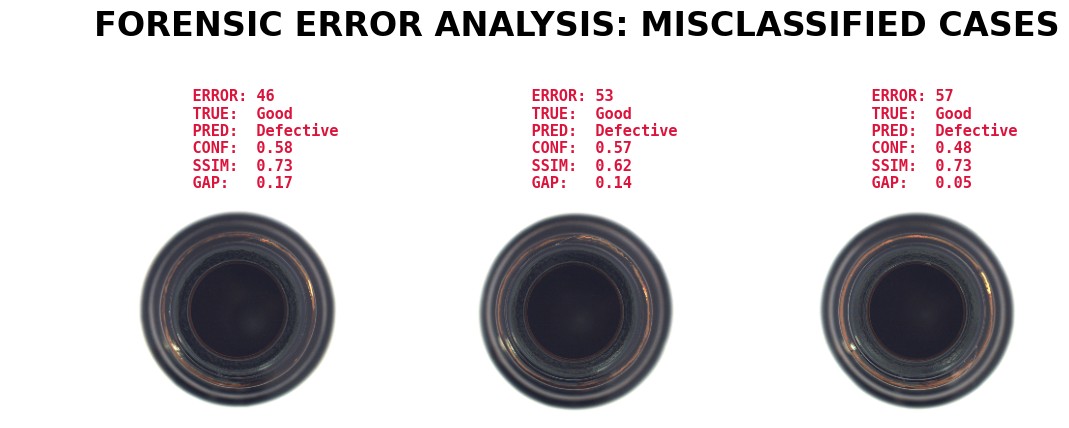

,METRIC,STATUS,MITIGATION / NOTES
1,VISUALIZATION ASSETS,✅ Stable,All evidence samples rendered successfully without spatial corruption.
2,FORENSIC LOG DATA,✅ Stable,Telemetry synchronization and memory mapping successful.
3,CSV ARCHIVE PERSISTENCE,✅ Stable,Evidence log exported and secured in local storage.
4,DATA INTEGRITY AUDIT,✅ Stable,Optimal reliability at 100.0%. Audit is scientifically valid.




⚠️ STAGE 2 COMPLETED: Forensic analysis finalized (Upstream warning inherited).




STAGE 3: STATISTICAL DIAGNOSTICS


         1. ERROR TOPOGRAPHY & DISTRIBUTION ANALYSIS




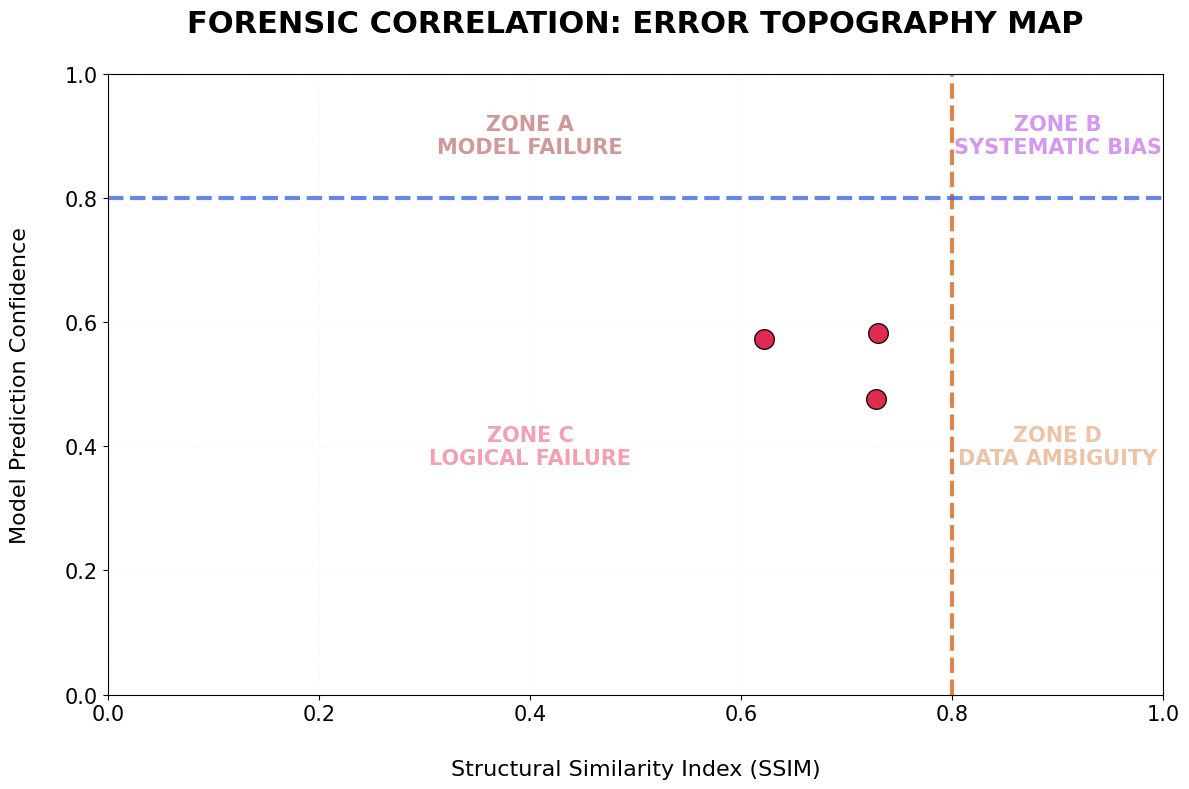

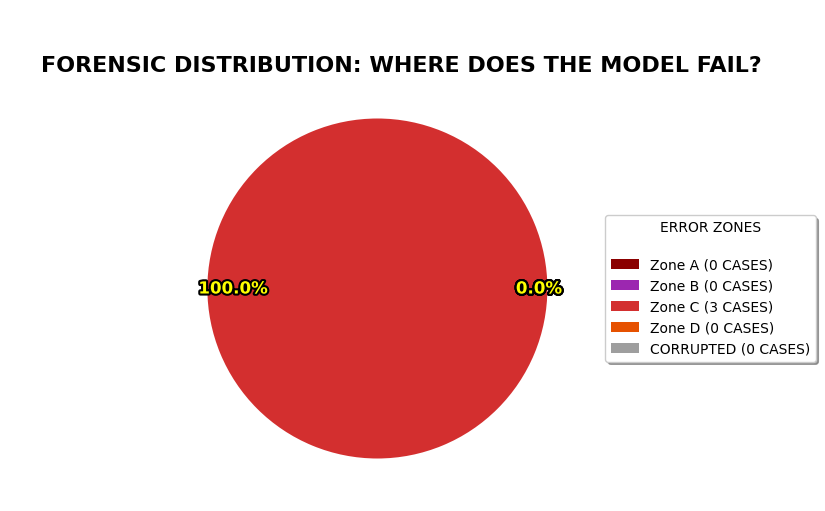

         2. ERROR TOPOGRAPHY INTERPRETATION GUIDE



,ZONE,DESCRIPTION,CRITICALITY,PRIMARY CAUSE
1,Zone A,Model Failure,High,Shortcut Learning / Glare Focus
2,Zone B,Systematic Bias,Extreme,Feature Misinterpretation
3,Zone C,Logical Failure,Normal,General Feature Weakness
4,Zone D,Data Ambiguity,Low,Justified Image Confusion




         3. INTEGRATED FORENSIC ANALYSIS SUMMARY



,FORENSIC ZONE,ERROR COUNT,AVG SSIM,AVG CONFIDENCE
1,Zone C,3,0.6931,0.5438




         4. FINAL SCIENTIFIC VERDICT & STRATEGIC ACTIONS (SSIM REFERENCE)





⚠️ STAGE 3 COMPLETED: Diagnostics finalized with upstream integrity warnings.




STAGE 4: FORENSIC CONCLUSION SUMMARY





⚠️ STAGE 4 COMPLETED: Strategic verdict generated with inherited upstream warnings.




⚠️ BLOCK 9 COMPLETED: Analysis finalized with inherited upstream warnings.


In [16]:
# ===========================================================================================================================================================================================================================================
# BLOCK 9: FORENSIC ERROR ANALYSIS (WALL OF SHAME & SSIM DIAGNOSTICS)
# ===========================================================================================================================================================================================================================================

# Forensic analysis of model failures with computer vision metrics
#
# 1. VISUALIZATION: Misclassified image display with fixed-layout pagination system
# 2. SSIM CHECK: Structural Similarity Index (SSIM) for scientific validation
#    - High SSIM (>0.80): Data ambiguity
#    - Low SSIM (<0.50): Model error
# 3. EVIDENCE LOGGING: Automatic folder storage for retraining
# ===========================================================================================================================================================================================================================================

# ADVANCED FORENSIC DIAGNOSTICS

# Diagnostic sequence with automated telemetry
print("EXECUTING ADVANCED INDUSTRIAL FORENSIC PIPELINE...\n")

print("ACTION: Multi stage system audit, error isolation & SSIM topography mapping. Interpretation, analysis,")
print("        memory safe visualization & strategic industrial verdict export.")

industrial_ui.draw_line()


# Reset of forensic buffer to prevent stale data consumption from previous runs
stats_log = []


# ===========================================================================================================================================================================================================================================
# STAGE 1: SYSTEM AUDIT & INITIALIZATION
# ===========================================================================================================================================================================================================================================

print("\n\nSTAGE 1: SYSTEM AUDIT & INITIALIZATION\n")


# PIPELINE INTEGRITY VERIFICATION

# Baseline system state and data stream validation.
system_integrity.validate_pipeline_integrity(model, IMG_SIZE, y_pred, y_true, validation_generator, y_pred_probs, history=history_finetuned)


# METRIC SYNCHRONIZATION

# Core variable extraction for downstream dependency management.
y_pred_classes = np.argmax(y_pred, axis=-1) if np.array(y_pred).ndim > 1 else np.array(y_pred)
y_pred_flat = y_pred_classes
total_samples = len(y_true)


# DATA SOURCE RE-SYNCHRONIZATION

# Fresh filename acquisition from the current generator state.
filenames = validation_generator.filenames


# DATA INTEGRITY GUARD

# Prediction and filename alignment check for scientific accuracy.
assert len(y_pred_classes) == len(filenames), f"Critical Mismatch: {len(y_pred_classes)} predictions vs {len(filenames)} files!"


# ERROR INDEX SYNCHRONIZATION

# Identification of misclassifications for forensic batching.
errors = np.where(y_pred_classes != y_true)[0]
total_errors = len(errors)


print()


# ACCURACY RESOLUTION

# Overall model precision calculation for dynamic thresholds.
test_acc = (total_samples - total_errors) / total_samples if total_samples > 0 else np.nan


# INFRASTRUCTURE MAPPING

# Baseline directory path retrieval and accessibility status.
current_val_dir = getattr(validation_generator, 'directory', 'Unknown')
path_status = "MISSING" if not os.path.exists(current_val_dir) else ("EMPTY" if total_samples == 0 else "Accessible")


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. PRECISION AUDIT & METRIC LOCKING
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("         1. PRECISION AUDIT & METRIC LOCKING\n")


# INDUSTRIAL AUDIT REPORTING

# Summary table generation with precision metrics and global status.
display(forensic_engine.render_precision_audit_table(test_acc, total_errors, total_samples, margin=101))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. FORENSIC ENGINE INITIALIZATION
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

print("\n\n         2. FORENSIC ENGINE INITIALIZATION\n")


# FORENSIC STORAGE SETUP

# Target directory definition for evidence archival.
evidence_dir = 'industrial_audit_evidence'


# DYNAMIC LOGIC RESOLUTION & INDUSTRIAL RENDERING

# Infrastructure health and performance initialization table execution via forensic engine.
display(forensic_engine.render_forensic_init_table(
    path_status=path_status,
    total_errors=total_errors,
    evidence_dir=evidence_dir,
    current_val_dir=current_val_dir,
    acc=test_acc,
    margin=101
))


# EVIDENCE SHARDING PROTOCOL

# Targeted directory creation for isolated forensic analysis.
if os.path.exists(evidence_dir):
    shutil.rmtree(evidence_dir)


os.makedirs(evidence_dir)


for z_folder in ['Zone_A', 'Zone_B', 'Zone_C', 'Zone_D']:
    os.makedirs(os.path.join(evidence_dir, z_folder), exist_ok=True)


# METRIC SANITIZATION

# Fallback condition for null or invalid variables.
is_invalid = pd.isna(test_acc)


# SYSTEM VERDICT NOTIFICATION

# Condition routing for pipeline flow and terminal messages.
if total_samples == 0:

    print("\n\n❌ STAGE 1 ABORTED: Zero validation samples detected. Downstream analysis suspension.")
    run_forensics = False

elif is_invalid:

    print("\n\n❌ STAGE 1 ABORTED: Invalid metric computation. Downstream analysis suspension.")
    run_forensics = False

elif test_acc == 1.0 and total_errors == 0:

    print("\n\n✅ STAGE 1 COMPLETED: Flawless execution. Perfect accuracy with zero errors.")
    run_forensics = True

elif test_acc >= 0.95:

    print("\n\n✅ STAGE 1 COMPLETED: Excellent results within specifications, minor deviations present.")
    run_forensics = True

elif test_acc >= 0.85:

    print("\n\n⚠️ STAGE 1 COMPLETED: Marginal stability. Metrics in the lower acceptable boundary.")
    run_forensics = True
    

else:

    print("\n\n❌ STAGE 1 ABORTED: Unacceptable metric degradation. Downstream analysis suspension.")
    run_forensics = False


industrial_ui.draw_line()


# ===========================================================================================================================================================================================================================================
# STAGE 2: VISUAL ERROR INSPECTION
# ===========================================================================================================================================================================================================================================

# VISUAL ANALYSIS INITIALIZATION

# Conditional transition into deep inspection based on performance signals.
if run_forensics:

    processed_samples = 0
    failed_samples = 0


    print("\n\nSTAGE 2: VISUAL ERROR INSPECTION\n")


    # REFERENCE ASSET PROVISIONING

    # Automated population of baseline reference images for structural comparison.
    ref_root = "industrial_reference_assets"

    
    for sub in ["good", "defective"]:
        ref_path = os.path.join(ref_root, sub)

        
        if not os.path.exists(ref_path) or not os.listdir(ref_path):

            os.makedirs(ref_path, exist_ok=True)
            src_dir = os.path.join(current_val_dir, sub)

            
            if os.path.exists(src_dir) and os.listdir(src_dir):
                valid_samples = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                
                if valid_samples:
                    shutil.copy(os.path.join(src_dir, valid_samples[0]), os.path.join(ref_path, "baseline_ref.jpg"))


    # EXECUTION GATEWAY

    # Anomaly detection state and skip-protocol evaluation.
    if total_errors == 0:


        # OPTIMAL PERFORMANCE BANNER

        # Zero defect state identification and reporting.
        banner_html = industrial_ui.render_industrial_banner(
            title="FORENSIC AUDIT SYNC",
            message="Optimal model performance achieved. Visual error analysis bypassed.",
            icon="✅",
            bg_color="#f2fff2",
            top=0,
            bottom=0,
            left=78
        )

        display(HTML(f'<div style="display: table;">{banner_html}</div>'))

        print("\n\n✅ STAGE 2 COMPLETED: Validated zero error stream. Ideal model performance.")

        industrial_ui.draw_line()
        

        run_forensics = False
        stats_log = []


    else:

        run_forensics = True


        print(f"\n         INITIATING DEEP INSPECTION (BATCH VISUALIZATION)...\n")


        # INTERNAL PROTOCOL GUARD

        # Misclassification dataset consistency validation.
        if len(errors) == 0 or len(filenames) == 0:


            # CRITICAL PROTOCOL FAILURE BANNER

            # Internal metadata mismatch and integrity loss notification.
            banner_html = industrial_ui.render_industrial_banner(
                title="CRITICAL PROTOCOL FAILURE",
                message="Forensic telemetry mismatch. Internal error dataset integrity compromised.",
                icon="❌",
                bg_color = "#ffebee",
                top=0,
                bottom=0,
                left=80
            )
            
            display(HTML(f'<div style="display: table;">{banner_html}</div>'))

            print("\n\n❌ STAGE 2 ABORTED: Protocol mismatch. Internal error count inconsistency. Pipeline preservation.")

            industrial_ui.draw_line()


            run_forensics = False
            stats_log = []


        else:

            BATCH_SIZE = 6
            total_batches = math.ceil(total_errors / BATCH_SIZE)
            prob_array = system_utils.extract_forensic_probabilities(y_pred_probs)


            # FORENSIC TELEMETRY BUFFER

            # Global cross batch statistical archival repository.
            stats_log = []

 
            for batch_num, start_idx in enumerate(range(0, total_errors, BATCH_SIZE)):

                end_idx = min(start_idx + BATCH_SIZE, total_errors)
                current_batch_indices = errors[start_idx : end_idx]


                # BATCH VISUALIZATION LOGIC                

                # Iterative gridbased inspection and figure setup.
                print ()

                fig = plt.figure(figsize=(11, 8))
                gs = gridspec.GridSpec(2, 6, figure=fig, left=0.05, right=0.95, top=0.78, bottom=0.05, wspace=0.2, hspace=0.7)
                axes_list = system_utils.setup_batch_grid(len(current_batch_indices), fig, gs)

                plt.suptitle("FORENSIC ERROR ANALYSIS: MISCLASSIFIED CASES", fontsize=24, fontweight='bold', y=1.02) 


                # MISSING ASSET TRACKING                

                # Temporary storage for batch specific missing filenames.
                missing_batch_assets = []


                # RESILIENT BATCH PROCESSING
                # Sample wise execution with individual failure isolation.
                for i, idx in enumerate(current_batch_indices):


                    # POSITIONAL SLOT BINDING

                    # Axis allocation for specific forensic indices.
                    ax = axes_list[i]
                    fname = filenames[idx]
                    img_path = os.path.join(current_val_dir, fname)
                    img = cv2.imread(img_path)

                    
                    # ASSET INTEGRITY VALIDATION

                    # Sample wise physical asset accessibility check and corruption logging.
                    if img is None:

                        missing_batch_assets.append(fname)
                        failed_samples += 1

                        # Architectural logging of corrupted physical assets
                        stats_log.append({
                            'filename': fname, 'true': "Unknown", 'pred': "Corrupted",
                            'conf': 0.0, 'ssim': 0.0, 'color': '#9e9e9e', 
                            'zone': 'CORRUPTED', 'gap': 0.0 
                        })

                        ax.axis('off')                        

                        continue
                        

                    img_res = cv2.resize(img, IMG_SIZE)
                    img_rgb = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)
                    img_gray = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)

                    true_lab_txt = "Good" if y_true[idx] == 1 else "Defective"
                    pred_lab_txt = "Good" if y_pred_flat[idx] == 1 else "Defective"
                    conf = np.max(y_pred_probs[idx])


                    # METRIC COMPUTATION PHASE

                    # Localized structural similarity and zone audit.
                    ssim_score, text_color, l_suffix, s_suffix, zone = forensic_engine.run_ssim_zone_audit(img_gray, "industrial_reference_assets", pred_lab_txt, IMG_SIZE, conf)
                    

                    # SCORE RANGE VERIFICATION

                    # Exclusion and logging of invalid forensic metrics.
                    if ssim_score < 0:
                        failed_samples += 1

                        # Architectural logging of corrupted physical assets
                        stats_log.append({
                            'filename': fname, 'true': "Unknown", 'pred': "Corrupted",
                            'conf': 0.0, 'ssim': 0.0, 'color': 'gray', 
                            'zone': 'CORRUPTED', 'gap': 0.0 
                        })

                        ax.axis('off')

                        continue
                    

                    # EVIDENCE CACHING

                    # Forensic metadata storage and physical asset persistence.
                    gap_val = abs(conf - (1 - conf))

                    stats_log.append({
                        'filename': fname, 'true': true_lab_txt, 'pred': pred_lab_txt,
                        'conf': conf, 'ssim': ssim_score, 'color': text_color, 
                        'zone': zone, 'gap': gap_val
                    })
                    
                    cv2.imwrite(os.path.join(evidence_dir, zone.replace(" ", "_"), f"err_{idx}_{os.path.basename(fname)}"), img_res)

                    ax.imshow(img_rgb)
                    ax.axis('off')

                    
                    info_text = f"""
                    ERROR: {idx}
                    TRUE:  {true_lab_txt}
                    PRED:  {pred_lab_txt}{l_suffix}   
                    CONF:  {conf:.2f}  
                    SSIM:  {ssim_score:.2f}{s_suffix}     
                    GAP:   {gap_val:.2f}"""
                    
                    ax.text(-0.55, 1.05, info_text, transform=ax.transAxes, fontsize=11, fontweight='bold', fontname='monospace', color=text_color, va='bottom', ha='left')
                    processed_samples += 1


                plt.show()
                plt.close(fig)


                # POST VISUALIZATION MISSING ASSET ALERT

                # Banner generation for missing physical files on disk.
                if missing_batch_assets:
                    
                    print("\n")

                    asset_word = "asset" if len(missing_batch_assets) == 1 else "assets"
                    missing_files_str = ", ".join(missing_batch_assets)

                    banner_html = industrial_ui.render_industrial_banner(
                        title="MISSING PHYSICAL ASSETS",
                        message=f"<span style='color: red; font-weight: bold;'>{len(missing_batch_assets)}</span> physical {asset_word} missing from disk and displayed as blank gaps: <b style='color: blue;'>{missing_files_str}</b>",
                        icon="⚠️",
                        bg_color="#fff9e6",
                        left=76
                    )

                    display(HTML(f'<div style="display: table;">{banner_html}</div>'))


            # FORENSIC LOGGING PERSISTENCE

            # Structural metadata export for industrial forensic archival.
            print("\n")

            csv_status = 0

            if stats_log:

                try:

                    # CSV DISK WRITING

                    # Forensic log serialization and storage.
                    pd.DataFrame(stats_log).drop(columns=['color'], errors='ignore').to_csv('forensic_audit_log.csv', index=False)
                    csv_status = 2

                except Exception:
                    csv_status = 0


            # INTEGRITY METRIC EVALUATION

            # Quantitative data reliability and audit quality assessment.
            if (processed_samples + failed_samples) > 0:
                
                integrity_ratio = processed_samples / (processed_samples + failed_samples)

            else:

                integrity_ratio = float('nan')


            # STATUS STATE RESOLUTION

            # Pipeline outcome mapping for industrial reporting logic.
            viz_state = 2 if failed_samples == 0 and processed_samples > 0 else (1 if processed_samples > 0 else 0)
            log_state = 2 if stats_log else 0
            csv_state = 2 if csv_status == 2 else 0

            
            if np.isnan(integrity_ratio): 
                integrity_state = 0
                
            elif integrity_ratio >= 0.95: 
                integrity_state = 2


            elif integrity_ratio >= 0.85: 
                integrity_state = 1

            else: 
                integrity_state = 0


            # DYNAMIC MESSAGING PROTOCOL

            # Operational outcome explanation and status color coordination.
            if viz_state == 2: 
                viz_msg = "All evidence samples rendered successfully without spatial corruption."

            elif viz_state == 1: 
                viz_msg = f"Partial degradation. Skipped {failed_samples} corrupted physical assets."

            else: 
                viz_msg = "Critical failure. Zero valid samples rendered. Check disk integrity."


            if log_state == 2:
                log_msg = "Telemetry synchronization and memory mapping successful."

            else: 
                log_msg = "Stream disruption. Failed to cache forensic data in memory."


            if csv_state == 2: 
                csv_msg = "Evidence log exported and secured in local storage."

            else: 
                csv_msg = "Disk write failure. Operating system denied write permission."


            if np.isnan(integrity_ratio): 
                int_msg = "Integrity calculation failure (NaN). Divisor zero due to empty batch."

            elif integrity_state == 2: 
                int_msg = f"Optimal reliability at {integrity_ratio:.1%}. Audit is scientifically valid."

            elif integrity_state == 1: 
                int_msg = f"Marginal reliability at {integrity_ratio:.1%}. Caution required."

            else: 
                int_msg = f"Critical data loss at {integrity_ratio:.1%}. Audit quality compromise."


            # ARCHIVE TASK CONFIGURATION            

            # Forensic record population with diagnostic metrics.
            archive_tasks = [
                ("VISUALIZATION ASSETS", viz_state, viz_msg),
                ("FORENSIC LOG DATA", log_state, log_msg),
                ("CSV ARCHIVE PERSISTENCE", csv_state, csv_msg),
                ("DATA INTEGRITY AUDIT", integrity_state, int_msg)
            ]


            # STATUS DISPLAY EXECUTION

            # Industrial status archive projection via the forensic engine.
            display(industrial_ui.display_archive_status(archive_tasks, margin=76))


            # DEGRADED DATA ALERT

            # Integrity loss warning for audit quality compromise.
            if not np.isnan(integrity_ratio) and integrity_ratio < 0.85:

                print("\n")

                banner_html = industrial_ui.render_industrial_banner(
                    title="DEGRADED DATA WARNING",
                    message=f"Forensic integrity at {integrity_ratio:.1%}. Audit quality compromised.",
                    icon="⚠️",
                    bg_color="#fff9e6",
                    left=76
                )

                display(HTML(f'<div style="display: table;">{banner_html}</div>'))


            # PIPELINE HEALTH CONSOLIDATION

            # Stage 2 instability signal unification for downstream inheritance.
            stage2_failed = np.isnan(integrity_ratio) or integrity_state == 0
            marginal_state = integrity_state == 1 or test_acc < 0.95
            stage2_unstable = stage2_failed or marginal_state


            # TERMINATION SEQUENCE

            # Terminal output logic with severity prioritization.
            if np.isnan(integrity_ratio):
                print(f"\n\n❌ STAGE 2 FAILED: Forensic analysis failure. Zero valid samples.")

            elif stage2_failed and (log_state == 0 or csv_state == 0):
                print(f"\n\n❌ STAGE 2 FAILED: Multiple critical failures (Audit & Storage).")

            elif stage2_failed:
                print(f"\n\n❌ STAGE 2 FAILED: Forensic analysis conclusion with critical data loss.")

            elif stage2_unstable:
                print(f"\n\n⚠️ STAGE 2 COMPLETED: Forensic analysis finalized (Upstream warning inherited).")

            else:
                print(f"\n\n✅ STAGE 2 COMPLETED: Forensic analysis success.")


            industrial_ui.draw_line()


else:

    print("\n\nSTAGE 2: VISUAL ERROR INSPECTION\n")


    # STAGE 2 BYPASS BANNER

    # Visual notification for forensic inspection suspension.
    bypass_banner_2 = industrial_ui.render_industrial_banner(
        title="VISUAL INSPECTION SUSPENDED",
        message="Visual error inspection bypassed due to Stage 1 metric instability.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=78
    )
    
    display(HTML(f'<div style="display: table;">{bypass_banner_2}</div>'))

    print("\n\n⚠️ STAGE 2 BYPASSED: Visual error inspection suspended due to Stage 1 instability.")

    industrial_ui.draw_line()     

    
# ===========================================================================================================================================================================================================================================
# STAGE 3: STATISTICAL DIAGNOSTICS
# ===========================================================================================================================================================================================================================================

# ANALYTICS GATEWAY

# Upstream telemetry and performance state evaluation.
run_analytics = 'stats_log' in locals() and len(stats_log) > 0
is_perfect = 'total_errors' in locals() and total_errors == 0 and test_acc == 1.0


if run_analytics:

    print("\n\nSTAGE 3: STATISTICAL DIAGNOSTICS\n")


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. ERROR TOPOGRAPHY & DISTRIBUTION ANALYSIS
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n         1. ERROR TOPOGRAPHY & DISTRIBUTION ANALYSIS\n")
    

    if 'total_errors' not in locals():        
            total_errors = len(stats_log)

        
    # SCHEMA VERIFICATION

    # Forensic dictionary structure validation for error prevention.
    schema_breach = any(not all(k in s for k in ['ssim', 'conf', 'zone', 'color']) for s in stats_log)

    if schema_breach:
        schema_banner = industrial_ui.render_industrial_banner(
            title="CRITICAL SCHEMA BREACH",
            message = "Internal metadata structure is corrupted (Missing keys). Forensic engine cannot proceed.",
            icon="🛑",
            bg_color="#ff415196",
            left=101
        )

        display(HTML(f'<div style="display: table;">{schema_banner}</div>'))

        print("\n\n❌ STAGE 3 FAILED: Internal metadata corruption detected during diagnostic topography.")

        print("\n\n" + "-" * 103  + "\n\n")


        # HARD STOP: System integrity compromised.
        raise RuntimeError("⛔ STAGE 3 ABORTED: Internal metadata corruption. Schema breach detected.")


    # NUMERICAL STABILITY AUDIT

    # Identification of corrupted or unstable statistical values.
    numerical_instability = any(np.isnan(s['ssim']) or np.isnan(s['conf']) for s in stats_log)

    if numerical_instability:
        drift_banner = industrial_ui.render_industrial_banner(
            title="STATISTICAL DRIFT DETECTED",
            message = "Numerical instability identified in forensic buffers. Topography accuracy might be compromised.",
            icon="❌", 
            bg_color="#ff415196",
            left=101
        )

        display(HTML(f'<div style="display: table;">{drift_banner}</div>'))

        print("\n\n❌ STAGE 3 FAILED: Numerical instability in forensic buffers. Topography accuracy compromise.")

        print("\n\n" + "-" * 103  + "\n\n")


        # HARD STOP: Math integrity compromised.
        raise RuntimeError("⛔ STAGE 3 ABORTED: Numerical instability (NaN values detected).")    

    
    # SYNCHRONIZATION DRIFT MONITOR

    # Partial telemetry loss detection between forensic stages.
    valid_logged = len([s for s in stats_log if s['zone'] != 'CORRUPTED'])
    sync_drift = valid_logged != total_errors

    if sync_drift:
        sync_banner = industrial_ui.render_industrial_banner(
            title="FORENSIC DATA LOSS ALERT",
            message = f"Statistical synchronization mismatch. Analyzing {len(stats_log)} of {total_errors} errors.",
            icon="⚠️",
            bg_color="#fff9e6",
            left=101
        )

        display(HTML(f'<div style="display: table; margin-bottom: 20px;">{sync_banner}</div>')) 


    # ERROR TOPOGRAPHY MAPPING
    
    # Confidence and structural similarity relationship visualization.
    plt.figure(figsize=(12, 8))

    print()    

    for s in stats_log:
        
        if s['zone'] != 'CORRUPTED':
            plt.scatter(s['ssim'], s['conf'], c=s['color'], s=200, edgecolors='black', alpha=0.9, zorder=5)


    # INDUSTRIAL BOUNDARY DEFINITION

    plt.axvline(0.80, color='chocolate', linestyle='--', linewidth=3, alpha=0.8, zorder=2)
    plt.axhline(0.80, color='royalblue', linestyle='--', linewidth=3, alpha=0.8, zorder=2)


    # QUADRANT WATERMARKING
    
    watermark_style = dict(fontsize=15, fontweight='bold', alpha=0.4, zorder=1, ha='center', va='center')

    plt.text(0.40, 0.90, "ZONE A\nMODEL FAILURE", color='darkred', **watermark_style)
    plt.text(0.90, 0.90, "ZONE B\nSYSTEMATIC BIAS", color='darkviolet', **watermark_style)
    plt.text(0.40, 0.40, "ZONE C\nLOGICAL FAILURE", color='crimson', **watermark_style)
    plt.text(0.90, 0.40, "ZONE D\nDATA AMBIGUITY", color='chocolate', **watermark_style)

    plt.title("FORENSIC CORRELATION: ERROR TOPOGRAPHY MAP", fontsize=22, fontweight='bold', pad=30)
    plt.xlabel("Structural Similarity Index (SSIM)", fontsize=16, labelpad=25)
    plt.ylabel("Model Prediction Confidence", fontsize=16, labelpad=25)
    plt.grid(True, alpha=0.15, linestyle=':', zorder=0)

    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.tight_layout()
    plt.show()


    # ERROR TOPOGRAPHY DISTRIBUTION

    # Proportional error density analysis across forensic zones.
    zone_counts = {'Zone A': 0, 'Zone B': 0, 'Zone C': 0, 'Zone D': 0, 'CORRUPTED': 0}

    for s in stats_log: 
        zone_counts[s['zone']] += 1


    fig, ax = plt.subplots(figsize=(5, 5))

    wedges, texts, autotexts = ax.pie(list(zone_counts.values()), labels=None, autopct='%1.1f%%', 
                                      startangle=0, colors=['#8b0000', '#9C27B0', '#d32f2f', '#e65100', '#9e9e9e'], 
                                      pctdistance=0.85, explode=[0.05]*5)

    legend_labels = [f"{l} ({zone_counts[l]} {'CASE' if zone_counts[l]==1 else 'CASES'})" for l in zone_counts.keys()]
    plt.setp(autotexts, size=12, weight="bold", color="yellow")

    for autotext in autotexts: autotext.set_path_effects([path_effects.withStroke(linewidth=3, foreground='black')])
    ax.legend(wedges, legend_labels, title="ERROR ZONES\n", loc="center left", shadow=True, bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title("\n\n    FORENSIC DISTRIBUTION: WHERE DOES THE MODEL FAIL?", fontsize=16, fontweight='bold', pad=0)

    plt.subplots_adjust(left=0.1, right=0.95, top=0.85, bottom=0)
    plt.show()

    
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. ERROR TOPOGRAPHY INTERPRETATION GUIDE
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("         2. ERROR TOPOGRAPHY INTERPRETATION GUIDE\n")


    # INTERPRETATION MATRIX DEFINITION

    # Analytical cause mapping for specific forensic zones.
    guide_df = pd.DataFrame({
        'ZONE': ['Zone A', 'Zone B', 'Zone C', 'Zone D'],
        'DESCRIPTION': ['Model Failure', 'Systematic Bias', 'Logical Failure', 'Data Ambiguity'],
        'CRITICALITY': ['High', 'Extreme', 'Normal', 'Low'],
        'PRIMARY CAUSE': ['Shortcut Learning / Glare Focus', 'Feature Misinterpretation', 'General Feature Weakness', 'Justified Image Confusion'],
        'CLR': ['darkred', 'darkviolet', 'crimson', 'chocolate']
    })


    # INDUSTRIAL TABLE RENDERING

    # Forensic guide presentation with zone specific coloring.
    display(industrial_ui.render_industrial_table(guide_df, title_bg='#c8e6c9', margin=101))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. INTEGRATED FORENSIC ANALYSIS SUMMARY
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n\n         3. INTEGRATED FORENSIC ANALYSIS SUMMARY\n")
    

    # STATISTICAL SUMMARIZATION

    # Quantitative zone distribution and performance diagnostic summary.
    summary_list = []

    for z in ['Zone A', 'Zone B', 'Zone C', 'Zone D', 'CORRUPTED']:
        z_stats = [s for s in stats_log if s['zone'] == z]

        if z_stats:

            count = len(z_stats)
            avg_conf = np.mean([s['conf'] for s in z_stats])
            avg_ssim = np.mean([s['ssim'] for s in z_stats])

            clr_val = forensic_engine.get_zone_style(z) if z != 'CORRUPTED' else '#9e9e9e'

            summary_list.append({
                'FORENSIC ZONE': z,
                'ERROR COUNT': count,
                'AVG SSIM': f"{avg_ssim:.4f}",
                'AVG CONFIDENCE': f"{avg_conf:.4f}",
                'CLR': clr_val
            })


    # HYBRID ANALYTICS REPORTING

    # Presentation of integrated forensic metrics in industrial format.
    if summary_list:

        summary_df = pd.DataFrame(summary_list)
        display(industrial_ui.render_industrial_table(summary_df, title_bg='#ffe0b2', margin=101))


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 4. FINAL SCIENTIFIC VERDICT & STRATEGIC ACTIONS (SSIM REFERENCE)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n\n         4. FINAL SCIENTIFIC VERDICT & STRATEGIC ACTIONS (SSIM REFERENCE)\n")

    
    # SCIENTIFIC VERDICT RENDERING

    # Structural similarity reference guide and action plan projection.
    display(HTML(industrial_ui.render_scientific_verdict()))


    # STAGE 3 COMPLETION STATUS

    # Diagnostics finalization with upstream integrity evaluation.
    if stage2_unstable or sync_drift:

        print("\n\n⚠️ STAGE 3 COMPLETED: Diagnostics finalized with upstream integrity warnings.")

    else:
        
        print("\n\n✅ STAGE 3 COMPLETED: Statistical diagnostics, topography mapping, and summary synchronization.")


    industrial_ui.draw_line() 
    

# ===========================================================================================================================================================================================================================================
# STAGE 4: FORENSIC CONCLUSION SUMMARY
# ===========================================================================================================================================================================================================================================

    print("\n\nSTAGE 4: FORENSIC CONCLUSION SUMMARY\n")


    # DOMINANT ERROR RESOLUTION

    # Primary failure mechanism identification within the topographical map.
    zone_counts = {z: sum(1 for s in stats_log if s['zone'] == z) for z in ['Zone A', 'Zone B', 'Zone C', 'Zone D']}
    dominant_zone = max(zone_counts, key=zone_counts.get)


    # STRATEGIC VERDICT GENERATION
    
    # Extraction of the final validation loss for performance evaluation.
    current_val_loss = history_finetuned.history.get('val_loss', [0.0])[-1]
    
    
    # ZONE STYLING LOGIC
    
    # Color and icon assignment for the dominant forensic zone.
    zone_styles = {'Zone A': ('🛑', '#8b0000'), 'Zone B': ('🛑', '#9C27B0'), 'Zone C': ('⚠️', '#d32f2f'), 'Zone D': ('🔍', '#e65100')}
    v_icon, v_color = zone_styles.get(dominant_zone, ('❓', '#757575'))

    
    # DIAGNOSTIC TEXT RESOLUTION
    
    # Extraction of specific narrative strings based on zone dominance.
    perf_message = f"The system reached a final validation loss of {current_val_loss:.4f}, which indicates that while the global convergence is stable, the model still encounters a generalization floor when faced with complex structural variances."

    
    if dominant_zone == 'Zone A':
        
        verdict = "The model demonstrates a significant misalignment between its internal feature extraction and the actual structural properties of the image. Even though the structural similarity is low, the neural network remains overly confident in a false decision."
        conclusion = "This suggests that the model has learned to prioritize specific pixel clusters or global patterns that do not correlate with the actual defect morphology, leading to stubborn and illogical misclassifications."
        viability = "Deploying the model in this state presents a high risk for industrial automation, as it may bypass obvious defects while maintaining a false sense of reliability."

    elif dominant_zone == 'Zone B':
        
        verdict = "A systematic bias is present where the model relies on non-structural features to make high-confidence decisions. Since the structural similarity to the reference class is high, the model is likely falling victim to shortcut learning or the clever hans effect."
        conclusion = "The decision-making process is decoupled from the actual defect signatures. It is highly probable that environmental factors, such as specific lighting angles or background textures, are being misinterpreted as class-discriminant features."
        viability = "The system is currently unreliable for production. An audit of the training environment and data collection process is necessary to eliminate these shortcut biases."

    elif dominant_zone == 'Zone C':
        
        verdict = "The model identifies a lack of structural similarity but fails to converge on a correct decision, resulting in low-confidence errors. This indicates a general weakness in the localized feature extraction layers."
        conclusion = "The internal representation of the defect is fragmented, meaning the receptive fields are not effectively capturing the unique geometric or textural properties required for a stable classification."
        viability = "The model shows potential but requires refinement through hard-negative mining or more diverse training samples to strengthen its logical feature mapping."

    # Zone D
    else: 
        
        verdict = "The error is scientifically justified as the structural properties of the misclassified sample are almost identical to those of the reference class. The model correctly signals uncertainty in a high-ambiguity scenario."
        conclusion = "This overlap suggests that the discriminating features are either too subtle for the current resolution or that there is a natural morphological convergence between the class patterns."
        viability = "The model is behaving rationally under the provided data constraints. Improvement would likely require higher sensor resolution to break the structural tie between categories."

    
    # PAYLOAD DICTIONARY CONSTRUCTION
    
    # Integration of the diagnostic narrative into the structural ui payload.
    card_payload = {
        "PRIMARY MODE:": (f"{dominant_zone.upper()} DOMINANCE", v_color),
        "VERDICT:": verdict,
        "CONCLUSION:": conclusion,
        "PERFORMANCE:": perf_message,
        "VIABILITY:": (viability, v_color)
    }

    display(HTML(industrial_ui.render_universal_card(f"{v_icon} DIAGNOSTIC ANALYSIS: {dominant_zone.upper()} DETECTED", v_color, card_payload)))
    

    # STAGE 4 COMPLETION STATUS

    # Strategic verdict confirmation based on global pipeline health.
    if stage2_unstable or sync_drift:

        print("\n\n⚠️ STAGE 4 COMPLETED: Strategic verdict generated with inherited upstream warnings.")

    else:

        print("\n\n✅ STAGE 4 COMPLETED: Strategic verdict confirmed. Optimal state validated.")


    industrial_ui.draw_line()


    # BLOCK 9 FINALIZATION

    # Integrity gatekeeper and terminal status selection.
    if stage2_unstable or sync_drift:

        print("\n\n⚠️ BLOCK 9 COMPLETED: Analysis finalized with inherited upstream warnings.")

    else:

        print("\n\n✅ BLOCK 9 COMPLETED: Forensic analysis success.")

        
elif is_perfect:

    
    # PERFECTION PROTOCOL

    # Automated reporting for zero-defect state validation.
    current_val_loss = history_finetuned.history.get('val_loss', [0.0])[-1]


    print("\n\nSTAGE 3: STATISTICAL DIAGNOSTICS\n")


    # INDUSTRIAL BYPASS BANNER

    # Zero error stream notification and diagnostics suspension.
    stage3_bypass_banner = industrial_ui.render_industrial_banner(
        title="DIAGNOSTICS BYPASSED",
        message="Zero error stream detected. Statistical topography and distribution analysis are unnecessary.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )

    display(HTML(f'<div style="display: table;">{stage3_bypass_banner}</div>'))

    print("\n\n✅ STAGE 3 COMPLETED: Statistical diagnostics bypassed. Zero error stream.")

    industrial_ui.draw_line()


    print("\n\nSTAGE 4: STRATEGIC VERDICT (OPTIMAL STATE)\n")
    

    # PERFECTION VERDICT RENDERING
    
    # Narrative payload structure for the zero error industrial report.
    card_payload = {
        "VERDICT:": "The zero-error stream indicates that the feature extraction engine has fully internalized all target signatures, successfully mapping the data distribution without categorical gaps.",
        "PERFORMANCE:": f"Absolute precision achieved. The validation loss of <b style=\"color: #2e7d32; font-weight: bold\">{current_val_loss:.4f}</b> confirms total mathematical convergence and stability within the latent feature space.",
        "VIABILITY:": ("Scientific audit confirms that the model is ready for high-precision tasks. All categorical criteria for distributional stability and metric reliability are satisfied.", "#2e7d32")
    }
    
    display(HTML(industrial_ui.render_universal_card("🏆 ABSOLUTE METRIC PERFECTION", "#2e7d32", card_payload)))
    
    
    # STAGE 4 COMPLETION STATUS

    # Final strategic verdict and optimal state validation.
    print("\n\n✅ STAGE 4 COMPLETED: Strategic verdict confirmed. Optimal state validated.")

    industrial_ui.draw_line()


    # BLOCK 9 TERMINATION

    # Absolute system perfection conclusion.
    print("\n\n✅ BLOCK 9 COMPLETED: Absolute system perfection.")


else:

    # PIPELINE SUSPENSION PROTOCOL

    # Automated analysis suspension due to critical upstream failure.
    print("\n\nSTAGE 3: STATISTICAL DIAGNOSTICS\n")


    # STAGE 3 BYPASS BANNER

    # Visual notification for statistical diagnostics suspension.
    bypass_banner_3 = industrial_ui.render_industrial_banner(
        title="DIAGNOSTICS SUSPENDED",
        message="Statistical diagnostics bypassed due to upstream pipeline instability.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=78
    )

    display(HTML(f'<div style="display: table;">{bypass_banner_3}</div>'))

    print("\n\n⚠️ STAGE 3 BYPASSED: Statistical diagnostics suspended due to upstream instability.")

    industrial_ui.draw_line()


    print("\n\nSTAGE 4: FORENSIC CONCLUSION SUMMARY\n")
   

    # STAGE 4 BYPASS BANNER

    # Visual notification for strategic verdict suspension.
    bypass_banner_4 = industrial_ui.render_industrial_banner(
        title="VERDICT SUSPENDED",
        message="Strategic verdict generation bypassed due to upstream pipeline instability.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=78
    )

    display(HTML(f'<div style="display: table;">{bypass_banner_4}</div>'))

    print("\n\n⚠️ STAGE 4 BYPASSED: Strategic verdict suspended due to upstream instability.")

    industrial_ui.draw_line()


    # BLOCK 9 TERMINATION
    
    # Terminal failure logging based on pipeline health.
    if not run_forensics:

        print("\n\n❌ BLOCK 9 FAILED: Critical metric instability in Stage 1. Analysis aborted.")

    else:

        print("\n\n❌ BLOCK 9 FAILED: Upstream telemetry loss. Downstream analytics suspension.")



# STAGE FINALIZATION

# silent resource reclamation for pipeline stability.
system_utils.finalize_stage("BLOCK 9", clear_vars=['df', 'forensic_df', 'guide_df', 'summary_df', 'img', 'img_res', 'img_rgb', 'img_gray'])

In [17]:
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# BLOCK 10: ROBUST GRAD-CAM (EXPLAINABLE AI VISUALIZATION)
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STRATEGIC ARCHITECTURE
# Feature extractor and classifier decoupling for gradient flow integrity.
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# EXECUTION HEADER PROJECTION

# Console initialization for comprehensive forensic audit.
industrial_ui.print_execution_header(
    title="INITIATING FORENSIC NEURAL AUDIT PROTOCOL...", 
    action_text="6 Stage neural attention mapping, spatial focus stability, and executive causal validation."
)


# UTILITY FUNCTIONS


# IMAGE CONTRAST OPTIMIZATION

# Histogram equalization for local feature contrast optimization.
def apply_clahe(image):
    
    if image is None:
        
        return None

    
    # CHROMINANCE ISOLATION
    
    # Chrominance isolation and L channel splitting.
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    return cv2.cvtColor(cv2.merge((clahe.apply(l), a, b)), cv2.COLOR_LAB2BGR)


# DIFFERENTIABLE ACTIVATION MAPPING

# Class activation mapping via differentiable feature extraction.
def make_gradcam_heatmap(img_array, full_model, last_conv_layer_name='out_relu'):
    
    
    # BACKBONE SUB-SAMPLING
    
    # Feature extraction from the primary neural backbone.
    base_model = full_model.layers[0]
    target_layer = base_model.get_layer(last_conv_layer_name)
    conv_model = Model(inputs=base_model.inputs, outputs=target_layer.output)

    
    # CLASSIFIER ISOLATION
    
    # Standalone diagnostic head for gradient backpropagation.
    classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
    x = classifier_input
    
    for layer in full_model.layers[1:]: x = layer(x)
        
    classifier_model = Model(inputs=classifier_input, outputs=x)

    
    # GRADIENT CALCULATION
    
    # Differentiable forward and backward pass for saliency mapping.
    with tf.GradientTape() as tape:
        
        last_conv_layer_output = conv_model(img_array)
        tape.watch(last_conv_layer_output)
        
        preds = classifier_model(last_conv_layer_output)
        class_idx = tf.argmax(preds[0])
        class_channel = preds[:, class_idx]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(last_conv_layer_output[0] * pooled_grads, axis=-1)
    
    return (tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)).numpy()


# SUB-PIXEL CENTROID LOCALIZATION

# Probability weighted coordinate derivation for spatial focus anchors.
def get_centroid(h):
    
    weights = h / (np.sum(h) + 1e-10)
    ny, nx = h.shape
    y_coords, x_coords = np.mgrid[:ny, :nx]
    
    return np.sum(y_coords * weights), np.sum(x_coords * weights)

    
# PRECEDING FAULT TRIAGE SYSTEM
    
# dependency evaluation and cascading failure logic for forensic diagnostics.
def get_pipeline_fault(stage_id):


    # EXTERNAL FAULT DIAGNOSTICS
    
    # Absence of neural network architecture in memory.
    if 'model' not in globals() or model is None:
        return "Neural Network Architecture Missing (Model object not found in memory)"
        
    # Absence of preceding block execution telemetry.
    if 'stats_log' not in globals():
        return "Preceding Block Execution Missing (Required telemetry not found)"
    
    # Preceding pipeline suspension indicator.
    if globals().get('is_halted', False):
        return f"Preceding Pipeline Interruption ({globals().get('halt_reason', 'Unknown')})"

    # Void in upstream data samples.
    if globals().get('total_samples', 0) == 0:
        return "Upstream Data Ingestion Void (Zero Samples)"

    
    # INTERNAL FAULT DIAGNOSTICS
    
    # Absence of stage 1 environment readiness.
    if stage_id >= 2 and not analysis_ready:
        return f"Stage 1 Environment Failure ({globals().get('env_signal', 'Unknown')})"
        
    # Absence of stage 2 forensic clearance.
    if stage_id >= 3 and not (run_forensics or is_perfect or is_clearance):
        return f"Stage 2 Forensic Sampling Failure ({globals().get('s_signal', 'Unknown')})"

    # Absence of stage 3 analytical telemetry.
    if stage_id >= 4 and not (run_status or is_perfect or is_clearance):
        return f"Stage 3 Analytical Telemetry Failure ({globals().get('l_signal', 'Unknown')})"

    # Absence of stage 4 visual synthesis.
    if stage_id >= 5 and not (visuals_ready or is_perfect or is_clearance):
        return f"Stage 4 Visual Synthesis Failure ({globals().get('v_signal', 'Unknown')})"
        
    # Absence of stage 5 scenario mapping.
    if stage_id >= 6 and not (verdict_ready or is_perfect or is_clearance):
        return f"Stage 5 Scenario Mapping Failure ({globals().get('verdict_signal', 'Unknown')})"
        
    return None


# GLOBAL STATE INITIALIZATION

# Default status flags and stage synchronization variables.
analysis_ready = False
run_forensics = False
run_status = False
visuals_ready = False
verdict_ready = False
is_perfect = False
is_clearance = False
is_halted = False
halt_reason = ""
env_signal = 'INITIALIZING'
s_signal = 'IDLE'
l_signal = 'PENDING'
v_signal = 'PENDING'
verdict_signal = 'PENDING'


# POLICY PARAMETERS

# Centralized decision layer configuration.
AUDIT_POLICY = {
    "architecture": {
        "target_layer": globals().get('target_to_find', 'out_relu'),
        "fallback_layer": 'out_relu'
    },
    "sampling": {
        "target_zone": 'Zone A',
        "gap_rejection_threshold_pct": 20.0
    },
    "thresholds": {
        "confidence": {"high": 85.0, "mid": 70.0, "low": 60.0, "grounding": 50.0},
        "spatial_shift": {"stable": 30.0, "marginal": 60.0, "unstable": 70.0},
        "ssim": {"high": 0.90, "mid": 0.80},
        "integrity_combo": {
            "high_tier": {"max_shift": 35.0, "min_conf": 80.0},
            "med_tier": {"max_shift": 70.0, "min_conf": 50.0}
        }
    },
    "labels": {
        "verified": "(VERIFIED)", "caution": "(CAUTION)", "unverified": "(UNVERIFIED)", "missing": "(MISSING)",
        "approach": {
            "integrated": "INTEGRATED\nFORENSIC",
            "augmented": "AUGMENTED\nFORENSIC",
            "standard": "STANDARD\nXAI ONLY",
        },
        "stability": {"optimal": "STABLE!", "marginal": "MARGINAL!", "collapse": "UNSTABLE!"}
    },
    "style": {
        "colors": {"success": "darkgreen", "warning": "darkorange", "critical": "red", "neutral": "darkblue"},
        "margin_main": 78,
        "margin_xai": 101
    }
}


# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# GLOBAL PIPELINE AUDIT & ENVIRONMENT VERIFICATION
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# GLOBAL PIPELINE AUDIT

# Baseline system state and data stream validation.
system_integrity.validate_pipeline_integrity(model, IMG_SIZE, y_pred, y_true, validation_generator, y_pred_probs, history=history_finetuned)


# METRIC SYNCHRONIZATION

# Prediction index conversion and dimensionality flattening.
y_pred_flat = np.argmax(y_pred, axis=-1).flatten() if y_pred.ndim > 1 else y_pred.flatten()


# GRAPH STABILIZATION

# Synthetic forward pass for session stabilization.
_ = model(tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3)))


# PATH DISCOVERY PROTOCOL

# Data source identification via generator metadata or fallback localized path.
v_gen = globals().get('validation_generator', None)
current_val_dir, env_signal = system_utils.verify_environment(v_gen)


# INDUSTRIAL STATUS RESOLUTION

# Categorical state resolution and theme aesthetic retrieval.
st, d_msg = forensic_engine.get_industrial_status('System Audit', None, found_status=env_signal)


# CORE STATE INITIALIZATION

# Environment signal evaluation for analysis readiness.
analysis_ready = env_signal in ['AUTO', 'FALLBACK']


# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STAGE 1: SYSTEM & ENVIRONMENT AUDIT
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 1:", "SYSTEM & ENVIRONMENT AUDIT")

print()


# EXTERNAL AND PRECEDING BLOCK FAULTS

# Pipeline dependency verification and upstream error isolation.
origin_fault = get_pipeline_fault(stage_id=1)


# BYPASS BANNER

# Audit suspension notification via industrial banner.
if origin_fault:
    
    bypass_banner_10_1 = industrial_ui.render_industrial_banner(
        title="ENVIRONMENT AUDIT SUSPENDED",
        message=f"Stage 1 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=72
    )
    
    display(HTML(bypass_banner_10_1))


    print("\n")

    industrial_ui.print_industrial_msg("⚠️ STAGE 1 BYPASSED:", f"System environment audit protocol suspended due to {origin_fault}.")
    

    # PIPELINE STATE TERMINATION
    
    # Analysis readiness and forensic flag state for bypass scenarios.
    analysis_ready = False
    run_forensics = False

    
    industrial_ui.draw_line()


else:
    
    # AUDIT REPORT GENERATION
    
    # Environment data buffer construction for audit logging.
    dir_df = pd.DataFrame({
        'PARAMETER': ['Status', 'Source Directory'], 
        'VALUE': [d_msg, current_val_dir],
        'CLR': [st['text'], 'black']
    })
    
    display(HTML(industrial_ui.render_industrial_table(dir_df, st['bg'], margin=72).to_html(escape=False)))


    if analysis_ready:

        
        # QUANTITATIVE ASSESSMENT
        
        # Error calculation and perfection state validation.
        total_errors = np.sum(y_pred_flat != y_true)
        is_perfect = (total_errors == 0)
    
        
        # SUCCESS CASE NOTIFICATION
    
        # Infrastructure lock confirmation via metadata.
        print("\n")
        
        if env_signal == 'AUTO':
            industrial_ui.print_industrial_msg("✅ STAGE 1 COMPLETED:", "Infrastructure locked via automated generator metadata.")
    
        else:
            industrial_ui.print_industrial_msg("✅ STAGE 1 COMPLETED:", "Infrastructure locked via localized fallback path discovery.")


        # FORENSIC ACTIVATION STRATEGY
        
        # Forensic sampling trigger based on perfection state validation.
        run_forensics = not is_perfect
    
        
        industrial_ui.draw_line()
    
    
    else:

        print("\n")

        
        # CATEGORICAL FAILURE DIAGNOSTICS
        
        # Target directory emptiness check.
        if env_signal == 'EMPTY':
            industrial_ui.print_industrial_msg("❌ STAGE 1 FAILED:", "Target directory detected but currently void of physical assets.")
    
        # Access permission breach check.
        elif env_signal == 'DENIED':
            industrial_ui.print_industrial_msg("❌ STAGE 1 FAILED:", "Security protocol breach. Insufficient read permissions for data source.")
    
        # Specified path existence check.
        elif env_signal == 'MISSING':
            industrial_ui.print_industrial_msg("❌ STAGE 1 FAILED:", "Infrastructure link failure. Specified telemetry path not found.")
    
        # Unknown environment fault check.
        else:
            industrial_ui.print_industrial_msg("❌ STAGE 1 FAILED:", "Environment audit unsuccessful. Visualization protocol bypassed.")
    
    
        # PIPELINE STATE TERMINATION
        
        # Forensic flag deactivation for environment failure scenarios.
        run_forensics = False
        
    
        industrial_ui.draw_line()

    
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STAGE 2: TARGETED FORENSIC SAMPLING
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 2:", "TARGETED FORENSIC SAMPLING")

print()


# FAULT EVALUATION

# Automated dependency triage for forensic sampling.
origin_fault = get_pipeline_fault(stage_id=2)


# BYPASS PROTOCOL NOTIFICATION

# Audit suspension notification via industrial banner.
if origin_fault:
    
    bypass_banner_10_2 = industrial_ui.render_industrial_banner(
        title="FORENSIC SAMPLING SUSPENDED", 
        message=f"Stage 2 bypassed due to {origin_fault}.",
        icon="⚠️", 
        bg_color="#fff9e6", 
        left=72
    )

    display(HTML(bypass_banner_10_2))
    

    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 2 BYPASSED:", f"Forensic audit sampling suspended due to {origin_fault}.")

    
    # PIPELINE STATE TERMINATION
    
    # Forensic sampling flag deactivation for bypass scenarios.
    run_forensics = False
    
    
    industrial_ui.draw_line()


else:
    
    
    # FORENSIC SAMPLE ISOLATION
    
    # Target zone definition and sample acquisition.
    if is_perfect:
        
        s_signal, count_val, zone_name, zone_color = 'PERFECT', "0", "ALL FORENSIC ZONES", "#2e7d32"
        num_files = 0
        is_clearance = False
        
    else:

        # ROBUST STRING ALIGNMENT
        
        # Policy value extraction and normalization for internal logic.
        TARGET_ZONE = AUDIT_POLICY["sampling"]["target_zone"].strip().upper()
        sample_files = [s['filename'] for s in stats_log if str(s.get('zone', '')).strip().upper() == TARGET_ZONE]        
        num_files = len(sample_files)

        
        # ASSET INTEGRITY & SIGNAL RESOLUTION
        
        # Physical asset verification and analytical pipeline signal resolution.
        missing_assets = [f for f in sample_files if not os.path.exists(os.path.join(current_val_dir, f))]

        s_signal = 'SUCCESS' if num_files > 0 and not missing_assets else 'IDLE'
        if missing_assets: s_signal = 'DISK_ERROR'
        if not stats_log and not is_perfect: s_signal = 'DATABASE_MISSING'

        is_clearance = (num_files == 0 and s_signal not in ['DISK_ERROR', 'DATABASE_MISSING'])
        if is_clearance: s_signal = 'SUCCESS'
        
        zone_name = TARGET_ZONE.upper()
        zone_color = forensic_engine.get_zone_style(TARGET_ZONE.title())
        
    
    # INDUSTRIAL STATUS MAPPING
    
    # Numerical status resolution and theme aesthetic retrieval.
    count_st, count_val_auto = forensic_engine.get_industrial_status('Target Count', num_files, found_status=s_signal)
    count_clr = count_st['text']

    
    if not is_perfect: count_val = count_val_auto
    

    # REPORT METADATA RESOLUTION
    
    # Retrieval of surgical HTML messages and industrial theme aesthetics.
    s_msg = forensic_engine.get_forensic_html(s_signal)


    # FORENSIC STATUS FINALIZATION
    
    # Success status application and industrial theme synchronization.
    color_signal = 'SUCCESS' if (is_perfect or is_clearance) else s_signal
    st, _ = forensic_engine.get_industrial_status('Forensic Status', None, found_status=color_signal)

    
    # SAMPLING AUDIT REPORT RENDERING
    
    # Construction and projection of the industrial telemetry table.
    sel_df = pd.DataFrame({
        'PARAMETER': ['Forensic Status', 'Target Count', 'Target Zone'], 
        'VALUE': [s_msg, count_val, f"<b>{zone_name}</b>" if is_perfect else zone_name],
        'CLR': [st['text'], count_clr, zone_color] 
    })

    display(HTML(industrial_ui.render_industrial_table(sel_df, st['bg'], margin=72).to_html(escape=False)))
    
    
    # ARCHITECTURAL EXECUTION GATE

    # Neural equilibrium validation.
    print("\n")

    if is_perfect:
        
        industrial_ui.print_industrial_msg("✅ STAGE 2 COMPLETED:", "Neural equilibrium verified. Optimal state confirmed.")
        run_forensics = False
        
    # Strategic zone clearance confirmation.
    elif is_clearance:
        
        industrial_ui.print_industrial_msg("✅ STAGE 2 COMPLETED:", f"Strategic target clearance. No anomalies detected in {zone_name}.")
        run_forensics = False
        
    # Physical asset mismatch detection.
    elif s_signal == 'DISK_ERROR':
        
        industrial_ui.print_industrial_msg("❌ STAGE 2 FAILED:", f"Metadata / Physical asset mismatch detected for {zone_name}.")
        run_forensics = False
        
    # Analytical pipeline telemetry gap.
    elif s_signal == 'DATABASE_MISSING':
        
        industrial_ui.print_industrial_msg("❌ STAGE 2 FAILED:", "Analytical pipeline gap. Failure to synchronize telemetry.")
        run_forensics = False
        
    # Forensic evidence isolation for analysis.
    else:
        
        industrial_ui.print_industrial_msg("✅ STAGE 2 COMPLETED:", f"Forensic evidence isolated for {zone_name}. Ready for XAI.")
        run_forensics = True

    
    industrial_ui.draw_line()


# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STAGE 3: COMPUTATIONAL XAI TELEMETRY
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 3:", "COMPUTATIONAL XAI TELEMETRY")

print()


# FAULT EVALUATION

# Automated dependency triage for forensic sampling.
origin_fault = get_pipeline_fault(stage_id=3)


# BYPASS PROTOCOL NOTIFICATION

# Audit suspension notification via industrial banner.
if origin_fault:
    
    bypass_banner_3 = industrial_ui.render_industrial_banner(
        title="TELEMETRY SUSPENDED",
        message=f"Stage 3 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=72
    )
    
    display(HTML(bypass_banner_3))
    

    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 3 BYPASSED:", f"Computational telemetry suspended due to {origin_fault}.")

    
    # STAGE STATUS FINALIZATION
    
    # Telemetry success flag rejection and sampling verification retention.
    run_status = False
    run_forensics = False

    
    industrial_ui.draw_line()


elif is_perfect:
    

    # TELEMETRY PERFECTION NOTIFICATION
        
    # Notification for zero defect causality validation.
    perfection_banner_3 = industrial_ui.render_industrial_banner(
        title="TELEMETRY BYPASSED",
        message="Full causality stream validation. Mapping unnecessary for zero defect states.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )
    
    display(HTML(perfection_banner_3))


    print("\n")
    
    industrial_ui.print_industrial_msg("✅ STAGE 3 COMPLETED:", "XAI telemetry verified. Zero defect stream confirmed.")


    # Telemetry success flag activation.
    run_status = True

    
    industrial_ui.draw_line()


elif is_clearance:
    
    
    # ZONE CLEARANCE NOTIFICATION
    
    # Verification for nominal state within specific forensic zones.
    clearance_banner_3 = industrial_ui.render_industrial_banner(
        title="ANALYTICAL CLEARANCE",
        message=f"Computational telemetry audit bypassed. Nominal state confirmed for {zone_name}.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )
    
    display(HTML(clearance_banner_3))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("✅ STAGE 3 COMPLETED:", f"Analytical telemetry verified. No anomalies in {zone_name}.")

    
    # Telemetry success flag activation.
    run_status = True

    
    industrial_ui.draw_line()


# FORENSIC EXECUTION PATH

# Strategic architecture audit and forensic telemetry derivation.
elif run_forensics:

    
    # ARCHITECTURAL INTEGRITY AUDIT

    # Target layer retrieval and smart fallback verification.
    requested_layer = AUDIT_POLICY["architecture"]["target_layer"]
    t_layer_name, l_signal = forensic_engine.verify_architecture(model, requested_layer)

    
    if l_signal == 'CRITICAL':

        # ARCHITECTURAL COLLAPSE NOTIFICATION
        
        # Failure banner projection for neural graph incompatibility.
        arch_fail_banner = industrial_ui.render_industrial_banner(
            title="ARCHITECTURAL COLLAPSE",
            message=f"Forensic telemetry failure. No spatial (Convolutional) layers found in the network.",
            icon="❌",
            bg_color="#ffebee",
            left=78
        )
        
        display(HTML(arch_fail_banner))
        

        print("\n")
        
        industrial_ui.print_industrial_msg("❌ STAGE 3 FAILED:", "Architectural collapse. Neural graph is incompatible with Grad-CAM.")

        
        # STAGE STATUS FINALIZATION
        
        # Telemetry success flag rejection and sampling verification retention.
        run_status = False 
        run_forensics = True
        is_halted = True
        halt_reason = "Stage 3 Architectural Incompatibility (Missing Spatial Layers)"

        
        industrial_ui.draw_line()


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. DIAGNOSTIC PROTOCOL VERIFICATION
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    else:
        
        # PROTOCOL SUMMARY
        
        # Technical verification summary for the XAI pipeline components.
        print("\n        1. DIAGNOSTIC PROTOCOL VERIFICATION\n")
        
        print(f"            ✔️ Activation gradient calculation for '{t_layer_name}'")
        print("            ✔️ Heatmap computation protocol (raw vs enhanced)")
        print("            ✔️ Decision integrity & spatial stability evaluation")


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. XAI FOCUS STABILITY
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        
        # AUDIT TIMELINE INITIALIZATION
        
        # Metrics buffer and temporal audit tracking.
        print("\n\n        2. XAI FOCUS STABILITY\n")
        

        xai_metrics = {'shifts': [],
                       'confidences': [],
                       'ssim_scores': []
                      }
        
        missing_assets = []
        audit_rows = []
        start_audit_time = time.time()

        
        # ITERATIVE FORENSIC SAMPLING
        
        # Image stream acquisition and neural activation topography.
        for i, file_name in enumerate(sample_files):
            
            img_path = os.path.join(current_val_dir, file_name)
            img_cv = cv2.imread(img_path)

            
            # ASSET GAP REGISTRATION
            
            # Metadata padding for processing errors and asset gap logging.
            if img_cv is None:
            
                missing_assets.append(file_name)
                
                xai_metrics['ssim_scores'].append(np.nan)
                xai_metrics['confidences'].append(np.nan)
                xai_metrics['shifts'].append(np.nan)
                
                audit_rows.append({
                    'XAI SYSTEM CHECKPOINT': f"Sample Audit Report {i+1}", 
                    'DECISION INTEGRITY': "<span style='font-weight:bold;'>ASSET GAP</span>",
                    'FOCUS SHIFT': "<span style='font-weight:bold;'>N/A</span>", 
                    'MODEL CONFIDENCE': "<span style='font-weight:bold;'>N/A</span>",
                    'SSIM': "<span style='font-weight:bold;'>N/A</span>", 
                    'INTEGRITY_CLR': forensic_engine.THEME['CRITICAL']['text'],
                    'FOCUS_CLR': forensic_engine.THEME['CRITICAL']['text'],
                    'CONF_CLR': forensic_engine.THEME['CRITICAL']['text'],
                    'SSIM_CLR': forensic_engine.THEME['CRITICAL']['text']
                })
                
                continue

            
            # SSIM SCORE DERIVATION
            
            # Structural similarity index calculation for raw and enhanced streams.
            img_raw = cv2.resize(img_cv, IMG_SIZE)
            img_enhanced = apply_clahe(img_raw)
            
            s_score, _ = ssim(img_raw, img_enhanced, full=True, channel_axis=2)
            xai_metrics['ssim_scores'].append(s_score)

            
            # MODEL PREDICTION & CONFIDENCE
            
            # Confidence score derivation via neural probability extraction.
            img_tensor = preprocess_input(np.expand_dims(img_raw, axis=0).astype(np.float32))
            preds = model.predict(img_tensor, verbose=0)
            
            d_conf = float(max((1 - preds[0, 0]) * 100, preds[0, 0] * 100))
            xai_metrics['confidences'].append(d_conf)

            
            # SPATIAL STABILITY ANALYSIS
            
            # Activation mapping and centroid localization for focus drift.
            h_raw = make_gradcam_heatmap(img_tensor, model, last_conv_layer_name=t_layer_name)
            img_tensor_enh = preprocess_input(np.expand_dims(img_enhanced, axis=0).astype(np.float32))
            h_enh = make_gradcam_heatmap(img_tensor_enh, model, last_conv_layer_name=t_layer_name)

            y_r, x_r = get_centroid(h_raw)
            y_e, x_e = get_centroid(h_enh)
            
            shift = float(np.sqrt((x_e - x_r)**2 + (y_e - y_r)**2))
            xai_metrics['shifts'].append(shift)


            # SAMPLE STATUS ASSIGNMENT
            
            # Mathematical corruption detection via finite value verification.
            is_corrupt = not np.isfinite(shift) or not np.isfinite(d_conf) or not np.isfinite(s_score)
            
            # Independent metric evaluations for cell level isolation.
            if not np.isfinite(shift):
                
                f_shift_html = "N/A"
                c_shift = forensic_engine.THEME['CRITICAL']['text']
                
            else:
                
                f_shift_html = f"{shift:.1f} <span style='color:green; font-weight:bold;'>px</span>"
                if shift <= AUDIT_POLICY["thresholds"]["spatial_shift"]["stable"]: c_shift = forensic_engine.THEME['SUCCESS']['text']
                elif shift <= AUDIT_POLICY["thresholds"]["spatial_shift"]["marginal"]: c_shift = forensic_engine.THEME['WARNING']['text']
                else: c_shift = forensic_engine.THEME['CRITICAL']['text']

            
            if not np.isfinite(d_conf):
                
                f_conf_html = "N/A"
                c_conf = forensic_engine.THEME['CRITICAL']['text']
                
            else:
                
                f_conf_html = f"{d_conf:.1f}<span style='color:green; font-weight:bold;'>%</span>"
                if d_conf >= AUDIT_POLICY["thresholds"]["confidence"]["high"]: c_conf = forensic_engine.THEME['SUCCESS']['text']
                elif d_conf >= AUDIT_POLICY["thresholds"]["confidence"]["low"]: c_conf = forensic_engine.THEME['WARNING']['text']
                else: c_conf = forensic_engine.THEME['CRITICAL']['text']

            
            if not np.isfinite(s_score):
                
                f_ssim_html = "N/A"
                c_ssim = forensic_engine.THEME['CRITICAL']['text']
                
            else:
                
                f_ssim_html = f"{s_score:.4f}"
                if s_score >= AUDIT_POLICY["thresholds"]["ssim"]["high"]: c_ssim = forensic_engine.THEME['SUCCESS']['text']
                elif s_score >= AUDIT_POLICY["thresholds"]["ssim"]["mid"]: c_ssim = forensic_engine.THEME['WARNING']['text']
                else: c_ssim = forensic_engine.THEME['CRITICAL']['text']

            
            if is_corrupt:
                
                lbl_integrity = "❌ NaN FAULT"
                c_integrity = forensic_engine.THEME['CRITICAL']['text']
                
            else:
                
                # Threshold variables mapping for logical brevity.
                max_shift_hi = AUDIT_POLICY["thresholds"]["integrity_combo"]["high_tier"]["max_shift"]
                min_conf_hi = AUDIT_POLICY["thresholds"]["integrity_combo"]["high_tier"]["min_conf"]
                max_shift_med = AUDIT_POLICY["thresholds"]["integrity_combo"]["med_tier"]["max_shift"]
                min_conf_med = AUDIT_POLICY["thresholds"]["integrity_combo"]["med_tier"]["min_conf"]

                
                if shift <= max_shift_hi and d_conf >= min_conf_hi: 
                    
                    lbl_integrity = "✅ HIGH"
                    c_integrity = forensic_engine.THEME['SUCCESS']['text']
                    
                elif shift <= max_shift_med and d_conf >= min_conf_med: 
                    
                    lbl_integrity = "⚠️ MED"
                    c_integrity = forensic_engine.THEME['WARNING']['text']
                    
                else: 
                    
                    lbl_integrity = "❌ LOW"
                    c_integrity = forensic_engine.THEME['CRITICAL']['text']
                    

            # DIAGNOSTIC BUFFER REGISTRATION
            
            # Metrics buffer aggregation for independent structural reports.
            audit_rows.append({
                'XAI SYSTEM CHECKPOINT': f"Sample Audit Report {i+1}", 
                'DECISION INTEGRITY': f"<span style='font-weight:bold;'>{lbl_integrity}</span>",
                'FOCUS SHIFT': f"<span style='font-weight:bold;'>{f_shift_html}</span>", 
                'MODEL CONFIDENCE': f"<span style='font-weight:bold;'>{f_conf_html}</span>",
                'SSIM': f"<span style='font-weight:bold;'>{f_ssim_html}</span>",
                'INTEGRITY_CLR': c_integrity,
                'FOCUS_CLR': c_shift,
                'CONF_CLR': c_conf,
                'SSIM_CLR': c_ssim
            })
            
        
        # SAMPLE AUDIT REPORTING
        
        # Presentation of sample specific telemetry and integrity statuses.
        if audit_rows:
            
            all_cell_clrs = []
            
            for r in audit_rows:
                
                all_cell_clrs.extend([
                    r['INTEGRITY_CLR'],
                    r['FOCUS_CLR'],
                    r['CONF_CLR'],
                    r['SSIM_CLR']
                ])

            audit_bg = forensic_engine.THEME['CRITICAL']['bg'] if forensic_engine.THEME['CRITICAL']['text'] in all_cell_clrs else (forensic_engine.THEME['WARNING']['bg'] if Tforensic_engine.HEME['WARNING']['text'] in all_cell_clrs else forensic_engine.THEME['SUCCESS']['bg'])

            display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(audit_rows), audit_bg, margin=94, use_nowrap=True).to_html(escape=False)))
            

        # VISUAL GAP SUMMARY
        
        # Notification for bulk missing assets with identifier tracking.
        if missing_assets:

            print("\n")

            formatted_names = ", ".join([f"<span style='color:blue'>{name}</span>" for name in missing_assets])
            
            asset_word = "asset" if len(missing_assets) == 1 else "assets"
            
            warning_banner_3 = industrial_ui.render_industrial_banner(
                title="VISUALIZATION GAP",
                message=f"<span style='color: red; font-weight: bold;'>{len(missing_assets)}</span> telemetry {asset_word} missing from disk. Analytical extraction unavailable and excluded from final metrics: {formatted_names}",
                icon="⚠️",
                bg_color="#fff9e6",
                left=94
            )
            
            display(HTML(warning_banner_3))

        
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. XAI SYSTEM PARAMETERS
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        
        # GLOBAL TELEMETRY ANALYSIS
        
        # Real time performance evaluation and protocol identification.
        print("\n\n        3. XAI SYSTEM PARAMETERS\n")


        # FINITE SHIFT ISOLATION
        
        # Extraction of valid spatial variance metrics for statistical integrity.
        valid_shifts = [s for s in xai_metrics['shifts'] if np.isfinite(s)]
        valid_count = len(valid_shifts)

        
        # PERFORMANCE DERIVATION
        
        # Diagnostic latency and validation loss derivation for optimization tracking.
        avg_latency = (time.time() - start_audit_time) / len(sample_files) if sample_files else 0
        val_loss = getattr(history_finetuned, "history", {}).get("val_loss", [0.0])[-1] if 'history_finetuned' in globals() else 0.0

        
        # PROTOCOL IDENTIFICATION
        
        # Forensic depth detection based on data stream success ratio and corruption states.
        total_requested = len(sample_files) if sample_files else 0
        
        
        # MATHEMATICAL CORRUPTION DETECTION
        
        # Boolean flag for global numerical corruption within the batch.
        has_nan_corruption = any('❌ NaN FAULT' in r['DECISION INTEGRITY'] for r in audit_rows)
        
        
        # BATCH INVALIDATION OVERRIDE
        
        # Total mathematical collapse enforcement across all dependent metrics.
        if has_nan_corruption:
            
            valid_shifts = []
            valid_count = 0
            analysis_mode_label, analysis_signal = "TOTAL PIPELINE CORRUPTION", "CRITICAL"
            
        elif valid_count == total_requested and total_requested > 0:
            analysis_mode_label, analysis_signal = "Integrated Forensic", 1.0

        elif valid_count > 0:
            analysis_mode_label, analysis_signal = "Augmented (Partial Data)", 0.5

        else:
            analysis_mode_label, analysis_signal = "Standard XAI Only", 0.0

        grid_display = h_raw.shape if valid_count > 0 else "N/A"


        # GLOBAL STABILITY CALCULATION
        
        # Calculation of mean spatial variance and false positive prevention.
        if valid_count > 0:
            
            stability_display = np.mean(valid_shifts)
            stability_signal = None 
            
        else:
            
            stability_display = "N/A"
            stability_signal = 0.0 

        
        # NULL-SAFE PARAMETER FORMATTING
        
        # Protection of standard execution flow against mathematical collapse.
        safe_loss = "N/A" if isinstance(val_loss, float) and np.isnan(val_loss) else val_loss
        safe_lat = "N/A" if isinstance(avg_latency, float) and np.isnan(avg_latency) else avg_latency

        
        # SYSTEM PARAMETER MAPPING
        
        # Architectural settings and performance metrics for industrial reporting.
        params = [
            ('Target Layer', t_layer_name, l_signal), 
            ('Grid Resolution', grid_display, None), 
            ('Focus Stability', stability_display, stability_signal), 
            ('Diagnostic Latency', safe_lat, None), 
            ('Analysis Mode', analysis_mode_label, analysis_signal), 
            ('Final Val Loss', safe_loss, None)
        ]
        
        param_rows = []
        
        
        for p, val, sig in params:
            
            st, lbl = industrial_ui.get_industrial_status(p, val, found_status=sig)

            
            # STATUS OVERRIDE
            
            # Hardcoded critical assignment bypassing internal evaluation.
            if p == 'Analysis Mode' and sig == 'CRITICAL':
                
                lbl = "CRITICAL"
                st = forensic_engine.THEME['CRITICAL']
                
                
            # DYNAMIC SETTING FORMATTING
            
            # Application of industrial UI aesthetics for specific parameter values.
            if p == 'Target Layer':
                set_str = f"<span style='color:darkblue; font-weight:bold;'>'{val}'</span>"
                
            elif p == 'Analysis Mode':
                
                c_mode = forensic_engine.THEME['SUCCESS']['text'] if sig == 1.0 else (forensic_engine.THEME['WARNING']['text'] if sig == 0.5 else forensic_engine.THEME['CRITICAL']['text'])
                set_str = f"<div style='color:{c_mode}; font-weight:bold; white-space: normal; max-width: 270px; line-height: 1.4; display: inline-block; text-align: right;'>{val}</div>"

            else:
                set_str = f"{val}" if isinstance(val, (tuple, str)) else f"{val:.4f}"

            
            if val != "N/A":
                
                if p == 'Diagnostic Latency': set_str += " <span style='color:red; font-weight:bold;'>s</span><span style='color:green; font-weight:bold;'>/</span><span style='color:black;'>img</span>"
                if p == 'Focus Stability': set_str += " <span style='color:green; font-weight:bold;'>px</span>"
            
            param_rows.append({'PARAMETER': p, 'SETTING': set_str, 'STATUS': f"{st['icon']} {lbl}", 'CLR': st['text']})


        header_bg = industrial_ui.resolve_audit_header_color(param_rows, THEME)

        display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(param_rows), header_bg, is_param_table=True, margin=94).to_html(escape=False)))

        
        # EXECUTION GATE FINALIZATION
        
        # Statistical integrity evaluation and data loss ratio calculation.
        missing_count = total_requested - valid_count
        missing_percentage = (missing_count / total_requested) * 100 if total_requested > 0 else 0


        # SCIENTIFIC INTERPRETATION 
        
        # Diagnostic feedback mapping for forensic metrics.
        interp_dict = {
            'INTEGRITY': {'warn': "Causality drift detected. Manual verification of heatmaps required.", 'crit': "Causality breach identified. forensic maps are logically invalid."},
            'FOCUS': {'warn': "Spatial attention noise. Model focus shows minor instability.", 'crit': "Focus collapse. Neural attention is hallucinating or misaligned."},
            'CONF': {'warn': "Statistical probability drift. Prediction grounding is sub-optimal.", 'crit': "Grounding failure. Prediction is statistically void for audit."},
            'SSIM': {'warn': "Structural noise detected. Maps may contain preprocessing artifacts.", 'crit': "Structural integrity loss. XAI analysis is void due to image distortion."},
            'Target Layer': {'warn': "Architectural fallback. Primary feature extractor bypassed.", 'crit': "Architectural failure. Pipeline cannot access the neural graph."},
            'Final Val Loss': {'warn': "Optimization variance. Model shows marginal instability.", 'crit': "Optimization failure. Model is numerically unstable for production."},
            'Diagnostic Latency': {'warn': "Throughput bottleneck. Latency exceeds industrial standards.", 'crit': "Deployment failure. Computational cost renders the pipeline unfeasible."},
            'Grid Resolution': {'warn': "Granularity noise. Resolution is below optimal diagnostic levels.", 'crit': "Resolution mismatch. Granularity too low for structural audit."},
            'Focus Stability': {'warn': "Mean spatial variance. Overall diagnostic consistency is decreasing.", 'crit': "Mean stability collapse. Global forensic reliability is compromised."},
            'Analysis Mode': {'warn': "Degraded diagnostic depth. Augmented mode active.", 'crit': "Protocol failure. Standard mode insufficient for forensic depth."}
        }


        # FAULT ISOLATION ANALYSIS
        
        # Categorization of critical and warning indicators for group reporting.
        audit_keys = ['INTEGRITY', 'FOCUS', 'CONF', 'SSIM']
        
        crit_audit_raw = [c.replace('_CLR', '') for c in ['INTEGRITY_CLR', 'FOCUS_CLR', 'CONF_CLR', 'SSIM_CLR'] if any(r[c] == forensic_engineTHEME['CRITICAL']['text'] and 'ASSET GAP' not in r['DECISION INTEGRITY'] for r in audit_rows)]
        crit_sys_raw = [r['PARAMETER'] for r in param_rows if r['CLR'] == forensic_engine.THEME['CRITICAL']['text']]

        c_list = list(dict.fromkeys(crit_audit_raw + crit_sys_raw))

        warn_audit_raw = [c.replace('_CLR', '') for c in ['INTEGRITY_CLR', 'FOCUS_CLR', 'CONF_CLR', 'SSIM_CLR'] if any(r[c] == forensic_engineTHEME['WARNING']['text'] and 'ASSET GAP' not in r['DECISION INTEGRITY'] for r in audit_rows)]
        warn_sys_raw = [r['PARAMETER'] for r in param_rows if r['CLR'] == forensic_engine.THEME['WARNING']['text']]

        w_list = list(dict.fromkeys(warn_audit_raw + warn_sys_raw))

        c_audit, c_sys = [f for f in c_list if f in audit_keys], [f for f in c_list if f not in audit_keys]
        w_audit, w_sys = [f for f in w_list if f in audit_keys], [f for f in w_list if f not in audit_keys]

        
        # ASSET THRESHOLD EVALUATION
        
        # Global generator asset tally and gap ratio logic.
        total_assets = len(validation_generator.filenames) if 'validation_generator' in globals() else 100
        gap_ratio = (missing_count / total_assets) * 100 if total_assets > 0 else 0
        
        # Threshold isolation for global critical gap ratio.
        is_critical_gap = gap_ratio > AUDIT_POLICY["sampling"]["gap_rejection_threshold_pct"]
        has_warning_gap = missing_count > 0 and not is_critical_gap


        # ANALYTICAL COLLAPSE PROTOCOL
        
        # Failure notification for zero valid sample streams.
        print("\n")

        if valid_count == 0 and not has_nan_corruption:
            
            collapse_banner_3 = industrial_ui.render_industrial_banner(
                title="ANALYTICAL COLLAPSE",
                message="Zero valid samples processed. Forensic telemetry failure.",
                icon="❌",
                bg_color="#ffebee",
                left=94
            )
            
            display(HTML(collapse_banner_3))

            
            print('\n')
            
            run_status, is_halted, run_forensics = False, True, True
            halt_reason = "Stage 3 Total Analytical Collapse (Zero Valid Telemetry)"
            
            industrial_ui.render_industrial_verdict(
                stage_prefix="❌ STAGE 3 FAILED:",
                stage_msg="Analytical pipeline collapse. Zero valid data streams.",
                sections=[]
            )

        
        # DATA INTEGRITY REJECTION
        
        # Rejection banner for batch threshold violation.
        elif missing_percentage > AUDIT_POLICY["sampling"]["gap_rejection_threshold_pct"] and not has_nan_corruption:
            
            limit = AUDIT_POLICY["sampling"]["gap_rejection_threshold_pct"]
            collapse_banner_3_stat = industrial_ui.render_industrial_banner(
                title="DATA INTEGRITY BREACH",
                message=f"Missing asset ratio ({missing_percentage:.1f}%) exceeds the {limit:.0f}% industrial threshold. Analysis halted.",
                icon="❌",
                bg_color="#ffebee",
                left=94
            )
            
            display(HTML(collapse_banner_3_stat))

            
            print('\n')
            
            run_status, is_halted, run_forensics = False, True, True
            halt_reason = "Stage 3 Data Integrity Breach (Missing Assets Exceed Tolerance)"
            
            industrial_ui.render_industrial_verdict(
                stage_prefix="❌ STAGE 3 FAILED:",
                stage_msg="Missing data threshold exceeded. Batch rejected.",
                sections=[]
            )

        
        else:
            
            # FAULT ISOLATION ANALYSIS
            
            # Grouping of telemetry indicators for standard list passing.
            crit_items = []
            
            if is_critical_gap:
                crit_items.append(("ASSET GAP", f"{gap_ratio:.1f}% data loss. Visual synthesis compromised."))
            
            for f in c_audit:
                crit_items.append((f, interp_dict[f]['crit']))
                
            if c_audit and c_sys:
                crit_items.append(("GAP", ""))
                
            for f in c_sys:
                crit_items.append((f, interp_dict[f]['crit']))

            
            warn_items = []
            
            if has_warning_gap:
                warn_items.append(("ASSET GAP", f"{gap_ratio:.1f}% data loss. Visual synthesis may be incomplete."))
            
            for f in w_audit:
                warn_items.append((f, interp_dict[f]['warn']))
                
            if w_audit and w_sys:
                warn_items.append(("GAP", ""))
                
            for f in w_sys:
                warn_items.append((f, interp_dict[f]['warn']))

            
            sections = []
            
            if crit_items:
                sections.append({"title": "CRITICAL FAILURES DETECTED:", "color": "#d32f2f", "items": crit_items})

            if warn_items:
                sections.append({"title": "SUB-OPTIMAL CONDITIONS IDENTIFIED:", "color": "#e65100", "items": warn_items})

            
            # DIAGNOSTIC VERDICT SELECTION
            
            # Dynamic parameter selection and pipeline state flag assignment.
            if has_nan_corruption:
                
                pfx_s3 = "❌ STAGE 3 FAILED:"
                tsne_msg = "Scientific validity compromised. Total mathematical corruption <strong style='font-weight: 900 !important;'>(NaN)</strong> detected in neural gradients or SSIM calculations. Geometric causality is undefined."
                sections = []
                run_status, is_halted, run_forensics = False, True, True
                halt_reason = "Stage 3 Total Mathematical Collapse (NaN Fault)"
                
            elif c_list or is_critical_gap:
                
                pfx_s3 = "❌ STAGE 3 FAILED:"
                tsne_msg = "Scientific validity compromised. The pipeline detected major deficiencies."
                run_status, is_halted, run_forensics = False, True, True
                halt_reason = "Stage 3 Critical Data Integrity or Scientific Metric Failure"
                
            elif w_list or missing_count > 0:
                
                pfx_s3 = "⚠️ STAGE 3 COMPLETED:"
                tsne_msg = "Forensic results require manual audit. Caution advised."
                run_status, is_halted, run_forensics = True, False, True
                
            else:
                
                pfx_s3 = "✅ STAGE 3 COMPLETED:"
                tsne_msg = "Absolute neural stability verified. Telemetry streams optimal."
                run_status, run_forensics, is_halted = True, True, False

            
            # UNIFIED UI COUPLING
            
            # Execution of the centralized display component for stage 3 telemetry.
            industrial_ui.render_industrial_verdict(
                stage_prefix=pfx_s3,
                stage_msg=tsne_msg,
                sections=sections
            )
            
        industrial_ui.draw_line()
        

# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STAGE 4: MULTI PHASE VISUAL SYNTHESIS
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("\n\nSTAGE 4:", "MULTI PHASE VISUAL SYNTHESIS")

print()


# FAULT EVALUATION

# Automated dependency triage for visual synthesis protocol.
origin_fault = get_pipeline_fault(stage_id=4)


# BYPASS PROTOCOL NOTIFICATION

# Audit suspension notification via industrial banner.
if origin_fault:
    
    bypass_banner_4 = industrial_ui.render_industrial_banner(
        title="VISUAL SYNTHESIS SUSPENDED",
        message=f"Stage 4 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=72
    )
    
    display(HTML(bypass_banner_4))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 4 BYPASSED:", f"Visual synthesis protocol suspended due to {origin_fault}.")


    # PIPELINE STATE TERMINATION
    
    # Visual readiness flag deactivation for bypass scenarios.
    visuals_ready = False
    
    
    industrial_ui.draw_line()


# NOMINAL STATE BYPASS
    
# Automatic visualization suspension for zero defect states.
elif is_perfect:
    
    perfect_banner = industrial_ui.render_industrial_banner(
        title="VISUAL SYNTHESIS BYPASSED",
        message="Zero defect detection confirmed. Multi phase rendering unnecessary for nominal states.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )
    
    display(HTML(perfect_banner))


    print("\n")
    
    industrial_ui.print_industrial_msg("✅ STAGE 4 COMPLETED:", "Zero defect status verified. Visual synthesis protocol bypassed.")

    
    # PIPELINE STATE FINALIZATION
    
    # Visual readiness flag activation for nominal states.
    visuals_ready = True

    
    industrial_ui.draw_line()


# VISUAL CLEARANCE PROTOCOL

# Automatic visualization bypass for zone-specific target clearance.
elif is_clearance:
    
    clearance_banner = industrial_ui.render_industrial_banner(
        title="VISUAL CLEARANCE",
        message=f"Multi phase synthesis bypassed. Forensic rendering unnecessary for {zone_name}.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )
    
    display(HTML(clearance_banner))


    print("\n")
    
    industrial_ui.print_industrial_msg("✅ STAGE 4 COMPLETED:", f"Strategic target clearance for {zone_name}. Visual protocol bypassed.")


    # PIPELINE STATE FINALIZATION
    
    # Visual readiness flag activation for clearance states.
    visuals_ready = True

    industrial_ui.draw_line()


# FORENSIC VISUALIZATION PIPELINE

# Multi phase rendering for identified structural anomalies.
elif run_forensics:

    
    # INITIAL STATE CONFIGURATION
    
    # Counter reset and archival flag initialization.
    archive_success = False
    rendered_count = 0
    

    # PROTOCOL DOCUMENTATION
    
    # Informational badges for forensic protocol and contrast enhancement logic.
    protocol_txt = "This synthesis executes a 4-Phase forensic audit to validate neural causality through spatial activation mapping and contrast-enhanced POI localization."
    clahe_txt = "CLAHE is a contrast enhancement technique that prevents noise amplification while revealing hidden structural details in variable lighting conditions."

    display(HTML(industrial_ui.render_info_box("VISUAL FORENSIC PROTOCOL", protocol_txt, margin=78)))

    
    print()
    
    
    display(HTML(industrial_ui.render_info_box("CLAHE ENHANCEMENT", clahe_txt, margin=78)))

    
    # BATCH ASSET TRACKING
    
    # Statistical counters for missing assets and sample statuses.
    missing_audit_list = []
    status_summary = {"(VERIFIED)": 0,
                      "(CAUTION)": 0,
                      "(UNVERIFIED)": 0,
                      "(MISSING)": 0
                     }
    
    
    sample_label = "SAMPLE" if num_files == 1 else "SAMPLES"
    print(f"\n\n         INITIALIZING DIAGNOSTIC GRID FOR {num_files} {sample_label}...\n\n")

    
    # ASSET PRE-AUDIT
    
    # Physical file verification across production sub-directories.
    for file_name in sample_files:
        
        pure_name = os.path.basename(file_name)
        
        paths_to_check = [os.path.join(current_val_dir, 'defective', pure_name), 
                          os.path.join(current_val_dir, 'good', pure_name), 
                          os.path.join(current_val_dir, pure_name)]
        
        if not any(os.path.exists(p) for p in paths_to_check):
            missing_audit_list.append(pure_name)

    
    # GRID RENDERING EXECUTION
            
    # Automated generation of diagnostic heatmaps and spatial focus overlays.
    if num_files > 0:
        

        # FIGURE GEOMETRY SETUP
        
        # Preservation of aspect ratios and canvas padding for batch inspection.
        fig, axes = plt.subplots(nrows=4, ncols=num_files, figsize=(15, 18)) 
        
        plt.suptitle("EXPLAINABLE AI PERFORMANCE ANALYSIS:\n4-PHASE VISUAL VALIDATION", 
                     fontsize=34, fontweight='bold', x=0.63, y=1.08)

        plt.subplots_adjust(left=0.28, bottom=0.05, right=0.98, top=0.77, wspace=0.10, hspace=0.9)

        
        # AXIS NORMALIZATION
        
        # Dimensional normalization for single sample visualization blocks.
        active_axes = axes if num_files > 1 else axes[:, np.newaxis]
        
        for i, file_name in enumerate(sample_files):


            # ASSET ACQUISITION
            
            # Pixel data discovery across directory structure.
            pure_name = os.path.basename(file_name)
            paths_to_check = [os.path.join(current_val_dir, 'defective', pure_name), os.path.join(current_val_dir, 'good', pure_name), os.path.join(current_val_dir, pure_name)]
            final_path = next((p for p in paths_to_check if os.path.exists(p)), None)

            img_cv = cv2.imread(final_path) if final_path else None
            
            
            # ASSET GAP HANDLING
            
            # Placeholder preservation for missing samples in the diagnostic grid.
            if img_cv is None or (img_cv is not None and img_cv.size == 0):
    
                status_summary["(MISSING)"] += 1
                
                for r in range(4): 
                    
                    active_axes[r, i].axis('off')
                    active_axes[r, i].set_facecolor('white')
                    
                continue

            
            # INFERENCE & STATUS MAPPING
            
            # Neural probability derivation and dynamic status assignment.
            rendered_count += 1
            
            img_raw = cv2.resize(img_cv, IMG_SIZE)
            img_enhanced = apply_clahe(img_raw)
            img_rgb_raw, img_rgb_enhanced = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB), cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB)
            
            img_tensor_raw = preprocess_input(np.expand_dims(img_raw, axis=0).astype(np.float32))
            preds = model.predict(img_tensor_raw, verbose=0)
            
            conf_truth = (1 - preds[0,0]) * 100 
            decision_conf = max(conf_truth, 100 - conf_truth)
            
            
            # SEMANTIC COLOR RESOLUTION
            
            # Mapping of decision confidence to industrial status badges.
            conf_high = AUDIT_POLICY["thresholds"]["confidence"]["high"]
            conf_mid = AUDIT_POLICY["thresholds"]["confidence"]["mid"]
            conf_clr = "green" if decision_conf >= conf_high else "#e65100" if decision_conf >= conf_mid else "red"

            if decision_conf >= AUDIT_POLICY["thresholds"]["confidence"]["high"]:
                
                tag, s_clr, stab_txt = AUDIT_POLICY["labels"]["verified"], AUDIT_POLICY["style"]["colors"]["success"], AUDIT_POLICY["labels"]["stability"]["optimal"]
                display_mode = AUDIT_POLICY["labels"]["approach"]["integrated"]

            elif decision_conf >= AUDIT_POLICY["thresholds"]["confidence"]["mid"]:
                
                tag, s_clr, stab_txt = AUDIT_POLICY["labels"]["caution"], AUDIT_POLICY["style"]["colors"]["warning"], AUDIT_POLICY["labels"]["stability"]["marginal"]
                display_mode = AUDIT_POLICY["labels"]["approach"]["augmented"]
 
            else:
                
                tag, s_clr, stab_txt = AUDIT_POLICY["labels"]["unverified"], AUDIT_POLICY["style"]["colors"]["critical"], AUDIT_POLICY["labels"]["stability"]["collapse"]
                display_mode = AUDIT_POLICY["labels"]["approach"]["standard"]
            
            status_summary[tag] += 1

            
            # HEATMAP TOPOGRAPHY
            
            # Activation topography mapping and POI extraction.
            heatmap_raw = make_gradcam_heatmap(img_tensor_raw, model, 'out_relu')
            heatmap_raw_res = cv2.resize(heatmap_raw, IMG_SIZE)

            
            if np.max(heatmap_raw) == 0:
                
                pass 

            heatmap_enhanced = make_gradcam_heatmap(preprocess_input(np.expand_dims(img_enhanced, axis=0).astype(np.float32)), model, 'out_relu')
            heatmap_enhanced_res = cv2.resize(heatmap_enhanced, IMG_SIZE)
            
            y_poi, x_poi = np.unravel_index(np.argmax(heatmap_enhanced_res), heatmap_enhanced_res.shape)

            
            # INPUT PHASE RENDERING
            
            # Input image generation and diagnostic approach metadata.
            active_axes[0, i].imshow(img_rgb_raw)
            
            active_axes[0, i].text(0.5, 2.5, " " * 32 + "\n" * 11, transform=active_axes[0, i].transAxes,
                                   ha='center', va='center', bbox=dict(facecolor='#f9f9f9', edgecolor='black', boxstyle='square,pad=1.3', linewidth=1.5))
            
            active_axes[0, i].text(0.5, 2.9, "APPROACH:", transform=active_axes[0, i].transAxes, fontsize=15, fontweight='bold', family='monospace', color='darkblue', ha='center')
            active_axes[0, i].text(0.5, 2.2, "STATUS:", transform=active_axes[0, i].transAxes, fontsize=15, fontweight='bold', family='monospace', color='darkblue', ha='center')

            active_axes[0, i].text(0.5, 2.6, display_mode, transform=active_axes[0, i].transAxes, fontsize=15, fontweight='bold', family='monospace', color=s_clr, ha='center')
            active_axes[0, i].text(0.5, 2.45, tag.upper(), transform=active_axes[0, i].transAxes, fontsize=15, fontweight='bold', family='monospace', color=s_clr, ha='center')
            active_axes[0, i].text(0.5, 2, stab_txt, transform=active_axes[0, i].transAxes, fontsize=15, fontweight='bold', family='monospace', color=s_clr, ha='center')

            active_axes[0, i].set_title(f" Sample {i+1}:\n\nInput\n\n", fontsize=16, fontweight='bold', pad=9, color='black')
            active_axes[0, i].text(0.52, 1.06, f"Conf: {decision_conf:.1f}%", transform=active_axes[0, i].transAxes, fontsize=16, fontweight='bold', color=conf_clr, ha='center')

            
            # DIAGNOSTIC PHASE RENDERING
            
            # Visual synthesis of raw focus, contrast boost, and localized diagnosis.
            active_axes[1, i].imshow(img_rgb_raw)
            active_axes[1, i].imshow(heatmap_raw_res, alpha=0.5, cmap='jet')

            active_axes[1, i].scatter(x_poi, y_poi, c='black', marker='+', s=450, linewidths=5)
            active_axes[1, i].scatter(x_poi, y_poi, c='white', marker='+', s=400, linewidths=2)
 
            active_axes[1, i].set_title(f" Sample {i+1}:\n\nRaw Focus", fontsize=16, fontweight='bold', pad=15)
            active_axes[2, i].imshow(img_rgb_enhanced)
            
            active_axes[2, i].set_title(f" Sample {i+1}:\n\nCLAHE Boost", fontsize=16, fontweight='bold', pad=9)
            active_axes[3, i].imshow(img_rgb_enhanced)
            
            active_axes[3, i].imshow(heatmap_enhanced_res, alpha=0.45, cmap='jet')

            active_axes[3, i].scatter(x_poi, y_poi, c='black', marker='+', s=450, linewidths=5)
            active_axes[3, i].scatter(x_poi, y_poi, c='white', marker='+', s=400, linewidths=2)

            active_axes[3, i].set_title(f" Sample {i+1}:\n\nFinal Diagnosis\n\nPOI: [{x_poi}, {y_poi}]", fontsize=16, fontweight='bold', pad=15)
            
            for r in range(4): active_axes[r, i].axis('off')

    
        # PHASE ANCHORING
        
        # Alignment of lateral phase labels based on first sample integrity.
        first_sample_path = os.path.join(current_val_dir, sample_files[0])
        first_is_missing = sample_files[0] in missing_audit_list
    
        if not first_is_missing:
    
                row_labels = ['PHASE 1:\n\nINPUT\nIMAGE', 'PHASE 2:\n\nRAW\nGRAD-CAM', 
                              'PHASE 3:\n\nCLAHE\nFILTER', 'PHASE 4:\n\nFINAL\nOVERLAY']
    
                for ax, row in zip(active_axes[:,0], row_labels):
                    
                    ax.annotate(row, xy=(0, 0.5), xytext=(-80, -7), xycoords=ax.yaxis.label, textcoords='offset points', size=15, ha='center', va='center', fontweight='bold', color='darkblue')
    
        else:
    
            plt.subplots_adjust(wspace=0.18, hspace=0.8)
            
            row_labels = [' PHASE 1:\n\nINPUT\nIMAGE', ' PHASE 2:\n\nRAW\nGRAD-CAM', 
                          ' PHASE 3:\n\nCLAHE\nFILTER', ' PHASE 4:\n\nFINAL\nOVERLAY']
            
            y_positions = [0.71, 0.51, 0.3, 0.1]
            
            for label, y_pos in zip(row_labels, y_positions):
                
                fig.text(0.22, y_pos, label, fontsize=16, fontweight='bold', 
                         color='darkblue', ha='center', va='center', family='monospace')
    
    
        # EVIDENCE ARCHIVAL
        
        # High resolution buffer storage and file identifier generation.
        export_dir = "forensic_exports"
        os.makedirs(export_dir, exist_ok=True)
    
        export_time = datetime.now().strftime("%Y%m%d_%H%M%S")
        export_filename = f"forensic_grid_{export_time}.png"
        export_path = os.path.join(export_dir, export_filename)
        
        try:
            plt.savefig(export_path, dpi=300, bbox_inches='tight', facecolor='white')
            archive_success = True
            
        except:
            archive_success = False
    
        
        plt.show()
        plt.close(fig)
    
    
    # VISUAL GAP ALERT
    
    # Consolidated yellow banner for missing batch assets.
    if missing_audit_list:

        stat_margin = 78


        print()

        
        formatted_names = ", ".join([f"<b><span style='color:blue'>{name}</span></b>" for name in missing_audit_list])
        
        asset_word = "asset" if len(missing_audit_list) == 1 else "assets"
        
        warning_banner_10 = industrial_ui.render_industrial_banner(
            title="VISUAL FORENSIC GAP",
            message=f"<span style='color: red; font-weight: bold;'>{len(missing_audit_list)}</span> forensic {asset_word} missing from disk. Visual synthesis unavailable and displayed as blank gaps: {formatted_names}",
            icon="⚠️",
            bg_color="#fff9e6",
            left=78
        )
        
        display(HTML(warning_banner_10))
        

    else:

        stat_margin = 10


    print("\n")
    
    
    # BATCH STATUS RESOLUTION
    
    # Mapping of precise industrial verdict terminology and warning colors.
    v, c, u, m = status_summary["(VERIFIED)"], status_summary["(CAUTION)"], status_summary["(UNVERIFIED)"], status_summary["(MISSING)"]

    data_gap_suffix = " + DATA GAPS" if m > 0 else ""


    # BATCH SUMMARY FINALIZATION
    
    # Calculation of missing data ratio for industrial reporting.
    missing_pct = (m / num_files) * 100 if num_files > 0 else 0
    threshold_pct = AUDIT_POLICY["sampling"]["gap_rejection_threshold_pct"]

        
    if m == num_files:
        stat_msg, stat_clr = "TOTAL DATA ACQUISITION FAILURE", "black"
    
    elif missing_pct > threshold_pct:
        stat_msg, stat_clr = f"CRITICAL BATCH REJECTION ({missing_pct:.1f}% DATA GAP)", "black"

    elif v == num_files:
        stat_msg, stat_clr = "OPTIMAL BATCH STABILITY", "green"
    
    elif v + m == num_files and m > 0 and v > 0:
        stat_msg, stat_clr = f"PARTIAL BATCH VERIFIED{data_gap_suffix}", "olive"
        
    elif u == 0 and c > 0 and v >= c:
        stat_msg, stat_clr = f"ACCEPTABLE WITH CAUTION{data_gap_suffix}", "#e65100"
        
    elif u == 0 and c > 0 and v < c:
        stat_msg, stat_clr = f"MARGINAL BATCH PERFORMANCE{data_gap_suffix}", "darkorange"
        
    elif u > 0 and (v > 0 or c > 0):
        stat_msg, stat_clr = f"PARTIAL NEURAL DEGRADATION{data_gap_suffix}", "red"
        
    elif u > 0 and u + m == num_files:
        stat_msg, stat_clr = f"CRITICAL SYSTEMIC INSTABILITY{data_gap_suffix}", "darkred"
    
    else:
        stat_msg, stat_clr = f"CRITICAL SYSTEMIC INSTABILITY{data_gap_suffix}", "red"

        
    display(HTML(industrial_ui.render_batch_status_banner(stat_msg, stat_clr, v, c, u, m, margin=stat_margin)))


    print("\n")

    
    # ARCHIVAL PERSISTENCE
    
    # Metadata persistence and export status report generation.
    if archive_success and rendered_count > 0:
        
        if not missing_audit_list:
            exp_st, exp_lbl = forensic_engine.THEME['SUCCESS'], "✅ FULL ARCHIVE"
        else:
            exp_st, exp_lbl = forensic_engine.THEME['WARNING'], "⚠️ PARTIAL ARCHIVE"
            
    else:
        exp_st, exp_lbl = forensic_engine.THEME['CRITICAL'], "❌ NOT ARCHIVED"
        
    
    export_df = pd.DataFrame({
        'PARAMETER': ['Export Status', 'File Identifier', 'Output Directory'], 
        'VALUE': [exp_lbl, export_filename if archive_success else "N/A", f"{export_dir}/"],
        'CLR': [exp_st['text'], 'black', 'black']
    })
    
    display(HTML(industrial_ui.render_industrial_table(export_df, exp_st['bg'], margin=stat_margin).to_html(escape=False)));
    

    # BATCH VERDICT LOGS
    
    # Final forensic status terminal logging for operational monitoring.
    
    if m == num_files:
        
        pfx, msg = "❌ STAGE 4 FAILED:", "Total data acquisition failure detected as zero forensic assets were recovered from the target directory, making the 4-Phase visual synthesis protocol impossible to execute."
        visuals_ready, v_signal = False, "ASSET_VOID"
    
    elif missing_pct > threshold_pct:
        
        pfx, msg = "❌ STAGE 4 FAILED:", f"Batch rejected due to critical data loss exceeding the safety tolerance. The presence of multiple data gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>{missing_pct:.1f}</span><strong style='font-weight: 900; color: green;'>%</strong><strong style='font-weight: 900; color: black;'>)</strong> compromises the statistical integrity and viability of the industrial audit."
        visuals_ready, v_signal = False, "BATCH_REJECTED"
    
    elif v == num_files:
        
        sample_text = "1 sample" if rendered_count == 1 else f"all {rendered_count} samples"
        pfx, msg = "✅ STAGE 4 COMPLETED:", f"Optimal neural stability verified <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: green;'>verified = </span><span style='font-weight: 900; color: black;'>{v}</span><strong style='font-weight: 900; color: black;'>)</strong> for {sample_text}. Phase 3 CLAHE enhancement confirms structural defect clarity, while the localized Point of Interest <strong style='font-weight: 900; color: black;'>(POI)</strong> remains perfectly synchronized between Phase 2 and Phase 4, indicating zero neural variance."
        visuals_ready, v_signal = True, "SUCCESS"
    
    elif v + m == num_files and m > 0 and v > 0:
        
        recovered_text = "the recovered sample" if v == 1 else f"all {v} recovered samples"
        pfx, msg = "✅ STAGE 4 COMPLETED:", f"Available assets verified <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: green;'>verified = </span><span style='font-weight: 900; color: black;'>{v}</span><strong style='font-weight: 900; color: black;'>)</strong> with identified forensic gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>missing = </span><span style='font-weight: 900; color: black;'>{m}</span><strong style='font-weight: 900; color: black;'>)</strong>. The audit was successful for {recovered_text} as Phase 4 spatial mapping confirms valid defect localization ensuring the partial batch remains industrially viable despite missing data."
        visuals_ready, v_signal = True, "SUCCESS_WITH_GAPS"
    
    elif u == 0 and c > 0 and v >= c and m > 0:
        
        pfx, msg = "⚠️ STAGE 4 COMPLETED:", f"Acceptable performance with caution <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: #e65100;'>caution = </span><span style='font-weight: 900; color: black;'>{c}</span><strong style='font-weight: 900; color: black;'>)</strong>. Neural stability is sufficient for the recovered assets, but the identified forensic gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>missing = </span><span style='font-weight: 900; color: black;'>{m}</span><strong style='font-weight: 900; color: black;'>)</strong> necessitate a secondary check to ensure the missing data does not mask critical structural instabilities."
        visuals_ready, v_signal = True, "MARGINAL_WITH_GAPS"
    
    elif u == 0 and c > 0 and v >= c:
        
        pfx, msg = "⚠️ STAGE 4 COMPLETED:", f"Acceptable performance with caution <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: #e65100;'>caution = </span><span style='font-weight: 900; color: black;'>{c}</span><strong style='font-weight: 900; color: black;'>)</strong> due to minor activation shifts detected during the Phase 3 CLAHE boost. While neural stability is sufficient for verification <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: green;'>verified = </span><span style='font-weight: 900; color: black;'>{v}</span><strong style='font-weight: 900; color: black;'>)</strong>, the presence of subtle feature noise suggests the model is approaching its reliability limits for this domain."
        visuals_ready, v_signal = True, "MARGINAL"
    
    elif u == 0 and c > 0 and v < c and m > 0:
        
        pfx, msg = "⚠️ STAGE 4 COMPLETED:", f"Marginal performance or targeted instability detected. The high visual ambiguity revealed during the Phase 3 audit, combined with data gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>missing = </span><span style='font-weight: 900; color: black;'>{m}</span><strong style='font-weight: 900; color: black;'>)</strong>, and the dominant uncertainty levels <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: #e65100;'>caution = </span><span style='font-weight: 900; color: black;'>{c}</span><strong style='font-weight: 900; color: black;'>)</strong> across the batch necessitate a strict manual forensic review."
        visuals_ready, v_signal = True, "WARNING_WITH_GAPS"
    
    elif u == 0 and c > 0 and v < c:
        
        pfx, msg = "⚠️ STAGE 4 COMPLETED:", f"Marginal performance or targeted instability detected. The high visual ambiguity revealed during the Phase 3 audit & the dominant uncertainty levels <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: #e65100;'>caution = </span><span style='font-weight: 900; color: black;'>{c}</span><strong style='font-weight: 900; color: black;'>)</strong> across the batch necessitate a strict manual forensic review before any further processing industrial."
        visuals_ready, v_signal = True, "WARNING"
    
    elif u > 0 and (v > 0 or c > 0) and m > 0:

        pfx, msg = "❌ STAGE 4 FAILED:", f"Partial neural degradation detected via localized <strong style='font-weight: 900; color: black;'>(POI</strong> instability <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: red;'>unstable = </span><span style='font-weight: 900; color: black;'>{u}</span><strong style='font-weight: 900; color: black;'>)</strong> in Phase 4. Contrast enhanced Grad-CAM indicates a high risk of Shortcut Learning, while data gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>missing = </span><span style='font-weight: 900; color: black;'>{m}</span><strong style='font-weight: 900; color: black;'>)</strong> further compromise the diagnostic integrity of the identified structural anomalies."
        visuals_ready, v_signal = False, "DEGRADATION_WITH_GAPS"
    
    elif u > 0 and (v > 0 or c > 0) and m == 0:
        
        pfx, msg = "❌ STAGE 4 FAILED:", f"Partial neural degradation detected via localized <strong style='font-weight: 900; color: black;'>POI</strong> instability <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: red;'>unstable = </span><span style='font-weight: 900; color: black;'>{u}</span><strong style='font-weight: 900; color: black;'>)</strong> in Phase 4. Contrast enhanced Grad-CAM indicates a high risk of Shortcut Learning, as the model's focus shifts toward non defective artifacts rather than confirmed structural anomalies."
        visuals_ready, v_signal = False, "DEGRADATION"
    
    elif u > 0 and u + m == num_files and m > 0:
        
        pfx, msg = "❌ STAGE 4 FAILED:", f"Systemic neural instability <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: red;'>unstable = </span><span style='font-weight: 900; color: black;'>{u}</span><strong style='font-weight: 900; color: black;'>)</strong> compounded by critical data loss. The total failure of spatial activation mapping across available assets, combined with data gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>missing = </span><span style='font-weight: 900; color: black;'>{m}</span><strong style='font-weight: 900; color: black;'>)</strong>, renders the entire batch industrially invalid and requires immediate system recalibration."
        visuals_ready, v_signal = False, "CRITICAL_INSTABILITY"
    
    elif u > 0 and u + m == num_files:
        
        pfx, msg = "❌ STAGE 4 FAILED:", f"Systemic neural instability <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: red;'>unstable = </span><span style='font-weight: 900; color: black;'>{u}</span><strong style='font-weight: 900; color: black;'>)</strong> marked by a global failure of spatial activation mapping. The model is unable to isolate valid Points of Interest across all forensic phases, indicating a fundamental mismatch between the training domain and the production environment."
        visuals_ready, v_signal = False, "GLOBAL_FAILURE"
    
    elif m > 0:
        
        pfx, msg = "❌ STAGE 4 FAILED:", f"Critical failure resulting from an unidentified analytical collapse. The combination of data variance, neural instability and identified gaps <strong style='font-weight: 900; color: black;'>(</strong><span style='font-weight: 900; color: blue;'>missing = </span><span style='font-weight: 900; color: black;'>{m}</span><strong style='font-weight: 900; color: black;'>)</strong> prevents any reliable forensic verdict for this batch."
        visuals_ready, v_signal = False, "COLLAPSE_WITH_GAPS"
    
    else:
        
        pfx, msg = "❌ STAGE 4 FAILED:", "Critical failure resulting from an unidentified analytical collapse. The combination of data variance and neural instability prevents any reliable forensic verdict for this batch."
        visuals_ready, v_signal = False, "ANALYTICAL_COLLAPSE"
        

    print("\n")
    
    industrial_ui.print_industrial_msg(pfx, msg)

            
    industrial_ui.draw_line()
    

# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STAGE 5: SCIENTIFIC SCENARIO MAPPING (DIAGNOSTIC GUIDE)
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 5:", "SCIENTIFIC SCENARIO MAPPING (DIAGNOSTIC GUIDE)")

print()


# FAULT EVALUATION

# Automated dependency triage for forensic sampling.
origin_fault = get_pipeline_fault(stage_id=5)


# BYPASS PROTOCOL NOTIFICATION

# Audit suspension notification via industrial banner.
if origin_fault:
    
    bypass_banner_5 = industrial_ui.render_industrial_banner(
        title="SCENARIO MAPPING SUSPENDED",
        message=f"Stage 5 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=72
    )

    display(HTML(bypass_banner_5))


    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 5 BYPASSED:", f"Diagnostic interpretative protocol suspended due to {origin_fault}.")

    
    # PIPELINE STATE TERMINATION
    
    # Diagnostic verdict flag deactivation for bypass scenarios.
    verdict_ready = False
    
    
    industrial_ui.draw_line()
    

# NOMINAL STATE BYPASS

# Absolute neural causality verification for zero defect states.
elif is_perfect:

    perfection_banner_5 = industrial_ui.render_industrial_banner(
        title="MAPPING BYPASSED",
        message="Scenario triage bypassed. Absolute causality verified via zero error distributional mapping.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )
    
    display(HTML(perfection_banner_5))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("✅ STAGE 5 COMPLETED:", "Scenario mapping bypassed. Absolute neural causality confirmed via optimal state validation.")


    # PIPELINE STATE FINALIZATION
    
    # Diagnostic verdict flag activation for optimal states.
    verdict_ready = True    

    
    industrial_ui.draw_line()


# SCENARIO CLEARANCE

# Bypass notification for confirmed nominal zone performance.
elif is_clearance:    
    
    clearance_banner_5 = industrial_ui.render_industrial_banner(
        title="SCENARIO CLEARANCE",
        message=f"Scenario mapping bypassed for {zone_name}. Results confirm nominal performance levels.",
        icon="✅",
        bg_color="#f2fff2",
        left=78
    )
    
    display(HTML(clearance_banner_5))

    
    print("\n")    
    
    industrial_ui.print_industrial_msg("✅ STAGE 5 COMPLETED:", f"Interpretative audit bypassed for {zone_name} due to confirmed nominal zone behavior.")


    # PIPELINE STATE FINALIZATION

    # Diagnostic verdict flag activation for clearance states.
    verdict_ready = True
    

    industrial_ui.draw_line()


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. RED ZONES (HEATMAP)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# FORENSIC MAPPING PATH

# Interpretative diagnostic mapping for identified structural anomalies.
elif run_forensics:

    
    # METRIC EXTRACTION

    # Mean spatial variance and neural confidence isolation for scenario triage.
    m_shifts = xai_metrics.get('shifts', []) if 'xai_metrics' in locals() else []
    m_confs = xai_metrics.get('confidences', []) if 'xai_metrics' in locals() else []
    
    valid_shifts = [s for s in m_shifts if isinstance(s, (int, float, np.number)) and not np.isnan(s)]
    local_valid_count = len(valid_shifts)
    
    avg_s = np.nanmean(valid_shifts) if local_valid_count > 0 else np.nan
    avg_c = np.nanmean(m_confs) if len(m_confs) > 0 else np.nan

    
    # Spatial feature influence documentation and ground truth verification methodology.
    print("\n         1. RED ZONES (HEATMAP)\n")
    
    box1_txt = "Also referred to as 'Red Zones'. These pixels represent the spatial features that exerted the maximum influence on the neural network's classification decision."
    display(HTML(industrial_ui.render_info_box("HIGH-ACTIVATION REGIONS", box1_txt, margin=101)))

    
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. VERIFICATION (HUMAN CHECK)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Ground truth cross-referencing and decision causality validation methodology.
    print("\n\n         2. HUMAN VERIFICATION PROTOCOL (HUMAN CHECK)\n")
    
    box2_txt = "Cross reference the activation heatmap (Red Zone) with the actual physical defect visible in the Input Image to validate decision causality."
    display(HTML(industrial_ui.render_info_box("GROUND TRUTH VERIFICATION", box2_txt, is_instruction=True, margin=101)))


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. DIAGNOSIS (AUTOMATED SYSTEM CHECK)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Automated system check and scenario identification.
    print("\n\n         3. DIAGNOSIS (AUTOMATED SYSTEM CHECK)\n")
    
    html_out, s_id = forensic_engine.render_diagnostic_report(avg_c, avg_s, env_signal, s_signal, margin=101)

    
    # OUTPUT RESOLUTION
    
    # Conditional selection of diagnostic report or failure banner for unclassified states.
    if s_id not in ['A', 'B', 'C', 'D', 'E', 'F']:
        
        html_out = industrial_ui.render_industrial_banner(
            title="UNCLASSIFIED TELEMETRY FAULT",
            message="Scenario mapping suspended due to invalid or unclassified telemetry stream.",
            icon="❌",
            bg_color="#ffebee",
            left=101
        )
        

    # FINAL VISUALIZATION
    
    # Projection of the resolved diagnostic state.
    display(HTML(html_out))
    
    
    # SCENARIO CATEGORIZATION
    
    # Terminal synthesis messages and scenario mapping outcome correlation.
    if s_id == 'A':
        
        pfx_s5, msg_s5 = "✅ STAGE 5 COMPLETED: ", "Scenario mapping finalized. High activation region precisely delineates the morphology of the physical defect."
        verdict_ready, verdict_signal = True, "SUCCESS"
        
    elif s_id == 'B':
        
        pfx_s5, msg_s5 = "⚠️ STAGE 5 COMPLETED: ", "Scenario mapping finalized. Activation focuses on high frequency spectral reflections or background artifacts instead of the defect."
        verdict_ready, verdict_signal = True, "SHORTCUT_LEARNING"

    elif s_id == 'C':
        
        pfx_s5, msg_s5 = "⚠️ STAGE 5 COMPLETED: ", "Scenario mapping finalized. Marginal detection. Activation focuses correctly on ROI but operates near sensitivity thresholds."
        verdict_ready, verdict_signal = True, "MARGINAL"
        
    elif s_id == 'D':
        
        pfx_s5, msg_s5 = "❌ STAGE 5 FAILED: ", "Scenario mapping aborted. Activation map is spatially incoherent and fails to converge on a valid Region of Interest."
        verdict_ready, verdict_signal = False, "INCOHERENT_MAPPING"
        
    elif s_id == 'E':
        
        pfx_s5, msg_s5 = "⚠️ STAGE 5 COMPLETED: ", "Scenario mapping finalized. Marginal spatial shift detected. Decision causality is coupled with preprocessing artifacts."
        verdict_ready, verdict_signal = True, "PREPROCESSING_DEPENDENCY"
        
    elif s_id == 'F':
        
        pfx_s5, msg_s5 = "❌ STAGE 5 FAILED: ", "Scenario mapping aborted due to data void. No valid telemetry available for causal analysis."
        verdict_ready, verdict_signal = False, "DATA_VOID"
        
    else:
        
        pfx_s5, msg_s5 = "❌ STAGE 5 FAILED: ", "Scenario mapping suspended due to unclassified environmental or telemetry fault."
        verdict_ready, verdict_signal = False, "UNCLASSIFIED_FAULT"
        

    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s5, msg_s5)


    industrial_ui.draw_line()


# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# STAGE 6: EXECUTIVE AUDIT VERDICT
# =====================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 6:", "EXECUTIVE AUDIT VERDICT")

print()


# FAULT EVALUATION

# Automated dependency triage for forensic sampling.
origin_fault = get_pipeline_fault(stage_id=6)


# BYPASS PROTOCOL NOTIFICATION

# Audit suspension notification via industrial banner.
if origin_fault:
    
    bypass_banner_6 = industrial_ui.render_industrial_banner(
        title="VERDICT SUSPENDED",
        message=f"Stage 6 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=72
    )
    
    display(HTML(bypass_banner_6))


    print("\n")

    industrial_ui.print_industrial_msg("⚠️ STAGE 6 BYPASSED:", f"Strategic verdict protocol suspended due to {origin_fault}.")

    
    industrial_ui.draw_line()

    
    print("\n")
    
    industrial_ui.print_industrial_msg("❌ BLOCK 10 FAILED:", "Critical pipeline interruption. Analysis aborted.")


# SYSTEM PERFECTION PROTOCOL

# Automated reporting for absolute neural stability.
elif is_perfect:

    
    # VALIDATION METRIC ACQUISITION
    
    # Extraction of the final validation loss for performance evaluation.
    val_loss = getattr(history_finetuned, "history", {}).get("val_loss", [0.0])[-1] if 'history_finetuned' in globals() else 0.0

    
    # PERFECTION VERDICT RENDERING
    
    # Narrative payload structure for the zero error industrial report.
    card_payload = {
        "VERDICT:": "Neural attention analysis confirms that decision causality is perfectly aligned with defect geometry. The inference logic is 100% grounded on relevant structural features.",
        "XAI STABILITY:": "Architectural convergence is absolute. The neural weights have demonstrated total immunity to spectral noise and shortcut learning, ensuring robust performance under variance.",
        "DEPLOYMENT:": ("Strategic validation complete. The system exhibits high level neural integrity and is authorized for immediate autonomous industrial deployment in a production environment.", "#2e7d32")
    }
    
    display(HTML(industrial_ui.render_universal_card("🏆 ABSOLUTE NEURAL STABILITY", "#2e7d32", card_payload)))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("✅ STAGE 6 COMPLETED:", "Strategic verdict confirmed. Absolute neural stability validated via zero error stream verification.", margin=0)


    industrial_ui.draw_line()


    print("\n")

    industrial_ui.print_industrial_msg("✅ BLOCK 10 COMPLETED:", "Absolute system perfection validated.")


# STRATEGIC CLEARANCE AUTHORIZATION

# Operational clearance visualization for nominal behavioral confirmation.
elif is_clearance:
    

    # CLEARANCE VERDICT RENDERING
    
    # Narrative payload structure for the conditional operational authorization.
    card_payload = {
        "VERDICT:": f"Operational audit finalized for {zone_name}. Analysis of neural attention signatures confirms that decision grounding is industrially valid. Spatial features targeted by the model align with critical geometry.",
        "XAI STABILITY:": "Explainability metrics indicate high causality. The model's focus on the primary defect zone justifies the bypass of additional forensic scrutiny for this specific operational window.",
        "DEPLOYMENT:": (f"Conditional authorization granted. The system meets the required safety thresholds for supervised industrial execution. Decision logic is verified as robust for {zone_name}.", "#1b5e20")
    }
    
    display(HTML(industrial_ui.render_universal_card("✅ STRATEGIC OPERATIONAL CLEARANCE", "#1b5e20", card_payload)))


    print("\n")

    industrial_ui.print_industrial_msg("✅ STAGE 6 COMPLETED:", f"Strategic operational clearance authorized for {zone_name}. Final assessment confirms nominal behavioral stability.", margin=0)
    
    
    industrial_ui.draw_line()


    print("\n")
    
    industrial_ui.print_industrial_msg("✅ BLOCK 10 COMPLETED:", f"Operational clearance verified for {zone_name}.")


# EXECUTIVE VERDICT PIPELINE

# Strategic diagnostic verdict for identified structural anomalies.
elif verdict_ready:


    # MEAN METRICS DERIVATION
    
    # Statistical aggregation of focus stability and decision confidence.
    s_list = xai_metrics.get('shifts', []) if 'xai_metrics' in locals() else []
    c_list = xai_metrics.get('confidences', []) if 'xai_metrics' in locals() else []
    
    avg_s = np.nanmean(s_list) if s_list else 100.0
    avg_c = np.nanmean(c_list) if c_list else 0.0
    
    val_loss = getattr(history_finetuned, "history", {}).get("val_loss", [0.0])[-1] if 'history_finetuned' in globals() else 0.0
    
    
    # EXECUTIVE VERDICT RENDERING
    
    # Final causal verdict derivation and multimodal report generation.
    html_out, v_sub, v_msg, c_msg, audit_id, timestamp = forensic_engine.render_executive_verdict(avg_c, avg_s, val_loss, env_signal, s_signal, is_halted, halt_reason, margin=78)

    display(HTML(html_out))

    
    # TERMINAL LOGGING ALIGNMENT

    if v_sub == "NULL TELEMETRY DETECTED":
    
        pfx_s6, msg_s6 = "❌ STAGE 6 FAILED:", "Strategic verdict aborted. Absolute null reference detected in the forensic buffer."
        b10_pfx, b10_msg = "❌ BLOCK 10 FAILED:", "Critical pipeline interruption. Undefined memory objects prevented causal analysis."

    elif v_sub == "AUDIT ABORTED" and "Incompatible packet formats" in c_msg:

        pfx_s6, msg_s6 = "❌ STAGE 6 FAILED:", "Strategic verdict suspended. Incompatible data format (String / Garbage) detected."
        b10_pfx, b10_msg = "❌ BLOCK 10 FAILED:", "Critical pipeline interruption. Non numeric telemetry packet rejected."

    elif v_sub == "DATA INTEGRITY VOID" and "NaN" in v_msg:

        pfx_s6, msg_s6 = "❌ STAGE 6 FAILED:", "Strategic verdict suspended. Mathematical inconsistencies (NaN) detected in the telemetry stream."
        b10_pfx, b10_msg = "❌ BLOCK 10 FAILED:", "Critical pipeline interruption. Executive audit aborted due to analytical collapse."
        
    elif v_sub == "ROBUST NEURAL CAUSALITY":
        
        pfx_s6, msg_s6 = "✅ STAGE 6 COMPLETED:", "Strategic verdict confirmed. Spatial convergence and invariant feature extraction validated. System cleared for automated industrial execution."
        b10_pfx, b10_msg = "✅ BLOCK 10 COMPLETED:", "Forensic integrity verified. Production deployment authorized."

    elif v_sub == "SHORTCUT LEARNING DETECTED (CLEVER HANS EFFECT)":
        
        pfx_s6, msg_s6 = "⚠️ STAGE 6 COMPLETED:", "Strategic verdict confirmed. High risk of spurious correlation and environmental bias detected. Re-evaluation of structural feature extraction required."
        b10_pfx, b10_msg = "⚠️ BLOCK 10 COMPLETED:", "Diagnostic analysis finalized. Shortcut learning warnings logged."

    elif v_sub == "PREPROCESSING DEPENDENCY":
        
        pfx_s6, msg_s6 = "⚠️ STAGE 6 COMPLETED:", "Strategic verdict confirmed. Decision causality is tied to artificial enhancement pipelines. Review filter stability."
        b10_pfx, b10_msg = "⚠️ BLOCK 10 COMPLETED:", "Diagnostic analysis finalized. Preprocessing dependency warnings logged."

    elif v_sub == "MARGINAL DECISION STABILITY":
        
        pfx_s6, msg_s6 = "⚠️ STAGE 6 COMPLETED:", "Strategic verdict confirmed. Low confidence bounding indicates potential stochastic noise overlap. Human in the loop verification recommended."
        b10_pfx, b10_msg = "⚠️ BLOCK 10 COMPLETED:", "Diagnostic analysis finalized. Marginal stability warnings logged."

    elif v_sub == "CRITICAL GENERALIZATION FAILURE":
        
        pfx_s6, msg_s6 = "❌ STAGE 6 FAILED:", "Strategic verdict confirmed. Complete loss of spatial resolution and causal grounding. Architectural capacity exceeded."
        b10_pfx, b10_msg = "❌ BLOCK 10 FAILED:", "Critical pipeline interruption. Forensic synthesis aborted due to generalization failure."

    elif v_sub == "SYSTEM IDLE":
        
        pfx_s6, msg_s6 = "⚠️ STAGE 6 BYPASSED:", "Forensic engine placed on standby mode due to lack of active telemetry data."
        b10_pfx, b10_msg = "⚠️ BLOCK 10 COMPLETED:", "Diagnostic analysis suspended. System awaiting telemetry stream."
        
    else: 
        
        pfx_s6, msg_s6 = "❌ STAGE 6 FAILED:", "Strategic verdict suspended. Hardware, environmental, or telemetry synchronization protocol breach detected."
        b10_pfx, b10_msg = "❌ BLOCK 10 FAILED:", "Critical pipeline interruption. Executive infrastructure audit aborted."


    # RESPONSIVE MESSAGE PROJECTION
    
    # Industrial message display via flexbox protocol.
    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s6, msg_s6)

    
    industrial_ui.draw_line()
    

    print("\n")
    
    industrial_ui.print_industrial_msg(b10_pfx, b10_msg)

        
    # FORENSIC AUDIT ARCHIVAL
    
    # Timestamped serialization of forensic runs in CSV format.
    log_file = "forensic_audit_log.csv"
    file_exists = os.path.isfile(log_file)
    
    with open(log_file, mode='a', newline='', encoding='utf-8') as f:
        
        writer = csv.writer(f)
        
        
        if not file_exists:
            
            writer.writerow(["TIMESTAMP", "AUDIT_ID", "ZONE", "SAMPLES", "MEAN_CONFIDENCE", "MEAN_SHIFT", "VAL_LOSS", "EXECUTIVE_VERDICT"])


        # NULL-SAFE FORMATTING

        # Conditional formatting for type error prevention on null metrics.
        conf_str = f"{avg_c:.2f}%" if isinstance(avg_c, (int, float, np.number)) and not np.isnan(avg_c) else "N/A"
        shift_str = f"{avg_s:.2f}px" if isinstance(avg_s, (int, float, np.number)) and not np.isnan(avg_s) else "N/A"
        loss_str = f"{val_loss:.4f}" if isinstance(val_loss, (int, float, np.number)) and not np.isnan(val_loss) else "N/A"
        
        writer.writerow([timestamp, audit_id, zone_name, num_files, conf_str, shift_str, loss_str, v_sub])


# STAGE FINALIZATION

# silent resource reclamation for pipeline stability.
system_utils.finalize_stage("BLOCK 10", clear_vars=[
    'dir_df', 'sel_df', 'img_cv', 'img_raw', 'img_enhanced', 'img_tensor', 
    'img_tensor_raw', 'img_tensor_enh', 'h_raw', 'h_enh', 'heatmap_raw', 
    'heatmap_raw_res', 'heatmap_enhanced', 'heatmap_enhanced_res', 
    'img_rgb_raw', 'img_rgb_enhanced', 'audit_rows', 'param_rows'
])

,PARAMETER,VALUE
1,Status,✅ DIRECTORY AUTO-DETECTED
2,Source Directory,/kaggle/working/dataset_supervised/validation


,PARAMETER,VALUE
1,Forensic Status,🎯 SAMPLING ACTIVE : FORENSIC DATA READY
2,Target Count,0 IMAGES
3,Target Zone,ZONE A


In [18]:
# ===========================================================================================================================================================================================================================================================
# BLOCK 11: SPEED TEST (LATENCY) & t-SNE FEATURE VISUALIZATION VERSION 8
# ===========================================================================================================================================================================================================================================================

# EXECUTION HEADER PROJECTION

# Console initialization for comprehensive viability testing.
industrial_ui.print_execution_header(
    title="EXECUTING COMPREHENSIVE ENGINEERING VIABILITY & FEATURE ANALYTICS TESTS...",
    action_text="Benchmarking Statistical Inference Stability & Quantifying Latent Space Separability."
)


# GLOBAL METRIC INITIALIZATION

# Metric containers for runtime reference protection.
avg_time_ms = None
jitter_ms = None
fps = None
best_sil = None
overlap_percent = None
centroid_dist = None
feature_extractor = None


# THRESHOLD CONFIGURATION

# Centralized industrial thresholds for operational KPI validation.
THRESHOLDS = {
    'FPS_CRIT': 5.0, 'FPS_MIN': 15.0,
    'LATENCY_CRIT': 500.0, 'LATENCY_MAX': 200.0,
    'JITTER_CRIT': 40.0, 'JITTER_WARN': 15.0,
    'LOSS_CRIT': 1.00, 'LOSS_TARGET': 0.30,
    'SILHOUETTE_CRIT': 0.25, 'SILHOUETTE_WARN': 0.50,
    'OVERLAP_CRIT': 10.0, 'OVERLAP_WARN': 5.0,
    'CENTROID_CRIT': 5.0, 'CENTROID_WARN': 15.0
}


# PRECEDING FAULT TRIAGE SYSTEM

# dependency evaluation and cascading failure logic for benchmark metrics.
def get_benchmarking_fault(stage_id):

    
    # EXTERNAL FAULT DIAGNOSTICS
    
    # Absence of neural network architecture in memory.
    if 'model' not in globals() or model is None:
        return "Neural Network Architecture Missing (Model object not found in memory)"
        
    # Absence of preceding block execution telemetry.
    if 'stats_log' not in globals():
        return "Preceding Block Execution Missing (Required telemetry not found)"
    
    # Preceding pipeline suspension indicator.
    if globals().get('is_halted', False):
        return f"Preceding Pipeline Interruption ({globals().get('halt_reason', 'Unknown')})"

    # Void in upstream data samples.
    if globals().get('total_samples', 0) == 0:
        return "Upstream Data Ingestion Void (Zero Samples)"

    
    # INTERNAL FAULT DIAGNOSTICS
    
    # Absence of stage 1 benchmarking readiness.
    if stage_id >= 2 and not run_benchmark:
        return f"Stage 1 Benchmarking Failure ({globals().get('b_signal', 'System Unstable')})"

    # Absence of stage 2 feature extraction clearance.
    if stage_id >= 3 and not extraction_ready:
        return f"Stage 2 Feature Extraction Failure ({globals().get('ex_signal', 'Linkage Fault')})"
        
    # Absence of stage 3 manifold mapping resolution.
    if stage_id >= 4 and not tsne_resolved:
        return f"Stage 3 Manifold Mapping Failure ({globals().get('tsne_signal', 'Engine Crash')})"
        
    return None


# GLOBAL STATE INITIALIZATION

# Default status flags and stage synchronization variables.
run_benchmark = False
extraction_ready = False
tsne_resolved = False
b_signal = 'PENDING'
ex_signal = 'PENDING'
tsne_signal = 'PENDING'
c_stat = 'PENDING'
speed_state = 'PENDING'
sep_state = 'PENDING'
loss_clr = 'PENDING'


# ===========================================================================================================================================================================================================================================================
# GLOBAL PIPELINE AUDIT & ENVIRONMENT VERIFICATION
# ===========================================================================================================================================================================================================================================================

# GLOBAL PIPELINE AUDIT

# Infrastructure validation against corrupted data streams and dependency check.
system_integrity.validate_pipeline_integrity(model, IMG_SIZE, y_pred, y_true, validation_generator, y_pred_probs, history=history_finetuned)


# PATH DISCOVERY PROTOCOL

# Data source identification via generator metadata or fallback localized path.
v_gen = globals().get('validation_generator', None)
current_val_dir, env_signal = system_utils.verify_environment(v_gen)


# ===========================================================================================================================================================================================================================================================
# STAGE 1: INFERENCE LATENCY & SYSTEM THROUGHPUT PROTOCOLS
# ===========================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 1:", "LATENCY PROTOCOLS & THROUGHPUT BENCHMARKING")

print()


# FAULT EVALUATION

# Automated dependency triage for latency benchmarking.
origin_fault = get_benchmarking_fault(stage_id=1)

if origin_fault:

    # BYPASS PROTOCOL NOTIFICATION

    # Audit suspension notification via industrial banner.
    bypass_banner_1 = industrial_ui.render_industrial_banner(
        title="BENCHMARK SUSPENDED",
        message=f"Stage 1 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_1))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 1 BYPASSED:", f"Viability benchmarking suspended due to {origin_fault}.")

    
    run_benchmark = False
    
    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. HARDWARE WARM UP & DIAGNOSTIC ACQUISITION
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

else:
    
    print("\n        1. HARDWARE WARM UP & DIAGNOSTIC ACQUISITION\n")


    # INFRASTRUCTURE DIAGNOSTICS

    # Hardware initialization for tensor cores and GPU state stabilization.
    status_log = []
    system_ready = False

    
    try:
        
        
        # STABILIZATION INPUT

        # Synthetic data generation for graph compilation trigger.
        dummy_input_data = tf.random.normal((1, *IMG_SIZE, 3))


        # HARDWARE PREPARATION

        # Warm up inference passes for tensor core stabilization.
        for _ in range(10): 
            
            _ = model.predict(dummy_input_data, verbose=0)
    
        status_log.append({'PROCESS STAGE': 'GPU Warm up Phase', 'RESULT': 'Tensor Cores Stabilized', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
        system_ready = True

    
    except tf.errors.ResourceExhaustedError:

        # VRAM EXHAUSTION EXCEPTION

        # Resource allocation failure due to insufficient memory.
        status_log.append({'PROCESS STAGE': 'GPU Warm up Phase', 'RESULT': 'Out of VRAM (Resource Exhausted)', 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})

    
    except Exception as e:

        # GENERAL HARDWARE EXCEPTION

        # Unexpected failure during GPU initialization.
        status_log.append({'PROCESS STAGE': 'GPU Warm up Phase', 'RESULT': str(e), 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})


    # KPI DATA ACQUISITION

    # High precision timing across multiple inference cycles for statistical stability.
    if system_ready:
    
        try:
            
            latencies = []
            

            # PRECISION TIMING LOOP

            # High resolution timestamp collection for individual inference cycle benchmarking.
            for _ in range(100):
                
                t0 = time.perf_counter()
                _ = model.predict(dummy_input_data, verbose=0)
                latencies.append((time.perf_counter() - t0) * 1000)


            # LATENCY COMPUTATION

            # Mean inference time and jitter derivation from the raw sample pool.
            avg_time_ms = np.mean(latencies)
            jitter_ms = np.std(latencies)
            fps = 1000.0 / avg_time_ms if avg_time_ms > 0 else 0
            
            status_log.append({'PROCESS STAGE': 'Latency Benchmark', 'RESULT': 'Data acquisition complete', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
            run_benchmark = True

        
        except Exception as e:
            
            status_log.append({'PROCESS STAGE': 'Latency Benchmark', 'RESULT': str(e), 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})
            avg_time_ms, jitter_ms, fps = None, None, None
            run_benchmark = False

    
    else:
        
        status_log.append({'PROCESS STAGE': 'Latency Benchmark', 'RESULT': 'Warm up failure', 'STATUS': '🚫 SKIPPED', 'CLR': industrial_ui.THEME['WARNING']['text']})
        run_benchmark = False


    # LOG DATA PROCESSING

    # Automatic removal of technical exception prefixes for clean industrial reporting.
    for entry in status_log:
        
        if ':' in entry['RESULT']:
            entry['RESULT'] = entry['RESULT'].split(':')[-1].strip()


    # ACQUISITION LOG RENDERING

    # Tabular visualization of hardware readiness and data acquisition status.
    log_df = pd.DataFrame(status_log)
    header_bg_log = industrial_ui.resolve_audit_header_color(status_log, industrial_ui.THEME)
    
    display(HTML(industrial_ui.render_industrial_table(log_df, header_bg_log, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. SPEED & STABILITY RESULTS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    print("\n\n        2. SPEED & STABILITY RESULTS\n")


    # ENGINEERING VERDICT GENERATION

    # Aborted state resolution for hardware or acquisition failures.
    if not system_ready or avg_time_ms is None:
        
        r1_stat = status_log[0]['STATUS'] if status_log else "🚫 SKIPPED"
        r2_stat = status_log[1]['STATUS'] if len(status_log) > 1 else "🚫 SKIPPED"

        if 'FAILED' in r1_stat:
            pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "Benchmarking aborted. Hardware or graph compilation failure during warm up phase."

        elif 'SKIPPED' in r2_stat:
            pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "Benchmarking logic bypassed. Hardware is ready but execution was halted by system safety protocols."

        else:
            pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "Real-time telemetry acquisition failed. System instability or runtime crash during execution."

        val_lat, val_fps, val_jit = "ABORTED", "ABORTED", "ABORTED"
        run_benchmark, b_signal = False, "HARDWARE_FAULT"

    
    else:

        # QUALITY CONTROL

        # Integrity and performance resolution for valid data streams.
        if np.isnan(avg_time_ms) or np.isnan(fps) or np.isnan(jitter_ms):
            
            val_lat, val_fps, val_jit = "NaN", "NaN", "NaN"
            pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "Telemetry integrity void. Mathematical collapse (NaN) detected in performance metrics."
            run_benchmark, b_signal = False, "MATH_COLLAPSE"
        
        else:

            # THRESHOLD VALIDATION

            # Verification of inference speed and stability against industrial standards.
            if jitter_ms > THRESHOLDS['JITTER_CRIT'] or fps < THRESHOLDS['FPS_CRIT']:
                
                pfx_s1, msg_s1 = "❌ STAGE 1 FAILED:", "System unreliable. Critical performance thresholds breached."
                run_benchmark, b_signal = False, "THRESHOLDS_BREACHED"

            elif fps < THRESHOLDS['FPS_MIN'] or jitter_ms > THRESHOLDS['JITTER_WARN']:
                
                pfx_s1, msg_s1 = "⚠️ STAGE 1 COMPLETED:", "Sub-optimal performance detected. Optimization recommended before production."
                run_benchmark, b_signal = True, "SUCCESS"

            else:
                
                pfx_s1, msg_s1 = "✅ STAGE 1 COMPLETED:", "Optimal inference stability. Model meets high speed industrial requirements."
                run_benchmark, b_signal = True, "SUCCESS"

            val_lat = avg_time_ms
            val_fps = fps
            val_jit = jitter_ms


    # KPI TABLE RENDERING

    # Delegation of complex html styling and threshold formatting to backend utility.
    kpi_table_html = industrial_ui.render_speed_kpi_table(val_lat, val_fps, val_jit, THRESHOLDS, industrial_ui.THEME, margin=94)
    
    display(HTML(kpi_table_html))

    
    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s1, msg_s1)
    
    industrial_ui.draw_line()


# ===========================================================================================================================================================================================================================================================
# STAGE 2: FEATURE EXTRACTION & DATASET COVERAGE
# ===========================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 2:", "FEATURE EXTRACTION & DATASET COVERAGE")

print()


# FAULT EVALUATION

# Automated dependency triage for feature extraction.
origin_fault = get_benchmarking_fault(stage_id=2)
    
if origin_fault:

    # BYPASS PROTOCOL NOTIFICATION

    # Audit suspension notification via industrial banner.
    bypass_banner_2 = industrial_ui.render_industrial_banner(
        title="FEATURE EXTRACTION SUSPENDED",
        message=f"Stage 2 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_2))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 2 BYPASSED:", f"Feature extraction suspended due to {origin_fault}.")

    
    extraction_ready = False
    features = None
    
    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. ARCHITECTURAL MAPPING STATUS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

else:
    
    # MAPPING STATUS VISUALIZATION

    # Tabular presentation of architectural mapping readiness.
    print("\n        1. ARCHITECTURAL MAPPING STATUS\n")

    
    extraction_log = []
    extraction_ready = False

    
    try:


        # VALIDATION GATE

        # Verification of model layer accessibility.
        if not hasattr(model, 'layers') or model is None:
            raise TypeError("Linkage failed")


        # FUNCTIONAL MAPPING

        # Detection of the global average pooling layer for architectural linkage.
        f_layer = next(x for x in model.layers if isinstance(x, GlobalAveragePooling2D))
        feature_extractor = Model(inputs=model.input, outputs=f_layer.output)
        
        extraction_log.append({'PROCESS STAGE': 'Architecture Mapping', 'RESULT': 'Global Average Pooling Linked', 'STATUS': '✅ SUCCESS', 'CLR': industrial_ui.THEME['SUCCESS']['text']})
        extraction_ready = True
        ex_signal = 'SUCCESS'
        

    except (StopIteration, ValueError, AttributeError):
        
        try:

            # SEQUENTIAL RECONSTRUCTION

            # Manual sequential model rebuilding in case of direct layer linkage failure.
            if not any(isinstance(l, GlobalAveragePooling2D) for l in model.layers):
                raise ValueError("Target layer absent")
                
            l_keep = []

            for l in model.layers:
                
                l_keep.append(l)
                if isinstance(l, GlobalAveragePooling2D): break
            
            feature_extractor = tf.keras.Sequential(l_keep)
            
            extraction_log.append({'PROCESS STAGE': 'Sequential Reconstruction', 'RESULT': 'Architecture Rebuilt', 'STATUS': '⚠️ WARNING', 'CLR': industrial_ui.THEME['WARNING']['text']})
            extraction_ready = True
            ex_signal = 'WARNING'

        
        except Exception as e:

            # ARCHITECTURE BREACH EXCEPTION

            # Linkage failure during sequential reconstruction.
            extraction_log.append({'PROCESS STAGE': 'Architecture Mapping', 'RESULT': f'Architecture Breach ({str(e)})', 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})
            ex_signal = 'FAILED'

    
    except Exception as e:

        # GENERAL LINKAGE EXCEPTION

        # Failure during primary feature extractor mapping.
        extraction_log.append({'PROCESS STAGE': 'Architecture Mapping', 'RESULT': f'Linkage Failure ({str(e)})', 'STATUS': '❌ FAILED', 'CLR': industrial_ui.THEME['CRITICAL']['text']})
        ex_signal = 'FAILED'
        

    # EXTRACTION LOG RENDERING

    # Delegation of mapping status styling to backend utility.
    e_df = pd.DataFrame(extraction_log)
    h_bg_ext = industrial_ui.resolve_audit_header_color(extraction_log, industrial_ui.THEME)
    
    display(HTML(industrial_ui.render_industrial_table(e_df, h_bg_ext, margin=94).to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. FEATURE EXTRACTION MONITORING
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    # BATCH FEATURE EXTRACTION

    # Forward pass execution with animated progress monitoring.
    max_samples = 1000
    features, labels = [], []

    
    if extraction_ready:

        # GENERATOR PREPARATION

        # Validation generator reset and batch step calculation.
        validation_generator.reset()
        actual_total = min(max_samples, validation_generator.n)
        run_steps = math.ceil(actual_total / validation_generator.batch_size)

        
        print(f"\n\n        2. LIVE FEATURE EXTRACTION PROGRESS (TARGET: {actual_total} SAMPLES)\n")
        progress_html = display(HTML(""), display_id=True)

        
        if actual_total == 0:
            progress_html.update(HTML(industrial_ui.render_progress_bar(0, 0, "Extraction halted... (Directory Empty)", is_error=True)))

        else:

            # LIVE INFERENCE LOOP

            # Iterative forward passes for latent feature collection, stream acquisition, and buffer synchronization.
            for i in range(run_steps):
                
                try:
                    imgs, labs = next(validation_generator)
                    batch_feats = feature_extractor.predict(imgs, verbose=0)
                    
                    features.append(batch_feats)
                    labels.append(labs)
                    
                    current_extracted = sum(len(f) for f in features)
                    progress_html.update(HTML(industrial_ui.render_progress_bar(current_extracted, actual_total)))
    
                    if current_extracted >= actual_total: break

                
                except Exception:

                    # CASCADING FAILURE HANDLING

                    # Graceful halt upon data depletion or stream interruption.
                    current_count = sum(len(f) for f in features) if features else 0
                    progress_html.update(HTML(industrial_ui.render_progress_bar(current_count, actual_total, "Extraction halted...", is_error=True)))
                    break


        # ARRAY FINALIZATION

        # Tensor flattening, memory optimization, and label normalization.
        if len(features) > 0:
            
            features = np.concatenate(features)[:actual_total]
            labels = np.concatenate(labels)[:actual_total]
            labels = np.argmax(labels, axis=1) if labels.ndim > 1 else labels.flatten()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. DATASET COVERAGE & OPERATIONAL STATUS
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    # DATASET COVERAGE AUDIT

    # Comparison of requested vs actually extracted sample population.
    print("\n\n        3. DATASET COVERAGE & OPERATIONAL STATUS\n")


    # STATUS SIGNAL RESOLUTION

    # Logic configuration for state resolution and UI telemetry.
    s_msg, c_val, h_bg_cov = forensic_engine.resolve_extraction_metrics(extraction_ready, features, extraction_log, max_samples, validation_generator.n, industrial_ui.THEME)
    ext_count = len(features) if isinstance(features, np.ndarray) else 0
    display_val = "N/A" if (not extraction_ready or features is None) else ext_count


    # TABLE DATA CONSTRUCTION

    # Structured metric assembly for industrial report display.
    coverage_data = [
        {'PARAMETER': 'Requested Samples', 'VALUE': max_samples, 'CLR': 'blue'},
        {'PARAMETER': 'Available in Validation', 'VALUE': validation_generator.n, 'CLR': 'blue'},
        {'PARAMETER': 'Actually Extracted', 'VALUE': display_val, 'CLR': c_val},
        {'PARAMETER': 'Data Ingestion Status', 'VALUE': s_msg, 'CLR': c_val}
    ]
    
    display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(coverage_data), h_bg_cov, margin=94).to_html(escape=False)))
    

    # VERDICT ASSIGNMENT

    # Final stage verdict logic and terminal signaling.
    if not extraction_ready:

        if 'Breach' in extraction_log[0]['RESULT']:
            
            pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "Architectural mapping breach. Feature extraction protocol suspended."
            ex_signal = "ARCHITECTURE_BREACH"

        else:
            
            pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "Systemic linkage fault. Feature extraction protocol suspended."
            ex_signal = "LINKAGE_FAULT"

    
    elif features is None:

        pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "Critical extraction error. Memory buffer null (NoneType)."
        extraction_ready, ex_signal = False, "NULL_BUFFER"

    
    elif ext_count == 0:

        pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "Zero samples ingested. Directory empty or files unreadable."
        extraction_ready, ex_signal = False, "NO_DATA"

    
    elif ext_count < max_samples and ext_count < validation_generator.n:

        pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", f"Extraction crashed at {ext_count} samples (Stream interruption). Protocol suspended."
        extraction_ready, ex_signal = False, "PREMATURE_STOP"

    
    elif ext_count < max_samples:

        pfx_s2, msg_s2 = "⚠️ STAGE 2 COMPLETED:", f"Success with limited data ({ext_count} samples). Statistical bias risk detected."
        ex_signal = "SUCCESS"

    
    else:

        pfx_s2, msg_s2 = "✅ STAGE 2 COMPLETED:", "Optimal sample volume achieved. Manifold analysis ready."
        ex_signal = "SUCCESS"
    

    # RESPONSIVE MESSAGE PROJECTION

    # Industrial final stage verdict display.
    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s2, msg_s2)

    industrial_ui.draw_line()


# ===========================================================================================================================================================================================================================================================
# STAGE 3: MANIFOLD LEARNING & SEPARABILITY MATH
# ===========================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 3:", "MANIFOLD LEARNING & SEPARABILITY MATH")

print()


# FAULT EVALUATION

# Automated dependency triage for manifold mapping protocol.
origin_fault = get_benchmarking_fault(stage_id=3)

if origin_fault:

    # BYPASS PROTOCOL NOTIFICATION

    # Audit suspension notification via industrial banner.
    bypass_banner_3 = industrial_ui.render_industrial_banner(
        title="MANIFOLD MAPPING SUSPENDED",
        message=f"Stage 3 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_3))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 3 BYPASSED:", f"Computational manifold mapping protocol suspended due to {origin_fault}.")
    
    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#  1. MANIFOLD TELEMETRY & STATISTICAL SCORES
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

else:
    
    print("\n        1. MANIFOLD TELEMETRY & STATISTICAL SCORES\n")

    
    # PIPELINE INITIALIZATION

    # Configuration setup of baseline metric variables and unique class count.
    unique_classes = len(np.unique(labels))
    sample_count = len(labels)
    algo_label, is_fallback, best_sil = "t-SNE (PCA)", False, -1
    emb, c_good, c_defect = None, None, None


    # MECHANICAL VALIDATION

    # Feature space integrity verification before geometrical projection.
    state_key = 'PROJECTION_OK'
    
    if np.isnan(features).any() or np.isinf(features).any():

        # CORRUPTION LOGIC

        # Numerical validation for non finite values and dynamic HTML formatting execution.
        state_key = 'NAN_INF'
        
        tsne_msg = forensic_engine.generate_manifold_narrative(state_key, {
            'nan': int(np.isnan(features).sum()), 
            'inf': int(np.isinf(features).sum()), 
            'total': features.size, 
            'rate': ((int(np.isnan(features).sum()) + int(np.isinf(features).sum())) / features.size) * 100
        }, industrial_ui.THEME)

    
    elif unique_classes < 2:

        # SINGLE CLASS LOGIC

        # Abort sequence execution for datasets lacking categorical distinction.
        class_counts = np.bincount(labels.astype(int))
        dominant_class = int(np.argmax(class_counts))
        
        state_key = 'SINGLE_CLASS'
        
        tsne_msg = forensic_engine.generate_manifold_narrative(state_key, {
            'samples': len(labels), 
            'dom_class': dominant_class
        }, industrial_ui.THEME)
        

    elif np.var(features) == 0:

        # ZERO VARIANCE LOGIC

        # Execution halt formatting due to identical feature vectors across the dataset.
        state_key = 'ZERO_VAR'
        
        tsne_msg = forensic_engine.generate_manifold_narrative(state_key, {'samples': sample_count}, industrial_ui.THEME)
        

    elif any(np.bincount(labels.astype(int)) < 3):

        # IMBALANCE LOGIC

        # Boundary calculation suspension formatting for extreme class disproportion.
        c_counts = np.bincount(labels.astype(int))
        
        state_key = 'IMBALANCE'
        
        tsne_msg = forensic_engine.generate_manifold_narrative(state_key, {
            'min': int(np.min(c_counts)), 
            'maj': int(np.max(c_counts)), 
            'min_class': int(np.argmin(c_counts)), 
            'ratio': int(np.max(c_counts)) / int(np.min(c_counts)) if int(np.min(c_counts)) > 0 else float('inf')
        }, industrial_ui.THEME)

    
    elif sample_count < 10:

        # INSUFFICIENT DATA LOGIC

        # Projection rejection string formatting due to unstable geometric population density.
        state_key = 'NO_DATA'
        
        tsne_msg = forensic_engine.generate_manifold_narrative(state_key, {'samples': sample_count}, industrial_ui.THEME)

    
    else:
        
        # MANIFOLD PROJECTION ENGINE

        # Dimensionality reduction via t-SNE with PCA initialization.
        error_reason = ""
        
        try:
            
            p = min(len(labels)-1, 30)
            emb = TSNE(n_components=2, perplexity=p, random_state=42, init='pca', learning_rate='auto').fit_transform(features)
            best_sil = silhouette_score(emb, labels)

            tsne_resolved = True
            tsne_signal = 'SUCCESS'

        
        except Exception as e:
            
            # PROJECTION FALLBACK

            # Linear dimensionality reduction via PCA upon manifold engine failure.
            is_fallback, algo_label = True, "PCA"
            emb = PCA(n_components=2).fit_transform(features)
            best_sil, error_reason = silhouette_score(emb, labels), str(e).split('\n')[0]

            tsne_resolved = True
            tsne_signal = 'FALLBACK'

        
        if emb is not None and len(np.unique(labels)) > 1:
            
            # GEOMETRIC ANALYTICS

            # Centroid calculation point and class overlap quantification.
            c_good = np.mean(emb[labels==1], axis=0)
            c_defect = np.mean(emb[labels==0], axis=0)
            centroid_dist = np.linalg.norm(c_good - c_defect)
            
            all_sil_vals = silhouette_samples(emb, labels)
            sil_good = np.mean(all_sil_vals[labels == 1])
            sil_defect = np.mean(all_sil_vals[labels == 0])
            count_good = np.sum(labels == 1)
            count_defect = np.sum(labels == 0)

            d_own = np.where(labels==1, np.linalg.norm(emb-c_good, axis=1), np.linalg.norm(emb-c_defect, axis=1))
            d_other = np.where(labels==1, np.linalg.norm(emb-c_defect, axis=1), np.linalg.norm(emb-c_good, axis=1))
            
            overlap_percent = (np.sum(d_other < d_own) / len(labels)) * 100

        
        # SCIENTIFIC VERDICT GENERATION

        # Logical boundary evaluation and string rendering via the presentation layer.
        state_key = 'EVALUATION'
            
        tsne_msg = forensic_engine.generate_manifold_narrative(state_key, {
            'sil': best_sil, 'ovr': overlap_percent, 'cen': centroid_dist, 
            'samples': sample_count, 'fallback': is_fallback, 'err': error_reason
        }, industrial_ui.THEME, THRESHOLDS)
                

    # TELEMETRY RESOLUTION

    # State translation and metric styling delegation to backend utility.
    tsne_resolved, c_stat, html_table, pfx_s3 = forensic_engine.evaluate_stage3_telemetry(
        state_key, algo_label, sample_count, best_sil, overlap_percent, centroid_dist, is_fallback, THRESHOLDS, industrial_ui.THEME
    )


    # METRIC TABLE RENDERING

    # Execution of the Pandas styling pipeline targeting dynamic properties.
    display(HTML(html_table))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. GEOMETRIC LATENT SPACE VISUALIZATION
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n\n        2. GEOMETRIC LATENT SPACE VISUALIZATION\n")

    
    visual_fault = False

    
    try:        

        # DATA VALIDATION GATE

        # Verification of manifold resolution status prior to rendering procedure.
        if tsne_resolved and emb is not None:

            
            # LATENT SPACE DATA CONSTRUCTION

            # Feature map dataset aggregation for cluster distribution analysis.
            df_tsne = pd.DataFrame({'Dimension 1': emb[:, 0],
                                    'Dimension 2': emb[:, 1], 
                                    'Class': ['Good' if l==1 else 'Defective' for l in labels],
                                    'Sample_ID': range(len(labels))
                                   })
            

            # DYNAMIC CENTROID MAPPING

            # Statistical center point dataset formulation with embedded class telemetry.
            df_centroids = pd.DataFrame({'Dimension 1': [c_good[0], c_defect[0]], 'Dimension 2': [c_good[1], c_defect[1]], 'Class': ['Centroid (Good)', 'Centroid (Defective)'], 'N': [count_good, count_defect], 'Stability': [sil_good, sil_defect]})

            industrial_ui.render_manifold_plot(df_tsne, df_centroids, overlap_percent, best_sil, centroid_dist)

        else:

            # MAP GENERATION FAULT

            # Visual notification display for suspended latent space projection.
            v_cause = "Missing or corrupt numerical telemetry (NaN/Inf)." if state_key == 'NAN_INF' else "The dataset contains only one specific class category." if state_key == 'SINGLE_CLASS' else "Insufficient sample volume (Data Void)."
            
            v_fail_banner = industrial_ui.render_industrial_banner(
                title="VISUAL RENDERING SUSPENDED",
                message=f"Latent space projection aborted. {v_cause}",
                icon="🚫", bg_color="#fff0f0", left=94
            )
            
            display(HTML(v_fail_banner))

    
    except Exception:
        
        # RENDERING EXCEPTION PROTOCOL

        # Fault isolation for browser rendering constraints.
        v_fail_banner = industrial_ui.render_industrial_banner(
            title="VISUAL RENDERING FAULT",
            message="Interactive manifold projection suspended due to browser resource limits.",
            icon="🚫", bg_color="#fff0f0", left=94
        )
        
        display(HTML(v_fail_banner))

        
        visual_fault = True


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. FORENSIC ASSET ARCHIVING
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    print("\n\n        3. FORENSIC ASSET ARCHIVING\n")
    

    # FORENSIC DATA AVAILABILITY CHECK

    # Archival continuation upon geometric coordinate existence regardless of stability scores.
    if 'emb' in locals() and emb is not None:

        if visual_fault:
            
            t_warn_banner = industrial_ui.render_industrial_banner(title="ARCHIVAL INTEGRITY WARNING", message="Asset persistence proceeding without real-time visual verification.", icon="⚠️", bg_color="#fff9e6", left=94)
            display(HTML(t_warn_banner))
            
            print()


        # ARTIFACT PERSISTENCE LOGIC

        # File operation execution and status tracking for manifold mapping assets.
        plot_filename, report_file = 'tsne_analysis.png', "engineering_report.txt"
        file_existed_before = os.path.exists(plot_filename)
        
        try:

            industrial_ui.save_static_manifold_plot(emb, labels, c_good, c_defect, plot_filename)
            plot_exists = os.path.exists(plot_filename)

        
        except Exception:
            
            plot_exists = False

        
        is_locked = False

        
        try:
            
            log_size = os.path.getsize(report_file) if os.path.exists(report_file) else 0
            
            with open(report_file, "a") as f:
                f.write(f"\n[{time.ctime()}] Manifold Resolved. Silhouette: {best_sil:.3f}\n")

        
        except (IOError, PermissionError):
            
            is_locked, log_size = True, 0


        # ARTIFACT INTEGRITY EVALUATION

        # External signal resolution state mapping for industrial display.
        s_plot, s_res, s_rep = system_utils.resolve_archival_signals(plot_exists, file_existed_before, 300, log_size, is_locked, industrial_ui.THEME)
        
        a_df = pd.DataFrame({
            'EXPORTED ARTIFACT': ['t-SNE Feature Map (Static)', 'Image Resolution', 'Report Generation'], 
            'FILENAME / CONFIG': [plot_filename, '300 DPI (High Res)', report_file], 
            'STORAGE STATUS': [s_plot, s_res, s_rep], 'CLR': ['black', 'black', 'black'] 
        })
        
        display(HTML(industrial_ui.render_industrial_table(a_df, industrial_ui.THEME['SUCCESS']['bg'], margin=94).to_html(escape=False)))

    
    else:

        # ARCHIVAL ABORTION

        # Operational bypass execution for undefined spatial coordinates.
        a_fail_banner = industrial_ui.render_industrial_banner(
            title="ARCHIVAL SUSPENDED",
            message="Forensic asset generation bypassed due to upstream manifold mapping failure.",
            icon="⚠️", bg_color="#fff9e6", left=94
        )
        
        display(HTML(a_fail_banner))


    # INDUSTRIAL VERDICT PROJECTION

    # Execution of the centralized presentation layer for geometric manifold mapping conclusions.
    print("\n")
    
    c_counts = np.bincount(labels.astype(int)) if 'labels' in locals() else []
    dom_class = int(np.argmax(c_counts)) if len(c_counts) > 0 else 0
    
    stage_msg, sections, conclusion = forensic_engine.generate_manifold_narrative(
        state_key, {
            'sil': best_sil, 'ovr': overlap_percent if 'overlap_percent' in locals() else None, 
            'cen': centroid_dist if 'centroid_dist' in locals() else None, 
            'samples': sample_count, 'fallback': is_fallback, 'err': error_reason if 'error_reason' in locals() else '',
            'nan': int(np.isnan(features).sum()) if 'features' in locals() else 0,
            'inf': int(np.isinf(features).sum()) if 'features' in locals() else 0,
            'total': features.size if 'features' in locals() else 0,
            'rate': ((int(np.isnan(features).sum()) + int(np.isinf(features).sum())) / features.size) * 100 if 'features' in locals() and features.size > 0 else 0,
            'dom_class': dom_class,
            'min_class': int(np.argmin(c_counts)) if len(c_counts) > 0 else 0,
            'min': int(np.min(c_counts)) if len(c_counts) > 0 else 0,
            'maj': int(np.max(c_counts)) if len(c_counts) > 0 else 0,
            'ratio': int(np.max(c_counts)) / int(np.min(c_counts)) if len(c_counts) > 0 and int(np.min(c_counts)) > 0 else float('inf')
        }, industrial_ui.THEME, THRESHOLDS
    )

    industrial_ui.render_industrial_verdict(
        stage_prefix=pfx_s3,
        stage_msg=stage_msg,
        sections=sections,
        conclusion_msg=conclusion
    )
    
    industrial_ui.draw_line()
    

# ===========================================================================================================================================================================================================================================================
# STAGE 4: EXECUTIVE DEPLOYMENT REPORT
# ===========================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 4:", "EXECUTIVE DEPLOYMENT REPORT")

print()


# FAULT EVALUATION

# Automated dependency triage logic for report generation.
origin_fault = get_benchmarking_fault(stage_id=4)

if origin_fault:

    # BYPASS PROTOCOL NOTIFICATION

    # Audit suspension notification mechanism via industrial banner.
    bypass_banner_4 = industrial_ui.render_industrial_banner(
        title="REPORT GENERATION SUSPENDED",
        message=f"Stage 4 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_4))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 4 BYPASSED:", f"Executive deployment report suspended due to {origin_fault}.")
    
    industrial_ui.draw_line()


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. INDUSTRIAL PERFORMANCE AUDIT
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

else:
    
    print("\n        1. INDUSTRIAL PERFORMANCE AUDIT\n")

    
    # DYNAMIC ARCHITECTURE INFERENCE

    # Model topology and training state evaluation via Keras parameters.
    if 'model' in globals() and hasattr(model, 'layers'):
        
        layer_names = [l.name.lower() for l in model.layers]
        model_name = model.name.lower()
        
        is_mobile = "mobilenet" in model_name or any("mobilenet" in ln for ln in layer_names)
        is_res = "resnet" in model_name or any("resnet" in ln for ln in layer_names)
        is_vgg = "vgg" in model_name or any("vgg" in ln for ln in layer_names)
        is_efficient = "efficientnet" in model_name or any("efficientnet" in ln for ln in layer_names)
        
        if is_mobile: base_arch = "MobileNetV2"
        elif is_res: base_arch = "ResNet"
        elif is_vgg: base_arch = "VGG"
        elif is_efficient: base_arch = "EfficientNet"
        else: base_arch = "Custom CNN" if "sequential" in model_name else model.name.capitalize()

        
        def get_all_layers(layer_container):
            
            flat = []
            
            for l in layer_container.layers:
                
                if hasattr(l, 'layers'): flat.extend(get_all_layers(l))
                else: flat.append(l)
                    
            return flat

        
        all_layers = get_all_layers(model)
        conv_layers = [l for l in all_layers if 'conv' in l.__class__.__name__.lower()]
        
        has_trainable_conv = any(l.trainable for l in conv_layers)
        has_frozen_conv = any(not l.trainable for l in conv_layers)

            
        if base_arch == "Custom CNN":
            
            if has_frozen_conv:
                train_state, train_mode = "Feature Extraction", "Transfer Learning (Pre-trained Weights)"
                
            else:
                train_state, train_mode = "From Scratch", "Custom Training (Random Initialization)"

        
        else:
            
            if has_trainable_conv:
                train_state, train_mode = "Fine-Tuned", "Transfer Learning (ImageNet)"
                
            else:
                train_state, train_mode = "Feature Extraction", "Transfer Learning (ImageNet)"

        arch_display = f"{base_arch} ({train_state})"

    
    else:
        arch_display, train_mode = "Unknown Architecture", "Unknown Learning Mode"


    # VALIDATION REFERENCE

    # True validation loss extraction and stability threshold comparison.
    real_loss = None
    
    if 'history_finetuned' in globals() and hasattr(history_finetuned, 'history') and 'val_loss' in history_finetuned.history:
        real_loss = history_finetuned.history['val_loss'][-1]
        
    else:
        real_loss = globals().get('final_loss_value', None)


    # LOSS NUMERICAL VALIDATION

    # Float conversion and nan status protection for accurate thresholds.
    is_loss_nan = False
    
    try:
        
        real_loss_val = float(real_loss) if real_loss is not None else 99.0
        
        if np.isnan(real_loss_val):
            
            is_loss_nan = True
            real_loss_val = 99.0
            
            
    except (TypeError, ValueError):
        
        is_loss_nan = True
        real_loss_val = 99.0


    # LATENCY AND THROUGHPUT METRICS

    # Missing variable verification prior to table construction.
    is_nan_speed = False
    
    if avg_time_ms is None or np.isnan(avg_time_ms):
        is_nan_speed = True


    # MANIFOLD SEPARABILITY METRICS

    # Missing geometry metric verification prior to table construction.
    is_nan_sep = False
    
    if best_sil is None or np.isnan(best_sil) or best_sil == -1:
        is_nan_sep = True


    # MATRIX DATA ASSEMBLY

    # HTML audit compilation and threshold color resolution via backend utility module.
    audit_html, speed_state, sep_state, loss_clr, pfx_s4, msg_s4 = forensic_engine.evaluate_stage4_viability(
        arch_display, train_mode, real_loss_val, is_loss_nan, avg_time_ms, is_nan_speed, fps, jitter_ms, best_sil, is_nan_sep, overlap_percent, centroid_dist, c_stat, THRESHOLDS, industrial_ui.THEME
    )
    
    display(HTML(audit_html.to_html(escape=False)))


# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. REPORT EXPORT & SYSTEM HAND OFF
# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n\n        2. REPORT EXPORT & SYSTEM HAND OFF\n")

    
    # FILE EXPORT CONFIGURATION

    # Dynamic infrastructure targeting with fail-safe default fallbacks.
    export_file = globals().get('export_file', "Engineering_report.txt")
    export_mode = globals().get('export_mode', "a")

    export_status = False
    error_context = ""

    
    # INPUT VALIDATION PROTOCOL

    # Security screening routine for target filename against reserved system keywords.
    file_clean = str(export_file).strip() if export_file else ""
    is_name_reserved = file_clean.lower() in ["none", "null", "void", "false", "nan"]

    if file_clean and not is_name_reserved:
        
        # SYSTEM FILE PROTOCOL

        # Data persistence block for the configured storage medium with explicit encoding.
        try:
            
            with open(export_file, export_mode, encoding="utf-8") as f:
                
                f.write("\n" + "="*50 + "\n")
                f.write(f"TIMESTAMP: {time.ctime()}\n")
                f.write(f"LATENCY: {avg_time_ms} ms | FPS: {fps} | SILHOUETTE: {best_sil}\n")
                f.write(f"DEPLOYMENT SPEED STATE: {speed_state} | SEPARABILITY STATE: {sep_state}\n")
                f.write("="*50 + "\n")
                
            export_status = True

        
        except Exception as e:
            
            export_status = False
            

            # EXCEPTION DIAGNOSTICS PROTOCOL

            # String extraction variable for specific system error messages.
            error_context = f" ({type(e).__name__})"

    
    else:
        
        export_status = False
        error_context = " (ValidationError)"


    # EXPORT LOG RENDERING

    # Visual layout configuration for the export status.
    log_html = industrial_ui.render_export_log_table(export_file, is_name_reserved, export_mode, export_status, error_context, industrial_ui.THEME)
    
    display(HTML(log_html.to_html(escape=False)))
    

    # TERMINAL MESSAGING PROJECTION

    # Exhaustive terminal resolution string outputs based on all permutation states.
    print("\n")

    industrial_ui.print_industrial_msg(pfx_s4, msg_s4)

    industrial_ui.draw_line()


# ===========================================================================================================================================================================================================================================================
# STAGE 5: FINAL EXECUTIVE SUMMARY
# ===========================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 5:", "FINAL EXECUTIVE SUMMARY")

print()


# FAULT EVALUATION

# Automated dependency triage condition for final report generation.
origin_fault = get_benchmarking_fault(stage_id=5)

if origin_fault:

    # BYPASS PROTOCOL NOTIFICATION

    # Visual extraction protocol suspension notification.
    bypass_banner_5 = industrial_ui.render_industrial_banner(
        title="EXECUTIVE SUMMARY SUSPENDED",
        message=f"Stage 5 bypassed due to {origin_fault}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_5))

    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 5 BYPASSED:", f"Final executive verdict suspended due to {origin_fault}.")

    
    industrial_ui.draw_line()

    
    print("\n")
    
    industrial_ui.print_industrial_msg("❌ BLOCK 11 FAILED:", "Critical pipeline interruption. Industrial viability evaluation aborted.")


else:


    # DIAGNOSTIC VERDICT RESOLUTION

    # Final integration status based on cascading architectural logic.
    card_html, pfx_s5, msg_s5, b11_pfx, b11_msg = forensic_engine.evaluate_stage5_verdict(
        speed_state, sep_state, is_loss_nan, loss_clr, overlap_percent, THRESHOLDS, industrial_ui.THEME
    )


    # EXECUTIVE VERDICT PROJECTION

    # HTML rendering of the final industrial deployment card.
    display(HTML(card_html))
    

    # RESPONSIVE MESSAGE PROJECTION

    # Terminal output generation for final block states.
    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s5, msg_s5)

    
    industrial_ui.draw_line()

    
    print("\n")
    
    industrial_ui.print_industrial_msg(b11_pfx, b11_msg)


# STAGE FINALIZATION

# silent resource reclamation for pipeline stability.
system_utils.finalize_stage("BLOCK 11", clear_vars=[
    'status_log', 'log_df', 'extraction_log', 'e_df', 'coverage_data', 
    'dummy_input_data', 'latencies', 'df_tsne', 'df_centroids', 'a_df', 'export_df'
])



        1. HARDWARE WARM UP & DIAGNOSTIC ACQUISITION



2026-08-11 15:18:20.500153: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-08-11 15:18:25.538074: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

,PROCESS STAGE,RESULT,STATUS
1,GPU Warm up Phase,Tensor Cores Stabilized,✅ SUCCESS
2,Latency Benchmark,Data acquisition complete,✅ SUCCESS




        2. SPEED & STABILITY RESULTS



,KPI PARAMETER,MEASURED VALUE,STANDARD / GOAL
1,Inference Speed(Latency),93.11 ms,Target ≤ 200.0 ms
2,SystemThroughput,10.7 FPS,Target ≥ 15.0 FPS
3,Stability(Jitter),±3.39 ms,Ideal < 15.0 ms


...

,EXPORTED ARTIFACT,FILENAME / CONFIG,STORAGE STATUS
1,t-SNE Feature Map (Static),tsne_analysis.png,❌ WRITE FAILURE
2,Image Resolution,300 DPI (High Res),❌ QUALITY FAILURE
3,Report Generation,engineering_report.txt,✅ UPDATED SUCCESSFULLY




        1. INDUSTRIAL PERFORMANCE AUDIT



,KPI PARAMETER,MEASURED VALUE,STANDARD / GOAL
1,Model Architecture,MobileNetV2 (Fine-Tuned),Transfer Learning (ImageNet)
2,Validation Reference (Loss),0.2493,Phase 2 Stability Verified
3,Inference Speed (Latency),93.11 ms,Target ≤ 200.0 ms
4,System Throughput,10.7 FPS,Target ≥ 15.0 FPS
5,Stability (Jitter),±3.39 ms,Ideal < 15.0 ms
6,Silhouette Score,0.384,"Range [-1, +1], Target +1.0"
7,Class Overlap,10.34%,Target 0.0%
8,Centroid Distance (2D),1.96,Euclidean Dist. (Higher is better)
9,Separability Status,⚠️ MODERATE SEPARATION,(Manifold Check)




        2. REPORT EXPORT & SYSTEM HAND OFF



,SYSTEM LOG ACTION,DETAILS
1,Target File,Engineering_report.txt
2,Write Mode,✅ Append (Preserve History)
3,Operation Status,✅ UPDATED SUCCESSFULLY


,EXPERIMENT PHASE,SYSTEM ROLE,ACCURACY
1,Phase 1 (Frozen),Baseline,86.21%
2,Phase 2 (Fine-Tuned),Champion,96.55%




        1. TENSORFLOW COMPILATION ENGINE



W0000 00:00:1786461527.993495      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1786461527.993548      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1786461528.128368      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.




        2. HARDWARE BENCHMARK & FOOTPRINT



,PROCESS STAGE,RESULT,STATUS
1,Model Compression,89.9% (25.29MB ➔ 2.55MB),✅ OPTIMAL
2,IoT Inference Latency,19.1 ms / frame,✅ OPTIMAL


,PROCESS STAGE,RESULT,STATUS
1,Input Schema (Sensor Feed),[ 1 224 224 3 ] (float32),✅ VERIFIED
2,Output Schema (Verdict),[ 1 1 ] (float32),✅ VERIFIED




        1. PERFORMANCE COMPARISON MATRIX



,METHOD,SYSTEM ROLE,ACCURACY
1,SVM+PCA,Baseline,72.0%
2,Simple AE,Baseline,60.0%
3,Conv AE,Baseline,85.0%
4,TL (Frozen),Phase 1,86.2%
5,TL (Fine-Tuned),Champion,96.6%




        2. SCIENTIFIC VISUALIZATION



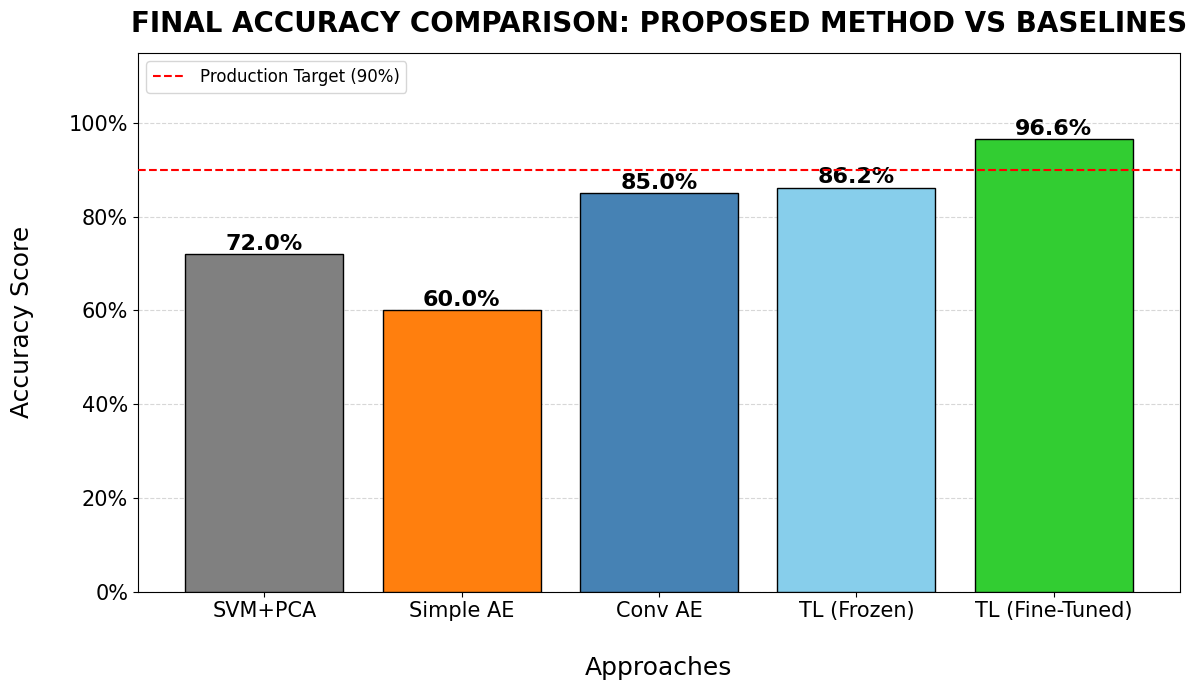



        3. REPORT EXPORT & SYSTEM HAND OFF



,PROCESS STAGE,RESULT,STATUS
1,Chart Generation,final_comparison.png,✅ SAVED
2,Report Update,Engineering_report.txt,✅ APPENDED


,ARTIFACT,FILENAME,SIZE,SHA-256 HASH,STATUS
1,🧠 Model (Keras) - System Brain,mobilenet_v2_final.keras,25.29 MB,32c1570d4d47,✅ SECURED
2,⚡ Edge (TFLite) - Edge Binary,mobilenet_bottle_quantized.tflite,2.55 MB,e99efc825f8c,✅ SECURED
3,🏷️ Class File - Class Mapping,labels.txt,0.00 MB,3bcd4434a8a4,✅ SECURED
4,📊 Comparison Map - Visual Benchmarks,final_comparison.png,0.22 MB,db182a8c2b3a,✅ SECURED
5,📝 Final Report - Scientific Evidence,Engineering_report.txt,0.00 MB,d9f809a2458e,✅ SECURED


,PROCESS STAGE,RESULT,STATUS
1,Accuracy Limit (>90%),96.55%,✅ PASSED
2,Structural Integrity,Verified,✅ PASSED
3,Latency Budget (<100ms),19.1 ms,✅ PASSED
4,Audit Timestamp,2026-08-11 15:18,✅ LOGGED
5,FINAL SYSTEM DECISION,Production Cleared,🚀 DEPLOY


In [19]:
# =====================================================================================================================================================================================================================================================================
# BLOCK 12: TFLITE EXPORT (IoT) & FINAL COMPARISON CHART
# =====================================================================================================================================================================================================================================================================


# REQUIRED MODULE IMPORTS

# Centralized library configuration for notebook execution context.
import os
import time
import gc
import logging
import hashlib
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.utils import io as ipy_io

import industrial_ui
import diagnostic_engine
import system_utils


# EXECUTION HEADER PROJECTION

# Console initialization for final pipeline stage evaluation.
industrial_ui.print_execution_header(
    title="EXECUTING FINAL INDUSTRIAL DEPLOYMENT & EDGE QUANTIZATION PROTOCOLS...",
    action_text="IoT Quantization, Latency Benchmarking, Integrity Checks & Final Reporting."
)


# EXTERNAL BASELINE METRICS

# Static benchmark results from independent experimental pipelines.
EXTERNAL_BASELINES = {
    'svm_pca': 0.7200,
    'simple_ae': 0.6000,
    'conv_ae': 0.8500
}


# POLICY PARAMETERS

# Centralized deployment thresholds and edge computing constraints.
DEPLOYMENT_POLICY = {
    'accuracy': {
        'target': 0.90,
        'warn': 0.90,
        'crit': 0.75
    },
    'latency_ms': {
        'warn': 50.0,
        'crit': 100.0
    },
    'compression_pct': {
        'warn': 25.0,
        'crit': 10.0
    }
}


# GLOBAL STATE INITIALIZATION

# Default status flags and stage synchronization variables.
metrics_recovered = False
quantization_ready = False
integrity_verified = False
charts_exported = False
inventory_secured = False

real_error_msg = None

tflite_filename = 'mobilenet_bottle_quantized.tflite'
keras_filename = 'mobilenet_v2_final.keras'
labels_filename = 'labels.txt'
CHART_FILENAME = 'final_comparison.png'

avg_latency_ms = None


# =====================================================================================================================================================================================================================================================================
# STAGE 1: GLOBAL STATE AUDIT & PERFORMANCE SNAPSHOTS ACQUISITION
# =====================================================================================================================================================================================================================================================================

print("\n")
industrial_ui.print_industrial_msg("STAGE 1:", "GLOBAL STATE AUDIT & PERFORMANCE SNAPSHOTS ACQUISITION")
print()


# Evaluation of upstream pipeline stability via diagnostic engine.
origin_fault = diagnostic_engine.check_external_faults(globals())


if origin_fault:
    
    
    # FAULT MESSAGE FORMATTING
    
    # Extraction of the core fault reason bypassing the default engine prefix.
    core_fault = origin_fault.replace("Preceding Pipeline Interruption (", "").rstrip(")")
    real_error_msg = f"External Pipeline Fault ({core_fault})"
    

    bypass_banner_1 = industrial_ui.render_industrial_banner(
        title="METRICS RECOVERY SUSPENDED",
        message=f"Stage 1 bypassed due to external pipeline fault ({core_fault.lower()}).",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_1))
    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 1 BYPASSED:", f"Execution halted due to external pipeline fault ({core_fault.lower()}).")

    
    metrics_recovered = False


else:

    
    # METRIC TYPE AND BOUNDARY AUDIT
    
    # Validation of raw telemetry ranges via diagnostic engine.
    status_b, res_b = diagnostic_engine.validate_metric_range(globals().get('frozen_acc_value', 'MISSING'), industrial_ui.THEME['CRITICAL']['text'])
    status_c, res_c = diagnostic_engine.validate_metric_range(globals().get('final_acc_value', 'MISSING'), industrial_ui.THEME['CRITICAL']['text'])

    data_log = []
    has_error = False
    
    acc_crit = DEPLOYMENT_POLICY['accuracy']['crit']
    acc_warn = DEPLOYMENT_POLICY['accuracy']['warn']

    
    # BASELINE THRESHOLD FORMATTING
    
    # Visual property assignment for frozen model telemetry.
    if status_b:
        
        c_base = industrial_ui.THEME['SUCCESS']['text'] if res_b >= acc_warn else (industrial_ui.THEME['WARNING']['text'] if res_b >= acc_crit else industrial_ui.THEME['CRITICAL']['text'])
        acc_str_b = industrial_ui.format_text(f"{res_b:.2%}", color=c_base, bold=True)
 
    else:
        
        acc_str_b = res_b
        has_error = True

    
    data_log.append({
        'EXPERIMENT PHASE': 'Phase 1 (Frozen)', 
        'SYSTEM ROLE': industrial_ui.format_text('Baseline', bold=False), 
        'ACCURACY': acc_str_b
    })

    
    # CHAMPION THRESHOLD FORMATTING
    
    # Visual property assignment for fine-tuned model telemetry.
    if status_c:
        
        c_champ = industrial_ui.THEME['SUCCESS']['text'] if res_c >= acc_warn else (industrial_ui.THEME['WARNING']['text'] if res_c >= acc_crit else industrial_ui.THEME['CRITICAL']['text'])
        acc_str_c = industrial_ui.format_text(f"{res_c:.2%}", color=c_champ, bold=True)
   
    else:
        
        acc_str_c = res_c
        has_error = True

    
    data_log.append({
        'EXPERIMENT PHASE': 'Phase 2 (Fine-Tuned)', 
        'SYSTEM ROLE': industrial_ui.format_text('Champion', bold=False), 
        'ACCURACY': acc_str_c
    })

    
    # GLOBAL MATRIX RENDERING
    
    # Color resolution hierarchy for final evaluation dataframe.
    if has_error:
        header_bg = industrial_ui.THEME['CRITICAL']['bg']
        
    else:
        
        lowest_acc = min(res_b, res_c)
        header_bg = industrial_ui.THEME['SUCCESS']['bg'] if lowest_acc >= acc_warn else (industrial_ui.THEME['WARNING']['bg'] if lowest_acc >= acc_crit else industrial_ui.THEME['CRITICAL']['bg'])

    
    display(HTML(industrial_ui.render_industrial_table(pd.DataFrame(data_log), header_bg, margin=71).to_html(escape=False)))
  
    print("\n")

    
    # FINAL VERDICT RESOLUTION
    
    # System state message mapping based on metric performance.
    if has_error:
        
        pfx = "❌ STAGE 1 FAILED:"
        real_error_msg = "Stage 1 Telemetry Failure (Baseline or Champion values corrupted/missing)"
        msg = "Data corruption detected in internal telemetry (Baseline/Champion values corrupted/missing). Deployment evaluation aborted."
        metrics_recovered = False

    
    else:
        
        if res_c >= acc_warn and res_b >= acc_warn:
            pfx, msg = "✅ STAGE 1 COMPLETED:", "Both models achieved optimal stability."
            
        elif res_c >= acc_warn:
            pfx, msg = "⚠️ STAGE 1 COMPLETED:", f"Champion optimal at {res_c:.2%}, but baseline shows marginal stability."
            
        elif res_c < acc_crit:
            
            pfx, msg = "❌ STAGE 1 FAILED:", f"Champion model failed safety thresholds ({res_c:.2%}). Deployment evaluation aborted."
            real_error_msg = f"Stage 1 Safety Lockout (Champion model failed safety thresholds: {res_c:.2%})"
            
        else:
            pfx, msg = "⚠️ STAGE 1 COMPLETED:", "Champion model shows marginal stability."

        
        metrics_recovered = True

    
    # LOG MESSAGE DISPLAY
    
    # Standard execution message output via industrial ui.
    industrial_ui.print_industrial_msg(pfx, msg)


industrial_ui.draw_line()


# =====================================================================================================================================================================================================================================================================
# STAGE 2: TFLITE QUANTIZATION & COMPILATION
# =====================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 2:", "TFLITE QUANTIZATION & COMPILATION")

print()


# FAULT EVALUATION

# Automated dependency triage for compiler initialization.
if not metrics_recovered:
    
    if not real_error_msg:
        real_error_msg = "Stage 1 Unknown Failure (Metrics recovery aborted)"

    
    bypass_banner_2 = industrial_ui.render_industrial_banner(
        title="QUANTIZATION SUSPENDED",
        message=f"Stage 2 bypassed due to {real_error_msg}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_2))
    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 2 BYPASSED:", f"Compilation engine suspended due to {real_error_msg}.")

    
    industrial_ui.draw_line()


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. TENSORFLOW COMPILATION ENGINE
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

else:

    print("\n        1. TENSORFLOW COMPILATION ENGINE\n")

    
    # COMPILER ENVIRONMENT PREPARATION
    
    # Removal of stale hardware artifacts and native log suppression.
    if os.path.exists(keras_filename): os.remove(keras_filename)
    if os.path.exists(tflite_filename): os.remove(tflite_filename)

    status_log = []
    class_names = ['Defective', 'Good']
    q_compile_status = False

    old_cpp_level = os.environ.get('TF_CPP_MIN_LOG_LEVEL', '0')
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
    
    tf_logger = tf.get_logger()
    absl_logger = logging.getLogger('absl')
    
    old_tf_level = tf_logger.level
    old_absl_level = absl_logger.level
    
    tf_logger.setLevel(logging.ERROR)
    absl_logger.setLevel(logging.ERROR)

    
    try:
        
        # TENSORFLOW QUANTIZATION ENGINE
        
        # Translation of keras model to tflite schema with standard telemetry capture.
        c_start = time.perf_counter()

        
        with ipy_io.capture_output() as captured:
            
            model.save(keras_filename)
            
            with open(labels_filename, 'w') as f:
                f.write('\n'.join(class_names))

            converter = tf.lite.TFLiteConverter.from_keras_model(model)
            converter.optimizations = [tf.lite.Optimize.DEFAULT] 
            tflite_model = converter.convert()
            
            with open(tflite_filename, 'wb') as f:
                f.write(tflite_model)

        
        c_time = time.perf_counter() - c_start

        
        # LOG FORMAT RECONSTRUCTION
        
        # Reattachment of native tensorflow tags.
        raw_stdout = captured.stdout.strip()
        formatted_logs = [f"INFO:tensorflow:{line}" if line.startswith('Assets written') else line for line in raw_stdout.split('\n')]
        
        compiler_logs = f"[SYSTEM] Compiler engine initialized.\n[SYSTEM] Target optimization: DEFAULT.\n\n{chr(10).join(formatted_logs)}\n\n[SYSTEM] Compilation completed in {c_time:.2f} seconds."
        q_compile_status = True

    
    except Exception as e:
        
        compiler_logs = f"CRITICAL COMPILER FAULT:\n{str(e)}"
        q_compile_status = False
        real_error_msg = f"Stage 2 Compilation Fault (TensorFlow native compilation crashed: {str(e)})"

    
    finally:
        
        os.environ['TF_CPP_MIN_LOG_LEVEL'] = old_cpp_level
        tf_logger.setLevel(old_tf_level)
        absl_logger.setLevel(old_absl_level)

    
    # TERMINAL VIEW RENDERING
    
    # Html enclosure generation via centralized visual utility.
    display(HTML(industrial_ui.render_terminal_logs("NATIVE TENSORFLOW COMPILER LOGS", compiler_logs, margin=94)))


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. HARDWARE BENCHMARK & FOOTPRINT
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Synthetic data throughput tests for the quantized artifact.
    print("\n\n        2. HARDWARE BENCHMARK & FOOTPRINT\n")

    
    if q_compile_status:
        
        try:
 
            interpreter = tf.lite.Interpreter(model_path=tflite_filename)
            interpreter.allocate_tensors()
            
            input_details = interpreter.get_input_details()
            input_shape = input_details[0]['shape']
            input_dtype = input_details[0]['dtype']
            
            dummy_input = np.random.random_sample(input_shape).astype(input_dtype)
            interpreter.set_tensor(input_details[0]['index'], dummy_input)
            interpreter.invoke() 

            t0 = time.perf_counter()
            
            
            for _ in range(50):
                
                interpreter.set_tensor(input_details[0]['index'], dummy_input)
                interpreter.invoke()
                

            raw_latency = ((time.perf_counter() - t0) / 50) * 1000
            globals()['avg_latency_ms'] = raw_latency

            raw_keras_size = os.path.getsize(keras_filename) / (1024 * 1024)
            raw_tfl_size = os.path.getsize(tflite_filename) / (1024 * 1024)
            raw_reduction = ((raw_keras_size - raw_tfl_size) / raw_keras_size * 100) if raw_keras_size > 0 else 0
            
            benchmark_executed = True

        
        except Exception as e:
            
            raw_latency = raw_keras_size = raw_tfl_size = raw_reduction = None
            benchmark_exception = str(e)
            benchmark_executed = False
            real_error_msg = f"Stage 2 Benchmark Exception (Throughput benchmarking exception: {benchmark_exception})"


        # BENCHMARK EVALUATION VIA DIAGNOSTIC ENGINE
        
        if benchmark_executed:
            
            lat_warn, lat_crit = DEPLOYMENT_POLICY['latency_ms']['warn'], DEPLOYMENT_POLICY['latency_ms']['crit']
            red_warn, red_crit = DEPLOYMENT_POLICY['compression_pct']['warn'], DEPLOYMENT_POLICY['compression_pct']['crit']
            
            stat_lat_ok, res_lat, stat_lat_label = diagnostic_engine.validate_hardware_metric(raw_latency, industrial_ui.THEME['CRITICAL']['text'])
            stat_red_ok, res_red, stat_red_label = diagnostic_engine.validate_hardware_metric(raw_reduction, industrial_ui.THEME['CRITICAL']['text'])
            stat_ks_ok, res_ks, stat_ks_label = diagnostic_engine.validate_hardware_metric(raw_keras_size, industrial_ui.THEME['CRITICAL']['text'])
            stat_ts_ok, res_ts, stat_ts_label = diagnostic_engine.validate_hardware_metric(raw_tfl_size, industrial_ui.THEME['CRITICAL']['text'])
            
            
            # COMPRESSION LOGIC
            
            # Size comparison formatting and visual color assignment.
            if stat_red_ok and stat_ks_ok and stat_ts_ok:
                
                if res_red >= red_warn:
                    red_status, red_clr = '✅ OPTIMAL', industrial_ui.THEME['SUCCESS']['text']
                    
                elif res_red >= red_crit:
                    red_status, red_clr = '⚠️ MARGINAL', industrial_ui.THEME['WARNING']['text']
                    
                else:
                    red_status, red_clr = '❌ CRITICAL', industrial_ui.THEME['CRITICAL']['text']
                    

                p_l, p_r = industrial_ui.format_text("(", "green", bold=True), industrial_ui.format_text(")", "green", bold=True)
                arr = industrial_ui.format_text("➔", "red", bold=True)
                mb_t = industrial_ui.format_text("MB", "black", bold=True)
                n_ks = industrial_ui.format_text(f"{res_ks:.2f}", "red", bold=True)
                n_ts = industrial_ui.format_text(f"{res_ts:.2f}", red_clr, bold=True)
                
                size_str = f'{res_red:.1f}% {p_l}{n_ks}{mb_t} {arr} {n_ts}{mb_t}{p_r}'

            
            else:
                
                if not stat_red_ok:
                    size_str, red_status = res_red, stat_red_label
                    
                elif not stat_ks_ok:
                    size_str, red_status = res_ks, stat_ks_label
                    
                else:
                    size_str, red_status = res_ts, stat_ts_label
                    
                    
                red_status = f"❌ {red_status}" if not red_status.startswith("❌") else red_status
                red_clr = industrial_ui.THEME['CRITICAL']['text']

            
            # LATENCY LOGIC
            
            # Inference speed formatting and threshold evaluation.
            if stat_lat_ok:
                
                if res_lat <= lat_warn:
                    lat_status, lat_clr = '✅ OPTIMAL', industrial_ui.THEME['SUCCESS']['text']
                    
                elif res_lat <= lat_crit:
                    lat_status, lat_clr = '⚠️ MARGINAL', industrial_ui.THEME['WARNING']['text']
                    
                else:
                    lat_status, lat_clr = '❌ CRITICAL', industrial_ui.THEME['CRITICAL']['text']
                    

                m_txt, s_txt = industrial_ui.format_text("m", "black", bold=True), industrial_ui.format_text("s", "red", bold=True)
                div_txt, f_txt = industrial_ui.format_text("/", "green", bold=True), industrial_ui.format_text("frame", "green", bold=True)
                
                lat_str = f'{res_lat:.1f} {m_txt}{s_txt} {div_txt} {f_txt}'

            
            else:
                
                lat_str = res_lat
                lat_status = f"❌ {stat_lat_label}" if not stat_lat_label.startswith("❌") else stat_lat_label
                lat_clr = industrial_ui.THEME['CRITICAL']['text']

            
            # TABLE POPULATION
            
            # Insertion of evaluated metrics into industrial visual log.
            comp_lbl = industrial_ui.format_text("Model Compression", "black", bold=True)
            lat_lbl = industrial_ui.format_text("IoT Inference Latency", "black", bold=True)

            
            status_log.append({'PROCESS STAGE': comp_lbl, 
                               'RESULT': size_str, 
                               'STATUS': industrial_ui.format_text(red_status, red_clr, bold=True),
                               'CLR': red_clr}
                             )
            
            status_log.append({'PROCESS STAGE': lat_lbl, 
                               'RESULT': lat_str, 'STATUS': industrial_ui.format_text(lat_status, lat_clr, bold=True), 
                               'CLR': lat_clr}
                             )

            
            # VERDICT RESOLUTION
            
            # Edge deployment threshold evaluation.
            has_error = (not stat_lat_ok) or (not stat_red_ok) or (not stat_ks_ok) or (not stat_ts_ok)

            if has_error:
                
                quantization_ready = False
                real_error_msg = "Stage 2 Telemetry Corruption (Footprint benchmark structural failure detected)"
                pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "Telemetry corruption or footprint benchmark failure detected in Stage 2."
        
            else:
                
                has_benchmark_error = (res_lat > lat_crit) or (res_red < red_crit)
                has_benchmark_warn = (res_lat > lat_warn) or (res_red < red_warn)

                
                if has_benchmark_error:
                    
                    quantization_ready = False
                    real_error_msg = "Stage 2 Benchmark Failure (Hardware footprint benchmark failed deployment thresholds)"
                    pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "Hardware footprint benchmark failed deployment thresholds."
            
                elif has_benchmark_warn:
                    
                    quantization_ready = True
                    pfx_s2, msg_s2 = "⚠️ STAGE 2 COMPLETED:", "Model quantized with marginal benchmark results."
           
                else:
                    
                    quantization_ready = True
                    pfx_s2, msg_s2 = "✅ STAGE 2 COMPLETED:", "Model quantized and edge inference footprint verified."

        
        else:
            
            lat_lbl_err = industrial_ui.format_text("Latency Benchmark", "black", bold=True)
            
            status_log.append({'PROCESS STAGE': lat_lbl_err, 
                               'RESULT': benchmark_exception,
                               'STATUS': industrial_ui.format_text('❌ FAILED', industrial_ui.THEME['CRITICAL']['text'], bold=True), 
                               'CLR': industrial_ui.THEME['CRITICAL']['text']}
                             )
            
            quantization_ready = False
            real_error_msg = f"Stage 2 Benchmark Crash (Compiler crash during benchmark. {benchmark_exception}.)"
            pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", f"Compiler crash during benchmark. {benchmark_exception}."

    
    else:
        
        comp_lbl_err = industrial_ui.format_text("Model Compilation", "black", bold=True)

        
        status_log.append({'PROCESS STAGE': comp_lbl_err, 
                           'RESULT': 'Aborted', 
                           'STATUS': industrial_ui.format_text('❌ FAILED', industrial_ui.THEME['CRITICAL']['text'], bold=True), 
                           'CLR': industrial_ui.THEME['CRITICAL']['text']}
                         )

        
        quantization_ready = False
        real_error_msg = "Stage 2 Compiler Fault (TensorFlow native compilation engine critical fault)"
        pfx_s2, msg_s2 = "❌ STAGE 2 FAILED:", "TensorFlow native compilation engine critical fault."

    
    # SYSTEM RESOURCE OPTIMIZATION
    
    # Memory pool cleanup for subsequent operations.
    gc.collect()
    tf.keras.backend.clear_session()
    
    log_df = pd.DataFrame(status_log)
    header_bg_log = industrial_ui.resolve_audit_header_color(status_log, industrial_ui.THEME)

    
    display(HTML(industrial_ui.render_industrial_table(log_df, header_bg_log, margin=94).to_html(escape=False)))
    
    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s2, msg_s2)

    
    industrial_ui.draw_line()


# =====================================================================================================================================================================================================================================================================
# STAGE 3: TENSOR SHAPE VERIFICATION
# =====================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 3:", "TENSOR SHAPE VERIFICATION")

print()


# UPSTREAM DEPENDENCY EVALUATION

# Automatic dependency triage for structural validation.
if not quantization_ready:


    # UPSTREAM FAILURE FALLBACK

    # Substitution of missing error message.
    if not real_error_msg:
        real_error_msg = "Stage 2 Unknown Failure (Quantization aborted)"
    

    # BYPASS BANNER GENERATION

    # Suspension banner creation for visual output.
    bypass_banner_3 = industrial_ui.render_industrial_banner(
        title="TENSOR VERIFICATION SUSPENDED",
        message=f"Stage 3 bypassed due to {real_error_msg}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_3))
    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 3 BYPASSED:", f"Tensor shape verification suspended due to {real_error_msg}.")
    

    # TELEMETRY STATUS UPDATE

    # Integrity verification flag assignment.
    integrity_verified = False
    
    industrial_ui.draw_line()


else:

    try:
        

        # TENSOR GRAPH VERIFICATION

        # Hardware resource allocation and input output schema confirmation.
        interpreter = tf.lite.Interpreter(model_path=tflite_filename)
        interpreter.allocate_tensors()
        

        # TENSOR DETAILS EXTRACTION

        # Extraction of input and output definitions.
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        

        # SHAPE AND TYPE EXTRACTION

        # Raw dimensions and data types assignment.
        raw_in_shape = input_details[0]['shape']
        raw_out_shape = output_details[0]['shape']
        dtype_in = np.dtype(input_details[0]['dtype']).name
        dtype_out = np.dtype(output_details[0]['dtype']).name
        

        # SHAPE VALIDATION EXECUTION

        # Shape validation via diagnostic engine.
        stat_in, msg_in = diagnostic_engine.validate_tensor_schema(raw_in_shape, target_dim=4)
        stat_out, msg_out = diagnostic_engine.validate_tensor_schema(raw_out_shape, target_dim=2)


        # CRITICAL VERDICT RESOLUTION

        # Hardware compatibility check for edge device propagation.
        if stat_in in ['CRITICAL', 'INVALID DATA'] or stat_out in ['CRITICAL', 'INVALID DATA']:
            
            integrity_verified = False
            real_error_msg = "Stage 3 Tensor Architecture Rejection (Model is incompatible with Edge deployment)"
            pfx_s3, msg_s3 = "❌ STAGE 3 FAILED:", "Tensor architecture rejected. Model is incompatible with Edge deployment."
    
        elif stat_in == 'MARGINAL' or stat_out == 'MARGINAL':
            
            integrity_verified = True
            pfx_s3, msg_s3 = "⚠️ STAGE 3 COMPLETED:", "TFLite binary verified with dynamic shapes. Edge deployment latency may vary."
    
        else:
            
            integrity_verified = True
            pfx_s3, msg_s3 = "✅ STAGE 3 COMPLETED:", "TFLite binary verified & I/O architecture strictly confirmed."
            

        # TABLE RENDER EXECUTION

        # HTML display of the dataframe via industrial ui.
        audit_table = industrial_ui.render_tensor_audit_table(raw_in_shape, dtype_in, stat_in, msg_in, raw_out_shape, dtype_out, stat_out, msg_out, None, industrial_ui.THEME)
        
        display(HTML(audit_table.to_html(escape=False)))

        
    except Exception as e:
        

        # DIAGNOSTIC ENGINE DELEGATION

        # External exception translation and classification.
        err_ui_msg, final_err_msg = diagnostic_engine.parse_tflite_exception(e, tflite_filename)
        

        # FATAL ERROR REGISTRATION

        # Telemetry variable update for upstream propagation.
        integrity_verified = False
        real_error_msg = f"Stage 3 Allocation Crash. {final_err_msg}"
        pfx_s3 = "❌ STAGE 3 FAILED:"
        msg_s3 = final_err_msg


        # TABLE RENDER EXECUTION

        # HTML display of the exception dataframe via industrial ui.
        audit_table = industrial_ui.render_tensor_audit_table(None, None, None, None, None, None, None, None, err_ui_msg, industrial_ui.THEME)
        
        display(HTML(audit_table.to_html(escape=False)))


    # MEMORY PURGE

    # Forceful garbage collection.
    gc.collect()
    
    print("\n")
    

    # FINAL VERDICT RENDER

    # Visual display of the final completion message.
    industrial_ui.print_industrial_msg(pfx_s3, msg_s3)
    
    industrial_ui.draw_line()


# =====================================================================================================================================================================================================================================================================
# STAGE 4: SCIENTIFIC BENCHMARKING & VISUALIZATION
# =====================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 4:", "SCIENTIFIC BENCHMARKING & VISUALIZATION")

print()


# FAULT EVALUATION

# Automated dependency triage for visual report generation.
if not integrity_verified:
    
    if not real_error_msg:
        real_error_msg = "Stage 3 Unknown Failure (Integrity verification aborted)"

    
    bypass_banner_4 = industrial_ui.render_industrial_banner(
        title="BENCHMARKING & VISUALIZATION SUSPENDED",
        message=f"Stage 4 bypassed due to {real_error_msg}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_4))
    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 4 BYPASSED:", f"Scientific benchmarking protocol suspended due to {real_error_msg}.")

    
    industrial_ui.draw_line()


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1. PERFORMANCE COMPARISON MATRIX
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

else:  
    
    print("\n        1. PERFORMANCE COMPARISON MATRIX\n")

    
    # SCIENTIFIC DATA AGGREGATION
    
    # Historical baseline retrieval and global validity checkpoint.
    svm_val = EXTERNAL_BASELINES['svm_pca']
    sae_val = EXTERNAL_BASELINES['simple_ae']
    cae_val = EXTERNAL_BASELINES['conv_ae']
    base_val = globals().get('frozen_acc_value', 'MISSING')
    champ_val = globals().get('final_acc_value', 'MISSING')


    # METRIC PROCESSING PIPELINE VIA DIAGNOSTIC ENGINE
    
    comp_log = []
    metrics_valid = True
    
    models_data = [
        ('SVM+PCA', 'Baseline', svm_val, 'gray'),
        ('Simple AE', 'Baseline', sae_val, '#ff7f0e'),
        ('Conv AE', 'Baseline', cae_val, 'steelblue'),
        ('TL (Frozen)', 'Phase 1', base_val, 'skyblue'),
        ('TL (Fine-Tuned)', 'Champion', champ_val, 'limegreen')
    ]
    
    for n, r, v, c in models_data:
        
        row, is_ok = diagnostic_engine.process_comparison_metric(n, r, v, c, DEPLOYMENT_POLICY, industrial_ui.THEME)
        comp_log.append(row)
        if not is_ok: metrics_valid = False
            

    # COMPARISON TABLE RENDERING
    
    # Explicit header color resolution for champion metrics (Safeguarded against ValueError).
    log_df = pd.DataFrame(comp_log)
    
    if not metrics_valid:
        header_bg_comp = industrial_ui.THEME['CRITICAL']['bg']
        
    else:
        
        try:
            
            champ_float = float(champ_val)

            
            if champ_float >= DEPLOYMENT_POLICY['accuracy']['warn']:
                header_bg_comp = industrial_ui.THEME['SUCCESS']['bg']
       
            elif champ_float >= DEPLOYMENT_POLICY['accuracy']['crit']:
                header_bg_comp = industrial_ui.THEME['WARNING']['bg']
          
            else:
                header_bg_comp = industrial_ui.THEME['CRITICAL']['bg']
 
        
        except (ValueError, TypeError):
            header_bg_comp = industrial_ui.THEME['CRITICAL']['bg']

    
    display(HTML(industrial_ui.render_industrial_table(log_df, header_bg_comp, margin=94).to_html(escape=False)))


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. SCIENTIFIC VISUALIZATION
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n\n        2. SCIENTIFIC VISUALIZATION\n")

    
    visual_fault = False

    
    try:

        
        # METRICS VALIDATION AUDIT

        # Comparison metrics validation. Invalid, Nan, or out of bounds values.
        if not metrics_valid:
            raise ValueError("Comparison metrics validation failed. The telemetry contains invalid, NaN, or out of bounds baseline / champion values.")

        methods = ['SVM+PCA', 'Simple AE', 'Conv AE', 'TL (Frozen)', 'TL (Fine-Tuned)']
        accuracies = [float(svm_val), float(sae_val), float(cae_val), float(base_val), float(champ_val)]

        
        # MATPLOTLIB RENDERING ENGINE
        
        # Central visual utility wrapper execution.
        target_line = DEPLOYMENT_POLICY['accuracy']['target']
        forensic_engine.render_comparison_chart(methods, accuracies, target_line, CHART_FILENAME)


    except ValueError as ve:

        
        # DATA DEPENDENCY FAULT
        
        # Exception banner generation for upstream data corruption.
        real_error_msg = f"Stage 4 Metric Validation Fault ({str(ve)})"

        
        v_fail_banner = industrial_ui.render_industrial_banner(
            title="METRICS VALIDATION FAULT", 
            message=str(ve), 
            icon="🚫", 
            bg_color="#fff0f0", 
            left=94
        )

        display(HTML(v_fail_banner))

        visual_fault = True

    
    except Exception as e:

        
        # GHOST CHART PREVENTION
        
        # Canvas memory clearance on graphic library failure.
        plt.close('all')

        
        # VISUAL RENDERING FAULT
        
        # Exception banner generation for chart rendering failure.
        real_error_msg = f"Stage 4 Visual Rendering Fault (Chart rendering aborted. {str(e)})"

        
        v_fail_banner = industrial_ui.render_industrial_banner(
            title="VISUAL RENDERING FAULT", 
            message=f"Chart rendering aborted. {str(e)}", 
            icon="🚫",
            bg_color="#fff0f0", 
            left=94)
  
        display(HTML(v_fail_banner))

        
        visual_fault = True


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 3. REPORT EXPORT & SYSTEM HAND OFF
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("\n\n        3. REPORT EXPORT & SYSTEM HAND OFF\n")

    
    # ARCHIVAL INTEGRITY CHECK
        
    # Industrial warning banner for asset persistence without real-time visual verification.
    if visual_fault:
        
        t_warn_banner = industrial_ui.render_industrial_banner(title="ARCHIVAL INTEGRITY WARNING", message="Engineering report persistence proceeding without visual chart validation.", icon="⚠️", bg_color="#fff9e6", left=94)
        display(HTML(t_warn_banner))
        
        print()

    
    status_log = []
    chart_saved = report_saved = False
    export_file = globals().get('export_file', 'engineering_report.txt')


    # CHART ARTIFACT LOGGING
    
    # Registration of visual artifact status in logging table.
    chart_lbl = industrial_ui.format_text("Chart Generation", "black", bold=True)
    res_chart = industrial_ui.format_text(CHART_FILENAME, "black", bold=False)

    
    if visual_fault:
        
        status_log.append({'PROCESS STAGE': chart_lbl, 
                           'RESULT': res_chart, 
                           'STATUS': '🚫 SKIPPED', 
                           'CLR': industrial_ui.THEME['WARNING']['text']}
                         )

    else:
        
        status_log.append({'PROCESS STAGE': chart_lbl,
                           'RESULT': res_chart,
                           'STATUS': '✅ SAVED', 
                           'CLR': industrial_ui.THEME['SUCCESS']['text']}
                         )
        
  
        chart_saved = True


    # TEXT ARTIFACT REGISTRATION
    
    # Report compilation logic including byte size formatting.
    try:
        
        k_size = os.path.getsize(keras_filename) / (1024 * 1024) if os.path.exists(keras_filename) else 0.0
        t_size = os.path.getsize(tflite_filename) / (1024 * 1024) if os.path.exists(tflite_filename) else 0.0
        red_perc = ((k_size - t_size) / k_size * 100) if k_size > 0 else 0.0
  
    except Exception:
        k_size, t_size, red_perc = 0.0, 0.0, 0.0

    
    rep_lbl = industrial_ui.format_text("Report Update", "black", bold=True)

    
    try:
        
        with open(export_file, "a") as f:
            
            f.write("\n\n3. MODEL DEPLOYMENT METRICS\n")
            f.write(f"    Keras Size:       {k_size:>6.2f} MB\n")
            f.write(f"    TFLite Size:      {t_size:>6.2f} MB\n")
            f.write(f"    Size Reduction:   {red_perc:>6.1f} %\n")
            
        res_export = industrial_ui.format_text(export_file, "black", bold=False)

        
        status_log.append({'PROCESS STAGE': rep_lbl,
                           'RESULT': res_export, 
                           'STATUS': '✅ APPENDED',
                           'CLR': industrial_ui.THEME['SUCCESS']['text']}
                         )

        
        report_saved = True

    
    except Exception as e:
        
        
        # SYSTEM EXCEPTION CATCHER
        
        # Formatting system exception via industrial UI tools.
        formatted_error = str(e).split("] ", 1)[-1].replace(": ", " - ")
        real_error_msg = f"Stage 4 Export Exception (Report export failed: {formatted_error})"

        
        status_log.append({'PROCESS STAGE': rep_lbl, 
                           'RESULT': industrial_ui.format_text(formatted_error, industrial_ui.THEME['CRITICAL']['text'], bold=True),
                           'STATUS': '❌ FAILED', 
                           'CLR': industrial_ui.THEME['CRITICAL']['text']})


    log_df = pd.DataFrame(status_log)
    header_bg_log = industrial_ui.resolve_audit_header_color(log_df.to_dict('records'), industrial_ui.THEME)
    
    display(HTML(industrial_ui.render_industrial_table(log_df, header_bg_log, margin=94).to_html(escape=False)))
    
    print("\n")
    
    
    # FINAL VERDICT RESOLUTION
    
    # Global state evaluation across matrix, visualization, and export modules.
    if report_saved and metrics_valid and not visual_fault and chart_saved:
        
        charts_exported = True
        industrial_ui.print_industrial_msg("✅ STAGE 4 COMPLETED:", "Scientific benchmarking, visual synthesis, and system hand off successful.")
  
    elif not report_saved:
        
        charts_exported = False
        real_error_msg = "Stage 4 Archival Failure (System hand off aborted. Engineering Report could not be saved)"
        industrial_ui.print_industrial_msg("❌ STAGE 4 FAILED:", "System hand off aborted. Engineering Report could not be saved.")
   
    else:
        
        charts_exported = False
        if not real_error_msg or "Stage 4" not in real_error_msg:
            real_error_msg = "Stage 4 Metric Validation Failure (Visual synthesis or metric validation errors detected)"
        industrial_ui.print_industrial_msg("❌ STAGE 4 FAILED:", "Visual synthesis or metric validation errors detected.")    

    
    industrial_ui.draw_line()
     

# =====================================================================================================================================================================================================================================================================
# STAGE 5: ARTIFACT INVENTORY & SHA-256 CRYPTOGRAPHIC AUDIT
# =====================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 5:", "ARTIFACT INVENTORY & SHA-256 CRYPTOGRAPHIC AUDIT")

print()


# FAULT EVALUATION
    
# Automated dependency triage for forensic auditing.
if not charts_exported:
    
    if not real_error_msg:
        real_error_msg = "Stage 4 Unknown Failure (Charts and metrics not exported)"

    
    bypass_banner_5 = industrial_ui.render_industrial_banner(
        title="CRYPTOGRAPHIC AUDIT SUSPENDED",
        message=f"Stage 5 bypassed due to {real_error_msg}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_5))
    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 5 BYPASSED:", f"Artifact inventory suspended due to {real_error_msg}.")

    
    inventory_secured = False
    
    
    industrial_ui.draw_line()


else:
    
    status_log = []

    
    # HASH GENERATOR UTILITY
    
    # Cryptographic footprint generator for precise file tracking.
    def calculate_sha256(filename):
        
        if not os.path.exists(filename): return "❌ MISSING"
        sha256_hash = hashlib.sha256()
        
        with open(filename, "rb") as f:
            
            for chunk in iter(lambda: f.read(4096), b""):
                sha256_hash.update(chunk)

        
        return sha256_hash.hexdigest()[:12]

    
    # FORENSIC LOGIC
        
    # Construction of the bill of materials mapping for physical system artifacts.
    try:
        
        inventory_items = [
            ('🧠 Model (Keras)', keras_filename, 'System Brain'),
            ('⚡ Edge (TFLite)', tflite_filename, 'Edge Binary'),
            ('🏷️ Class File', labels_filename, 'Class Mapping'),
            ('📊 Comparison Map', CHART_FILENAME, 'Visual Benchmarks'),
            ('📝 Final Report', globals().get('export_file', 'engineering_report.txt'), 'Scientific Evidence')
        ]

        
        # ARTIFACT ITERATION VIA DIAGNOSTIC ENGINE
        
        # Cryptographic and resource footprinting evaluation.
        for art_name, f_name, art_desc in inventory_items:
            
            n_txt = industrial_ui.format_text(art_name, 'black', bold=True)
            d_txt = industrial_ui.format_text(art_desc, color='gray', bold=False, font_size='0.85em')
            formatted_artifact = f"{n_txt} - {d_txt}"
            
            is_valid, parsed_path, stat = diagnostic_engine.validate_filepath_string(f_name)

            
            if not is_valid:
                
                display_name = parsed_path
                hash_res = industrial_ui.format_text("❌ CORRUPTED METRIC", industrial_ui.THEME['CRITICAL']['text'], bold=True)
                size_res = industrial_ui.format_text("❌ INVALID RANGE", industrial_ui.THEME['CRITICAL']['text'], bold=True)
                s_txt, s_clr = f'❌ {stat}', industrial_ui.THEME['CRITICAL']['text']
                
            else:
                
                raw_hash = calculate_sha256(parsed_path)
                display_name = industrial_ui.format_text(parsed_path, "black", bold=False)

                
                if os.path.exists(parsed_path):
                    
                    f_size_mb = os.path.getsize(parsed_path) / (1024 * 1024)
                    size_clr = industrial_ui.THEME['SUCCESS']['text'] if f_size_mb < 10 else (industrial_ui.THEME['WARNING']['text'] if f_size_mb < 50 else industrial_ui.THEME['CRITICAL']['text'])
                    size_res = f"{industrial_ui.format_text(f'{f_size_mb:.2f}', size_clr, bold=True)} {industrial_ui.format_text('MB', 'black', bold=True)}"
             
                else:
                    size_res = industrial_ui.format_text("N/A", industrial_ui.THEME['CRITICAL']['text'], bold=True)

                
                if raw_hash == "❌ MISSING":
                    
                    hash_res = industrial_ui.format_text("Hash computation aborted", industrial_ui.THEME['WARNING']['text'], bold=True)
                    s_txt, s_clr = '⚠️ MISSING', industrial_ui.THEME['WARNING']['text']
          
                else:
                    
                    hash_res = industrial_ui.format_text(raw_hash, "darkblue", bold=True)
                    s_txt, s_clr = '✅ SECURED', industrial_ui.THEME['SUCCESS']['text']

            
            status_log.append({'ARTIFACT': formatted_artifact,
                               'FILENAME': display_name,
                               'SIZE': size_res,
                               'SHA-256 HASH': hash_res,
                               'STATUS': industrial_ui.format_text(s_txt, s_clr, bold=True),
                               'CLR': s_clr})

        
        # GLOBAL INVENTORY CHECK
            
        # Verification of complete file presence.
        if any("MISSING" in item['STATUS'] for item in status_log):
            
            inventory_secured = False
            real_error_msg = "Stage 5 Artifact Inventory Void (Critical deployment files are missing)"
            pfx_s5, msg_s5 = "❌ STAGE 5 FAILED:", "Artifact Inventory incomplete. Critical deployment files are missing."
            h_bg_log = industrial_ui.THEME['CRITICAL']['bg']
     
        elif any("CORRUPT" in item['STATUS'] or "INVALID" in item['STATUS'] for item in status_log):
            
            inventory_secured = False
            real_error_msg = "Stage 5 Data Pipeline Corruption (Invalid telemetry detected in artifact paths)"
            pfx_s5, msg_s5 = "❌ STAGE 5 FAILED:", "Data pipeline corruption detected in artifact paths."
            h_bg_log = industrial_ui.THEME['CRITICAL']['bg']
  
        else:
            
            inventory_secured = True
            pfx_s5, msg_s5 = "✅ STAGE 5 COMPLETED:", "Final project artifacts securely cryptographed and hashed."
            h_bg_log = industrial_ui.THEME['SUCCESS']['bg']

    
    except Exception as e:
        
        # Safeguarded exception row with all 6 columns to protect DataFrame structure
        status_log = [{
            'ARTIFACT': 'Audit Generator', 
            'FILENAME': '-', 
            'SIZE': industrial_ui.format_text("N/A", industrial_ui.THEME['CRITICAL']['text'], bold=True),
            'SHA-256 HASH': str(e), 
            'STATUS': industrial_ui.format_text('❌ FAILED', industrial_ui.THEME['CRITICAL']['text'], bold=True), 
            'CLR': industrial_ui.THEME['CRITICAL']['text']
        }]
        
        inventory_secured = False
        real_error_msg = f"Stage 5 Forensic Footprint Crash (System crashed during footprinting: {str(e)})"
        pfx_s5, msg_s5 = "❌ STAGE 5 FAILED:", f"System crashed during forensic footprinting: {str(e)}"
        h_bg_log = industrial_ui.THEME['CRITICAL']['bg']
        

    # INVENTORY RENDERING
    
    # Delegation of cryptographic audit presentation to industrial module.
    log_df = pd.DataFrame(status_log)

    
    display(HTML(industrial_ui.render_industrial_table(log_df, h_bg_log, margin=71).to_html(escape=False)))
    
    print("\n")
    
    industrial_ui.print_industrial_msg(pfx_s5, msg_s5)

    
    industrial_ui.draw_line()
        

# =====================================================================================================================================================================================================================================================================
# STAGE 6: FINAL DEPLOYMENT & QUALITY ASSURANCE REPORT
# =====================================================================================================================================================================================================================================================================

print("\n")

industrial_ui.print_industrial_msg("STAGE 6:", "FINAL DEPLOYMENT & QUALITY ASSURANCE REPORT")

print()


# AUTOMATED FAULT TRIAGE

# Stage dependency evaluation and visual protocol suspension notification.
if not inventory_secured:

    if not real_error_msg:
        real_error_msg = "Stage 5 Unknown Failure (Inventory not secured)"

    
    bypass_banner_6 = industrial_ui.render_industrial_banner(
        title="EXECUTIVE VERDICT SUSPENDED",
        message=f"Stage 6 bypassed due to {real_error_msg}.",
        icon="⚠️",
        bg_color="#fff9e6",
        left=71
    )
    
    display(HTML(bypass_banner_6))
    
    print("\n")
    
    industrial_ui.print_industrial_msg("⚠️ STAGE 6 BYPASSED:", f"Final deployment quality gate suspended due to {real_error_msg}.")

    
    industrial_ui.draw_line()
    
    print("\n")

    
    fin_msg = f"End to end pipeline terminated. The complete machine learning lifecycle was aborted and deployment is strictly rejected due to an upstream fault."
    display(HTML(industrial_ui.render_grand_finale("❌ TERMINATED", fin_msg)))
    
    
else:
    
    
    # DEPLOYMENT AUTHORIZATION
    
    # Quality assurance report compilation and threshold extraction.
    status_log = []
    THRESHOLD = DEPLOYMENT_POLICY['accuracy']['target']

    
    # METRIC LOGIC EVALUATION VIA DIAGNOSTIC ENGINE
    
    # Extraction and assessment of global model accuracy, integrity, and latency.
    acc_raw = globals().get('final_acc_value', 'MISSING')
    is_valid_acc, acc_val = diagnostic_engine.validate_deployment_type(acc_raw, float, industrial_ui.THEME)

    
    if not is_valid_acc:
        
        acc_clr, acc_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ DATA CORRUPT'
        acc_res = acc_val
        real_error_msg = "Stage 6 Data Corruption (Final accuracy value invalid)"
        
    elif acc_val < 0 or acc_val > 1:
        
        acc_clr, acc_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ DATA CORRUPT'
        acc_res = industrial_ui.format_text("❌ INVALID RANGE", industrial_ui.THEME['CRITICAL']['text'], bold=True)
        real_error_msg = "Stage 6 Range Violation (Accuracy value out of bounds)"
        
    else:
        
        if acc_val >= THRESHOLD:
            acc_clr, acc_stat = industrial_ui.THEME['SUCCESS']['text'], '✅ PASSED'
            
        elif acc_val >= DEPLOYMENT_POLICY['accuracy']['crit']:
            acc_clr, acc_stat = industrial_ui.THEME['WARNING']['text'], '⚠️ MARGINAL'
            
        else:
            
            acc_clr, acc_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ CRITICAL FAIL'
            real_error_msg = f"Stage 6 Threshold Breach (Accuracy {acc_val:.2%} failed critical limit)"

        
        acc_res = industrial_ui.format_text(f"{acc_val:.2%}", acc_clr, bold=True)

    
    int_raw = globals().get('integrity_verified', 'MISSING')
    is_valid_int, int_val = diagnostic_engine.validate_deployment_type(int_raw, bool, industrial_ui.THEME)

    
    if not is_valid_int:
        
        int_clr, int_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ CORRUPT'
        int_res = int_val
        real_error_msg = "Stage 6 Structural Corruption (Integrity verification corrupted)"

    elif int_val == True:
        
        int_clr, int_stat = industrial_ui.THEME['SUCCESS']['text'], '✅ PASSED'
        int_res = industrial_ui.format_text("Verified", industrial_ui.THEME['SUCCESS']['text'], bold=True)
        
    else:
        
        int_clr, int_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ CORRUPT'
        int_res = industrial_ui.format_text("Corrupted", industrial_ui.THEME['CRITICAL']['text'], bold=True)
        real_error_msg = "Stage 6 Structural Corruption (Integrity marked as corrupted)"

        
    lat_raw = globals().get('avg_latency_ms', 'MISSING')
    is_valid_lat, lat_val = diagnostic_engine.validate_deployment_type(lat_raw, float, industrial_ui.THEME)
    ms_html = f"{industrial_ui.format_text('m', 'black', bold=True)}{industrial_ui.format_text('s', 'red', bold=True)}"

    
    if not is_valid_lat:
        
        lat_clr, lat_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ CRITICAL FAIL'
        lat_res = lat_val
        real_error_msg = "Stage 6 Latency Corruption (Latency measurement corrupted)"
        
    elif lat_val <= 0:
        
        lat_clr, lat_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ CRITICAL FAIL'
        lat_res = industrial_ui.format_text("❌ INVALID RANGE", industrial_ui.THEME['CRITICAL']['text'], bold=True)
        real_error_msg = "Stage 6 Latency Violation (Latency value out of bounds)"
        
    else:
        
        if lat_val <= DEPLOYMENT_POLICY['latency_ms']['warn']:
            lat_clr, lat_stat = industrial_ui.THEME['SUCCESS']['text'], '✅ PASSED'
            
        elif lat_val <= DEPLOYMENT_POLICY['latency_ms']['crit']:
            lat_clr, lat_stat = industrial_ui.THEME['WARNING']['text'], '⚠️ WARNING'
            
        else:
            
            lat_clr, lat_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ CRITICAL FAIL'
            real_error_msg = f"Stage 6 Threshold Breach (Latency {lat_val:.1f}ms exceeded critical limit)"

        
        lat_res = f"{industrial_ui.format_text(f'{lat_val:.1f}', lat_clr, bold=True)} {ms_html}"

    
    # AUDIT TIMESTAMP GENERATION
    
    # Chronological tracking marker for forensic compliance.
    time_str = datetime.datetime.now().strftime('%Y-%m-%d %H:%M')
    time_res = industrial_ui.format_text(time_str, "darkblue", bold=True)
    time_stat, time_clr = '✅ LOGGED', industrial_ui.THEME['SUCCESS']['text']


    # FINAL DECISION VERDICT LOGIC
    
    # Global evaluation across matrix variables and styling injection.
    is_crit = (acc_clr == industrial_ui.THEME['CRITICAL']['text']) or (int_clr == industrial_ui.THEME['CRITICAL']['text']) or (lat_clr == industrial_ui.THEME['CRITICAL']['text'])
    is_warn = (acc_clr == industrial_ui.THEME['WARNING']['text']) or (lat_clr == industrial_ui.THEME['WARNING']['text'])

    
    if is_crit:
        
        v_clr, v_stat = industrial_ui.THEME['CRITICAL']['text'], '❌ ABORTED'
        v_result = 'Safety Lockout'
        h_bg = industrial_ui.THEME['CRITICAL']['bg']
        if not real_error_msg:
            real_error_msg = "Stage 6 Quality Gate Lockout (Executive matrix contains critical faults)"
        pfx, msg = "❌ STAGE 6 FAILED:", f"Deployment rejected. Executive matrix contains critical faults. ({real_error_msg})"
  
    elif is_warn:
        
        v_clr, v_stat = industrial_ui.THEME['WARNING']['text'], '⚠️ MARGINAL DEPLOY'
        v_result = 'Conditional Approval'
        h_bg = industrial_ui.THEME['WARNING']['bg']
        pfx, msg = "⚠️ STAGE 6 COMPLETED:", "Deployment authorized with marginal performance metrics."
   
    else:
        
        v_clr, v_stat = industrial_ui.THEME['SUCCESS']['text'], '🚀 DEPLOY'
        v_result = 'Production Cleared'
        h_bg = industrial_ui.THEME['SUCCESS']['bg']
        pfx, msg = "✅ STAGE 6 COMPLETED:", "All systems nominal. Model passed absolute quality gates and is ready for edge deployment."

    
    v_result_colored = industrial_ui.format_text(v_result, v_clr, bold=True)


    # DATA FRAME MATRIX POPULATION
    
    # Industrial table row insertions and terminal projection.
    acc_lbl = industrial_ui.format_text(f'Accuracy Limit (>{THRESHOLD:.0%})', "black", bold=True)
    int_lbl = industrial_ui.format_text('Structural Integrity', "black", bold=True)
    lat_lbl = industrial_ui.format_text('Latency Budget (<100ms)', "black", bold=True)
    time_lbl = industrial_ui.format_text('Audit Timestamp', "black", bold=True)
    fin_lbl = industrial_ui.format_text('FINAL SYSTEM DECISION', "black", bold=True)

    
    status_log.append({'PROCESS STAGE': acc_lbl, 'RESULT': acc_res, 'STATUS': industrial_ui.format_text(acc_stat, acc_clr, bold=True), 'CLR': acc_clr})
    status_log.append({'PROCESS STAGE': int_lbl, 'RESULT': int_res, 'STATUS': industrial_ui.format_text(int_stat, int_clr, bold=True), 'CLR': int_clr})
    status_log.append({'PROCESS STAGE': lat_lbl, 'RESULT': lat_res, 'STATUS': industrial_ui.format_text(lat_stat, lat_clr, bold=True), 'CLR': lat_clr})
    status_log.append({'PROCESS STAGE': time_lbl, 'RESULT': time_res, 'STATUS': industrial_ui.format_text(time_stat, time_clr, bold=True), 'CLR': time_clr})
    status_log.append({'PROCESS STAGE': fin_lbl, 'RESULT': v_result_colored, 'STATUS': industrial_ui.format_text(v_stat, v_clr, bold=True), 'CLR': v_clr})

    log_df = pd.DataFrame(status_log)

    
    display(HTML(industrial_ui.render_industrial_table(log_df, h_bg, margin=71).to_html(escape=False)))

    print("\n")
    
    industrial_ui.print_industrial_msg(pfx, msg)

    
    industrial_ui.draw_line()
    

# GRAND FINALE RESOLUTION
    
    # Terminal state visual rendering via centralized utility.
    print("\n")

    
    if not real_error_msg:
        real_error_msg = "Stage 6 Quality Gate Lockout (System manually rejected deployment)"

    if v_stat == '🚀 DEPLOY':
        fin_msg = "End to end pipeline completed SUCCESSFULLY! The complete machine learning lifecycle has been thoroughly verified. All system stages have passed their absolute quality gates, and the final model is fully cleared for production deployment."

    elif v_stat == '⚠️ MARGINAL DEPLOY':
        fin_msg = "End to end pipeline concluded with warnings. The complete machine learning lifecycle has been executed. Deployment is conditionally authorized, but sub-optimal conditions detected across the pipeline require human-in-the-loop monitoring."
  
    else:
        fin_msg = f"End to end pipeline terminated. The complete machine learning lifecycle was aborted and deployment is strictly rejected due to a safety lockout."

    
    display(HTML(industrial_ui.render_grand_finale(v_stat, fin_msg)))


# STAGE FINALIZATION

# Silent resource reclamation for pipeline stability.
if 'system_utils' in globals():
    
    system_utils.finalize_stage("BLOCK 12", clear_vars=[
        'data_log', 'status_log', 'log_df', 'comp_log', 'a_df', 'export_df',
        'dummy_input', 'output_tensor'
    ])